# Neural Machine Translation — English → Hindi / Bengali

End-to-end capstone implementing and comparing sequence-to-sequence translation models on a parallel English–Hindi / English–Bengali corpus.

**Phase 1 — RNN encoder–decoder baseline** (GRU seq2seq, greedy decoding)  
**Phase 2 — Bidirectional encoder + Bahdanau attention** (early stopping, beam search)  
**Phase 3 — Transformer** (spaCy / IndicNLP tokenisation, BPE, POS-aware variant, transliteration)

Each phase is run for both target languages and the predictions are merged into a single submission file.

# Phase 1 — RNN Encoder–Decoder Baseline (English → Hindi)

A minimal GRU seq2seq model: load and tokenise the corpus, build vocabularies, encode and pad to a fixed length, train an encoder–decoder, and decode validation translations.

## Environment & Imports

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

gabbar2025_capstone_path = kagglehub.dataset_download('gabbar2025/capstone')

print('Data source import complete.')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import json
import numpy as np
import re
import string
import nltk
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Data Loading & Preprocessing

In [ ]:
with open('/kaggle/input/capstone-data/capstone_data/train_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [ ]:
# Process JSON data
source_sentences_train = []
target_sentences_train = []

source_sentences_val = []
target_sentences_val = []

id_train = []
id_val = []

In [ ]:
for language_pair, language_data in data.items():
  print(f"Language Pair: {language_pair}")

Language Pair: English-Bengali
Language Pair: English-Hindi


In [ ]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Bengali"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

Language Pair: English-Bengali
  Data Type: Train


In [ ]:
with open('/kaggle/input/capstone-data/capstone_data/val_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [ ]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Bengali"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              #target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                #target_sentences_val.append(target)
                id_val.append(entry_id)
              #else:
                #source_sentences_train.append(source)
                #target_sentences_train.append(target)
                #id_train.append(entry_id)

Language Pair: English-Bengali
  Data Type: Validation


In [ ]:
print(len(source_sentences_train))
print(len(target_sentences_train))

print(len(source_sentences_val))
print(len(target_sentences_val))

68849
68849
9836
0


In [ ]:
x={'English':source_sentences_train,'Hindi':target_sentences_train}

In [ ]:
df=pd.DataFrame(x)

In [ ]:
df

,English,Hindi
0,Do not forget to visit the point where the Nar...,এই জায়গাগুলো দেখতে ভুলো না যেখানে নর্মদা নদী ম...
1,It is evident that the biggest cause of povert...,এই কথা স্পষ্ট যে দরিদ্রতার বড় কারণ হল অশিক্ষা ।
2,The film was released theatrically on 12 April...,চলচ্চিত্রটি ২০১৩ সালের ১২ই এপ্রিল প্রেক্ষাগৃহে...
3,is wyatt's birthday party at ten p. m.,অনিমেষ এর জন্মদিনের পার্টি রাত দশটায়
4,"Apart from being used as an eatable, barley is...",খাদ্যদ্রব্য ছাড়াও যব আরো বিভিন্ন ক্ষেত্রে যেমন...
...,...,...
68844,But it is evident that there is change in both...,তাও এটা প্রত্যক্ষভাবে দেখা যায় যে প্রিন্ট মিড...
68845,Include a detailed listing of all of your prod...,ছবি সহ সম্পূর্ণ করা আপনার সমস্ত পণ্যের একটি বি...
68846,"Each subcategory counts as one page, pages in ...",প্রতিটি উপবিভাগ একটি পৃষ্ঠা হিসাবে গণনা করা হয...
68847,It is one of the country's oldest state-run pu...,এটি দেশের সবচেয়ে পুরনো রাষ্ট্র-চালিত সরকারী বা...


## Tokenisation & Vocabulary

In [ ]:
import nltk
from collections import Counter

In [ ]:
# Function to preprocess and remove punctuation and numbers
def preprocess_and_remove_punctuation(sentence):
    # Remove punctuation and numbers
    sentence = ''.join([char for char in sentence if char not in string.punctuation and not char.isdigit()])
    return sentence

In [ ]:
# Tokenization and Lowercasing
def preprocess(sentences):
    tokenized_sentences = [nltk.word_tokenize(preprocess_and_remove_punctuation(sentence.lower())) for sentence in sentences]
    return tokenized_sentences

In [ ]:
target_sentences_train = [re.sub(r'[a-zA-Z]','',hi) for hi in target_sentences_train] #optional

In [ ]:
english_tokens = preprocess(source_sentences_train)
english_test=preprocess(source_sentences_val)
hindi_tokens = preprocess(target_sentences_train)
hindi_test=preprocess(target_sentences_val)

In [ ]:
en_train=english_tokens
en_test=english_test
de_train=hindi_tokens
de_test=hindi_test

In [ ]:
en_index2word = ["<PAD>", "<SOS>", "<EOS>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>"]

for ds in [en_train, en_test]:
    for sent in ds:
        for token in sent:
            if token not in en_index2word:
                en_index2word.append(token)

for ds in [de_train, de_test]:
    for sent in ds:
        for token in sent:
            if token not in de_index2word:
                de_index2word.append(token)

In [ ]:
en_index2word

['<PAD>',
 '<SOS>',
 '<EOS>',
 'do',
 'not',
 'forget',
 'to',
 'visit',
 'the',
 'point',
 'where',
 'narmada',
 'flowing',
 'through',
 'marble',
 'rocks',
 'interchanges',
 'its',
 'calmness',
 'and',
 'serenity',
 'into',
 'insouciance',
 'it',
 'is',
 'evident',
 'that',
 'biggest',
 'cause',
 'of',
 'poverty',
 'illiteracy',
 'film',
 'was',
 'released',
 'theatrically',
 'on',
 'april',
 'wyatts',
 'birthday',
 'party',
 'at',
 'ten',
 'p',
 'm',
 'apart',
 'from',
 'being',
 'used',
 'as',
 'an',
 'eatable',
 'barley',
 'also',
 'in',
 'many',
 'other',
 'fields',
 'like',
 'industries',
 'agriculture',
 'emperor',
 'akbar',
 'got',
 'state',
 'museum',
 'constructed',
 'during',
 'his',
 'trip',
 'ajmer',
 'initiate',
 'music',
 'electronic',
 'playlist',
 'srinagar',
 'a',
 'distance',
 'kms',
 'jammu',
 'devotee',
 'chosen',
 'karaga',
 'or',
 'clay',
 'pot',
 'placed',
 'head',
 'city',
 'lined',
 'up',
 'with',
 'shops',
 'have',
 'everything',
 'you',
 'need',
 'stock',
 

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}

In [ ]:
len(en_word2index)

57603

In [ ]:
en_lengths = sum([len(sent) for sent in en_train])/len(en_train)
de_lengths = sum([len(sent) for sent in de_train])/len(de_train)

In [ ]:
seq_length = 20

## Encoding & Padding

In [ ]:
def encode_and_pad(vocab, sent, max_length):
    sos = [vocab["<SOS>"]]
    eos = [vocab["<EOS>"]]
    pad = [vocab["<PAD>"]]

    if len(sent) < max_length - 2: # -2 for SOS and EOS
        n_pads = max_length - 2 - len(sent)
        encoded = [vocab[w] for w in sent]
        return sos + encoded + eos + pad * n_pads
    else: # sent is longer than max_length; truncating
        encoded = [vocab[w] for w in sent]
        truncated = encoded[:max_length - 2]
        return sos + truncated + eos

In [ ]:
en_train_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_train]
en_test_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_test]
de_train_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_train]
de_test_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_test]

In [ ]:
en_train_encoded[1]

[1, 23, 24, 25, 26, 8, 27, 28, 29, 30, 24, 31, 2, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
batch_size = 50

train_x = np.array(en_train_encoded)
train_y = np.array(de_train_encoded)
test_x = np.array(en_test_encoded)
test_y = np.array(de_test_encoded)

train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
test_ds = TensorDataset(torch.from_numpy(test_x))

train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
#test_dl = DataLoader(test_ds, shuffle=True, batch_size=batch_size, drop_last=True)

In [ ]:
train_x[1]

array([ 1, 23, 24, 25, 26,  8, 27, 28, 29, 30, 24, 31,  2,  0,  0,  0,  0,
        0,  0,  0])

In [ ]:
train_ds[1]

(tensor([ 1, 23, 24, 25, 26,  8, 27, 28, 29, 30, 24, 31,  2,  0,  0,  0,  0,  0,
          0,  0]),
 tensor([ 1,  3, 26, 27, 28, 29, 30, 31, 32, 33, 34,  2,  0,  0,  0,  0,  0,  0,
          0,  0]))

## Encoder–Decoder Model

In [ ]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # Embedding layer
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout_p)

        # GRU layer. The input and output are both of the same size
        #  since embedding size = hidden size in this example
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, input, hidden):
        # The inputs are first transformed into embeddings
        embedded = self.embedding(input)
        embedded = self.dropout(embedded)
        output = embedded

        # As in any RNN, the new input and the previous hidden states are fed
        #  into the model at each time step
        output, hidden = self.gru(output, hidden)
        return output, hidden

    def initHidden(self):
        # This method is used to create the innitial hidden states for the encoder
        return torch.zeros(1, batch_size, self.hidden_size)

In [ ]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # Embedding layer
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout_p)

        # The GRU layer
        self.gru = nn.GRU(hidden_size, hidden_size)

        # Fully-connected layer for scores
        self.out = nn.Linear(hidden_size, output_size)

        # Applying Softmax to the scores
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        # Feeding input through embedding layer
        output = self.embedding(input)
        output = self.dropout(output)

        # Applying an activation function (ReLu)
        output = F.relu(output)

        # Feeding input and previous hidden states
        output, hidden = self.gru(output, hidden)

        # Outputting scores from the final time-step
        output = self.softmax(self.out(output[0]))

        return output, hidden

    # We do not need an .initHidden() method for the decoder since the encoder output will act as input in the first decoder time-step

In [ ]:
hidden_size = 128

In [ ]:
seq_length = 20

In [ ]:
encoder = EncoderRNN(len(en_index2word), hidden_size).to(device)
decoder = DecoderRNN(hidden_size, len(de_index2word)).to(device)

In [ ]:
encoder

EncoderRNN(
  (embedding): Embedding(57603, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
)

In [ ]:
decoder

DecoderRNN(
  (embedding): Embedding(101703, 128, padding_idx=0)
  (gru): GRU(128, 128)
  (out): Linear(in_features=128, out_features=101703, bias=True)
  (softmax): LogSoftmax(dim=1)
)

## Training

In [ ]:
criterion = nn.NLLLoss()
enc_optimizer = torch.optim.Adam(encoder.parameters(), lr = 3e-3)
dec_optimizer = torch.optim.Adam(decoder.parameters(), lr = 3e-3)

In [ ]:
losses = []

In [ ]:
input_length = target_length = seq_length

SOS = en_word2index["<SOS>"]
EOS = en_word2index["<EOS>"]

epochs = 5

for epoch in range(epochs):
    for idx, batch in enumerate(train_dl):

        # Creating initial hidden states for the encoder
        encoder_hidden = encoder.initHidden()

        # Sending to device
        encoder_hidden = encoder_hidden.to(device)

        # Assigning the input and sending to device
        input_tensor = batch[0].to(device)

        # Assigning the output and sending to device
        target_tensor = batch[1].to(device)

        # Clearing gradients
        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()

        # Enabling gradient calculation
        with torch.set_grad_enabled(True):

            # Feeding batch into encoder
            encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)

            # This is a placeholder tensor for decoder outputs. We send it to device as well
            dec_result = torch.zeros(target_length, batch_size, len(de_index2word)).to(device)

            # Creating a batch of SOS tokens which will all be fed to the decoder
            decoder_input = target_tensor[:, 0].unsqueeze(dim=0).to(device)

            # Creating initial hidden states of the decoder by copying encoder hidden states
            decoder_hidden = encoder_hidden

            # For each time-step in decoding:
            for i in range(1, target_length):

                # Feed input and previous hidden states
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)

                # Finding the best scoring word
                best = decoder_output.argmax(1)

                # Assigning next input as current best word
                decoder_input = best.unsqueeze(dim=0)

                # Creating an entry in the placeholder output tensor
                dec_result[i] = decoder_output

            # Creating scores and targets for loss calculation
            scores = dec_result.transpose(1, 0)[1:].reshape(-1, dec_result.shape[2])
            targets = target_tensor[1:].reshape(-1)

            # Calculating loss
            loss = criterion(scores, targets)

            # Performing backprop and clipping excess gradients
            loss.backward()

            torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1)
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1)

            enc_optimizer.step()
            dec_optimizer.step()

            # Keeping track of loss
            losses.append(loss.item())
            if idx % 100 == 0:
                print(idx, sum(losses)/len(losses))

0 10.970942497253418
100 6.686667867226176
200 6.285055855613443
300 6.134348695064304
400 6.05690685709813
500 5.994482118450477
600 5.93380076714641
700 5.89159713356029
800 5.85093390837442
900 5.81943693012826
1000 5.780996931897296
1100 5.753363266736134
1200 5.731346138311762
1300 5.709436112051281
0 5.691218702015707
100 5.6448518811808945
200 5.606156716561423
300 5.575831529848193
400 5.543408309601637
500 5.513195651861729
600 5.487977764494321
700 5.46101765409937
800 5.437589987516951
900 5.419030990315782
1000 5.400805434009133
1100 5.3824709534981965
1200 5.364141864650787
1300 5.3478776225858455


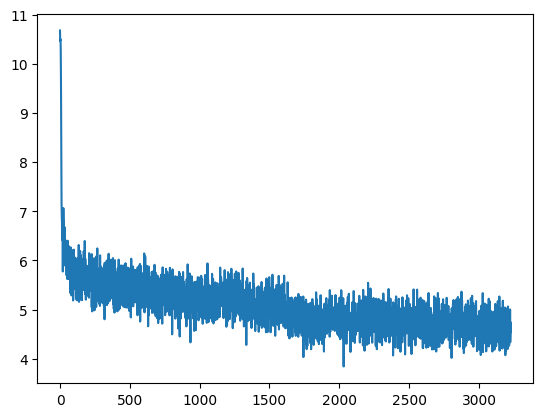

In [ ]:
plt.plot(losses)

In [ ]:
from tqdm import tqdm

## Validation & Submission

In [ ]:
val_ids = [ i for i,_ in data["English-Bengali"]["Validation"].items()]

In [ ]:
val_outs = []
for i in tqdm(range(len(test_ds))):
  encoder_hidden = torch.zeros(1, 1, hidden_size).to(device)
  input_tensor = test_ds[i][0].unsqueeze(dim=0).to(device)
  result = []
  with torch.set_grad_enabled(False):
    encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)
    decoder_input = torch.tensor([SOS]).unsqueeze(dim=0).to(device)
    decoder_hidden = encoder_hidden
    for di in range(1, target_length):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        best = decoder_output.argmax(1)
        result.append(de_index2word[best.to('cpu').item()])
        if best.item() == EOS:
            break

        decoder_input = best.unsqueeze(dim=0)
  result = [i for i in result if not i in ['<EOS>', '<PAD>', '<SOS>']]
  val_outs.append(" ".join(result))

100%|██████████| 9836/9836 [01:23<00:00, 118.30it/s]


In [ ]:
df0 = pd.DataFrame()
df0["ID"] = val_ids
df0["Translation"] = val_outs

In [ ]:
df0.to_csv('answersB.csv', index = False)

In [ ]:
x=pd.read_csv("/content/answersB.csv")

In [ ]:
x

,ID,Translation
0,147532,এর থেকে থেকে থেকে থেকে থেকে থেকে থেকে থেকে এবং...
1,147533,অজন্তা ও ও ও এবং এবং এবং এবং এবং এবং এবং
2,147534,বিশ্ব জন্য এবং এবং এবং এবং এবং এবং এবং এবং এবং...
3,147535,মোট মোট জনসংখ্যা জনসংখ্যা জনসংখ্যা
4,147536,ভারতের ভারতের ভারতের ভারতের ভারতের এবং এবং এবং...
...,...,...
9831,157363,এই প্রথম প্রথম প্রথম প্রথম প্রথম প্রথম ৷
9832,157364,এখানে এখানে
9833,157365,স্টেশন স্টেশন স্টেশন স্টেশন স্টেশন
9834,157366,এই এবং এবং এবং এবং এবং


### Repeat the same procedure for English → Bengali

In [ ]:
df1 = pd.read_csv("/content/answersB.csv") # Bengali
df2= pd.read_csv("/content/answersH.csv")  # Hindi

In [ ]:
df3 = pd.concat([df1, df2]) #Concat

In [ ]:
df3

,ID,Translation
0,147532,এর থেকে থেকে থেকে থেকে থেকে থেকে থেকে থেকে এবং...
1,147533,অজন্তা ও ও ও এবং এবং এবং এবং এবং এবং এবং
2,147534,বিশ্ব জন্য এবং এবং এবং এবং এবং এবং এবং এবং এবং...
3,147535,মোট মোট জনসংখ্যা জনসংখ্যা জনসংখ্যা
4,147536,ভারতের ভারতের ভারতের ভারতের ভারতের এবং এবং এবং...
...,...,...
11538,517049,अपने के के के और के और और और और और और और और और...
11539,517050,यह में में में में में है में में में में है ह...
11540,517051,मुझे में में में में में केंद्र केंद्र दिखाओ द...
11541,517052,लोग में में में में में में में में में । ।


In [ ]:
df3.to_csv('answersBH.csv', index = False)

In [ ]:
filtered_data = pd.read_csv("/content/answersBH.csv")

In [ ]:
answer = "/content/answer.csv"
with open(answer, "w") as f:
  f.writelines("ID\tTranslation\n")
  for i in range(filtered_data.shape[0]):
    f.writelines(f'{filtered_data["ID"][i]}\t"{filtered_data["Translation"][i]}"\n')

### Zip `answer.csv` as `submission.zip` and submit

# Phase 2 — Bidirectional Encoder + Attention (English → Hindi)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import json
import numpy as np
import re
import string
import nltk
import pandas as pd
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
with open('/kaggle/input/capstone-data/capstone_data/train_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [ ]:
# Process JSON data
source_sentences_train = []
target_sentences_train = []

source_sentences_val = []
target_sentences_val = []

id_train = []
id_val = []

In [ ]:
for language_pair, language_data in data.items():
  print(f"Language Pair: {language_pair}")

Language Pair: English-Bengali
Language Pair: English-Hindi


In [ ]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

Language Pair: English-Hindi
  Data Type: Train


In [ ]:
with open('/kaggle/input/capstone-data/capstone_data/val_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [ ]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              #target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                #target_sentences_val.append(target)
                id_val.append(entry_id)
              #else:
                #source_sentences_train.append(source)
                #target_sentences_train.append(target)
                #id_train.append(entry_id)

Language Pair: English-Hindi
  Data Type: Validation


In [ ]:
print(len(source_sentences_train))
print(len(target_sentences_train))

print(len(source_sentences_val))
print(len(target_sentences_val))

80797
80797
11543
0


In [ ]:
x={'English':source_sentences_train,'Hindi':target_sentences_train}

In [ ]:
df=pd.DataFrame(x)

In [ ]:
df

,English,Hindi
0,cancel everything on my calendar,मेरे कैलेंडर पर सब कुछ रद्द करें
1,Adrenal hormone levels are at their peak durin...,अधिवृक्क के हार्मोन का स्तर प्रातःकाल में अपने...
2,"Golden threads are obtained from Surat, the qu...","स्वर्ण धागे सूरत से प्राप्त होते हैं, जिनकी गु..."
3,Look for agglutination within 30 seconds.,30 सेकेण्ड के भीतर एग्लूटिनेशन देखें।
4,The non-pompousness and informality of their l...,उनके जीवन की आडंबरहीनता एवं अनौपचारिकता उनके स...
...,...,...
80792,"So, is it that this is the optimization proble...","तो, यह अनुकूलन समस्या है जिसमें हम रुचि रखते थे।"
80793,In this Masjid made with red stones there are ...,लाल पत्थरों से बनायी गयी इस मस्जिद में हिन्दू ...
80794,"He began to work on the movie on August 17, 20...","उन्होंने 17 अगस्त, 2010 को फिल्म पर काम करना श..."
80795,start a new shopping list,एक नई खरीदारी सूची शुरू करें


In [ ]:
import nltk
from collections import Counter

In [ ]:
# Function to preprocess and remove punctuation and numbers
def preprocess_and_remove_punctuation(sentence):
    # Remove punctuation and numbers
    sentence = ''.join([char for char in sentence if char not in string.punctuation and not char.isdigit()])
    return sentence

In [ ]:
# Tokenization and Lowercasing
def preprocess(sentences):
    tokenized_sentences = [nltk.word_tokenize(preprocess_and_remove_punctuation(sentence.lower())) for sentence in sentences]
    return tokenized_sentences

In [ ]:
target_sentences_train = [re.sub(r'[a-zA-Z]','',hi) for hi in target_sentences_train] #optional

In [ ]:
english_tokens = preprocess(source_sentences_train)
english_test=preprocess(source_sentences_val)
hindi_tokens = preprocess(target_sentences_train)
hindi_test=preprocess(target_sentences_val)

In [ ]:
df['Hindi'][6]

'गुजरात के हथकरघा कारखाने में बनने वाले कशीदेदार गलीचे और शॉल आसानी से छाती से लगाने लायक हैं।'

In [ ]:
hindi_tokens[:10]

[['मेरे', 'कैलेंडर', 'पर', 'सब', 'कुछ', 'रद्द', 'करें'],
 ['अधिवृक्क',
  'के',
  'हार्मोन',
  'का',
  'स्तर',
  'प्रातःकाल',
  'में',
  'अपने',
  'शिखर',
  'पर',
  'होता',
  'है',
  'और',
  'लगभग',
  'दोपहर',
  'बजे',
  'एक',
  'निम्न',
  'स्तर',
  'पर',
  'पहुंचते',
  'हुए',
  'संध्याकाल',
  'में',
  'धीरेधीरे',
  'कम',
  'हो',
  'जाता',
  'है।',
  'इन',
  'हार्मोनों',
  'का',
  'वाहिकीय',
  'मांसपेशी',
  'के',
  'तान',
  'को',
  'नियंत्रित',
  'करने',
  'और',
  'वाहिकाविस्फार',
  'से',
  'बचाने',
  'का',
  'एक',
  'महत्त्वपूर्ण'],
 ['स्वर्ण',
  'धागे',
  'सूरत',
  'से',
  'प्राप्त',
  'होते',
  'हैं',
  'जिनकी',
  'गुणवत्ता',
  'गज़',
  'मीटर',
  'प्रति',
  'तोला',
  'ग्राम',
  'है।'],
 ['सेकेण्ड', 'के', 'भीतर', 'एग्लूटिनेशन', 'देखें।'],
 ['उनके',
  'जीवन',
  'की',
  'आडंबरहीनता',
  'एवं',
  'अनौपचारिकता',
  'उनके',
  'साहित्य',
  'में',
  'भी',
  'प्रतिबिंबित',
  'होती',
  'है',
  '।'],
 ['विश्व',
  'शतरंज',
  'चैम्पियनशिप',
  'जिसमें',
  'क्रैमनिक',
  'ने',
  'एफआईडीई',
  'विश्व',
 

In [ ]:
def oov_rate(train_vocab, test_tokens):
    oov = sum(1 for t in test_tokens if t not in train_vocab)
    return oov / len(test_tokens)
oov_rate([item for sublist in english_tokens for item in sublist],[item for sublist in english_test for item in sublist])

0.02198525120696058

In [ ]:
en_train=english_tokens
en_test=english_test
de_train=hindi_tokens
de_test=hindi_test

In [ ]:
en_index2word = ["<PAD>", "<SOS>", "<EOS>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>"]

for ds in [en_train, en_test]:
    for sent in ds:
        for token in sent:
            if token not in en_index2word:
                en_index2word.append(token)

for ds in [de_train, de_test]:
    for sent in ds:
        for token in sent:
            if token not in de_index2word:
                de_index2word.append(token)

In [ ]:
en_index2word

['<PAD>',
 '<SOS>',
 '<EOS>',
 'cancel',
 'everything',
 'on',
 'my',
 'calendar',
 'adrenal',
 'hormone',
 'levels',
 'are',
 'at',
 'their',
 'peak',
 'during',
 'the',
 'morning',
 'and',
 'taper',
 'off',
 'evening',
 'reaching',
 'a',
 'low',
 'level',
 'around',
 'am',
 'an',
 'important',
 'function',
 'of',
 'these',
 'hormones',
 'is',
 'to',
 'regulate',
 'vascular',
 'muscle',
 'tone',
 'prevent',
 'vasocodilation',
 'golden',
 'threads',
 'obtained',
 'from',
 'surat',
 'quality',
 'being',
 'yards',
 'meters',
 'per',
 'tola',
 'grams',
 'look',
 'for',
 'agglutination',
 'within',
 'seconds',
 'nonpompousness',
 'informality',
 'life',
 'reflected',
 'in',
 'literature',
 'also',
 'world',
 'chess',
 'championship',
 'which',
 'kramnik',
 'beat',
 'fide',
 'champion',
 'veselin',
 'topalov',
 'reunified',
 'titles',
 'made',
 'undisputed',
 'heavily',
 'embroidered',
 'rugs',
 'shawls',
 'produced',
 'gujarat',
 '’',
 's',
 'handloom',
 'workshops',
 'simply',
 'beg',
 'b

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}

In [ ]:
len(en_word2index)

61208

In [ ]:
len(de_word2index)

72202

In [ ]:
en_lengths = sum([len(sent) for sent in en_train])/len(en_train)
de_lengths = sum([len(sent) for sent in de_train])/len(de_train)

In [ ]:
seq_length = 20

In [ ]:
def encode_and_pad(vocab, sent, max_length):
    sos = [vocab["<SOS>"]]
    eos = [vocab["<EOS>"]]
    pad = [vocab["<PAD>"]]

    if len(sent) < max_length - 2: # -2 for SOS and EOS
        n_pads = max_length - 2 - len(sent)
        encoded = [vocab[w] for w in sent]
        return sos + encoded + eos + pad * n_pads
    else: # sent is longer than max_length; truncating
        encoded = [vocab[w] for w in sent]
        truncated = encoded[:max_length - 2]
        return sos + truncated + eos

In [ ]:
en_train_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_train]
en_test_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_test]
de_train_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_train]
de_test_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_test]

In [ ]:
en_train_encoded[1]

[1, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 15, 16, 21, 22, 23, 2]

In [ ]:
from torch.utils.data import DataLoader, TensorDataset, random_split
batch_size = 50

train_x = np.array(en_train_encoded)
train_y = np.array(de_train_encoded)
test_x = np.array(en_test_encoded)
test_y = np.array(de_test_encoded)

train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
test_ds = TensorDataset(torch.from_numpy(test_x))

full_train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))

# Split training ds ( 90% train, 10% validation)
train_size = int(0.9 * len(full_train_ds))
val_size = len(full_train_ds) - train_size
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

print(f"Full training size: {len(full_train_ds)}")
print(f"New train_ds size:  {len(train_ds)}")
print(f"New val_ds size:    {len(val_ds)}")

# creating datalaoders
train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
val_dl = DataLoader(val_ds, shuffle=False, batch_size=batch_size, drop_last=False)

Full training size: 80797
New train_ds size:  72717
New val_ds size:    8080


In [ ]:
test_dl = DataLoader(test_ds, shuffle=False, batch_size=batch_size, drop_last=False)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
hidden_size = 256
teacher_forcing_ratio = 1.0
input_length = target_length = seq_length
SOS_token = en_word2index["<SOS>"]
EOS_token = en_word2index["<EOS>"]
PAD_token = en_word2index["<PAD>"]
# epochs = 5
learning_rate = 3e-3

Using device: cuda


In [ ]:
target_length = seq_length
# teacher_forcing_ratio = 1.0

In [ ]:
#  bidirectional encoder
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.3):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)

        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True, bidirectional=True)

        # self.fc_hidden = nn.Linear(hidden_size * 2, hidden_size)
        self.fc_output = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, input, hidden):
        # input shape: (batch_size, seq_len)
        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        embedded = self.embedding(input)
        embedded = self.dropout(embedded)
        # embedded shape: (batch_size, seq_len, hidden_size)

        output, hidden = self.gru(embedded, hidden)
        # output shape: (batch_size, seq_len, hidden_size * 2)
        # hidden shape: (2, batch_size, hidden_size)

        output = torch.tanh(self.fc_output(output))

        # i used Two different methods  for fusing

        # # Fuse hidden states from both directions
        # # Concatenate forward (hidden[0]) and backward (hidden[1])
        # hidden_cat = torch.cat((hidden[0:1], hidden[1:2]), dim=2)
        # # hidden_cat shape: (1, batch_size, hidden_size * 2)
        # hidden = torch.tanh(self.fc_hidden(hidden_cat))

        # Fuse hidden states
        hidden = hidden.sum(dim=0, keepdim=True)  # (1, batch, hidden_size)
        return output, hidden

    def initHidden(self, current_batch_size):
        return torch.zeros(2, current_batch_size, self.hidden_size,device = device)

In [ ]:
# # week 2

# class Attention(nn.Module):
#
#     def __init__(self, hidden_size):
#         super(Attention, self).__init__()
#         self.W1 =  nn.Linear(hidden_size, hidden_size)
#         self.W2 = nn.Linear(hidden_size, hidden_size)
#         self.V = nn.Linear(hidden_size, 1)

#     def forward(self, decoder_hidden, encoder_outputs):

#         # permute to (batch_size, 1, hidden_size)
#         decoder_hidden_permuted = decoder_hidden.permute(1, 0, 2)

#         score = torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden_permuted))

#         attention_energies = self.V(score).squeeze(2)

#         # .unsqueeze(1) to make it (batch_size, 1, seq_len) for batch matrix multiply
#         return F.softmax(attention_energies, dim=1).unsqueeze(1)

In [ ]:
# Week 3
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.W1 =  nn.Linear(hidden_size, hidden_size)
        self.W2 = nn.Linear(hidden_size, hidden_size)
        self.V = nn.Linear(hidden_size, 1)

    def forward(self, decoder_hidden, encoder_outputs, encoder_mask):
        # permute to (batch_size, 1, hidden_size)
        decoder_hidden_permuted = decoder_hidden.permute(1, 0, 2)
        score = torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden_permuted))
        attention_energies = self.V(score).squeeze(2)
        # The mask is True for PAD tokens, False for real tokens.
        attention_energies.masked_fill_(encoder_mask, -1e9)

        # .unsqueeze(1) to make it (batch_size, 1, seq_len) for batch matrix multiply
        return F.softmax(attention_energies, dim=1).unsqueeze(1)

In [ ]:
# # Week 2
# class DecoderRNN(nn.Module):
#     def __init__(self, hidden_size, output_size, dropout_p=0.1):
#         super(DecoderRNN, self).__init__()
#         self.hidden_size = hidden_size

#         self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
#         self.dropout = nn.Dropout(dropout_p)
#
#         self.attention = Attention(hidden_size)
#         self.gru = nn.GRU(hidden_size * 2, hidden_size, batch_first=True)
#         self.out = nn.Linear(hidden_size, output_size)
#         self.softmax = nn.LogSoftmax(dim=1)
#
#     def forward(self, input, hidden, encoder_outputs):
#         # input shape: (batch_size, 1)
#         # hidden shape: (1, batch_size, hidden_size)
#         # encoder_outputs shape: (batch_size, seq_len, hidden_size)

#         embedded = self.embedding(input)
#         embedded = self.dropout(embedded)
#
#         attn_weights = self.attention(hidden, encoder_outputs)

#         context = torch.bmm(attn_weights, encoder_outputs)

#         rnn_input = torch.cat((embedded, context), dim=2)

#         output = F.relu(rnn_input)

#         # Pass concatenated vector to GRU
#         output, hidden = self.gru(output, hidden)
#         # output shape: (batch_size, 1, hidden_size)
#         # hidden shape: (1, batch_size, hidden_size)

#         # Get prediction scores
#         # .squeeze(1) to remove seq_len dim before linear layer
#         output = self.softmax(self.out(output.squeeze(1)))
#         # output shape: (batch_size, output_vocab_size)

#         # Return attention weights for visualization (optional)
#         return output, hidden, attn_weights

In [ ]:
# Week 3
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.3):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)

        # (This line was already correct, assuming Attention is your modified class)
        self.attention = Attention(hidden_size)

        # (embedded_word + context_vector)
        self.gru = nn.GRU(hidden_size * 2, hidden_size, batch_first=True)

        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden, encoder_outputs, encoder_mask):
        # input shape: (batch_size, 1)
        # hidden shape: (1, batch_size, hidden_size)
        # encoder_outputs shape: (batch_size, seq_len, hidden_size)
        # encoder_mask shape: (batch_size, seq_len)

        embedded = self.embedding(input)
        embedded = self.dropout(embedded)
        # embedded shape: (batch_size, 1, hidden_size)

        attn_weights = self.attention(hidden, encoder_outputs, encoder_mask)
        # attn_weights shape: (batch_size, 1, seq_len)

        context = torch.bmm(attn_weights, encoder_outputs)
        # context shape: (batch_size, 1, hidden_size)

        rnn_input = torch.cat((embedded, context), dim=2)
        # rnn_input shape: (batch_size, 1, hidden_size * 2)

        # Your original ReLu (kept it)
        output = F.relu(rnn_input)

        # Pass concatenated vector to GRU
        output, hidden = self.gru(output, hidden)
        # output shape: (batch_size, 1, hidden_size)
        # hidden shape: (1, batch_size, hidden_size)

        # Get prediction scores
        # .squeeze(1) to remove seq_len dim before linear layer
        output = self.softmax(self.out(output.squeeze(1)))
        # output shape: (batch_size, output_vocab_size)

        # Return attention weights for visualization (optional)
        return output, hidden, attn_weights

In [ ]:
# # Week 2
# encoderH = EncoderRNN(len(en_word2index), hidden_size).to(device)
# decoderH = DecoderRNN(hidden_size, len(de_word2index)).to(device)

# criterion = nn.NLLLoss(ignore_index=PAD_token) # Ignore padding in loss
# enc_optimizer = torch.optim.Adam(encoderH.parameters(), lr=learning_rate)
# dec_optimizer = torch.optim.Adam(decoderH.parameters(), lr=learning_rate)

# losses = []
# print("Starting training...")

# for epoch in range(epochs):
#     encoderH.train()
#     decoderH.train()

#     epoch_losses = []

#     for idx, batch in enumerate(train_dl):
#         # Get current batch size (might be different for last batch)
#         current_batch_size = batch[0].shape[0]

#         # Creating initial hidden states for the encoder
#         encoder_hidden = encoderH.initHidden(current_batch_size)

#         input_tensor = batch[0].to(device)
#         target_tensor = batch[1].to(device)

#         enc_optimizer.zero_grad()
#         dec_optimizer.zero_grad()

#         # --- Encoder pass ---
#         encoder_outputs, encoder_hidden = encoderH(input_tensor, encoder_hidden)

#         # --- Decoder pass ---
#         # Start with <SOS> token for each sentence in batch
#         decoder_input = target_tensor[:, 0].unsqueeze(1) # (batch_size, 1)

#         # Initial decoder hidden state is encoder's final hidden state
#         # decoder_hidden = encoder_hidden
#         decoder_hidden = encoder_hidden

#         # Determine if we're using teacher forcing this batch
#         use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

#         loss = 0 # Initialize loss for this batch

#         # Loop over target sequence (skipping <SOS> at index 0)
#         for i in range(1, target_length):

#
#             decoder_output, decoder_hidden, _ = decoderH(
#                 decoder_input, decoder_hidden, encoder_outputs
#             )

#
#             loss += criterion(decoder_output, target_tensor[:, i])

#             if use_teacher_forcing:
#                 # Feed the *correct* target word as the next input
#                 decoder_input = target_tensor[:, i].unsqueeze(1)
#             else:
#                 # Feed the *model's own prediction* as the next input
#                 topv, topi = decoder_output.topk(1)
#                 decoder_input = topi.detach() # (batch_size, 1)

#         # Backpropagate
#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(encoderH.parameters(), max_norm=1)
#         torch.nn.utils.clip_grad_norm_(decoderH.parameters(), max_norm=1)

#         enc_optimizer.step()
#         dec_optimizer.step()

#         # Average loss per token for this batch
#         batch_loss = loss.item() / (target_length - 1)
#         losses.append(batch_loss)
#         epoch_losses.append(batch_loss)

#         if idx % 100 == 0:
#             print(f"Epoch {epoch+1}/{epochs}, Batch {idx}/{len(train_dl)}, Avg. Batch Loss: {batch_loss:.4f}")

#     print(f"--- End of Epoch {epoch+1}, Avg. Epoch Loss: {np.mean(epoch_losses):.4f} ---")

In [ ]:
encoderH = EncoderRNN(len(en_word2index), hidden_size).to(device)
decoderH = DecoderRNN(hidden_size, len(de_word2index)).to(device)
criterion = nn.NLLLoss(ignore_index=PAD_token)
# Add the weight_decay parameter
enc_optimizer = torch.optim.Adam(encoderH.parameters(), lr=learning_rate, weight_decay=1e-5)
dec_optimizer = torch.optim.Adam(decoderH.parameters(), lr=learning_rate, weight_decay=1e-5)

enc_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    enc_optimizer, 'min', patience=2, factor=0.1
)
dec_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    dec_optimizer, 'min', patience=2, factor=0.1
)

In [ ]:
# Week 3
# encoderH = EncoderRNN(len(en_word2index), hidden_size).to(device)
# decoderH = DecoderRNN(hidden_size, len(de_word2index)).to(device)

# criterion = nn.NLLLoss(ignore_index=PAD_token) # Ignore padding in loss
# enc_optimizer = torch.optim.Adam(encoderH.parameters(), lr=learning_rate)
# dec_optimizer = torch.optim.Adam(decoderH.parameters(), lr=learning_rate)

losses = []
print("Starting training...")

for epoch in range(epochs):
    encoderH.train()
    decoderH.train()

    epoch_losses = []

    for idx, batch in enumerate(train_dl):
        # Get current batch size (might be different for last batch)
        current_batch_size = batch[0].shape[0]

        # Creating initial hidden states for the encoder
        encoder_hidden = encoderH.initHidden(current_batch_size)

        input_tensor = batch[0].to(device)
        target_tensor = batch[1].to(device)
        # The mask is True where the input is a PAD token
        encoder_mask = (input_tensor == PAD_token)

        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()

        # --- Encoder pass ---
        encoder_outputs, encoder_hidden = encoderH(input_tensor, encoder_hidden)

        # --- Decoder pass ---
        # Start with <SOS> token for each sentence in batch
        decoder_input = target_tensor[:, 0].unsqueeze(1) # (batch_size, 1)

        # Initial decoder hidden state is encoder's final hidden state
        decoder_hidden = encoder_hidden

        # Determine if we're using teacher forcing this batch
        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

        loss = 0 # Initialize loss for this batch

        # Loop over target sequence (skipping <SOS> at index 0)
        for i in range(1, target_length):

            # --- PASS THE MASK TO THE DECODER ---
            # The decoder will pass this mask down to its attention module
            decoder_output, decoder_hidden, _ = decoderH(
                decoder_input,
                decoder_hidden,
                encoder_outputs,
                encoder_mask
            )

            loss += criterion(decoder_output, target_tensor[:, i])

            if use_teacher_forcing:
                # Feed the *correct* target word as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                # Feed the *model's own prediction* as the next input
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.detach() # (batch_size, 1)

        # Backpropagate
        loss.backward()

        torch.nn.utils.clip_grad_norm_(encoderH.parameters(), max_norm=1)
        torch.nn.utils.clip_grad_norm_(decoderH.parameters(), max_norm=1)

        enc_optimizer.step()
        dec_optimizer.step()

        # Average loss per token for this batch
        batch_loss = loss.item() / (target_length - 1)
        losses.append(batch_loss)
        epoch_losses.append(batch_loss)

        if idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {idx}/{len(train_dl)}, Avg. Batch Loss: {batch_loss:.4f}")

    print(f"--- End of Epoch {epoch+1}, Avg. Epoch Loss: {np.mean(epoch_losses):.4f} ---")

Starting training...
Epoch 1/5, Batch 0/1615, Avg. Batch Loss: 11.1961
Epoch 1/5, Batch 100/1615, Avg. Batch Loss: 7.3603
Epoch 1/5, Batch 200/1615, Avg. Batch Loss: 7.2052
Epoch 1/5, Batch 300/1615, Avg. Batch Loss: 7.1811
Epoch 1/5, Batch 400/1615, Avg. Batch Loss: 7.2027
Epoch 1/5, Batch 500/1615, Avg. Batch Loss: 6.7538
Epoch 1/5, Batch 600/1615, Avg. Batch Loss: 6.7054
Epoch 1/5, Batch 700/1615, Avg. Batch Loss: 6.8107
Epoch 1/5, Batch 800/1615, Avg. Batch Loss: 6.5429
Epoch 1/5, Batch 900/1615, Avg. Batch Loss: 6.4311
Epoch 1/5, Batch 1000/1615, Avg. Batch Loss: 6.6745
Epoch 1/5, Batch 1100/1615, Avg. Batch Loss: 6.9113
Epoch 1/5, Batch 1200/1615, Avg. Batch Loss: 6.7594
Epoch 1/5, Batch 1300/1615, Avg. Batch Loss: 6.6214
Epoch 1/5, Batch 1400/1615, Avg. Batch Loss: 5.8047
Epoch 1/5, Batch 1500/1615, Avg. Batch Loss: 6.1857
Epoch 1/5, Batch 1600/1615, Avg. Batch Loss: 6.5170
--- End of Epoch 1, Avg. Epoch Loss: 6.7603 ---
Epoch 2/5, Batch 0/1615, Avg. Batch Loss: 5.7641
Epoch 2/5

In [ ]:
# Week 3 sub 3
import numpy as np
import torch
import os

# This class will track the validation loss and save the best model
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=5, verbose=False, delta=0,
                 enc_path='encoder_checkpoint.pt', dec_path='decoder_checkpoint.pt'):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            enc_path (str): Path for the encoder checkpoint to be saved to.
            dec_path (str): Path for the decoder checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.enc_path = enc_path
        self.dec_path = dec_path

    def __call__(self, val_loss, encoder, decoder):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, encoder, decoder)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, encoder, decoder)
            self.counter = 0

    def save_checkpoint(self, val_loss, encoder, decoder):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(encoder.state_dict(), self.enc_path)
        torch.save(decoder.state_dict(), self.dec_path)
        self.val_loss_min = val_loss

# This function will run the model on the validation set (val_dl)
def validate(encoder, decoder, val_loader, criterion, device, target_length, PAD_token):
    encoder.eval() # Set model to evaluation mode
    decoder.eval()

    total_val_loss = 0

    with torch.no_grad(): # No gradients needed for validation
        for batch in val_loader:
            current_batch_size = batch[0].shape[0]
            encoder_hidden = encoder.initHidden(current_batch_size)

            input_tensor = batch[0].to(device)
            target_tensor = batch[1].to(device)

            encoder_mask = (input_tensor == PAD_token)

            encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

            decoder_input = target_tensor[:, 0].unsqueeze(1)
            decoder_hidden = encoder_hidden

            loss = 0

            # Validation loop: NO teacher forcing
            for i in range(1, target_length):
                decoder_output, decoder_hidden, _ = decoder(
                    decoder_input,
                    decoder_hidden,
                    encoder_outputs,
                    encoder_mask
                )

                loss += criterion(decoder_output, target_tensor[:, i])

                # Use model's own prediction as next input
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.detach()

            total_val_loss += (loss.item() / (target_length - 1))

    return total_val_loss / len(val_loader)

In [ ]:
# Week 3 sub 3

# Set a large number of epochs; EarlyStopping will find the best one
epochs = 100
patience = 5 # Stop after 5 epochs of no improvement
early_stopping = EarlyStopping(patience=patience, verbose=True)

# To store all losses for plotting later
all_train_losses = []
all_val_losses = []

print("Starting training with Early Stopping...")

for epoch in range(epochs):

    encoderH.train()
    decoderH.train()

    epoch_train_losses = []

    for idx, batch in enumerate(train_dl):
        current_batch_size = batch[0].shape[0]
        encoder_hidden = encoderH.initHidden(current_batch_size)
        input_tensor = batch[0].to(device)
        target_tensor = batch[1].to(device)
        encoder_mask = (input_tensor == PAD_token)

        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoderH(input_tensor, encoder_hidden)
        decoder_input = target_tensor[:, 0].unsqueeze(1)
        decoder_hidden = encoder_hidden
        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False
        loss = 0

        for i in range(1, target_length):
            decoder_output, decoder_hidden, _ = decoderH(
                decoder_input,
                decoder_hidden,
                encoder_outputs,
                encoder_mask
            )
            loss += criterion(decoder_output, target_tensor[:, i])
            if use_teacher_forcing:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.detach()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(encoderH.parameters(), max_norm=1)
        torch.nn.utils.clip_grad_norm_(decoderH.parameters(), max_norm=1)
        enc_optimizer.step()
        dec_optimizer.step()

        batch_loss = loss.item() / (target_length - 1)
        epoch_train_losses.append(batch_loss)

        if idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {idx}/{len(train_dl)}, Avg. Batch Loss: {batch_loss:.4f}")

    avg_train_loss = np.mean(epoch_train_losses)
    all_train_losses.append(avg_train_loss)

    # --- 2. VALIDATION STEP ---
    avg_val_loss = validate(encoderH, decoderH, val_dl, criterion, device, target_length, PAD_token)
    all_val_losses.append(avg_val_loss)

    print(f"--- End of Epoch {epoch+1}, Avg. Train Loss: {avg_train_loss:.4f}, Avg. Val Loss: {avg_val_loss:.4f} ---")

    # --- 3. SCHEDULER & EARLY STOPPING STEP ---

    # Step the LR schedulers (based on validation loss)
    enc_scheduler.step(avg_val_loss)
    dec_scheduler.step(avg_val_loss)

    # Check for early stopping
    early_stopping(avg_val_loss, encoderH, decoderH)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

print("Training complete.")

Starting training with Early Stopping...
Epoch 1/100, Batch 0/1454, Avg. Batch Loss: 11.1978
Epoch 1/100, Batch 100/1454, Avg. Batch Loss: 7.0247
Epoch 1/100, Batch 200/1454, Avg. Batch Loss: 6.7833
Epoch 1/100, Batch 300/1454, Avg. Batch Loss: 6.6189
Epoch 1/100, Batch 400/1454, Avg. Batch Loss: 6.4089
Epoch 1/100, Batch 500/1454, Avg. Batch Loss: 6.7328
Epoch 1/100, Batch 600/1454, Avg. Batch Loss: 6.0171
Epoch 1/100, Batch 700/1454, Avg. Batch Loss: 6.1443
Epoch 1/100, Batch 800/1454, Avg. Batch Loss: 5.7253
Epoch 1/100, Batch 900/1454, Avg. Batch Loss: 6.1169
Epoch 1/100, Batch 1000/1454, Avg. Batch Loss: 5.6728
Epoch 1/100, Batch 1100/1454, Avg. Batch Loss: 5.7960
Epoch 1/100, Batch 1200/1454, Avg. Batch Loss: 5.5706
Epoch 1/100, Batch 1300/1454, Avg. Batch Loss: 5.1334
Epoch 1/100, Batch 1400/1454, Avg. Batch Loss: 5.4338
--- End of Epoch 1, Avg. Train Loss: 6.1113, Avg. Val Loss: 7.3835 ---
Validation loss decreased (inf --> 7.383472).  Saving model ...
Epoch 2/100, Batch 0/1454

In [ ]:
print("Loading best model weights from checkpoint...")
encoderH.load_state_dict(torch.load('encoder_checkpoint.pt'))
decoderH.load_state_dict(torch.load('decoder_checkpoint.pt'))

print("Model is ready for prediction.")

# You can now plot the losses
# import matplotlib.pyplot as plt
# plt.plot(all_train_losses, label='Train Loss')
# plt.plot(all_val_losses, label='Val Loss')
# plt.legend()
# plt.show()

Loading best model weights from checkpoint...
Model is ready for prediction.


In [ ]:
# import pandas as pd
# from nltk.translate.bleu_score import corpus_bleu
# import torch
# from torch.utils.data import DataLoader, TensorDataset

# # We still need this to get predictions in the correct, unshuffled order.
# eval_train_dl = DataLoader(
#     train_ds,
#     shuffle=False,  # <-- CRITICAL: Ensures predictions match your list order
#     batch_size=batch_size,
#     drop_last=False
# )

# print("Starting predictions on the training data (unshuffled)...")

# train_predictions = predict(
#     encoderH,
#     decoderH,
#     eval_train_dl,  # <-- Use the unshuffled loader
#     de_index2word,
#     max_length=seq_length
# )
# print(f"Generated {len(train_predictions)} predictions.")


# # --- 2. Get References (Directly from your list) ---
# # This is much simpler! We just use the variable you provided.
# train_references_strings = target_sentences_train
# print(f"Loaded {len(train_references_strings)} references from your list.")


# # --- 3. Calculate BLEU Score ---

# # NLTK expects tokenized input
# # 1. Tokenize predictions: List[List[str]]
# tokenized_predictions = [pred.split() for pred in train_predictions]

# # 2. Tokenize references: List[List[List[str]]]
# # Format: [[['ref', '1']], [['ref', '2']], ...]
# tokenized_references = [[ref.split()] for ref in train_references_strings]

# print("\nCalculating BLEU score...")

# # Final check to ensure counts match
# if len(tokenized_predictions) == len(tokenized_references) and len(tokenized_predictions) > 0:

#     # Calculate corpus BLEU
#     bleu_score = corpus_bleu(tokenized_references, tokenized_predictions)

#     print("\n" + "="*30)
#     print(f"  BLEU Score on Training Data: {bleu_score * 100:.2f}")
#     print("="*30 + "\n")

#     # Save for manual inspection
#     df_train = pd.DataFrame({
#         "Reference": train_references_strings,
#         "Prediction": train_predictions
#     })
#     df_train.to_csv('train_predictions_vs_references.csv', index=False)
#     print("Saved training references and predictions to 'train_predictions_vs_references.csv'")
#     print(df_train.head())

# else:
#     print(f"\nError: Mismatch in prediction count ({len(train_predictions)}) "
#           f"and reference count ({len(train_references_strings)}).")
#     print("Please check that 'target_sentences_train' matches the original training data order.")

Starting predictions on the training data (unshuffled)...


Predicting on validation set: 100%|██████████| 1616/1616 [01:35<00:00, 16.94it/s]


Generated 80797 predictions.
Loaded 80797 references from your list.

Calculating BLEU score...

  BLEU Score on Training Data: 1.83

Saved training references and predictions to 'train_predictions_vs_references.csv'
                                           Reference  \
0                   मेरे कैलेंडर पर सब कुछ रद्द करें   
1  अधिवृक्क के हार्मोन का स्तर प्रातःकाल में अपने...   
2  स्वर्ण धागे सूरत से प्राप्त होते हैं, जिनकी गु...   
3              30 सेकेण्ड के भीतर एग्लूटिनेशन देखें।   
4  उनके जीवन की आडंबरहीनता एवं अनौपचारिकता उनके स...   

                                          Prediction  
0                   मेरे कैलेंडर कैलेंडर कैलेंडर में  
1  अधिवृक्क अधिवृक्क अधिवृक्क अधिवृक्क अधिवृक्क अ...  
2  उत्तराखंड से गज़ गज़ गज़ गज़ गज़ गज़ गज़ गज़ गज़ गज़ गज़ ...  
3  एग्लूटिनेशन एग्लूटिनेशन एग्लूटिनेशन एग्लूटिनेश...  
4  हिब्रू में आडंबरहीनता में आडंबरहीनता और आडंबरह...  


## Sanity Check — Overfit a Single Batch

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# import random
# from torch.utils.data import DataLoader, TensorDataset
# from nltk.translate.bleu_score import corpus_bleu
# from tqdm import tqdm


# # 5. Initialize your Models, Criterion, and Optimizers (from your code)
# encoderH = EncoderRNN(len(en_word2index), hidden_size).to(device)
# decoderH = DecoderRNN(hidden_size, len(de_index2word)).to(device) # Use len() on the list
# criterion = nn.NLLLoss(ignore_index=PAD_token)
# enc_optimizer = torch.optim.Adam(encoderH.parameters(), lr=learning_rate)
# dec_optimizer = torch.optim.Adam(decoderH.parameters(), lr=learning_rate)



# # -------------------------------------------------------------------
# # --- PART 1: YOUR `predict` FUNCTION (ADJUSTED FOR LIST) ---
# # -------------------------------------------------------------------
# def predict(encoder, decoder, data_loader, de_index2word, max_length=seq_length):
#     encoder.eval()
#     decoder.eval()
#     all_predictions = []

#     with torch.no_grad():
#         for batch in tqdm(data_loader, desc="Sanity Check Prediction"):
#             input_tensor = batch[0].to(device)
#             current_batch_size = input_tensor.shape[0]

#             encoder_mask = (input_tensor == PAD_token)

#             encoder_hidden = encoder.initHidden(current_batch_size)
#             encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

#             decoder_input = torch.tensor([[SOS_token]] * current_batch_size, device=device)
#             decoder_hidden = encoder_hidden

#             batch_indices = [[] for _ in range(current_batch_size)]

#             for _ in range(max_length):
#                 decoder_output, decoder_hidden, _ = decoder(
#                     decoder_input,
#                     decoder_hidden,
#                     encoder_outputs,
#                     encoder_mask
#                 )

#                 topv, topi = decoder_output.topk(1)
#                 decoder_input = topi

#                 for i in range(current_batch_size):
#                     token_index = topi[i].item()

#                     if batch_indices[i] and batch_indices[i][-1] == EOS_token:
#                         continue
#                     if token_index != EOS_token:
#                         batch_indices[i].append(token_index)
#                     else:
#                         batch_indices[i].append(EOS_token)

#             for indices in batch_indices:
#                 words = []
#                 for idx in indices:
#                     if idx == EOS_token:
#                         break
#                     if idx != PAD_token and idx != SOS_token:

#                         # Use list indexing with a safety check
#                         if idx < len(de_index2word):
#                             words.append(de_index2word[idx])
#                         else:
#                             words.append("<unk>") # Safety for out-of-bounds

#                 all_predictions.append(" ".join(words))

#     return all_predictions



In [ ]:
# print("--- STARTING SANITY CHECK: OVERFITTING ONE BATCH ---")

# # 1. Get a SINGLE Batch
# print("Fetching one batch for sanity check...")
# try:
#     single_batch = next(iter(train_dl))
# except Exception as e:
#     print(f"\n!!! ERROR: Could not get batch from 'train_dl'. Error: {e}")
#     print("Please fill in the PLACEHOLDER section at the top of this script.\n")
#     raise

# # Create a new, permanent DataLoader for *only* this batch
# sanity_ds = TensorDataset(single_batch[0], single_batch[1])
# sanity_dl = DataLoader(sanity_ds, batch_size=single_batch[0].shape[0])

# # Get the text references from this batch for the final BLEU score
# target_batch_tensors = single_batch[1]
# sanity_references = []
# for i in range(target_batch_tensors.size(0)):
#     sentence_tensor = target_batch_tensors[i]
#     words = []
#     for idx_t in sentence_tensor:
#         idx = idx_t.item()
#         if idx == EOS_token:
#             break

#         # --- THIS IS THE CHANGE ---
#         if idx not in (SOS_token, PAD_token):
#             # Use list indexing with a safety check
#             if idx < len(de_index2word):
#                 words.append(de_index2word[idx])
#             # No else needed, we just skip invalid tokens from target

#     sanity_references.append(" ".join(words))

# print(f"Got one batch with {len(sanity_references)} sentences.")


# # 2. Train Repeatedly on This Single Batch (This loop is unchanged)
# num_iterations = 150
# print(f"Starting sanity check: training on one batch for {num_iterations} iterations...")

# for i in range(num_iterations):

#     encoderH.train()
#     decoderH.train()

#     for idx, batch in enumerate(sanity_dl):

#         # --- [START: Your Exact Training Logic] ---

#         current_batch_size = batch[0].shape[0]
#         encoder_hidden = encoderH.initHidden(current_batch_size)
#         input_tensor = batch[0].to(device)
#         target_tensor = batch[1].to(device)
#         encoder_mask = (input_tensor == PAD_token)
#         enc_optimizer.zero_grad()
#         dec_optimizer.zero_grad()
#         encoder_outputs, encoder_hidden = encoderH(input_tensor, encoder_hidden)
#         decoder_input = target_tensor[:, 0].unsqueeze(1)
#         decoder_hidden = encoder_hidden
#         use_teacher_forcing = True
#         loss = 0

#         for j in range(1, target_length):
#             decoder_output, decoder_hidden, _ = decoderH(
#                 decoder_input,
#                 decoder_hidden,
#                 encoder_outputs,
#                 encoder_mask
#             )
#             loss += criterion(decoder_output, target_tensor[:, j])
#             if use_teacher_forcing:
#                 decoder_input = target_tensor[:, j].unsqueeze(1)
#             else:
#                 topv, topi = decoder_output.topk(1)
#                 decoder_input = topi.detach()

#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(encoderH.parameters(), max_norm=1)
#         torch.nn.utils.clip_grad_norm_(decoderH.parameters(), max_norm=1)
#         enc_optimizer.step()
#         dec_optimizer.step()
#         batch_loss = loss.item() / (target_length - 1)

#         # --- [END: Your Exact Training Logic] ---

#     if (i+1) % 20 == 0:
#         print(f"  Iteration {i+1}/{num_iterations}, Loss: {batch_loss:.4f}")

# print("Sanity check training complete.")


# # 3. Evaluate the Model on That SAME Batch (This part is unchanged)
# print("Evaluating model on the sanity check batch...")

# sanity_predictions = predict(
#     encoderH,
#     decoderH,
#     sanity_dl,
#     de_index2word,
#     max_length=seq_length
# )

# tokenized_predictions = [p.split() for p in sanity_predictions]
# tokenized_references = [[r.split()] for r in sanity_references]
# bleu_score = corpus_bleu(tokenized_references, tokenized_predictions)

# print("\n" + "="*30)
# print("--- SANITY CHECK RESULTS ---")
# print(f"Final Loss: {batch_loss:.4f}")
# print(f"BLEU Score on batch: {bleu_score * 100:.2f}")
# print("="*30 + "\n")

# print("\n--- Example Predictions vs. References ---")
# for k in range(min(5, len(sanity_predictions))):
#     print(f"Ref:  {sanity_references[k]}")
#     print(f"Pred: {sanity_predictions[k]}\n")

# print("--- SANITY CHECK COMPLETE ---")

--- STARTING SANITY CHECK: OVERFITTING ONE BATCH ---
Fetching one batch for sanity check...
Got one batch with 50 sentences.
Starting sanity check: training on one batch for 150 iterations...
  Iteration 20/150, Loss: 3.9571
  Iteration 40/150, Loss: 1.3088
  Iteration 60/150, Loss: 0.4260
  Iteration 80/150, Loss: 0.0973
  Iteration 100/150, Loss: 0.0177
  Iteration 120/150, Loss: 0.0044
  Iteration 140/150, Loss: 0.0023
Sanity check training complete.
Evaluating model on the sanity check batch...


Sanity Check Prediction: 100%|██████████| 1/1 [00:00<00:00, 10.81it/s]


--- SANITY CHECK RESULTS ---
Final Loss: 0.0019
BLEU Score on batch: 100.00


--- Example Predictions vs. References ---
Ref:  जबकि स्थापत्य के शानदार नमूने का जो कुछ बचा है वह केवल अवशेष ही है फिर भी वह
Pred: जबकि स्थापत्य के शानदार नमूने का जो कुछ बचा है वह केवल अवशेष ही है फिर भी वह

Ref:  देबरीगढ़ वन्यजीव अभयारण्य हीराकुंद बांध के पास स्थित है।
Pred: देबरीगढ़ वन्यजीव अभयारण्य हीराकुंद बांध के पास स्थित है।

Ref:  खुबानी इसका मुख्य स्थान पश्चिमी चीन है ।
Pred: खुबानी इसका मुख्य स्थान पश्चिमी चीन है ।

Ref:  क्या ऐसे रोगियों मे मौजूद होना चाहिए बाएं पेरीकॉन्ड्रिअम में दृश्यमान क्रमाकुंचन पर ध्यान दिया जा सकता है
Pred: क्या ऐसे रोगियों मे मौजूद होना चाहिए बाएं पेरीकॉन्ड्रिअम में दृश्यमान क्रमाकुंचन पर ध्यान दिया जा सकता है

Ref:  जंगली बिल्लियाँ भारतीय तेंदुए शेर बाघ और हाथी का सामना करें और उन्हें दर्शकों से अनजान खुशी से
Pred: जंगली बिल्लियाँ भारतीय तेंदुए शेर बाघ और हाथी का सामना करें और उन्हें दर्शकों से अनजान खुशी से

--- SANITY CHECK COMPLETE ---


In [ ]:
# # Week 2
# def predict(encoder, decoder, data_loader, de_index2word, max_length=seq_length):
#     encoder.eval()
#     decoder.eval()
#     all_predictions = []

#     with torch.no_grad():
#         for batch in tqdm(data_loader, desc="Predicting on validation set"):
#             input_tensor = batch[0].to(device)
#             current_batch_size = input_tensor.shape[0]

#             encoder_hidden = encoder.initHidden(current_batch_size)
#             encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

#             decoder_input = torch.tensor([[SOS_token]] * current_batch_size, device=device)
#             decoder_hidden = encoder_hidden

#             batch_indices = [[] for _ in range(current_batch_size)]

#             for _ in range(max_length):
#                 decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
#                 topv, topi = decoder_output.topk(1)
#                 decoder_input = topi

#                 # Check for EOS and PAD for each sentence in the batch
#                 for i in range(current_batch_size):
#                     token_index = topi[i].item()
#                     # We continue appending until EOS or max_length
#                     if token_index != EOS_token:
#                          batch_indices[i].append(token_index)
#                     else: # If it's EOS, we stop adding to this sentence by adding a flag
#                          batch_indices[i].append(EOS_token)


#             # Convert indices to words for this batch, stopping at the first EOS
#             for indices in batch_indices:
#                 words = []
#                 for idx in indices:
#                     if idx == EOS_token:
#                         break
#                     # We don't need to check for PAD here as loss ignores it,
#                     # but it's good practice not to add it to final output.
#                     if idx != PAD_token and idx != SOS_token:
#                         words.append(de_index2word[idx])
#                 all_predictions.append(" ".join(words))

#     return all_predictions

# print("\nStarting prediction on validation set...")
# predictions = predict(encoderH, decoderH, test_dl, de_index2word, max_length=seq_length)



Starting prediction on validation set...


Predicting on validation set: 100%|██████████| 231/231 [00:13<00:00, 17.03it/s]


In [ ]:
#Week 3

def predict(encoder, decoder, data_loader, de_index2word, max_length=seq_length):
    encoder.eval()
    decoder.eval()
    all_predictions = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting on validation set"):
            input_tensor = batch[0].to(device)
            current_batch_size = input_tensor.shape[0]

            # The mask is True where the input is a PAD token
            encoder_mask = (input_tensor == PAD_token)

            encoder_hidden = encoder.initHidden(current_batch_size)
            encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

            decoder_input = torch.tensor([[SOS_token]] * current_batch_size, device=device)
            decoder_hidden = encoder_hidden

            batch_indices = [[] for _ in range(current_batch_size)]

            for _ in range(max_length):
                decoder_output, decoder_hidden, _ = decoder(
                    decoder_input,
                    decoder_hidden,
                    encoder_outputs,
                    encoder_mask # <-- ADD THIS ARGUMENT
                )

                topv, topi = decoder_output.topk(1)
                decoder_input = topi

                # Check for EOS and PAD for each sentence in the batch
                for i in range(current_batch_size):
                    token_index = topi[i].item()

                    # Stop if the sentence has already hit EOS
                    if batch_indices[i] and batch_indices[i][-1] == EOS_token:
                        continue

                    # We continue appending until EOS or max_length
                    if token_index != EOS_token:
                        batch_indices[i].append(token_index)
                    else: # If it's EOS, we append it and will stop next loop
                        batch_indices[i].append(EOS_token)

            # Convert indices to words for this batch, stopping at the first EOS
            for indices in batch_indices:
                words = []
                for idx in indices:
                    if idx == EOS_token:
                        break
                    # We don't need to check for PAD here as loss ignores it,
                    # but it's good practice not to add it to final output.
                    if idx != PAD_token and idx != SOS_token:
                        words.append(de_index2word[idx])
                all_predictions.append(" ".join(words))

    return all_predictions
# --- MODIFIED: Final Prediction and Saving Logic ---
print("\nStarting prediction on validation set...")
predictions = predict(encoderH, decoderH, test_dl, de_index2word, max_length=seq_length)


Starting prediction on validation set...


Predicting on validation set: 100%|██████████| 231/231 [00:10<00:00, 21.22it/s]


In [ ]:
# This assumes `id_val` is your list of validation IDs in the exact
# order they were loaded and passed to `test_ds`.
if len(id_val) != len(predictions):
    print(f"Warning: Mismatch in length of IDs ({len(id_val)}) and predictions ({len(predictions)})")
    # This can happen if the last batch is dropped or batch sizes don't align.
    # Truncate the longer list to match the shorter one.
    min_len = min(len(id_val), len(predictions))
    id_val = id_val[:min_len]
    predictions = predictions[:min_len]

print("Formatting predictions into a DataFrame...")
df0 = pd.DataFrame()
df0["ID"] = id_val
df0["Translation"] = predictions

# Save the DataFrame to a CSV file
df0.to_csv('answersH.csv', index=False)
print("\nSuccessfully saved predictions to answersH.csv")

# Display the first 5 rows of the output file
print("\n--- Example Predictions from CSV ---")
print(df0.head())

Formatting predictions into a DataFrame...

Successfully saved predictions to answersH.csv

--- Example Predictions from CSV ---
       ID                                        Translation
0  505511               मेरी इस दिशा में मेरी दिशा क्या होगा
1  505512                  अल्कोहल और अल्कोहल के लिए अल्कोहल
2  505513  जौ जिसे भी प्रयोग किया जाता है जिसे उनके उत्पा...
3  505514  इस खाद्य पदार्थों के लिए यह भोजन के लिए यह भोज...
4  505515  राष्ट्रीय उद्यान राष्ट्रीय उद्यान है जो कि राष...


In [ ]:
source_sentences_val[0:5]

['Somebody on this side, what will be my goal-test?',
 'Avoid alcohol and illicit drugs.',
 'Barley is also used for malt production, which is principally used in brewing industry and proving itself as a good source of better rural livelihood.',
 'Rana Daggubati shed 15 kilograms for this film by eating vegetarian food for six weeks.',
 'Cradle Mountain-Lake St Clair National Park, a World Heritage area, is a vast alpine region of wild and stunning beauty, with ancient forests and heaths, about 155 kilometres west of Tasmania’s northern city of Launceston.']

In [ ]:
df0

,ID,Translation
0,505511,मेरी इस दिशा में मेरी दिशा क्या होगा
1,505512,अल्कोहल और अल्कोहल के लिए अल्कोहल
2,505513,जौ जिसे भी प्रयोग किया जाता है जिसे उनके उत्पा...
3,505514,इस खाद्य पदार्थों के लिए यह भोजन के लिए यह भोज...
4,505515,राष्ट्रीय उद्यान राष्ट्रीय उद्यान है जो कि राष...
...,...,...
11538,517049,उनकी दो से उनकी मृत्यु के दौरान उनके पुत्र थे ...
11539,517050,यह क्षेत्र में है कि यह क्षेत्र में काफी हद तक...
11540,517051,मुझे राज्य में सभी राज्य में सभी राज्य दिखाओ
11541,517052,प्राग में लोगों के लोग किसी भी पर लोग कम लोगों...


## Beam Search Decoding

In [ ]:
def predict_beam_search(encoder, decoder, data_loader, de_index2word, beam_width=3, max_length=seq_length):
    encoder.eval()
    decoder.eval()
    all_predictions = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"Predicting with Beam Search (beam_width={beam_width})"):
            input_tensor = batch[0].to(device)
            current_batch_size = input_tensor.shape[0]

            encoder_hidden = encoder.initHidden(current_batch_size)
            encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

            # Initialize beams for each sentence in the batch
            # Each beam is a tuple: (score, list_of_token_indices, decoder_hidden, decoder_input)
            timestep_zero_beams = []
            for i in range(current_batch_size):
               # Slice the encoder_hidden to get the state for *only* this sentence 'i'
               # Shape (num_layers, B, H) -> (num_layers, 1, H)
               initial_hidden = encoder_hidden[:, i:i+1, :].contiguous()
               initial_input = torch.tensor([[SOS_token]], device=device)

                 # Each sentence 'i' gets its own list of beams, starting with one beam
               timestep_zero_beams.append( [(0.0, [SOS_token], initial_hidden, initial_input)] )

               # 'beams' is a list of timesteps. We just initialized timestep 0.
            beams = [timestep_zero_beams]

            finished_beams = [[] for _ in range(current_batch_size)]

            for _ in range(max_length):
                new_beams = [[] for _ in range(current_batch_size)]

                for i in range(current_batch_size):
                    for score, tokens, hidden, d_input in beams[-1][i]:
                        if tokens[-1] == EOS_token:
                            # Add finished beam to the list if not already there
                            if (score, tokens) not in finished_beams[i]:
                                finished_beams[i].append((score, tokens))
                            continue

                        decoder_output, new_hidden, _ = decoder(d_input, hidden, encoder_outputs[i].unsqueeze(0)) # Process one sentence at a time for attention

                        # Get topk candidates from the decoder output
                        topv, topi = decoder_output.topk(beam_width)

                        for k in range(beam_width):
                            token_score = topv[0][k].item()
                            token_index = topi[0][k].item()

                            new_score = score + token_score # Add log probabilities
                            new_tokens = tokens + [token_index]
                            new_hidden_copy = new_hidden.clone().detach()
                            new_d_input = torch.tensor([[token_index]], device=device)

                            new_beams[i].append((new_score, new_tokens, new_hidden_copy, new_d_input))

                    # Sort and select top beam_width candidates for the next step
                    new_beams[i].sort(key=lambda x: x[0], reverse=True)
                    beams[0][i] = new_beams[i][:beam_width] # Overwrite the current beams with the top ones

            # After max_length steps, add remaining beams to finished_beams
            for i in range(current_batch_size):
                for score, tokens, _, _ in beams[0][i]:
                     if (score, tokens) not in finished_beams[i]:
                            finished_beams[i].append((score, tokens))

            # Select the best beam for each sentence
            for i in range(current_batch_size):
                finished_beams[i].sort(key=lambda x: x[0], reverse=True)
                best_beam_tokens = finished_beams[i][0][1] if finished_beams[i] else beams[0][i][0][1] # Take best finished or best current

                # Convert indices to words, stopping at the first EOS
                words = []
                for idx in best_beam_tokens:
                    if idx == EOS_token:
                        break
                    if idx != PAD_token and idx != SOS_token:
                        words.append(de_index2word[idx])
                all_predictions.append(" ".join(words))

    return all_predictions

print("\nStarting prediction with Beam Search on validation set...")
predictions_beam_search = predict_beam_search(encoderH, decoderH, test_dl, de_index2word, beam_width=2, max_length=seq_length)


Starting prediction with Beam Search on validation set...


Predicting with Beam Search (beam_width=2): 100%|██████████| 231/231 [06:45<00:00,  1.76s/it]


In [ ]:
print("Formatting Beam Search predictions into a DataFrame...")
df_beam = pd.DataFrame()
df_beam["ID"] = id_val[:len(predictions_beam_search)] # Ensure lengths match
df_beam["Translation"] = predictions_beam_search

# Save the DataFrame to a CSV file (e.g., answersB_beamsearch.csv or answersH_beamsearch.csv depending on which language pair this is)
df_beam.to_csv('answersH.csv', index=False)
print("\nSuccessfully saved Beam Search predictions to answersB_beamsearch.csv")

# Display the first 5 rows of the output file
print("\n--- Example Beam Search Predictions from CSV ---")
print(df_beam.head())

Formatting Beam Search predictions into a DataFrame...

Successfully saved Beam Search predictions to answersB_beamsearch.csv

--- Example Beam Search Predictions from CSV ---
       ID                                        Translation
0  505511                   यह यह यह मेरी तरह से यह अच्छा है
1  505512                                प्रॉपर और और और हैं
2  505513  तेजपत्ता के लिए के के के के के है और में के मे...
3  505514  इसके लिए के के लिए लिए के लिए के लिए लिए के लि...
4  505515  इसके अलावा एक खूबसूरत झील में स्थित स्थित है ए...


# Phase 2 — Bidirectional Encoder + Attention (English → Bengali)

In [ ]:
with open('/kaggle/input/capstone-data/capstone_data/train_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [ ]:
# Process JSON data
source_sentences_train = []
target_sentences_train = []

source_sentences_val = []
target_sentences_val = []

id_train = []
id_val = []

In [ ]:
for language_pair, language_data in data.items():
  print(f"Language Pair: {language_pair}")

Language Pair: English-Bengali
Language Pair: English-Hindi


In [ ]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Bengali"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

Language Pair: English-Bengali
  Data Type: Train


In [ ]:
with open('/kaggle/input/capstone-data/capstone_data/val_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [ ]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Bengali"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              #target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                #target_sentences_val.append(target)
                id_val.append(entry_id)
              #else:
                #source_sentences_train.append(source)
                #target_sentences_train.append(target)
                #id_train.append(entry_id)

Language Pair: English-Bengali
  Data Type: Validation


In [ ]:
print(len(source_sentences_train))
print(len(target_sentences_train))

print(len(source_sentences_val))
print(len(target_sentences_val))

68849
68849
9836
0


In [ ]:
x={'English':source_sentences_train,'Bengali':target_sentences_train}

In [ ]:
df=pd.DataFrame(x)

In [ ]:
df

,English,Bengali
0,Do not forget to visit the point where the Nar...,এই জায়গাগুলো দেখতে ভুলো না যেখানে নর্মদা নদী ম...
1,It is evident that the biggest cause of povert...,এই কথা স্পষ্ট যে দরিদ্রতার বড় কারণ হল অশিক্ষা ।
2,The film was released theatrically on 12 April...,চলচ্চিত্রটি ২০১৩ সালের ১২ই এপ্রিল প্রেক্ষাগৃহে...
3,is wyatt's birthday party at ten p. m.,অনিমেষ এর জন্মদিনের পার্টি রাত দশটায়
4,"Apart from being used as an eatable, barley is...",খাদ্যদ্রব্য ছাড়াও যব আরো বিভিন্ন ক্ষেত্রে যেমন...
...,...,...
68844,But it is evident that there is change in both...,তাও এটা প্রত্যক্ষভাবে দেখা যায় যে প্রিন্ট মিড...
68845,Include a detailed listing of all of your prod...,ছবি সহ সম্পূর্ণ করা আপনার সমস্ত পণ্যের একটি বি...
68846,"Each subcategory counts as one page, pages in ...",প্রতিটি উপবিভাগ একটি পৃষ্ঠা হিসাবে গণনা করা হয...
68847,It is one of the country's oldest state-run pu...,এটি দেশের সবচেয়ে পুরনো রাষ্ট্র-চালিত সরকারী বা...


In [ ]:
import nltk
from collections import Counter

In [ ]:
# Function to preprocess and remove punctuation and numbers
def preprocess_and_remove_punctuation(sentence):
    # Remove punctuation and numbers
    sentence = ''.join([char for char in sentence if char not in string.punctuation and not char.isdigit()])
    return sentence

In [ ]:
# Tokenization and Lowercasing
def preprocess(sentences):
    tokenized_sentences = [nltk.word_tokenize(preprocess_and_remove_punctuation(sentence.lower())) for sentence in sentences]
    return tokenized_sentences

In [ ]:
target_sentences_train = [re.sub(r'[a-zA-Z]','',hi) for hi in target_sentences_train] #optional

In [ ]:
english_tokens = preprocess(source_sentences_train)
english_test=preprocess(source_sentences_val)
bengali_tokens = preprocess(target_sentences_train)
# hindi_test=preprocess(target_sentences_val)

In [ ]:
en_train=english_tokens
en_test=english_test
de_train=bengali_tokens
# de_test=hindi_test

In [ ]:
en_index2word = ["<PAD>", "<SOS>", "<EOS>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>"]

for ds in [en_train, en_test]:
    for sent in ds:
        for token in sent:
            if token not in en_index2word:
                en_index2word.append(token)

for ds in [de_train]:
    for sent in ds:
        for token in sent:
            if token not in de_index2word:
                de_index2word.append(token)

In [ ]:
len(en_index2word)

57603

In [ ]:
len(de_index2word)

101703

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}

In [ ]:
len(en_word2index)

57603

In [ ]:
en_lengths = sum([len(sent) for sent in en_train])/len(en_train)
de_lengths = sum([len(sent) for sent in de_train])/len(de_train)

In [ ]:
seq_length = 20

In [ ]:
def encode_and_pad(vocab, sent, max_length):
    sos = [vocab["<SOS>"]]
    eos = [vocab["<EOS>"]]
    pad = [vocab["<PAD>"]]

    if len(sent) < max_length - 2: # -2 for SOS and EOS
        n_pads = max_length - 2 - len(sent)
        encoded = [vocab[w] for w in sent]
        return sos + encoded + eos + pad * n_pads
    else: # sent is longer than max_length; truncating
        encoded = [vocab[w] for w in sent]
        truncated = encoded[:max_length - 2]
        return sos + truncated + eos

In [ ]:
en_train_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_train]
en_test_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_test]
de_train_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_train]
# de_test_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_test]

In [ ]:
en_train_encoded[1]

[1, 23, 24, 25, 26, 8, 27, 28, 29, 30, 24, 31, 2, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
# batch_size = 50

# train_x = np.array(en_train_encoded)
# train_y = np.array(de_train_encoded)
# test_x = np.array(en_test_encoded)
# # test_y = np.array(de_test_encoded)

# train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
# test_ds = TensorDataset(torch.from_numpy(test_x))


# train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
# #test_dl = DataLoader(test_ds, shuffle=True, batch_size=batch_size, drop_last=True)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset, random_split
batch_size = 50

train_x = np.array(en_train_encoded)
train_y = np.array(de_train_encoded)
test_x = np.array(en_test_encoded)
test_y = np.array(de_test_encoded)

train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
test_ds = TensorDataset(torch.from_numpy(test_x))

# train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)

# 1. Create the full training dataset
full_train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))

# 2. Split it (e.g., 90% train, 10% validation)
train_size = int(0.9 * len(full_train_ds))
val_size = len(full_train_ds) - train_size
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

print(f"Full training size: {len(full_train_ds)}")
print(f"New train_ds size:  {len(train_ds)}")
print(f"New val_ds size:    {len(val_ds)}")

# 3. Create DataLoaders
train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
val_dl = DataLoader(val_ds, shuffle=False, batch_size=batch_size, drop_last=False)

Full training size: 68849
New train_ds size:  61964
New val_ds size:    6885


In [ ]:
test_dl = DataLoader(test_ds, shuffle=False, batch_size=batch_size, drop_last=False)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Hyperparameters ---
hidden_size = 256
teacher_forcing_ratio = 0.5
input_length = target_length = seq_length
SOS_token = en_word2index["<SOS>"]
EOS_token = en_word2index["<EOS>"]
PAD_token = en_word2index["<PAD>"]
epochs = 5
learning_rate = 3e-3

Using device: cuda


In [ ]:
# # Week 2
# # --- Initialize models ---
# encoderB = EncoderRNN(len(en_word2index), hidden_size).to(device)
# decoderB = DecoderRNN(hidden_size, len(de_word2index)).to(device)

# criterion = nn.NLLLoss(ignore_index=PAD_token) # Ignore padding in loss
# enc_optimizer = torch.optim.Adam(encoderB.parameters(), lr=learning_rate)
# dec_optimizer = torch.optim.Adam(decoderB.parameters(), lr=learning_rate)

# losses = []
# print("Starting training...")


# for epoch in range(epochs):
#     encoderB.train()
#     decoderB.train()

#     epoch_losses = []

#     for idx, batch in enumerate(train_dl):
#         # Get current batch size (might be different for last batch)
#         current_batch_size = batch[0].shape[0]

#         # Creating initial hidden states for the encoder
#         encoder_hidden = encoderB.initHidden(current_batch_size)

#         input_tensor = batch[0].to(device)
#         target_tensor = batch[1].to(device)

#         enc_optimizer.zero_grad()
#         dec_optimizer.zero_grad()

#         # --- Encoder pass ---
#         encoder_outputs, encoder_hidden = encoderB(input_tensor, encoder_hidden)

#         # --- Decoder pass ---
#         # Start with <SOS> token for each sentence in batch
#         decoder_input = target_tensor[:, 0].unsqueeze(1) # (batch_size, 1)

#         # Initial decoder hidden state is encoder's final hidden state
#         decoder_hidden = encoder_hidden

#         # Determine if we're using teacher forcing this batch
#         use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

#         loss = 0 # Initialize loss for this batch

#         # Loop over target sequence (skipping <SOS> at index 0)
#         for i in range(1, target_length):

#
#             decoder_output, decoder_hidden, _ = decoderB(
#                 decoder_input, decoder_hidden, encoder_outputs
#             )

#
#             loss += criterion(decoder_output, target_tensor[:, i])

#             if use_teacher_forcing:
#                 # Feed the *correct* target word as the next input
#                 decoder_input = target_tensor[:, i].unsqueeze(1)
#             else:
#                 # Feed the *model's own prediction* as the next input
#                 topv, topi = decoder_output.topk(1)
#                 decoder_input = topi.detach() # (batch_size, 1)

#         # Backpropagate
#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(encoderB.parameters(), max_norm=1)
#         torch.nn.utils.clip_grad_norm_(decoderB.parameters(), max_norm=1)

#         enc_optimizer.step()
#         dec_optimizer.step()

#         # Average loss per token for this batch
#         batch_loss = loss.item() / (target_length - 1)
#         losses.append(batch_loss)
#         epoch_losses.append(batch_loss)

#         if idx % 100 == 0:
#             print(f"Epoch {epoch+1}/{epochs}, Batch {idx}/{len(train_dl)}, Avg. Batch Loss: {batch_loss:.4f}")

#     print(f"--- End of Epoch {epoch+1}, Avg. Epoch Loss: {np.mean(epoch_losses):.4f} ---")

Starting training...
Epoch 1/5, Batch 0/1376, Avg. Batch Loss: 11.5422
Epoch 1/5, Batch 100/1376, Avg. Batch Loss: 8.4215
Epoch 1/5, Batch 200/1376, Avg. Batch Loss: 8.4887
Epoch 1/5, Batch 300/1376, Avg. Batch Loss: 8.3974
Epoch 1/5, Batch 400/1376, Avg. Batch Loss: 8.0929
Epoch 1/5, Batch 500/1376, Avg. Batch Loss: 8.1759
Epoch 1/5, Batch 600/1376, Avg. Batch Loss: 7.6077
Epoch 1/5, Batch 700/1376, Avg. Batch Loss: 8.0645
Epoch 1/5, Batch 800/1376, Avg. Batch Loss: 7.6610
Epoch 1/5, Batch 900/1376, Avg. Batch Loss: 7.0920
Epoch 1/5, Batch 1000/1376, Avg. Batch Loss: 7.3014
Epoch 1/5, Batch 1100/1376, Avg. Batch Loss: 8.0796
Epoch 1/5, Batch 1200/1376, Avg. Batch Loss: 7.2423
Epoch 1/5, Batch 1300/1376, Avg. Batch Loss: 7.7036
--- End of Epoch 1, Avg. Epoch Loss: 7.7526 ---
Epoch 2/5, Batch 0/1376, Avg. Batch Loss: 6.4215
Epoch 2/5, Batch 100/1376, Avg. Batch Loss: 6.2952
Epoch 2/5, Batch 200/1376, Avg. Batch Loss: 6.4621
Epoch 2/5, Batch 300/1376, Avg. Batch Loss: 6.9574
Epoch 2/5, B

In [ ]:
# Week 3
encoderB = EncoderRNN(len(en_word2index), hidden_size).to(device)
decoderB = DecoderRNN(hidden_size, len(de_word2index)).to(device)

criterion = nn.NLLLoss(ignore_index=PAD_token) # Ignore padding in loss
enc_optimizer = torch.optim.Adam(encoderB.parameters(), lr=learning_rate)
dec_optimizer = torch.optim.Adam(decoderB.parameters(), lr=learning_rate)

losses = []
print("Starting training...")

for epoch in range(epochs):
    encoderB.train()
    decoderB.train()

    epoch_losses = []

    # Assuming train_dl yields batches like (input_tensor, target_tensor)
    for idx, batch in enumerate(train_dl):
        # Get current batch size (might be different for last batch)
        current_batch_size = batch[0].shape[0]

        # Creating initial hidden states for the encoder
        encoder_hidden = encoderB.initHidden(current_batch_size)

        input_tensor = batch[0].to(device)
        target_tensor = batch[1].to(device)

        # --- (CHANGE 1) CREATE THE ENCODER MASK HERE ---
        # The mask is True where the input is a PAD token
        encoder_mask = (input_tensor == PAD_token)

        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()

        # --- Encoder pass ---
        encoder_outputs, encoder_hidden = encoderB(input_tensor, encoder_hidden)

        # --- Decoder pass ---
        # Start with <SOS> token for each sentence in batch
        # Assuming SOS_token is defined
        decoder_input = target_tensor[:, 0].unsqueeze(1) # (batch_size, 1)

        # Initial decoder hidden state is encoder's final hidden state
        decoder_hidden = encoder_hidden

        # Determine if we're using teacher forcing this batch
        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

        loss = 0 # Initialize loss for this batch

        # Loop over target sequence (skipping <SOS> at index 0)
        # Assuming target_length is defined (max sequence length for the target)
        for i in range(1, target_length):

            # --- (CHANGE 2) PASS THE MASK TO THE DECODER ---
            # The decoder will pass this mask down to its attention module
            decoder_output, decoder_hidden, _ = decoderB(
                decoder_input,
                decoder_hidden,
                encoder_outputs,
                encoder_mask
            )

            # Ensure target_tensor[:, i] contains valid indices
            loss += criterion(decoder_output, target_tensor[:, i])

            if use_teacher_forcing:
                # Feed the *correct* target word as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                # Feed the *model's own prediction* as the next input
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.detach() # (batch_size, 1)

        # Backpropagate
        loss.backward()

        torch.nn.utils.clip_grad_norm_(encoderB.parameters(), max_norm=1)
        torch.nn.utils.clip_grad_norm_(decoderB.parameters(), max_norm=1)

        enc_optimizer.step()
        dec_optimizer.step()

        # Average loss per token for this batch
        # Avoid division by zero if target_length is 1
        avg_batch_loss_denominator = (target_length - 1) if target_length > 1 else 1
        batch_loss = loss.item() / avg_batch_loss_denominator
        losses.append(batch_loss)
        epoch_losses.append(batch_loss)

        if idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {idx}/{len(train_dl)}, Avg. Batch Loss: {batch_loss:.4f}")

    # Avoid error if epoch_losses is empty
    avg_epoch_loss = np.mean(epoch_losses) if epoch_losses else 0
    print(f"--- End of Epoch {epoch+1}, Avg. Epoch Loss: {avg_epoch_loss:.4f} ---")

Starting training...
Epoch 1/5, Batch 0/1376, Avg. Batch Loss: 11.5518
Epoch 1/5, Batch 100/1376, Avg. Batch Loss: 8.3975
Epoch 1/5, Batch 200/1376, Avg. Batch Loss: 8.1090
Epoch 1/5, Batch 300/1376, Avg. Batch Loss: 7.9727
Epoch 1/5, Batch 400/1376, Avg. Batch Loss: 8.1428
Epoch 1/5, Batch 500/1376, Avg. Batch Loss: 7.8231
Epoch 1/5, Batch 600/1376, Avg. Batch Loss: 8.1492
Epoch 1/5, Batch 700/1376, Avg. Batch Loss: 7.9661
Epoch 1/5, Batch 800/1376, Avg. Batch Loss: 7.7572
Epoch 1/5, Batch 900/1376, Avg. Batch Loss: 7.2517
Epoch 1/5, Batch 1000/1376, Avg. Batch Loss: 7.4656
Epoch 1/5, Batch 1100/1376, Avg. Batch Loss: 7.9961
Epoch 1/5, Batch 1200/1376, Avg. Batch Loss: 7.9660
Epoch 1/5, Batch 1300/1376, Avg. Batch Loss: 7.5240
--- End of Epoch 1, Avg. Epoch Loss: 7.9256 ---
Epoch 2/5, Batch 0/1376, Avg. Batch Loss: 7.0997
Epoch 2/5, Batch 100/1376, Avg. Batch Loss: 7.1236
Epoch 2/5, Batch 200/1376, Avg. Batch Loss: 7.1043
Epoch 2/5, Batch 300/1376, Avg. Batch Loss: 6.7576
Epoch 2/5, B

In [ ]:
encoderB = EncoderRNN(len(en_word2index), hidden_size).to(device)
decoderB = DecoderRNN(hidden_size, len(de_word2index)).to(device)
criterion = nn.NLLLoss(ignore_index=PAD_token)
# Add the weight_decay parameter
enc_optimizer = torch.optim.Adam(encoderB.parameters(), lr=learning_rate, weight_decay=1e-5)
dec_optimizer = torch.optim.Adam(decoderB.parameters(), lr=learning_rate, weight_decay=1e-5)

# These will monitor the validation loss (a 'min' value)
# 'patience=2' means it will wait 2 epochs of no improvement before reducing LR
# 'factor=0.1' means it will reduce LR by 10x (e.g., 0.001 -> 0.0001)

enc_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    enc_optimizer, 'min', patience=2, factor=0.1
)
dec_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    dec_optimizer, 'min', patience=2, factor=0.1
)

In [ ]:
# Week 3 sub 3
import numpy as np
import torch
import os # For saving checkpoints

# This class will track the validation loss and save the best model
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=5, verbose=False, delta=0,
                 enc_path='encoder_checkpoint.pt', dec_path='decoder_checkpoint.pt'):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            enc_path (str): Path for the encoder checkpoint to be saved to.
            dec_path (str): Path for the decoder checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.enc_path = enc_path
        self.dec_path = dec_path

    def __call__(self, val_loss, encoder, decoder):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, encoder, decoder)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, encoder, decoder)
            self.counter = 0

    def save_checkpoint(self, val_loss, encoder, decoder):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(encoder.state_dict(), self.enc_path)
        torch.save(decoder.state_dict(), self.dec_path)
        self.val_loss_min = val_loss

# This function will run the model on the validation set (val_dl)
def validate(encoder, decoder, val_loader, criterion, device, target_length, PAD_token):
    encoder.eval() # Set model to evaluation mode
    decoder.eval()

    total_val_loss = 0

    with torch.no_grad(): # No gradients needed for validation
        for batch in val_loader:
            current_batch_size = batch[0].shape[0]
            encoder_hidden = encoder.initHidden(current_batch_size)

            input_tensor = batch[0].to(device)
            target_tensor = batch[1].to(device)

            encoder_mask = (input_tensor == PAD_token)

            encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

            decoder_input = target_tensor[:, 0].unsqueeze(1)
            decoder_hidden = encoder_hidden

            loss = 0

            # Validation loop: NO teacher forcing
            for i in range(1, target_length):
                decoder_output, decoder_hidden, _ = decoder(
                    decoder_input,
                    decoder_hidden,
                    encoder_outputs,
                    encoder_mask
                )

                loss += criterion(decoder_output, target_tensor[:, i])

                # Use model's own prediction as next input
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.detach()

            total_val_loss += (loss.item() / (target_length - 1))

    return total_val_loss / len(val_loader)

In [ ]:
# Week 3 sub 3

# Set a large number of epochs; EarlyStopping will find the best one
epochs = 100
patience = 5 # Stop after 5 epochs of no improvement
early_stopping = EarlyStopping(patience=patience, verbose=True)

# To store all losses for plotting later
all_train_losses = []
all_val_losses = []

print("Starting training with Early Stopping...")

for epoch in range(epochs):

    # --- 1. TRAINING STEP ---
    encoderB.train()
    decoderB.train()

    epoch_train_losses = []

    for idx, batch in enumerate(train_dl):
        current_batch_size = batch[0].shape[0]
        encoder_hidden = encoderB.initHidden(current_batch_size)
        input_tensor = batch[0].to(device)
        target_tensor = batch[1].to(device)
        encoder_mask = (input_tensor == PAD_token)

        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoderB(input_tensor, encoder_hidden)
        decoder_input = target_tensor[:, 0].unsqueeze(1)
        decoder_hidden = encoder_hidden
        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False
        loss = 0

        for i in range(1, target_length):
            decoder_output, decoder_hidden, _ = decoderB(
                decoder_input,
                decoder_hidden,
                encoder_outputs,
                encoder_mask
            )
            loss += criterion(decoder_output, target_tensor[:, i])
            if use_teacher_forcing:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.detach()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(encoderB.parameters(), max_norm=1)
        torch.nn.utils.clip_grad_norm_(decoderB.parameters(), max_norm=1)
        enc_optimizer.step()
        dec_optimizer.step()

        batch_loss = loss.item() / (target_length - 1)
        epoch_train_losses.append(batch_loss)

        if idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {idx}/{len(train_dl)}, Avg. Batch Loss: {batch_loss:.4f}")

    avg_train_loss = np.mean(epoch_train_losses)
    all_train_losses.append(avg_train_loss)

    # --- 2. VALIDATION STEP ---
    avg_val_loss = validate(encoderB, decoderB, val_dl, criterion, device, target_length, PAD_token)
    all_val_losses.append(avg_val_loss)

    print(f"--- End of Epoch {epoch+1}, Avg. Train Loss: {avg_train_loss:.4f}, Avg. Val Loss: {avg_val_loss:.4f} ---")

    # --- 3. SCHEDULER & EARLY STOPPING STEP ---

    # Step the LR schedulers (based on validation loss)
    enc_scheduler.step(avg_val_loss)
    dec_scheduler.step(avg_val_loss)

    # Check for early stopping
    early_stopping(avg_val_loss, encoderB, decoderB)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

print("Training complete.")

Starting training with Early Stopping...
Epoch 1/100, Batch 0/1239, Avg. Batch Loss: 11.5584
Epoch 1/100, Batch 100/1239, Avg. Batch Loss: 8.3314
Epoch 1/100, Batch 200/1239, Avg. Batch Loss: 8.3017
Epoch 1/100, Batch 300/1239, Avg. Batch Loss: 7.8552
Epoch 1/100, Batch 400/1239, Avg. Batch Loss: 7.6910
Epoch 1/100, Batch 500/1239, Avg. Batch Loss: 7.9807
Epoch 1/100, Batch 600/1239, Avg. Batch Loss: 7.8744
Epoch 1/100, Batch 700/1239, Avg. Batch Loss: 7.9008
Epoch 1/100, Batch 800/1239, Avg. Batch Loss: 7.7680
Epoch 1/100, Batch 900/1239, Avg. Batch Loss: 7.1769
Epoch 1/100, Batch 1000/1239, Avg. Batch Loss: 7.4770
Epoch 1/100, Batch 1100/1239, Avg. Batch Loss: 7.4503
Epoch 1/100, Batch 1200/1239, Avg. Batch Loss: 7.3207
--- End of Epoch 1, Avg. Train Loss: 7.7910, Avg. Val Loss: 7.4301 ---
Validation loss decreased (inf --> 7.430063).  Saving model ...
Epoch 2/100, Batch 0/1239, Avg. Batch Loss: 7.1503
Epoch 2/100, Batch 100/1239, Avg. Batch Loss: 7.2703
Epoch 2/100, Batch 200/1239, 

In [ ]:
# Week 2
# def predict(encoder, decoder, data_loader, de_index2word, max_length=seq_length):
#     encoder.eval()
#     decoder.eval()
#     all_predictions = []

#     with torch.no_grad():
#
#         for batch in tqdm(data_loader, desc="Predicting on validation set"):
#             input_tensor = batch[0].to(device)
#             current_batch_size = input_tensor.shape[0]

#             encoder_hidden = encoder.initHidden(current_batch_size)
#             encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

#             decoder_input = torch.tensor([[SOS_token]] * current_batch_size, device=device)
#             decoder_hidden = encoder_hidden

#             batch_indices = [[] for _ in range(current_batch_size)]

#             for _ in range(max_length):
#                 decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
#                 topv, topi = decoder_output.topk(1)
#                 decoder_input = topi

#                 # Check for EOS and PAD for each sentence in the batch
#                 for i in range(current_batch_size):
#                     token_index = topi[i].item()
#                     # We continue appending until EOS or max_length
#                     if token_index != EOS_token:
#                          batch_indices[i].append(token_index)
#                     else: # If it's EOS, we stop adding to this sentence by adding a flag
#                          batch_indices[i].append(EOS_token)


#             # Convert indices to words for this batch, stopping at the first EOS
#             for indices in batch_indices:
#                 words = []
#                 for idx in indices:
#                     if idx == EOS_token:
#                         break
#                     # We don't need to check for PAD here as loss ignores it,
#                     # but it's good practice not to add it to final output.
#                     if idx != PAD_token and idx != SOS_token:
#                         words.append(de_index2word[idx])
#                 all_predictions.append(" ".join(words))

#     return all_predictions

# # --- MODIFIED: Final Prediction and Saving Logic ---
# print("\nStarting prediction on validation set...")
# predictions = predict(encoderB, decoderB, test_dl, de_index2word, max_length=seq_length)



Starting prediction on validation set...


Predicting on validation set: 100%|██████████| 197/197 [00:15<00:00, 12.89it/s]


In [ ]:
#week3 sub 3
def predict(encoder, decoder, data_loader, de_index2word, max_length=seq_length):
    encoder.eval()
    decoder.eval()
    all_predictions = []

    de_vocab_size = len(de_index2word)

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting"):
            input_tensor = batch[0].to(device)
            current_batch_size = input_tensor.shape[0]
            encoder_mask = (input_tensor == PAD_token)
            encoder_hidden = encoder.initHidden(current_batch_size)
            encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

            decoder_input = torch.tensor([[SOS_token]] * current_batch_size, device=device)
            decoder_hidden = encoder_hidden
            batch_indices = [[] for _ in range(current_batch_size)]

            for _ in range(max_length):
                decoder_output, decoder_hidden, _ = decoder(
                    decoder_input,
                    decoder_hidden,
                    encoder_outputs,
                    encoder_mask
                )
                topv, topi = decoder_output.topk(1)
                decoder_input = topi

                for i in range(current_batch_size):
                    token_index = topi[i].item()
                    if batch_indices[i] and batch_indices[i][-1] == EOS_token:
                        continue
                    if token_index != EOS_token:
                        batch_indices[i].append(token_index)
                    else:
                        batch_indices[i].append(EOS_token)

            for indices in batch_indices:
                words = []
                for idx in indices:
                    if idx == EOS_token:
                        break
                    if idx != PAD_token and idx != SOS_token:

                        # --- THIS IS THE SAFER, CORRECTED LOGIC ---
                        if idx < de_vocab_size:
                            words.append(de_index2word[idx])
                        else:
                            # This token ID is invalid!
                            words.append("<UNK_OOB>") # "Out of Bounds"

                all_predictions.append(" ".join(words))

    return all_predictions

In [ ]:
# Week 3
# def predict(encoder, decoder, data_loader, de_index2word, max_length=seq_length):
#     encoder.eval()
#     decoder.eval()
#     all_predictions = []

#     with torch.no_grad():
#         for batch in tqdm(data_loader, desc="Predicting on validation set"):
#             input_tensor = batch[0].to(device)
#             current_batch_size = input_tensor.shape[0]

#             # --- (CHANGE 1) CREATE THE ENCODER MASK HERE ---
#             # The mask is True where the input is a PAD token
#             encoder_mask = (input_tensor == PAD_token)

#             encoder_hidden = encoder.initHidden(current_batch_size)
#             encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

#             decoder_input = torch.tensor([[SOS_token]] * current_batch_size, device=device)
#             decoder_hidden = encoder_hidden

#             batch_indices = [[] for _ in range(current_batch_size)]

#             for _ in range(max_length):
#                 # --- (CHANGE 2) PASS THE MASK TO THE DECODER ---
#                 decoder_output, decoder_hidden, _ = decoder(
#                     decoder_input,
#                     decoder_hidden,
#                     encoder_outputs,
#                     encoder_mask # <-- ADD THIS ARGUMENT
#                 )

#                 topv, topi = decoder_output.topk(1)
#                 decoder_input = topi

#                 # Check for EOS and PAD for each sentence in the batch
#                 for i in range(current_batch_size):
#                     token_index = topi[i].item()

#                     # Stop if the sentence has already hit EOS
#                     if batch_indices[i] and batch_indices[i][-1] == EOS_token:
#                         continue

#                     # We continue appending until EOS or max_length
#                     if token_index != EOS_token:
#                         batch_indices[i].append(token_index)
#                     else: # If it's EOS, we append it and will stop next loop
#                         batch_indices[i].append(EOS_token)

#             # Convert indices to words for this batch, stopping at the first EOS
#             for indices in batch_indices:
#                 words = []
#                 for idx in indices:
#                     if idx == EOS_token:
#                         break
#                     # We don't need to check for PAD here as loss ignores it,
#                     # but it's good practice not to add it to final output.
#                     if idx != PAD_token and idx != SOS_token:
#                         # Ensure the index is valid for de_index2word
#                         if idx in de_index2word:
#                              words.append(de_index2word[idx])
#                         else:
#                              words.append("<UNK>") # Or handle unknown index appropriately
#                 all_predictions.append(" ".join(words))

#     return all_predictions

print("\nStarting prediction on validation set...")
# (Assuming 'encoderB', 'decoderB', 'test_dl', 'de_index2word' are defined)
predictions = predict(encoderB, decoderB, test_dl, de_index2word, max_length=seq_length)
print("Predictions complete.")


Starting prediction on validation set...


Predicting: 100%|██████████| 197/197 [00:10<00:00, 18.03it/s]

Predictions complete.


In [ ]:
def predict(encoder, decoder, data_loader, de_index2word, max_length=seq_length):
    encoder.eval()
    decoder.eval()
    all_predictions = []

    # --- DEBUG: Print dictionary info ---
    print(f"Decoder dictionary size (de_index2word): {len(de_index2word)}")
    # Check if common tokens exist and print their indices
    for token, expected_idx in [("PAD", PAD_token), ("SOS", SOS_token), ("EOS", EOS_token), ("UNK", UNK_token)]:
         try:
            # Need to find the index for a given word (reverse lookup needed, or check directly if idx exists)
             idx_in_dict = -1
             for i, w in de_index2word.items():
                 if w == f"<{token}>" or w == token: # Handle cases with/without <>
                     idx_in_dict = i
                     break
             if idx_in_dict != -1:
                 print(f"  Found '{de_index2word[idx_in_dict]}' at index {idx_in_dict}. Expected standard index: {expected_idx}")
             else:
                  print(f"  Warning: Standard token '{token}' not found in de_index2word!")
         except NameError: # Handle if UNK_token isn't defined
              if token == "UNK": print("  Note: UNK_token index not checked (variable likely undefined).")

    # --- Check for NaN/Inf in weights before starting ---
    print("Checking model weights for NaN/Inf...")
    nan_inf_found = False
    # (Add the NaN/Inf checking loop here as shown in the previous thought block if you suspect this)
    # ... (rest of NaN/Inf check) ...
    if not nan_inf_found:
        print("Model weights seem okay (no NaN/Inf found).")

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(data_loader, desc="Predicting")):
            input_tensor = batch[0].to(device)
            current_batch_size = input_tensor.shape[0]

            encoder_mask = (input_tensor == PAD_token)

            encoder_hidden = encoder.initHidden(current_batch_size)
            try:
                encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)
            except Exception as e:
                print(f"\nError during encoder forward pass on batch {batch_idx}: {e}")
                # Append empty predictions for this batch to maintain output length
                all_predictions.extend(["ERROR_ENCODING"] * current_batch_size)
                continue

            decoder_input = torch.tensor([[SOS_token]] * current_batch_size, device=device)
            decoder_hidden = encoder_hidden

            # Stores the output sequences for this batch (indices)
            batch_output_indices = [[] for _ in range(current_batch_size)]
            # Flag to track if each sentence has finished
            batch_finished = [False] * current_batch_size

            for t in range(max_length):
                try:
                    decoder_output, decoder_hidden, attn_weights = decoder( # Capture attn_weights
                        decoder_input,
                        decoder_hidden,
                        encoder_outputs,
                        encoder_mask
                    )
                except Exception as e:
                    print(f"\nError during decoder forward pass on batch {batch_idx}, step {t}: {e}")
                    batch_finished = [True] * current_batch_size # Stop decoding for this batch
                    break

                # topi shape: (batch_size, 1)
                topv, topi = decoder_output.topk(1)
                next_token_indices = topi.squeeze(1) # Shape: (batch_size)

                # --- DEBUG: Print predicted indices for the first batch ---
                if batch_idx == 0 and t < 5: # Print only first 5 steps of first batch
                     print(f"\nBatch 0, Step {t+1}:")
                     # print(f"  Log Probs (raw): {decoder_output[0, :10].cpu().numpy()}") # Print first 10 log probs for first sentence
                     print(f"  Predicted Indices (batch): {next_token_indices.cpu().numpy()}")
                     sys.stdout.flush()

                decoder_input = topi.detach() # Prepare for next iteration

                # Update sequences and finished flags
                any_sentence_ongoing = False
                for i in range(current_batch_size):
                    if not batch_finished[i]:
                        token_index = next_token_indices[i].item()
                        batch_output_indices[i].append(token_index)
                        if token_index == EOS_token:
                            batch_finished[i] = True

                    if not batch_finished[i]: # Check again after potential EOS
                         any_sentence_ongoing = True

                # Stop if all sentences in the batch are finished or max_length reached
                if not any_sentence_ongoing:
                    break

            # --- Convert indices to words for this batch ---
            processed_unknown_indices = set() # Track unknown indices printed for this batch
            for i in range(current_batch_size):
                indices = batch_output_indices[i]
                words = []
                for idx in indices:
                    # Don't add EOS to the final string
                    if idx == EOS_token:
                        break
                    # Skip PAD and SOS tokens in the final output
                    if idx == PAD_token or idx == SOS_token:
                        continue

                    if idx not in de_index2word:
                         if idx not in processed_unknown_indices: # Print only once per batch per unknown index
                              print(f"\nWarning: Predicted index {idx} not found in de_index2word! (Batch {batch_idx})")
                              processed_unknown_indices.add(idx)
                         words.append("<UNK>")
                    else:
                         words.append(de_index2word[idx])

                # Handle empty prediction case
                if not words:
                    all_predictions.append("<EMPTY>")
                else:
                    all_predictions.append(" ".join(words))

    return all_predictions

# --- Ensure UNK_token is defined if you use it in the checks ---
try:
    UNK_token # Check if it exists
except NameError:
    print("Warning: UNK_token variable not defined. Set it to the correct index if you have an explicit UNK token.")
    UNK_token = -1 # Assign a dummy value if not defined to avoid errors in the check loop

print("\nStarting prediction on validation set...")
# (Assuming 'encoderB', 'decoderB', 'test_dl', 'de_index2word' are defined)
predictions = predict(encoderB, decoderB, test_dl, de_index2word, max_length=seq_length)
print("Predictions complete.")


Starting prediction on validation set...
Decoder dictionary size (de_index2word): 101703


AttributeError: 'list' object has no attribute 'items'

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm # Make sure tqdm is imported
import sys # For flushing output

# --- Assuming these variables are defined globally ---
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# SOS_token = 1 # Example
# EOS_token = 2 # Example
# PAD_token = 0 # Example
# UNK_token = 3 # Example: Make sure you have the correct index for your <UNK> token
# seq_length = 20 # Example

def predict(encoder, decoder, data_loader, de_index2word, max_length=seq_length):
    encoder.eval()
    decoder.eval()
    all_predictions = []

    # --- DEBUG: Print dictionary info ---
    print(f"Decoder vocabulary size (de_index2word type: {type(de_index2word)}): {len(de_index2word)}")

    # --- (CHANGE 1) ADD CHECK FOR DICTIONARY TYPE ---
    if isinstance(de_index2word, dict):
        print("Checking standard tokens in dictionary...")
        # Check if common tokens exist and print their indices
        for token_name, expected_idx in [("PAD", PAD_token), ("SOS", SOS_token), ("EOS", EOS_token), ("UNK", UNK_token)]:
            try:
                idx_in_dict = -1
                found_word = None
                # Iterate through dict items to find the token
                for i, w in de_index2word.items():
                    # Handle cases like '<PAD>' or 'PAD'
                    if w == f"<{token_name}>" or w == token_name:
                        idx_in_dict = i
                        found_word = w
                        break # Found it, stop searching this token

                if idx_in_dict != -1:
                    print(f"  Found '{found_word}' at index {idx_in_dict}. Expected standard index: {expected_idx}")
                else:
                    # Check if expected_idx itself exists as a key, maybe token not found by name
                    if expected_idx in de_index2word:
                         print(f"  Warning: Standard token '{token_name}' not found by name, but index {expected_idx} exists ('{de_index2word[expected_idx]}').")
                    else:
                         print(f"  Warning: Standard token '{token_name}' (index {expected_idx}) not found in de_index2word!")

            except NameError: # Handle if UNK_token isn't defined
                if token_name == "UNK": print("  Note: UNK_token index not checked (variable likely undefined).")
            except Exception as e:
                print(f"  Error checking token {token_name}: {e}")
    else:
        # --- (CHANGE 2) ADD WARNING IF NOT A DICT ---
        print("  Warning: de_index2word is not a dictionary. Skipping standard token checks.")
        # You might want to add a check here if it's a list and print the first few elements
        # if isinstance(de_index2word, list) and len(de_index2word) > 5:
        #    print(f"  First 5 elements of de_index2word list: {de_index2word[:5]}")

    # --- Check for NaN/Inf in weights before starting ---
    print("Checking model weights for NaN/Inf...")
    nan_inf_found = False
    # Check encoder parameters
    for name, param in encoder.named_parameters():
        if torch.isnan(param).any() or torch.isinf(param).any():
            print(f"  WARNING: NaN or Inf found in encoder parameter: {name}")
            nan_inf_found = True
    # Check decoder parameters
    for name, param in decoder.named_parameters():
         if torch.isnan(param).any() or torch.isinf(param).any():
            print(f"  WARNING: NaN or Inf found in decoder parameter: {name}")
            nan_inf_found = True

    if not nan_inf_found:
        print("Model weights seem okay (no NaN/Inf found).")

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(data_loader, desc="Predicting")):
            # Check if batch has expected structure
            if not isinstance(batch, (list, tuple)) or len(batch) < 1:
                 print(f"\nWarning: Skipping malformed batch {batch_idx}. Expected list/tuple.")
                 continue
            if not hasattr(batch[0], 'to'): # Basic check if it's a tensor
                 print(f"\nWarning: Skipping malformed batch {batch_idx}. Expected tensors in batch.")
                 continue

            try:
                input_tensor = batch[0].to(device)
                current_batch_size = input_tensor.shape[0]

                encoder_mask = (input_tensor == PAD_token)

                encoder_hidden = encoder.initHidden(current_batch_size)

                encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

            except Exception as e:
                print(f"\nError during encoder processing on batch {batch_idx}: {e}")
                all_predictions.extend(["ERROR_ENCODING"] * current_batch_size) # Use a placeholder
                continue # Skip to next batch

            try:
                decoder_input = torch.tensor([[SOS_token]] * current_batch_size, device=device)
                decoder_hidden = encoder_hidden

                batch_output_indices = [[] for _ in range(current_batch_size)]
                batch_finished = [False] * current_batch_size

                for t in range(max_length):
                    # --- Decoder Step ---
                    decoder_output, decoder_hidden, attn_weights = decoder( # Capture attn_weights
                        decoder_input,
                        decoder_hidden,
                        encoder_outputs,
                        encoder_mask
                    )

                    # --- Get Top Prediction ---
                    topv, topi = decoder_output.topk(1) # topi shape: (batch_size, 1)
                    next_token_indices = topi.squeeze(1) # Shape: (batch_size)

                    # --- Print predicted indices ---
                    if batch_idx == 0 and t < 5: # Print only first 5 steps of first batch
                        print(f"\nBatch 0, Step {t+1}:")
                        print(f"  Predicted Indices (batch): {next_token_indices.cpu().numpy()}")
                        sys.stdout.flush()

                    decoder_input = topi.detach() # Prepare for next iteration (shape: batch_size, 1)

                    # --- Update Sequences ---
                    any_sentence_ongoing = False
                    for i in range(current_batch_size):
                        if not batch_finished[i]:
                            token_index = next_token_indices[i].item()
                            batch_output_indices[i].append(token_index)
                            if token_index == EOS_token:
                                batch_finished[i] = True

                        if not batch_finished[i]: # Check again after potential EOS
                            any_sentence_ongoing = True

                    # Stop if all sentences in batch are done
                    if not any_sentence_ongoing:
                        break

            except Exception as e:
                print(f"\nError during decoder loop on batch {batch_idx}: {e}")
                # Assign error placeholder for sentences in this batch
                for i in range(current_batch_size):
                     if not batch_output_indices[i]: # If no indices were generated
                          all_predictions.append("ERROR_DECODING")
                     else: # Convert whatever indices were generated before error
                          # (This part is similar to below, could be refactored)
                          indices = batch_output_indices[i]
                          words = []
                          processed_unknown_indices_error = set()
                          for idx in indices:
                              if idx == EOS_token: break
                              if idx == PAD_token or idx == SOS_token: continue
                              if isinstance(de_index2word, dict):
                                   if idx not in de_index2word:
                                        if idx not in processed_unknown_indices_error:
                                             print(f"\nWarning: Index {idx} not in de_index2word! (Batch {batch_idx} - Error Recovery)")
                                             processed_unknown_indices_error.add(idx)
                                        words.append("<UNK>")
                                   else: words.append(de_index2word[idx])
                              elif isinstance(de_index2word, list):
                                   if idx < 0 or idx >= len(de_index2word):
                                        if idx not in processed_unknown_indices_error:
                                             print(f"\nWarning: Index {idx} out of bounds for de_index2word list! (Batch {batch_idx} - Error Recovery)")
                                             processed_unknown_indices_error.add(idx)
                                        words.append("<UNK>")
                                   else: words.append(de_index2word[idx])
                              else: words.append("<UNK>") # Fallback
                          all_predictions.append(" ".join(words) if words else "ERROR_DECODING_EMPTY")
                continue # Skip normal processing for this batch

            # --- Convert indices to words for this batch (Normal path) ---
            processed_unknown_indices_batch = set() # Track unknown indices printed for this batch
            for i in range(current_batch_size):
                indices = batch_output_indices[i]
                words = []
                for idx in indices:
                    if idx == EOS_token: break
                    if idx == PAD_token or idx == SOS_token: continue

                    # Handle dict or list case for lookup
                    word_found = False
                    current_word = "<UNK>"
                    if isinstance(de_index2word, dict):
                        if idx in de_index2word:
                            current_word = de_index2word[idx]
                            word_found = True
                    elif isinstance(de_index2word, list):
                         if 0 <= idx < len(de_index2word):
                              current_word = de_index2word[idx]
                              word_found = True

                    if not word_found:
                         if idx not in processed_unknown_indices_batch:
                              type_str = "dictionary" if isinstance(de_index2word, dict) else "list"
                              print(f"\nWarning: Predicted index {idx} not found in de_index2word {type_str}! (Batch {batch_idx})")
                              processed_unknown_indices_batch.add(idx)
                    words.append(current_word)

                all_predictions.append(" ".join(words) if words else "<EMPTY>")

    return all_predictions

# --- Ensure UNK_token is defined if you use it in the checks ---
# (This check should ideally happen where UNK_token is defined/loaded)
try:
    UNK_token # Check if it exists
except NameError:
    print("Warning: UNK_token variable not defined globally. Set it to the correct index if you have an explicit UNK token.")
    UNK_token = -1 # Assign a dummy value if not defined to avoid errors in the check loop

# --- MODIFIED: Final Prediction and Saving Logic ---
print("\nStarting prediction on validation set...")
# (Assuming 'encoderB', 'decoderB', 'test_dl', 'de_index2word' are defined)
# --- Ensure de_index2word is loaded correctly before this point ---
# Example check:
# if not de_index2word or not isinstance(de_index2word, (dict, list)):
#    raise ValueError("de_index2word is not loaded or has incorrect type before calling predict!")

predictions = predict(encoderB, decoderB, test_dl, de_index2word, max_length=seq_length)
print("Predictions complete.")


Starting prediction on validation set...
Decoder vocabulary size (de_index2word type: <class 'list'>): 101703
Checking model weights for NaN/Inf...
Model weights seem okay (no NaN/Inf found).


Predicting:   0%|          | 0/197 [00:00<?, ?it/s]


Batch 0, Step 1:
  Predicted Indices (batch): [  299 78611 32492  1356 13168  4067 33364     3   474  1025  2353   248
 40629 18062 20751  1646  1356  7056   117   584  1025   474     3   480
     3  1157 14911  3586   480    94   474 26970  1356     3 14029  3453
  2109  7016   248   474    81 44014  9907 10534   559   474     3   474
   332   619]

Batch 0, Step 2:
  Predicted Indices (batch): [   76    32  2428  1138   423  2422  3734 17068    28  6983  3022   220
 22215 18062 20751  1646    81   269   117   584   117    98  2448  2696
   828   381  7994   224  4121    94 79434 58113  2428   407  3535  1194
   340  6974    81  2328    81  3405  9907    18   559 26351    32  8194
   332   619]

Batch 0, Step 3:
  Predicted Indices (batch): [   28    81  2428  1695    32   484  3734    28    28  1447  3022 12001
 22215    18 20751  5976    81   254   117   805    76    98   577   411
   828   381    18   224  4121    94    18 58113  2428 63907    32  1194
 57987  6974    81    28    

Predicting: 100%|██████████| 197/197 [00:12<00:00, 16.17it/s]

Predictions complete.


In [ ]:
# This assumes `id_val` is your list of validation IDs in the exact
# order they were loaded and passed to `test_ds`.
if len(id_val) != len(predictions):
    print(f"Warning: Mismatch in length of IDs ({len(id_val)}) and predictions ({len(predictions)})")
    # This can happen if the last batch is dropped or batch sizes don't align.
    # Truncate the longer list to match the shorter one.
    min_len = min(len(id_val), len(predictions))
    id_val = id_val[:min_len]
    predictions = predictions[:min_len]

print("Formatting predictions into a DataFrame...")
df0 = pd.DataFrame()
df0["ID"] = id_val
df0["Translation"] = predictions

# Save the DataFrame to a CSV file
df0.to_csv('answersB.csv', index=False)
print("\nSuccessfully saved predictions to answersB.csv")

# Display the first 5 rows of the output file
print("\n--- Example Predictions from CSV ---")
print(df0.head())

Formatting predictions into a DataFrame...

Successfully saved predictions to answersB.csv

--- Example Predictions from CSV ---
       ID                                        Translation
0  147532  চণ্ডীগড় শহর এবং দূরে অবস্থিত এবং এবং এবং এবং ...
1  147533  অন্যান্য উপত্যকার মধ্যে আছে আছে আছে আছে আছে আছ...
2  147534  এই জাতীয় জাতীয় জাতীয় জন্য এবং এবং এবং এবং এ...
3  147535                সালের মোট জনসংখ্যা মোট জনসংখ্যা জন।
4  147536  ভারতের বিখ্যাত হল ভারতের ভারতের একটি ঐতিহাসিক ...


In [ ]:
df0

NameError: name 'df0' is not defined

In [ ]:
# --- Implementation of Beam Search ---

def predict_beam_search(encoder, decoder, data_loader, de_index2word, beam_width=3, max_length=seq_length):
    encoder.eval()
    decoder.eval()
    all_predictions = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"Predicting with Beam Search (beam_width={beam_width})"):
            input_tensor = batch[0].to(device)
            current_batch_size = input_tensor.shape[0]

            encoder_hidden = encoder.initHidden(current_batch_size)
            encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

            # Initialize beams for each sentence in the batch
            # Each beam is a tuple: (score, list_of_token_indices, decoder_hidden, decoder_input)
            timestep_zero_beams = []
            for i in range(current_batch_size):
               # Slice the encoder_hidden to get the state for *only* this sentence 'i'
               # Shape (num_layers, B, H) -> (num_layers, 1, H)
               initial_hidden = encoder_hidden[:, i:i+1, :].contiguous()
               initial_input = torch.tensor([[SOS_token]], device=device)

                 # Each sentence 'i' gets its own list of beams, starting with one beam
               timestep_zero_beams.append( [(0.0, [SOS_token], initial_hidden, initial_input)] )

               # 'beams' is a list of timesteps. We just initialized timestep 0.
            beams = [timestep_zero_beams]

            finished_beams = [[] for _ in range(current_batch_size)]

            for _ in range(max_length):
                new_beams = [[] for _ in range(current_batch_size)]

                for i in range(current_batch_size):
                    for score, tokens, hidden, d_input in beams[-1][i]:
                        if tokens[-1] == EOS_token:
                            # Add finished beam to the list if not already there
                            if (score, tokens) not in finished_beams[i]:
                                finished_beams[i].append((score, tokens))
                            continue

                        decoder_output, new_hidden, _ = decoder(d_input, hidden, encoder_outputs[i].unsqueeze(0)) # Process one sentence at a time for attention

                        # Get topk candidates from the decoder output
                        topv, topi = decoder_output.topk(beam_width)

                        for k in range(beam_width):
                            token_score = topv[0][k].item()
                            token_index = topi[0][k].item()

                            new_score = score + token_score # Add log probabilities
                            new_tokens = tokens + [token_index]
                            new_hidden_copy = new_hidden.clone().detach()
                            new_d_input = torch.tensor([[token_index]], device=device)

                            new_beams[i].append((new_score, new_tokens, new_hidden_copy, new_d_input))

                    # Sort and select top beam_width candidates for the next step
                    new_beams[i].sort(key=lambda x: x[0], reverse=True)
                    beams[0][i] = new_beams[i][:beam_width] # Overwrite the current beams with the top ones

            # After max_length steps, add remaining beams to finished_beams
            for i in range(current_batch_size):
                for score, tokens, _, _ in beams[0][i]:
                     if (score, tokens) not in finished_beams[i]:
                            finished_beams[i].append((score, tokens))

            # Select the best beam for each sentence
            for i in range(current_batch_size):
                finished_beams[i].sort(key=lambda x: x[0], reverse=True)
                best_beam_tokens = finished_beams[i][0][1] if finished_beams[i] else beams[0][i][0][1] # Take best finished or best current

                # Convert indices to words, stopping at the first EOS
                words = []
                for idx in best_beam_tokens:
                    if idx == EOS_token:
                        break
                    if idx != PAD_token and idx != SOS_token:
                        words.append(de_index2word[idx])
                all_predictions.append(" ".join(words))

    return all_predictions

# --- Run prediction with Beam Search ---
print("\nStarting prediction with Beam Search on validation set...")
predictions_beam_search = predict_beam_search(encoderB, decoderB, test_dl, de_index2word, beam_width=2, max_length=seq_length)


Starting prediction with Beam Search on validation set...


Predicting with Beam Search (beam_width=2): 100%|██████████| 197/197 [06:54<00:00,  2.10s/it]


In [ ]:
# --- Save Beam Search predictions to CSV ---
print("Formatting Beam Search predictions into a DataFrame...")
df_beam = pd.DataFrame()
df_beam["ID"] = id_val[:len(predictions_beam_search)] # Ensure lengths match
df_beam["Translation"] = predictions_beam_search

# Save the DataFrame to a CSV file (e.g., answersB_beamsearch.csv or answersH_beamsearch.csv depending on which language pair this is)
df_beam.to_csv('answersB.csv', index=False)
print("\nSuccessfully saved Beam Search predictions to answersB.csv")

# Display the first 5 rows of the output file
print("\n--- Example Beam Search Predictions from CSV ---")
print(df_beam.head())

Formatting Beam Search predictions into a DataFrame...

Successfully saved Beam Search predictions to answersB.csv

--- Example Beam Search Predictions from CSV ---
       ID                                        Translation
0  147532   এই রকম রশ্মি থেকে হয় আর এই আর এই উচিত আর এই উচিত
1  147533  সমুদ্রপৃষ্ঠ থেকে মিটার উচ্চতায় অবস্থিত রয়েছে...
2  147534  পিস আন্তর্জাতিক জন্য আন্তর্জাতিক সংস্থা জন্য এ...
3  147535                নটরাজ রাষ্ট্রীয় উদ্যানকে হল সালে ׀
4  147536  ভারতে একটি ভারতের একটি একটি একটি এবং একটি জন্য...


## Merge Predictions & Build Submission

In [ ]:
df1 = pd.read_csv("/kaggle/working/answersB.csv") # Bengali
df2= pd.read_csv("/kaggle/working/answersH.csv")  # Hindi

In [ ]:
df3 = pd.concat([df1, df2]) #Concat

In [ ]:
df3

,ID,Translation
0,147532,চণ্ডীগড় শহর এবং দূরে অবস্থিত এবং এবং এবং এবং ...
1,147533,অন্যান্য উপত্যকার মধ্যে আছে আছে আছে আছে আছে আছ...
2,147534,এই জাতীয় জাতীয় জাতীয় জন্য এবং এবং এবং এবং এ...
3,147535,সালের মোট জনসংখ্যা মোট জনসংখ্যা জন।
4,147536,ভারতের বিখ্যাত হল ভারতের ভারতের একটি ঐতিহাসিক ...
...,...,...
11538,517049,उनकी दो से उनकी मृत्यु के दौरान उनके पुत्र थे ...
11539,517050,यह क्षेत्र में है कि यह क्षेत्र में काफी हद तक...
11540,517051,मुझे राज्य में सभी राज्य में सभी राज्य दिखाओ
11541,517052,प्राग में लोगों के लोग किसी भी पर लोग कम लोगों...


In [ ]:
df3.to_csv('answersBH.csv', index = False)

In [ ]:
filtered_data = pd.read_csv("/kaggle/working/answersBH.csv")

In [ ]:
answer = "/kaggle/working/answer.csv"
with open(answer, "w") as f:
  f.writelines("ID\tTranslation\n")
  for i in range(filtered_data.shape[0]):
    f.writelines(f'{filtered_data["ID"][i]}\t"{filtered_data["Translation"][i]}"\n')

In [ ]:
import zipfile

with zipfile.ZipFile('submission.zip', 'w') as zipf:
    zipf.write('answer.csv')

# Phase 3 — Transformer (English → Hindi)

In [ ]:
# --- NEW, STABLE SETUP CELL (v4) ---

# 1. Install our libraries in a *single line*
# We pin numpy to 1.26.4 (which is stable in Kaggle)
# We pin spacy to 3.7.6 (which is compatible with numpy 1.26.4)
# We let pip find a compatible version of indic-nlp-library.
!pip install numpy==1.26.4 spacy==3.7.6 indic-nlp-library

# 2. Download the spacy model (for the 3.7.6 version)
# The model name 'en_core_web_sm' is version-agnostic.
!python -m spacy download en_core_web_sm

# 3. Clone the IndicNLP resources
!git clone https://github.com/anoopkunchukuttan/indic_nlp_resources.git

# 4. Set the environment variable
%env INDIC_RESOURCES_PATH=./indic_nlp_resources

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 34.8 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
fatal: destination path 'indic_nlp_resources' already exists and is not an empty directory.
env: INDIC_RESOURCES_PATH=./indic_nlp_resources


In [ ]:
# -*- coding: utf-8 -*-
"""
Part 1: Configuration & Setup (v3)
"""
import torch
import spacy
import os

os.environ['INDIC_RESOURCES_PATH'] = './indic_nlp_resources'

class Config:
    def __init__(self):
        # --- 1. File Paths (Corrected) ---
        self.BASE_PATH = "/kaggle/input/capstone-data/capstone_data/"

        # 1. Training data (has source and target)
        self.DATA_JSON_FILE = os.path.join("/kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json")

        # 2. TEST data (for final submission, has SOURCE ONLY)
        # As you clarified, this is the correct file.
        # self.TEST_JSON_FILE = os.path.join(self.BASE_PATH, "val_data1.json")
        self.TEST_JSON_FILE = os.path.join("/kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/val_data1.json")
        self.MODEL_SAVE_PATH = "transformer_model.pth"
        self.MODEL_LOAD_PATH = "/kaggle/input/transformer/pytorch/default/2/transformer_model.pth"
        # --- 2. Language & Data Settings ---
        self.LANGUAGE_PAIR = "English-Hindi" # We'll do this first

        # We will hold back this fraction of training data for validation
        self.VALIDATION_SPLIT = 0.05 # e.g., 5% of 80k = 4000 sentences

        # --- 3. Special Tokens ---
        self.PAD_TOKEN = "<pad>"
        self.SOS_TOKEN = "<sos>" # Start of Sentence
        self.EOS_TOKEN = "<eos>" # End of Sentence
        self.UNK_TOKEN = "<unk>" # Unknown word

        # Corresponding indices
        self.PAD_IDX = 0
        self.SOS_IDX = 1
        self.EOS_IDX = 2
        self.UNK_IDX = 3

        # --- 4. Model Hyperparameters ---
        self.D_MODEL = 512       # Embedding dimension
        self.N_HEADS = 8         # Number of attention heads
        self.NUM_ENCODER_LAYERS = 3 # Number of Encoder layers
        self.NUM_DECODER_LAYERS = 3 # Number of Decoder layers
        self.D_FF = 2048         # Feed-forward hidden dim (4 * D_MODEL)
        self.DROPOUT = 0.1       # Dropout rate

        ###### Code for tansliteration
        self.VOCAB_POS_SIZE = -1

        # Enable or disable transliteration during inference
        self.ENABLE_TRANSLITERATION = True

        # Transliteration mode (currently Latin -> Indic Acronym Transliterator)
        self.TRANSLITERATION_MODE = "latin_to_indic"

        # Entity/POS tags considered "proper nouns" for transliteration
        self.TRANSLITERATION_ENTITY_TAGS = [
            "PERSON", "ORG", "PROPN", "GPE", "LOC", "FAC", "PRODUCT"
        ]

        # Language pair for transliteration: (source_lang, target_lang)
        # You can switch to ("en", "bn") for Bengali later.
        self.TRANSLITERATION_LANG_PAIR = ("en", "hi")

        # sub5-week4
        # self.D_MODEL = 384
        # self.N_HEADS = 6        # since D_MODEL must be divisible by N_HEADS
        # self.NUM_ENCODER_LAYERS = 3
        # self.NUM_DECODER_LAYERS = 3
        # self.D_FF = 1536        # 4 * D_MODEL or slightly less (optional)
        # self.DROPOUT = 0.1       # Dropout rate

        # # sub2-week4
        # self.DROPOUT = 0.3

        # sub3-week4
        # self.DROPOUT = 0.2

        # Vocab sizes (will be set by the data pipeline)
        self.VOCAB_EN_SIZE = -1
        self.VOCAB_HI_SIZE = -1

        # --- 5. Training & Dataloader Settings ---
        self.SEQ_LENGTH = 36     # From your starter code
        self.BATCH_SIZE = 50     # From your starter code
        self.LEARNING_RATE = 1e-4
        self.NUM_EPOCHS = 10     # For a full run (we'll test with 1)
        self.TRAIN_FROM_SCRATCH = True
        # --- 6. Hardware ---
        self.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
        self.USE_MULTI_GPU = True

# Instantiate the config
config = Config()

# Load Spacy model once
try:
    spacy_en = spacy.load("en_core_web_sm")
    print("Spacy 'en_core_web_sm' model loaded.")
except Exception as e:
    print(f"Warning: Could not load spacy. Error: {e}")
    print("Please run: !python -m spacy download en_core_web_sm")
    spacy_en = None

# Print summary
print(f"--- Config Initialized ---")
print(f"Device set to: {config.DEVICE}")
print(f"Training data: {config.DATA_JSON_FILE}")
print(f"TEST (Submission) data: {config.TEST_JSON_FILE}")
print(f"Language pair: {config.LANGUAGE_PAIR}")
print(f"Validation split: {config.VALIDATION_SPLIT * 100}%")
print(f"--------------------------")

Spacy 'en_core_web_sm' model loaded.
--- Config Initialized ---
Device set to: cpu
Training data: /kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json
TEST (Submission) data: /kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/val_data1.json
Language pair: English-Hindi
Validation split: 5.0%
--------------------------


In [ ]:
import json
import re
import string
import spacy
from collections import Counter
import os

# --- IndicNLP Imports ---
# We need to set the resource path *before* importing
try:
    # Get the path from the environment variable
    INDIC_RESOURCES_PATH = os.environ.get('INDIC_RESOURCES_PATH')
    if not INDIC_RESOURCES_PATH:
        print("Warning: INDIC_RESOURCES_PATH environment variable not set.")
    else:
        # Import the main common module
        from indicnlp import common
        # Set the path
        common.set_resources_path(INDIC_RESOURCES_PATH)
        print(f"IndicNLP resource path set to: {INDIC_RESOURCES_PATH}")

    # Now we can safely import the tokenizer
    from indicnlp.tokenize import indic_tokenize

except ImportError:
    print("ERROR: 'indic-nlp-library' not found.")
    print("Please run: !pip install indic-nlp-library")
except Exception as e:
    print(f"Error setting up IndicNLP: {e}")
    print("Please ensure you have cloned 'indic_nlp_resources' and set the %env.")

# The `spacy_en` model is now loaded globally in your setup file
# (e.g., `transformer_setup.py`).
# The `tokenize_en` function will use that global variable.

# Define punctuation and digits for removal
PUNCTUATION = string.punctuation
DIGITS = str.maketrans('', '', string.digits)

def tokenize_en(text):
    """
    Tokenizes English text using Spacy.
    Returns a list of lowercase tokens.

    Relies on the global `spacy_en` variable from your setup file.
    """
    # We must check if the global `spacy_en` (from setup) exists
    if 'spacy_en' not in globals() or spacy_en is None:
        raise RuntimeError("Global 'spacy_en' model not found or not loaded.")

    # Spacy processes the text and returns a Doc object
    # We iterate over tokens, get their lowercase form (.lower_)
    return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

def tokenize_hi(text):
    """
    Tokenizes Hindi text using IndicNLP.
    Returns a list of tokens.
    """
    try:
        # indic_tokenize.trivial_tokenize returns a list of tokens
        return indic_tokenize.trivial_tokenize(text, lang='hi')
    except Exception as e:
        print(f"Error tokenizing Hindi text: {e}")
        return []

def preprocess_sentence(text, lang):
    """
    Cleans and tokenizes a single sentence.

    Args:
        text (str): The raw sentence.
        lang (str): 'en' for English, 'hi' for Hindi.

    Returns:
        list[str]: A list of processed tokens.
    """
    # 1. Pre-cleaning (lowercase, remove digits, punctuation)
    text = text.lower()
    text = text.translate(DIGITS)

    # Remove punctuation
    # We add a space around punctuation before removing it
    # to handle cases like "hello...world" -> "hello world"
    text = re.sub(f"([{PUNCTUATION}])", r" \1 ", text)
    text = re.sub(r"\s{2,}", " ", text)

    # Specific cleaning for Hindi
    if lang == 'hi':
        # Remove all English (Latin) script letters
        # This enforces a 100% clean Hindi vocabulary
        text = re.sub(r'[a-zA-Z]', '', text)

        # Remove any stray punctuation that wasn't caught
        text = re.sub(f"[{PUNCTUATION}]", "", text)

        # Tokenize using IndicNLP
        tokens = tokenize_hi(text)

    # Specific cleaning for English
    else: # lang == 'en'
        # Remove any stray punctuation that wasn't caught
        text = re.sub(f"[{PUNCTUATION}]", "", text)

        # Tokenize using Spacy
        tokens = tokenize_en(text)

    # 2. Final filter to remove any empty strings
    tokens = [token for token in tokens if token.strip()]

    return tokens

def load_train_val_data(config_obj):
    """
    Loads and processes training and validation data from the JSON file.
    Splits the training data into train/val sets.
    """
    print("\n--- Loading Train Data ---")
    # Use the correct config attribute name from your setup file
    print(f"Loading data from: {config_obj.DATA_JSON_FILE}")

    with open(config_obj.DATA_JSON_FILE, 'r', encoding='utf-8') as f:
        data = json.load(f)

    en_sentences = []
    hi_sentences = []

    lang_pair = config_obj.LANGUAGE_PAIR
    if lang_pair not in data or "Train" not in data[lang_pair]:
        raise KeyError(f"Could not find '{lang_pair}' or 'Train' key in JSON.")

    print(f"Processing for language pair: {lang_pair}")

    train_data = data[lang_pair]["Train"]
    for entry_id, entry in train_data.items():
        en_sentences.append(entry["source"])
        hi_sentences.append(entry["target"])

    print(f"Loaded {len(en_sentences)} total training sentences.")

    # --- Split data into Train and Validation ---
    total_samples = len(en_sentences)
    val_size = int(total_samples * config_obj.VALIDATION_SPLIT)
    train_size = total_samples - val_size

    print(f"Splitting data: {train_size} training, {val_size} validation.")

    en_tokens_train = en_sentences[:train_size]
    hi_tokens_train = hi_sentences[:train_size]

    en_tokens_val = en_sentences[train_size:]
    hi_tokens_val = hi_sentences[train_size:]

    # --- Process and Tokenize all sentences ---
    print("Tokenizing sentences (this may take a minute)...")

    en_tokens_train = [preprocess_sentence(s, 'en') for s in en_tokens_train]
    hi_tokens_train = [preprocess_sentence(s, 'hi') for s in hi_tokens_train]

    en_tokens_val = [preprocess_sentence(s, 'en') for s in en_tokens_val]
    hi_tokens_val = [preprocess_sentence(s, 'hi') for s in hi_tokens_val]

    return (
        en_tokens_train, hi_tokens_train,
        en_tokens_val, hi_tokens_val,
        data # Pass the loaded data object for example printing
    )

def load_test_data(config_obj):
    """
    Loads and processes the test (submission) data.
    This file only contains source sentences.
    """
    print("\n--- Loading Test (Submission) Data ---")
    print(f"Loading data from: {config_obj.TEST_JSON_FILE}")

    with open(config_obj.TEST_JSON_FILE, 'r', encoding='utf-8') as f:
        data = json.load(f)

    en_sentences = []
    test_ids = []

    lang_pair = config_obj.LANGUAGE_PAIR
    # The test file uses the "Validation" key
    if "Test" in data[lang_pair]:
        if lang_pair not in data or "Test" not in data[lang_pair]:
            raise KeyError(f"Could not find '{lang_pair}' or 'Test' key in JSON.")
        test_data = data[lang_pair]["Test"]
    else:
        if lang_pair not in data or "Validation" not in data[lang_pair]:
            raise KeyError(f"Could not find '{lang_pair}' or 'Validation' key in JSON.")
        test_data = data[lang_pair]["Validation"]
    # for entry_id, entry in test_data.items():
    #     en_sentences.append(entry["source"])
    #     test_ids.append(entry_id)
    for entry_id, entry in test_data.items():
        en_sentences.append(entry["source"])
        test_ids.append(entry_id)

    print(f"Loaded {len(en_sentences)} test sentences.")

    # Process and tokenize
    en_tokens_test = [preprocess_sentence(s, 'en') for s in en_sentences]

    return en_tokens_test, test_ids

def build_vocab(token_lists, min_freq, config_obj):
    """
    Builds a vocabulary from a list of tokenized sentences.

    Args:
        token_lists (list[list[str]]): List of sentences (lists of tokens).
        min_freq (int): Minimum frequency for a token to be included.
        config_obj (Config): The configuration object.

    Returns:
        (dict, dict): word2index and index2word dictionaries.
    """
    word_freq = Counter()
    for sentence in token_lists:
        word_freq.update(sentence)

    original_types = len(word_freq)

    # Create the vocabulary, filtering by min_freq
    vocab = [
        word for word, freq in word_freq.items() if freq >= min_freq
    ]

    # --- MODIFICATION ---
    # Add special tokens in the correct order as defined
    # in your Config class to match the indices.
    special_tokens = [
        config_obj.PAD_TOKEN, # 0
        config_obj.SOS_TOKEN, # 1
        config_obj.EOS_TOKEN, # 2
        config_obj.UNK_TOKEN  # 3
    ]

    # Ensure special tokens aren't duplicated if they were in the text
    for token in special_tokens:
        if token in vocab:
            vocab.remove(token)

    final_vocab = special_tokens + vocab

    # Create mapping dictionaries
    word2index = {word: idx for idx, word in enumerate(final_vocab)}
    index2word = {idx: word for idx, word in enumerate(final_vocab)}

    print(f"Vocabulary built. Total size: {len(word2index)}")
    print(f"Original word types: {original_types}")
    print(f"Words kept (freq >= {min_freq}): {len(vocab)}")

    return word2index, index2word

def run_data_pipeline(config_obj):
    """
    Executes the entire data loading and processing pipeline.

    Args:
        config_obj (Config): The main configuration object.

    Returns:
        A tuple containing all necessary data:
        (en_tokens_train, hi_tokens_train,
         en_tokens_val, hi_tokens_val,
         en_tokens_test, test_ids,
         en_word2index, en_index2word,
         hi_word2index, hi_index2word)
    """

    # --- 1. Load and Process Train/Val Data ---
    (
        en_tokens_train, hi_tokens_train,
        en_tokens_val, hi_tokens_val,
        train_data_json # Get the raw JSON for example printing
    ) = load_train_val_data(config_obj)

    # --- 2. Build Vocabularies ---
    print("\n--- Building English Vocab ---")
    en_word2index, en_index2word = build_vocab(
        en_tokens_train + en_tokens_val,
        min_freq=2,
        config_obj=config_obj
    )

    print("\n--- Building Hindi Vocab ---")
    hi_word2index, hi_index2word = build_vocab(
        hi_tokens_train + hi_tokens_val,
        min_freq=2,
        config_obj=config_obj
    )

    # Update the config object with the *actual* vocab sizes
    # This fixes the "-1 dimension" error
    print(f"\nUpdating config.VOCAB_EN_SIZE: {len(en_word2index)}")
    config_obj.VOCAB_EN_SIZE = len(en_word2index)

    print(f"Updating config.VOCAB_HI_SIZE: {len(hi_word2index)}")
    config_obj.VOCAB_HI_SIZE = len(hi_word2index)

    # --- 4. Load Test Data ---
    en_tokens_test, test_ids = load_test_data(config_obj)

    # --- 5. Show an example ---
    print("\n--- EXAMPLE PROCESSING (from Train data) ---")
    idx_to_show = 1
    if en_tokens_train:
        # Get the original sentence from the loaded JSON
        original_en_key = list(train_data_json[config_obj.LANGUAGE_PAIR]['Train'].keys())[idx_to_show]
        original_en = train_data_json[config_obj.LANGUAGE_PAIR]['Train'][original_en_key]['source']

        original_hi_key = list(train_data_json[config_obj.LANGUAGE_PAIR]['Train'].keys())[idx_to_show]
        original_hi = train_data_json[config_obj.LANGUAGE_PAIR]['Train'][original_hi_key]['target']

        print(f"Original EN: {original_en}")
        print(f"Original HI: {original_hi}")
        print("---")
        print(f"Processed EN Tokens: {en_tokens_train[idx_to_show]}")
        print(f"Processed HI Tokens: {hi_tokens_train[idx_to_show]}")

    # --- 6. Return all results ---
    return (
        en_tokens_train, hi_tokens_train,
        en_tokens_val, hi_tokens_val,
        en_tokens_test, test_ids,
        en_word2index, en_index2word,
        hi_word2index, hi_index2word
    )

IndicNLP resource path set to: ./indic_nlp_resources


In [ ]:
# ########## Transliteration

# # ----------------------------------------------------------------------------
# # 1. IMPORTS
# # ----------------------------------------------------------------------------
# import json
# import re
# from tqdm import tqdm
# import string
# import spacy
# from collections import Counter
# import os

# # --- IndicNLP Imports ---
# try:
#     INDIC_RESOURCES_PATH = os.environ.get('INDIC_RESOURCES_PATH')
#     if not INDIC_RESOURCES_PATH:
#         print("Warning: INDIC_RESOURCES_PATH environment variable not set.")
#     else:
#         from indicnlp import common
#         common.set_resources_path(INDIC_RESOURCES_PATH)
#         print(f"IndicNLP resource path set to: {INDIC_RESOURCES_PATH}")

#     from indicnlp.tokenize import indic_tokenize

# except ImportError:
#     print("ERROR: 'indic-nlp-library' not found.")
#     print("Please run: !pip install indic-nlp-library")
# except Exception as e:
#     print(f"Error setting up IndicNLP: {e}")
#     print("Please ensure you have cloned 'indic_nlp_resources' and set the %env.")

# # ----------------------------------------------------------------------------
# # 2. GLOBAL VARIABLES
# # ----------------------------------------------------------------------------
# PUNCTUATION = string.punctuation
# DIGITS = str.maketrans('', '', string.digits)

# # ----------------------------------------------------------------------------
# # 3. TOKENIZER FUNCTIONS
# # ----------------------------------------------------------------------------
# def tokenize_en(text):
#     """Tokenizes English text using SpaCy (lowercased)."""
#     if 'spacy_en' not in globals() or spacy_en is None:
#         raise RuntimeError("Global 'spacy_en' model not found or not loaded.")
#     return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

# def tokenize_hi(text):
#     """Tokenizes Hindi text using IndicNLP."""
#     try:
#         return indic_tokenize.trivial_tokenize(text, lang='hi')
#     except Exception as e:
#         print(f"Error tokenizing Hindi text: {e}")
#         return []

# # ----------------------------------------------------------------------------
# # 4. ENHANCED PRE-PROCESSING FUNCTION (with POS + raw words)
# # ----------------------------------------------------------------------------

# def fast_tokenize_and_pos_tag(sentences, cache_path="cached_en.json"):
#     """
#     Efficiently tokenizes + POS-tags English sentences using SpaCy.
#     Runs in parallel, shows progress bar, and caches results to disk.
#     """

#     # --- Use cache if available ---
#     if os.path.exists(cache_path):
#         print(f"✅ Using cached tokenization from {cache_path}")
#         with open(cache_path, "r", encoding="utf-8") as f:
#             data = json.load(f)
#         return data["tokens"], data["pos_tags"], data["raw_words"]

#     print(f"🚀 Tokenizing {len(sentences)} English sentences (multi-core)...")

#     # Load lightweight SpaCy model with only tagger
#     nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
#     nlp.max_length = max(len(s) for s in sentences) + 100  # avoid overflow

#     tokens, pos_tags, raw_words = [], [], []

#     # Parallel processing with tqdm progress bar
#     for doc in tqdm(nlp.pipe(sentences, batch_size=64, n_process=os.cpu_count() or 4),
#                     total=len(sentences),
#                     desc="SpaCy Processing"):
#         toks = [t.text.lower() for t in doc if not t.is_space]
#         pos = [t.pos_ for t in doc if not t.is_space]
#         raw = [t.text for t in doc if not t.is_space]
#         tokens.append(toks)
#         pos_tags.append(pos)
#         raw_words.append(raw)

#     # Save results to cache
#     print(f"💾 Saving tokenization cache → {cache_path}")
#     with open(cache_path, "w", encoding="utf-8") as f:
#         json.dump({"tokens": tokens, "pos_tags": pos_tags, "raw_words": raw_words}, f)

#     return tokens, pos_tags, raw_words

# def preprocess_en_sentence_with_pos(text):
#     """
#     Tokenizes English sentence and returns:
#     - tokens: lowercase words
#     - pos_tags: POS tags (universal tagset)
#     - raw_words: original cased words (for transliteration)
#     """
#     if 'spacy_en' not in globals() or spacy_en is None:
#         raise RuntimeError("Global 'spacy_en' model not found or not loaded.")

#     doc = spacy_en(text)
#     tokens = [tok.text.lower() for tok in doc if not tok.is_space]
#     pos_tags = [tok.pos_ for tok in doc if not tok.is_space]
#     raw_words = [tok.text for tok in doc if not tok.is_space]
#     return tokens, pos_tags, raw_words

# def preprocess_sentence(text, lang):
#     """
#     Old preprocessing retained for Hindi (or generic use).
#     """
#     text = text.lower()
#     text = text.translate(DIGITS)
#     text = re.sub(f"([{PUNCTUATION}])", r" \1 ", text)
#     text = re.sub(r"\s{2,}", " ", text)
#     if lang == 'hi':
#         text = re.sub(r'[a-zA-Z]', '', text)
#         text = re.sub(f"[{PUNCTUATION}]", "", text)
#         tokens = tokenize_hi(text)
#     else:
#         text = re.sub(f"[{PUNCTUATION}]", "", text)
#         tokens = tokenize_en(text)
#     tokens = [t for t in tokens if t.strip()]
#     return tokens

# # ----------------------------------------------------------------------------
# # 5. DATA LOADING FUNCTION (UPDATED)
# # ----------------------------------------------------------------------------
# def load_train_val_data(config_obj):
#     """
#     Loads, tokenizes, and splits data into train/val sets.
#     Now also returns POS tags and raw words for English side.
#     """
#     print("\n--- Loading Train Data ---")
#     print(f"Loading data from: {config_obj.DATA_JSON_FILE}")

#     with open(config_obj.DATA_JSON_FILE, 'r', encoding='utf-8') as f:
#         data = json.load(f)

#     en_sentences, hi_sentences = [], []
#     lang_pair = config_obj.LANGUAGE_PAIR
#     if lang_pair not in data or "Train" not in data[lang_pair]:
#         raise KeyError(f"Could not find '{lang_pair}' or 'Train' key in JSON.")

#     train_data = data[lang_pair]["Train"]
#     for _, entry in train_data.items():
#         en_sentences.append(entry["source"])
#         hi_sentences.append(entry["target"])

#     total_samples = len(en_sentences)
#     val_size = int(total_samples * config_obj.VALIDATION_SPLIT)
#     train_size = total_samples - val_size

#     print(f"Splitting data: {train_size} training, {val_size} validation.")

#     en_train_raw, en_val_raw = en_sentences[:train_size], en_sentences[train_size:]
#     hi_train_raw, hi_val_raw = hi_sentences[:train_size], hi_sentences[train_size:]

#     # --- Tokenize and POS-tag English ---
#     print("Tokenizing + POS tagging English sentences...")
#    # --- Optimized English Tokenization (Parallel + Cached) ---
#     en_tokens_train, en_pos_train, en_raw_train = fast_tokenize_and_pos_tag(
#         en_train_raw, cache_path="/kaggle/input/spacy-dataset/cached_en_train.json"
#     )
#     en_tokens_val, en_pos_val, en_raw_val = fast_tokenize_and_pos_tag(
#         en_val_raw, cache_path="/kaggle/input/spacy-dataset/cached_en_val.json"
#     )
#     # --- Tokenize Hindi normally ---
#     print("Tokenizing Hindi sentences...")
#     hi_tokens_train = [preprocess_sentence(s, 'hi') for s in hi_train_raw]
#     hi_tokens_val = [preprocess_sentence(s, 'hi') for s in hi_val_raw]

#     return (
#         en_tokens_train, en_pos_train, en_raw_train, hi_tokens_train,
#         en_tokens_val, en_pos_val, en_raw_val, hi_tokens_val,
#         data
#     )

# # ----------------------------------------------------------------------------
# # 6. TEST DATA LOADER (UPDATED)
# # ----------------------------------------------------------------------------
# def load_test_data(config_obj):
#     """Loads test (source-only) data with POS and raw word info."""
#     print("\n--- Loading Test (Submission) Data ---")
#     print(f"Loading data from: {config_obj.TEST_JSON_FILE}")
#     with open(config_obj.TEST_JSON_FILE, 'r', encoding='utf-8') as f:
#         data = json.load(f)

#     en_sentences, test_ids = [], []
#     lang_pair = config_obj.LANGUAGE_PAIR

#     if "Test" in data[lang_pair]:
#         if lang_pair not in data or "Test" not in data[lang_pair]:
#             raise KeyError(f"Could not find '{lang_pair}' or 'Test' key in JSON.")
#         test_data = data[lang_pair]["Test"]
#     else:
#         if lang_pair not in data or "Validation" not in data[lang_pair]:
#             raise KeyError(f"Could not find '{lang_pair}' or 'Validation' key in JSON.")
#         test_data = data[lang_pair]["Validation"]
#     for entry_id, entry in test_data.items():
#         en_sentences.append(entry["source"])
#         test_ids.append(entry_id)

#     print(f"Loaded {len(en_sentences)} test sentences.")
#     en_tokens_test, en_pos_test, en_raw_test = fast_tokenize_and_pos_tag(
#     en_sentences, cache_path="cached_en_test.json")
#     return en_tokens_test, en_pos_test, en_raw_test, test_ids

# # ----------------------------------------------------------------------------
# # 7. VOCABULARY BUILDER (unchanged, reused)
# # ----------------------------------------------------------------------------
# def build_vocab(token_lists, min_freq, config_obj):
#     word_freq = Counter()
#     for sentence in token_lists:
#         word_freq.update(sentence)

#     original_types = len(word_freq)
#     vocab = [word for word, freq in word_freq.items() if freq >= min_freq]
#     special_tokens = [
#         config_obj.PAD_TOKEN,
#         config_obj.SOS_TOKEN,
#         config_obj.EOS_TOKEN,
#         config_obj.UNK_TOKEN
#     ]
#     for token in special_tokens:
#         if token in vocab:
#             vocab.remove(token)
#     final_vocab = special_tokens + vocab
#     word2index = {word: idx for idx, word in enumerate(final_vocab)}
#     index2word = {idx: word for idx, word in enumerate(final_vocab)}
#     print(f"Vocabulary built. Total size: {len(word2index)} (kept {len(vocab)} / {original_types})")
#     return word2index, index2word

# # ----------------------------------------------------------------------------
# # 8. MAIN PIPELINE RUNNER (UPDATED)
# # ----------------------------------------------------------------------------
# def run_data_pipeline(config_obj):
#     """
#     Executes the data pipeline with POS & raw word support.
#     """
#     (
#         en_tokens_train, en_pos_train, en_raw_train, hi_tokens_train,
#         en_tokens_val, en_pos_val, en_raw_val, hi_tokens_val,
#         train_data_json
#     ) = load_train_val_data(config_obj)

#     # --- Build vocabularies ---
#     print("\n--- Building English Word Vocab ---")
#     en_word2index, en_index2word = build_vocab(
#         en_tokens_train + en_tokens_val, min_freq=2, config_obj=config_obj
#     )
#     print("\n--- Building Hindi Word Vocab ---")
#     hi_word2index, hi_index2word = build_vocab(
#         hi_tokens_train + hi_tokens_val, min_freq=2, config_obj=config_obj
#     )
#     print("\n--- Building POS Tag Vocab ---")
#     pos_word2index, pos_index2word = build_vocab(
#         en_pos_train + en_pos_val, min_freq=1, config_obj=config_obj
#     )

#     # --- Update Config ---
#     config_obj.VOCAB_EN_SIZE = len(en_word2index)
#     config_obj.VOCAB_HI_SIZE = len(hi_word2index)
#     config_obj.VOCAB_POS_SIZE = len(pos_word2index)
#     print(f"Config updated with vocab sizes: EN={config_obj.VOCAB_EN_SIZE}, HI={config_obj.VOCAB_HI_SIZE}, POS={config_obj.VOCAB_POS_SIZE}")

#     # --- Load Test Data ---
#     en_tokens_test, en_pos_test, en_raw_test, test_ids = load_test_data(config_obj)

#     # --- Example Output ---
#     print("\n--- Example Processing ---")
#     idx_to_show = 1
#     if en_tokens_train:
#         original_en = train_data_json[config_obj.LANGUAGE_PAIR]['Train'][list(train_data_json[config_obj.LANGUAGE_PAIR]['Train'].keys())[idx_to_show]]['source']
#         original_hi = train_data_json[config_obj.LANGUAGE_PAIR]['Train'][list(train_data_json[config_obj.LANGUAGE_PAIR]['Train'].keys())[idx_to_show]]['target']
#         print(f"Original EN: {original_en}")
#         print(f"Original HI: {original_hi}")
#         print(f"Processed EN Tokens: {en_tokens_train[idx_to_show]}")
#         print(f"POS Tags: {en_pos_train[idx_to_show]}")
#         print(f"Raw Words: {en_raw_train[idx_to_show]}")
#         print(f"Processed HI Tokens: {hi_tokens_train[idx_to_show]}")

#     return (
#         en_tokens_train, en_pos_train, en_raw_train, hi_tokens_train,
#         en_tokens_val, en_pos_val, en_raw_val, hi_tokens_val,
#         en_tokens_test, en_pos_test, en_raw_test, test_ids,
#         en_word2index, en_index2word,
#         hi_word2index, hi_index2word,
#         pos_word2index, pos_index2word
#     )


IndicNLP resource path set to: ./indic_nlp_resources


In [ ]:
# This is the correct execution cell for Part 2

print("--- Running Data Pipeline (Part 2) ---")

(
    # 1. Tokenized Training data
    en_tokens_train, hi_tokens_train,

    # 2. Tokenized Validation data
    en_tokens_val, hi_tokens_val,

    # 3. Tokenized Test data
    en_tokens_test, test_ids,

    # 4. English Vocab
    en_word2index, en_index2word,

    # 5. Hindi Vocab
    hi_word2index, hi_index2word

) = run_data_pipeline(config)

print("\n--- Data Pipeline Complete ---")
print(f"English vocab size: {len(en_word2index)}")
print(f"Hindi vocab size: {len(hi_word2index)}")
print(f"Loaded {len(en_tokens_train)} training sentences.")
print(f"Loaded {len(en_tokens_val)} validation sentences.")
print(f"Loaded {len(en_tokens_test)} test sentences.")

--- Running Data Pipeline (Part 2) ---

--- Loading Train Data ---
Loading data from: /kaggle/input/capstone-data/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json
Processing for language pair: English-Hindi
Loaded 80797 total training sentences.
Splitting data: 76758 training, 4039 validation.
Tokenizing sentences (this may take a minute)...

--- Building English Vocab ---
Vocabulary built. Total size: 28528
Original word types: 52933
Words kept (freq >= 2): 28524

--- Building Hindi Vocab ---
Vocabulary built. Total size: 32028
Original word types: 68809
Words kept (freq >= 2): 32024

Updating config.VOCAB_EN_SIZE: 28528
Updating config.VOCAB_HI_SIZE: 32028

--- Loading Test (Submission) Data ---
Loading data from: /kaggle/input/capstone-data/test_data1_final.json
Loaded 23085 test sentences.

--- EXAMPLE PROCESSING (from Train data) ---
Original EN: Adrenal hormone levels are at their peak during the morning and taper off during the evening, reaching a low level ar

In [ ]:
# This is the correct execution cell for Part 2

print("--- Running Data Pipeline (Part 2) ---")

(
    # 1. Tokenized Training data
    en_tokens_train, hi_tokens_train,

    # 2. Tokenized Validation data
    en_tokens_val, hi_tokens_val,

    # 3. Tokenized Test data
    en_tokens_test, test_ids,

    # 4. English Vocab
    en_word2index, en_index2word,

    # 5. Hindi Vocab
    hi_word2index, hi_index2word

) = run_data_pipeline(config)

print("\n--- Data Pipeline Complete ---")
print(f"English vocab size: {len(en_word2index)}")
print(f"Hindi vocab size: {len(hi_word2index)}")
print(f"Loaded {len(en_tokens_train)} training sentences.")
print(f"Loaded {len(en_tokens_val)} validation sentences.")
print(f"Loaded {len(en_tokens_test)} test sentences.")

--- Running Data Pipeline (Part 2) ---

--- Loading Train Data ---
Loading data from: /kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json
Processing for language pair: English-Hindi
Loaded 80797 total training sentences.
Splitting data: 76758 training, 4039 validation.
Tokenizing sentences (this may take a minute)...

--- Building English Vocab ---
Vocabulary built. Total size: 28528
Original word types: 52933
Words kept (freq >= 2): 28524

--- Building Hindi Vocab ---
Vocabulary built. Total size: 32028
Original word types: 68809
Words kept (freq >= 2): 32024

Updating config.VOCAB_EN_SIZE: 28528
Updating config.VOCAB_HI_SIZE: 32028

--- Loading Test (Submission) Data ---
Loading data from: /kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/val_data1.json
Loaded 11543 test sentences.

--- EXAMPLE PROCESSING (from Train data) ---
Original EN: Adrenal hormone levels are at their peak during the morning and taper off during th

In [ ]:
# ## For transliteration
# print("--- Running Data Pipeline (Part 2) ---")

# (
#     # 1. Training data
#     en_tokens_train, en_pos_train, en_raw_train, hi_tokens_train,

#     # 2. Validation data
#     en_tokens_val, en_pos_val, en_raw_val, hi_tokens_val,

#     # 3. Test data
#     en_tokens_test, en_pos_test, en_raw_test, test_ids,

#     # 4. English vocab
#     en_word2index, en_index2word,

#     # 5. Hindi vocab
#     hi_word2index, hi_index2word,

#     # 6. POS vocab
#     pos_word2index, pos_index2word

# ) = run_data_pipeline(config)

# print("\n--- Data Pipeline Complete ---")
# print(f"English vocab size: {len(en_word2index)}")
# print(f"Hindi vocab size: {len(hi_word2index)}")
# print(f"POS vocab size: {len(pos_word2index)}")
# print(f"Loaded {len(en_tokens_train)} training sentences.")
# print(f"Loaded {len(en_tokens_val)} validation sentences.")
# print(f"Loaded {len(en_tokens_test)} test sentences.")

# # Optional sanity check for POS and raw words
# print("\nExample (Training sample 0):")
# print("EN tokens:", en_tokens_train[0][:10])
# print("POS tags:", en_pos_train[0][:10])
# print("Raw words:", en_raw_train[0][:10])
# print("HI tokens:", hi_tokens_train[0][:10])


--- Running Data Pipeline (Part 2) ---

--- Loading Train Data ---
Loading data from: /kaggle/input/capstone-data/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json
Splitting data: 76758 training, 4039 validation.
Tokenizing + POS tagging English sentences...
✅ Using cached tokenization from /kaggle/input/spacy-dataset/cached_en_train.json
✅ Using cached tokenization from /kaggle/input/spacy-dataset/cached_en_val.json
Tokenizing Hindi sentences...

--- Building English Word Vocab ---
Vocabulary built. Total size: 29871 (kept 29867 / 57738)

--- Building Hindi Word Vocab ---
Vocabulary built. Total size: 32028 (kept 32024 / 68809)

--- Building POS Tag Vocab ---
Vocabulary built. Total size: 21 (kept 17 / 17)
Config updated with vocab sizes: EN=29871, HI=32028, POS=21

--- Loading Test (Submission) Data ---
Loading data from: /kaggle/input/capstone-data/test_data1_final.json
Loaded 23085 test sentences.
🚀 Tokenizing 23085 English sentences (multi-core)...


SpaCy Processing: 100%|██████████| 23085/23085 [00:42<00:00, 549.60it/s]


💾 Saving tokenization cache → cached_en_test.json

--- Example Processing ---
Original EN: Adrenal hormone levels are at their peak during the morning and taper off during the evening, reaching a low level around 3 am An important function of these hormones is to regulate vascular muscle tone and to prevent vasocodilation.
Original HI: अधिवृक्क के हार्मोन का स्तर प्रातःकाल में अपने शिखर पर होता है और लगभग दोपहर ३ बजे एक निम्न स्तर पर पहुंचते हुए, संध्याकाल में धीरे-धीरे कम हो जाता है। इन हार्मोनों का वाहिकीय मांसपेशी के तान को नियंत्रित करने और वाहिकाविस्फार से बचाने का एक महत्त्वपूर्ण
Processed EN Tokens: ['adrenal', 'hormone', 'levels', 'are', 'at', 'their', 'peak', 'during', 'the', 'morning', 'and', 'taper', 'off', 'during', 'the', 'evening', ',', 'reaching', 'a', 'low', 'level', 'around', '3', 'am', 'an', 'important', 'function', 'of', 'these', 'hormones', 'is', 'to', 'regulate', 'vascular', 'muscle', 'tone', 'and', 'to', 'prevent', 'vasocodilation', '.']
POS Tags: ['ADJ', 'NOUN', 

## Corpus Analysis & Plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import pandas as pd

def compute_corpus_stats(
    src_tokens, tgt_tokens,
    src_vocab=None, tgt_vocab=None,
    src_lang='English', tgt_lang='Hindi'
):
    """
    Compute corpus statistics:
    - Total tokens
    - Vocabulary size (from provided vocab dicts if available)
    - Average sentence length
    """
    def corpus_stats(token_lists):
        tokens = [tok for sent in token_lists for tok in sent]
        total_tokens = len(tokens)
        avg_len = total_tokens / len(token_lists)
        return total_tokens, avg_len

    # Compute totals and averages
    src_total, src_avg_len = corpus_stats(src_tokens)
    tgt_total, tgt_avg_len = corpus_stats(tgt_tokens)

    # Use pre-built vocab sizes if available, else compute unique tokens
    if src_vocab is not None:
        src_vocab_size = len(src_vocab)
    else:
        src_vocab_size = len({tok for sent in src_tokens for tok in sent})

    if tgt_vocab is not None:
        tgt_vocab_size = len(tgt_vocab)
    else:
        tgt_vocab_size = len({tok for sent in tgt_tokens for tok in sent})

    # Create summary DataFrame
    stats_df = pd.DataFrame({
        "Language": [src_lang, tgt_lang],
        "Total Tokens": [src_total, tgt_total],
        "Vocabulary Size": [src_vocab_size, tgt_vocab_size],
        "Avg Sentence Length": [src_avg_len, tgt_avg_len]
    })

    print("\n=== Corpus Statistics ===")
    print(stats_df.to_string(index=False))
    return stats_df

def plot_sentence_length_distribution(src_tokens, tgt_tokens, src_lang='English', tgt_lang='Hindi', bins=50):
    """
    Plot sentence length histogram for both source and target.
    """
    src_lens = [len(s) for s in src_tokens]
    tgt_lens = [len(s) for s in tgt_tokens]

    plt.figure(figsize=(10, 6))
    plt.hist(src_lens, bins=bins, alpha=0.6, label=src_lang)
    plt.hist(tgt_lens, bins=bins, alpha=0.6, label=tgt_lang)
    plt.xlabel("Sentence Length (tokens)")
    plt.ylabel("Number of Sentences")
    plt.title(f"Sentence Length Distribution: {src_lang} vs {tgt_lang}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_top_tokens(token_lists, lang_name='English', top_n=20):
    """
    Plot top N most frequent tokens for a given language.
    """
    tokens = [tok for sent in token_lists for tok in sent]
    freq = Counter(tokens).most_common(top_n)
    words, counts = zip(*freq)

    plt.figure(figsize=(10, 5))
    plt.bar(words, counts)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Token")
    plt.ylabel("Frequency")
    plt.title(f"Top {top_n} Tokens in {lang_name}")
    plt.tight_layout()
    plt.show()


--- Running Corpus Analysis ---

=== Corpus Statistics ===
Language  Total Tokens  Vocabulary Size  Avg Sentence Length
 English       1262199            28528            16.443876
   Hindi       1438758            32028            18.744079


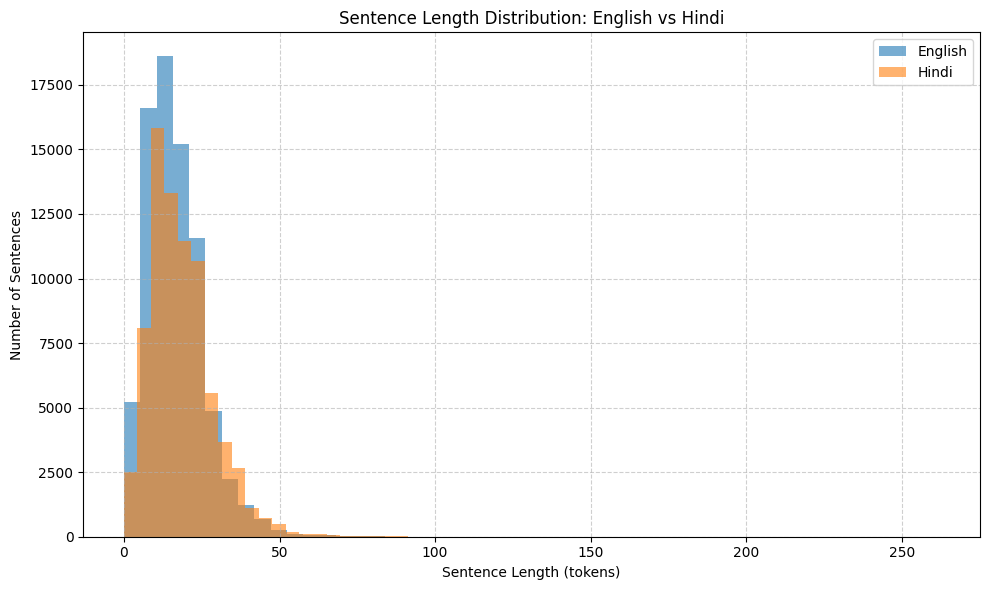

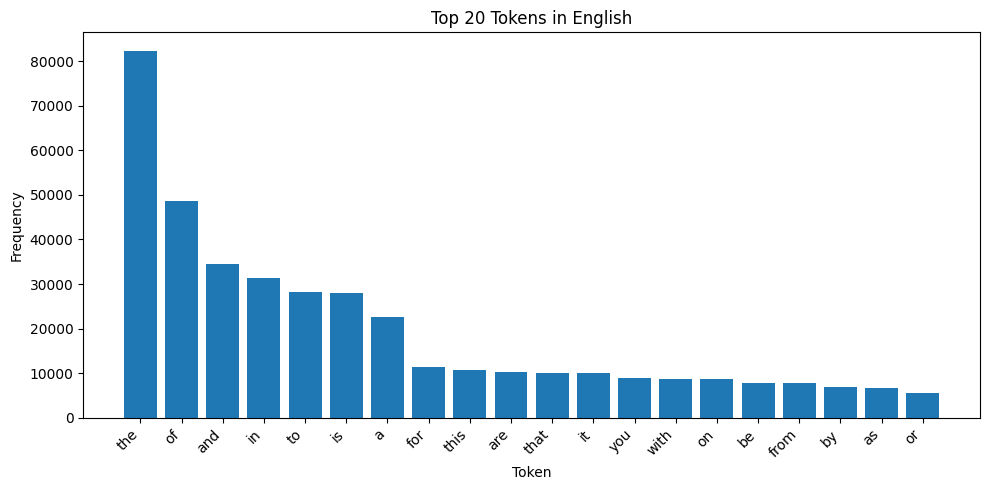


--- Corpus Analysis Complete ---


In [ ]:
print("\n--- Running Corpus Analysis ---")

# Compute statistics for training data
stats_train = compute_corpus_stats(
    en_tokens_train,
    hi_tokens_train,
    src_vocab=en_word2index,
    tgt_vocab=hi_word2index,
    src_lang='English',
    tgt_lang='Hindi'
)

# Plot sentence length distributions
plot_sentence_length_distribution(en_tokens_train, hi_tokens_train, 'English', 'Hindi')

# Plot top tokens
plot_top_tokens(en_tokens_train, 'English', top_n=20)
# plot_top_tokens(hi_tokens_train, 'Hindi', top_n=20)

print("\n--- Corpus Analysis Complete ---")

✅ Loaded 80797 English-Hindi validation sentence pairs.
ID range: 424714 to 505510

📊 Sentence Length Summary:
            src_len       tgt_len     len_ratio
count  80797.000000  80797.000000  80797.000000
mean      96.306113     94.066748      1.000238
std       55.104999     55.247644      0.594382
min        1.000000      1.000000      0.004082
25%       57.000000     54.000000      0.867647
50%       88.000000     85.000000      0.967213
75%      126.000000    123.000000      1.084211
max     1854.000000   1203.000000    149.000000


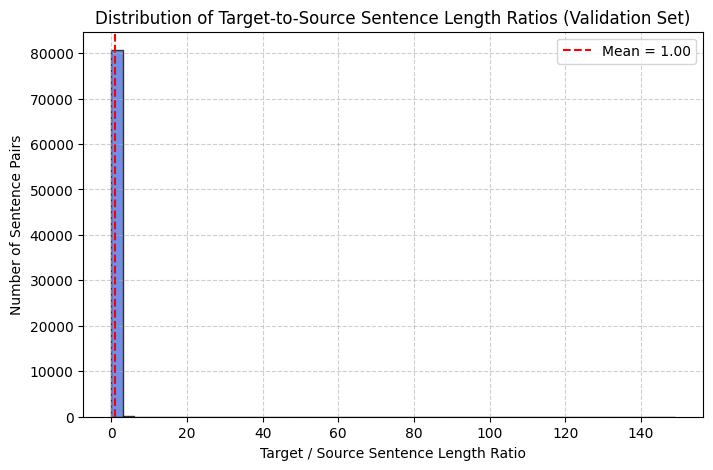


⚠️ Found 1073 potential outlier pairs (ratio < 0.5 or > 2.0).
                                               English  \
9    While taking bath take bath by keeping the mou...   
16                                   I created a star.   
36   The Copenhagen Consensus is a project that see...   
163  CDI publishes occasional reports on some natio...   
213  Ilaveezhapoonchira - 55 km from Kottayam, 20 k...   

                                                 Hindi  len_ratio  
9    सुबह बिना कुल्ला किए पानी पीकर शौच जाने से पेट...   0.496894  
16            इसे देखें, देखें मैंने एक स्टार बनाया है   2.352941  
36   कुपोषण के उच्चतम और निम्नतम स्तर के साथ बिहार ...   0.380368  
163  वेबसाइट का संक्रामक रोग निरीक्षण वाला भाग संक्...   0.326772  
213      हिरनों की प्रसिद्ध प्रजातियां भी दर्शनीय हैं।   0.298013  


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# --- Load the data ---
with open('/kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json', 'r', encoding='utf-8') as f:
    data_json = json.load(f)

# --- Extract English-Hindi validation data ---
# Expected structure:
# {
#   "English-Hindi": {
#       "Validation": {
#           "0": {"source": "This is an example.", "target": "यह एक उदाहरण है।"},
#           "1": {"source": "...", "target": "..."},
#       }
#   }
# }

validation_data = data_json.get("English-Hindi", {}).get("Train", {})

# --- Convert JSON into DataFrame ---
data_pairs = []
for id_key, content in validation_data.items():
    src_text = content.get("source", "").strip()
    tgt_text = content.get("target", "").strip()
    if src_text and tgt_text:  # skip empty entries
        data_pairs.append({
            "ID": int(id_key),
            "English": src_text,
            "Hindi": tgt_text
        })

df = pd.DataFrame(data_pairs)
print(f" Loaded {len(df)} English-Hindi validation sentence pairs.")
print(f"ID range: {df['ID'].min()} to {df['ID'].max()}")

# --- Compute character lengths ---
df["src_len"] = df["English"].apply(len)
df["tgt_len"] = df["Hindi"].apply(len)

# --- Compute ratio (Target / Source) ---
df = df[df["src_len"] > 0]  # avoid division by zero
df["len_ratio"] = df["tgt_len"] / df["src_len"]

# --- Summary statistics ---
print("\n Sentence Length Summary:")
print(df[["src_len", "tgt_len", "len_ratio"]].describe())

# --- Plot histogram of ratios ---
plt.figure(figsize=(8, 5))
plt.hist(df["len_ratio"], bins=50, color='royalblue', alpha=0.75, edgecolor='black')

plt.axvline(df["len_ratio"].mean(), color='red', linestyle='--', label=f"Mean = {df['len_ratio'].mean():.2f}")
plt.xlabel("Target / Source Sentence Length Ratio")
plt.ylabel("Number of Sentence Pairs")
plt.title("Distribution of Target-to-Source Sentence Length Ratios (Validation Set)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Optional: Identify outliers ---
low_thresh, high_thresh = 0.5, 2.0
outliers = df[(df["len_ratio"] < low_thresh) | (df["len_ratio"] > high_thresh)]
print(f"\n Found {len(outliers)} potential outlier pairs (ratio < {low_thresh} or > {high_thresh}).")
print(outliers.head(5)[["English", "Hindi", "len_ratio"]])

In [ ]:
import json
from collections import Counter

def compute_oov_rate(train_file, test_file, lang_pair="English-Hindi"):
    """
    Computes Out-Of-Vocabulary (OOV) rate for test sentences
    relative to the English vocabulary from training data.

    Args:
        train_file (str): Path to training JSON (with 'source'/'target')
        test_file (str): Path to test JSON (English-only)
        lang_pair (str): Language pair key (e.g., 'English-Hindi' or 'English-Bengali')
    """

    # --- Load train data ---
    with open(train_file, 'r', encoding='utf-8') as f:
        train_data = json.load(f)

    train_section = train_data.get(lang_pair, {}).get("Train", {})
    train_sentences = [entry["source"].strip().lower() for entry in train_section.values()]
    print(f" Loaded {len(train_sentences)} training English sentences")

    # --- Build English vocabulary from training data ---
    train_vocab = set()
    for sent in train_sentences:
        train_vocab.update(sent.split())
    print(f" Training vocabulary size: {len(train_vocab)}")

    # --- Load test data ---
    with open(test_file, 'r', encoding='utf-8') as f:
        test_data = json.load(f)

    test_section = test_data.get(lang_pair, {}).get("Test", {})
    test_sentences = [entry["source"].strip().lower() for entry in test_section.values()]
    print(f" Loaded {len(test_sentences)} test English sentences")

    # --- Compute OOV statistics ---
    total_tokens = 0
    oov_tokens = 0

    for sent in test_sentences:
        tokens = sent.split()
        total_tokens += len(tokens)
        for tok in tokens:
            if tok not in train_vocab:
                oov_tokens += 1

    oov_rate = (oov_tokens / total_tokens) * 100
    print(f"\n OOV Analysis for {lang_pair}")
    print(f"Total test tokens: {total_tokens}")
    print(f"OOV tokens: {oov_tokens}")
    print(f"OOV Rate: {oov_rate:.2f}%")

    return oov_rate

In [ ]:
compute_oov_rate(
    train_file="/kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json",
    test_file="/kaggle/input/capstone/test_data1_final.json",
    lang_pair="English-Hindi"
)

 Loaded 80797 training English sentences
 Training vocabulary size: 90492
 Loaded 23085 test English sentences

 OOV Analysis for English-Hindi
Total test tokens: 394394
OOV tokens: 15030
OOV Rate: 3.81%


3.8109099022804607

In [ ]:
compute_oov_rate(
    train_file="/kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json",
    test_file="/kaggle/input/capstone/test_data1_final.json",
    lang_pair="English-Bengali"
)

 Loaded 68849 training English sentences
 Training vocabulary size: 81412
 Loaded 19672 test English sentences

 OOV Analysis for English-Bengali
Total test tokens: 333097
OOV tokens: 13631
OOV Rate: 4.09%


4.092201370771877

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 2. ENCODING & PADDING FUNCTION (From Starter Code)

def encode_and_pad_sentence(tokens, vocab, max_length):
    """
    Takes a list of tokens, converts them to numerical IDs,
    and pads/truncates to a fixed max_length.

    This function correctly adds the <SOS> and <EOS> tokens
    numerically, which fixes the bug we found in Part 2.
    """
    # Get numerical IDs for the special tokens
    sos_idx = vocab.get(config.SOS_TOKEN, config.UNK_IDX)
    eos_idx = vocab.get(config.EOS_TOKEN, config.UNK_IDX)
    pad_idx = vocab.get(config.PAD_TOKEN, config.UNK_IDX)
    unk_idx = vocab.get(config.UNK_IDX, config.UNK_IDX) # Fallback for UNK

    # Start with <SOS> token
    numericalized_tokens = [sos_idx]

    # Add tokens from sentence
    for token in tokens:
        numericalized_tokens.append(vocab.get(token, unk_idx))

    # Add <EOS> token
    numericalized_tokens.append(eos_idx)

    # Pad or truncate
    if len(numericalized_tokens) < max_length:
        # Pad
        num_pads = max_length - len(numericalized_tokens)
        padded_tokens = numericalized_tokens + ([pad_idx] * num_pads)
    else:
        # Truncate (while keeping <EOS> at the end)
        truncated_tokens = numericalized_tokens[:max_length - 1]
        padded_tokens = truncated_tokens + [eos_idx]

    return padded_tokens

def create_dataloaders(config,
                       en_tokens_train, hi_tokens_train,
                       en_tokens_val, hi_tokens_val,
                       en_word2index, hi_word2index):
    """
    Main function to create the training and validation DataLoaders.
    """

    print("\n--- Part 3: Creating DataLoaders ---")

    # --- 1. Encode and Pad Training Data ---
    print(f"Encoding {len(en_tokens_train)} training sentences...")

    train_x_encoded = [
        encode_and_pad_sentence(tokens, en_word2index, config.SEQ_LENGTH)
        for tokens in en_tokens_train
    ]
    train_y_encoded = [
        encode_and_pad_sentence(tokens, hi_word2index, config.SEQ_LENGTH)
        for tokens in hi_tokens_train
    ]

    # --- 2. Encode and Pad Validation Data ---
    print(f"Encoding {len(en_tokens_val)} validation sentences...")
    val_x_encoded = [
        encode_and_pad_sentence(tokens, en_word2index, config.SEQ_LENGTH)
        for tokens in en_tokens_val
    ]
    val_y_encoded = [
        encode_and_pad_sentence(tokens, hi_word2index, config.SEQ_LENGTH)
        for tokens in hi_tokens_val
    ]

    # --- 3. Convert to Tensors (via numpy) ---
    print("Converting to PyTorch Tensors...")
    train_x_tensor = torch.from_numpy(np.array(train_x_encoded)).long()
    train_y_tensor = torch.from_numpy(np.array(train_y_encoded)).long()

    val_x_tensor = torch.from_numpy(np.array(val_x_encoded)).long()
    val_y_tensor = torch.from_numpy(np.array(val_y_encoded)).long()

    # --- 4. Create TensorDatasets ---
    train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
    val_dataset = TensorDataset(val_x_tensor, val_y_tensor)

    # --- 5. Create DataLoaders ---
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

    val_dataloader = DataLoader(
        val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False, # No need to shuffle validation
        drop_last=False
    )

    print("Train and Validation DataLoaders created.")

    # --- 6. Show an example from the dataloader ---
    try:
        example_src_batch, example_tgt_batch = next(iter(train_dataloader))
        print(f"\nExample train batch shape (SRC): {example_src_batch.shape}")
        print(f"Example train batch shape (TGT): {example_tgt_batch.shape}")

        print("\nExample numericalized source sentence (from batch):")
        print(example_src_batch[0])

        print("\nExample numericalized target sentence (from batch):")
        print(example_tgt_batch[0])
    except Exception as e:
        print(f"Could not show dataloader example: {e}")

    return train_dataloader, val_dataloader

def create_test_dataloader(config, en_tokens_test, test_ids, en_word2index):
    """
    Creates the TEST (submission) DataLoader.
    This one only contains the source (x) data.
    """

    print("\n--- Part 3: Creating Test DataLoader ---")

    # --- 1. Encode and Pad Test Data ---
    print(f"Encoding {len(en_tokens_test)} test sentences...")

    test_x_encoded = [
        encode_and_pad_sentence(tokens, en_word2index, config.SEQ_LENGTH)
        for tokens in en_tokens_test
    ]

    # --- 2. Convert to Tensors (via numpy) ---
    test_x_tensor = torch.from_numpy(np.array(test_x_encoded)).long()

    # --- 3. Create TensorDataset ---
    # We use the test_ids as the "y" for now, just to keep them
    # paired with the sentences. This is a common trick.
    # We will ignore them during encoding, but use them for the CSV.
    test_dataset = TensorDataset(test_x_tensor, torch.arange(len(test_ids)))

    # --- 4. Create DataLoader ---
    test_dataloader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False, # Must NOT shuffle test
        drop_last=False
    )

    print("Test (Submission) DataLoader created.")

    return test_dataloader, test_ids # Pass test_ids just in case

In [ ]:
# # ----------------------------------------------------------------------------
# # 1. IMPORTS
# # ----------------------------------------------------------------------------
# import torch
# from torch.utils.data import DataLoader, TensorDataset
# import numpy as np

# # ----------------------------------------------------------------------------
# # 2. ENCODING & PADDING FUNCTION
# # ----------------------------------------------------------------------------
# def encode_and_pad_sentence(tokens, vocab, max_length):
#     """
#     Convert tokens to IDs and pad/truncate to fixed max_length.
#     Adds <SOS> and <EOS> tokens numerically.
#     """
#     sos_idx = vocab.get(config.SOS_TOKEN, config.UNK_IDX)
#     eos_idx = vocab.get(config.EOS_TOKEN, config.UNK_IDX)
#     pad_idx = vocab.get(config.PAD_TOKEN, config.UNK_IDX)
#     unk_idx = vocab.get(config.UNK_TOKEN, config.UNK_IDX)

#     numericalized_tokens = [sos_idx]
#     for token in tokens:
#         numericalized_tokens.append(vocab.get(token, unk_idx))
#     numericalized_tokens.append(eos_idx)

#     # Pad/truncate
#     if len(numericalized_tokens) < max_length:
#         num_pads = max_length - len(numericalized_tokens)
#         padded_tokens = numericalized_tokens + ([pad_idx] * num_pads)
#     else:
#         truncated_tokens = numericalized_tokens[:max_length - 1]
#         padded_tokens = truncated_tokens + [eos_idx]

#     return padded_tokens

# # ----------------------------------------------------------------------------
# # 3. MAIN DATALOADER CREATION (UPDATED for POS)
# # ----------------------------------------------------------------------------
# def create_dataloaders(config,
#                        en_tokens_train, en_pos_train, hi_tokens_train,
#                        en_tokens_val, en_pos_val, hi_tokens_val,
#                        en_word2index, pos_word2index, hi_word2index):
#     """
#     Create DataLoaders for training and validation sets.
#     Each batch yields (src_batch, src_pos_batch, tgt_batch).
#     """
#     print("\n--- Part 3: Creating DataLoaders (POS + Tokens) ---")

#     # --- 1. Encode and Pad Training Data ---
#     print(f"Encoding {len(en_tokens_train)} training sentences...")
#     train_src_encoded = [
#         encode_and_pad_sentence(tokens, en_word2index, config.SEQ_LENGTH)
#         for tokens in en_tokens_train
#     ]
#     train_pos_encoded = [
#         encode_and_pad_sentence(tags, pos_word2index, config.SEQ_LENGTH)
#         for tags in en_pos_train
#     ]
#     train_tgt_encoded = [
#         encode_and_pad_sentence(tokens, hi_word2index, config.SEQ_LENGTH)
#         for tokens in hi_tokens_train
#     ]

#     # --- 2. Encode and Pad Validation Data ---
#     print(f"Encoding {len(en_tokens_val)} validation sentences...")
#     val_src_encoded = [
#         encode_and_pad_sentence(tokens, en_word2index, config.SEQ_LENGTH)
#         for tokens in en_tokens_val
#     ]
#     val_pos_encoded = [
#         encode_and_pad_sentence(tags, pos_word2index, config.SEQ_LENGTH)
#         for tags in en_pos_val
#     ]
#     val_tgt_encoded = [
#         encode_and_pad_sentence(tokens, hi_word2index, config.SEQ_LENGTH)
#         for tokens in hi_tokens_val
#     ]

#     # --- 3. Convert to PyTorch Tensors ---
#     print("Converting to PyTorch Tensors...")
#     train_src_tensor = torch.from_numpy(np.array(train_src_encoded)).long()
#     train_pos_tensor = torch.from_numpy(np.array(train_pos_encoded)).long()
#     train_tgt_tensor = torch.from_numpy(np.array(train_tgt_encoded)).long()

#     val_src_tensor = torch.from_numpy(np.array(val_src_encoded)).long()
#     val_pos_tensor = torch.from_numpy(np.array(val_pos_encoded)).long()
#     val_tgt_tensor = torch.from_numpy(np.array(val_tgt_encoded)).long()

#     # --- 4. Create TensorDatasets ---
#     train_dataset = TensorDataset(train_src_tensor, train_pos_tensor, train_tgt_tensor)
#     val_dataset = TensorDataset(val_src_tensor, val_pos_tensor, val_tgt_tensor)

#     # --- 5. Create DataLoaders ---
#     train_dataloader = DataLoader(
#         train_dataset,
#         batch_size=config.BATCH_SIZE,
#         shuffle=True,
#         drop_last=True
#     )
#     val_dataloader = DataLoader(
#         val_dataset,
#         batch_size=config.BATCH_SIZE,
#         shuffle=False,
#         drop_last=False
#     )

#     print("Train and Validation DataLoaders created successfully.")

#     # --- 6. Show example shapes ---
#     try:
#         example_src, example_pos, example_tgt = next(iter(train_dataloader))
#         print(f"\nExample batch shapes:")
#         print(f"SRC: {example_src.shape}, POS: {example_pos.shape}, TGT: {example_tgt.shape}")
#         print("\nExample numericalized source tokens:")
#         print(example_src[0])
#         print("\nExample numericalized POS tags:")
#         print(example_pos[0])
#         print("\nExample numericalized target tokens:")
#         print(example_tgt[0])
#     except Exception as e:
#         print(f"Could not show example batch: {e}")

#     return train_dataloader, val_dataloader

# # ----------------------------------------------------------------------------
# # 4. TEST DATALOADER CREATION (UPDATED for POS)
# # ----------------------------------------------------------------------------
# def create_test_dataloader(config, en_tokens_test, en_pos_test, test_ids, en_word2index, pos_word2index):
#     """
#     Create DataLoader for test (submission) data.
#     Each batch yields (src_batch, src_pos_batch, dummy_ids).
#     """
#     print("\n--- Part 3: Creating Test DataLoader (POS + Tokens) ---")
#     print(f"Encoding {len(en_tokens_test)} test sentences...")

#     test_src_encoded = [
#         encode_and_pad_sentence(tokens, en_word2index, config.SEQ_LENGTH)
#         for tokens in en_tokens_test
#     ]
#     test_pos_encoded = [
#         encode_and_pad_sentence(tags, pos_word2index, config.SEQ_LENGTH)
#         for tags in en_pos_test
#     ]

#     # Convert to Tensors
#     test_src_tensor = torch.from_numpy(np.array(test_src_encoded)).long()
#     test_pos_tensor = torch.from_numpy(np.array(test_pos_encoded)).long()

#     # Pair with dummy indices (for test IDs)
#     test_dataset = TensorDataset(test_src_tensor, test_pos_tensor, torch.arange(len(test_ids)))

#     test_dataloader = DataLoader(
#         test_dataset,
#         batch_size=config.BATCH_SIZE,
#         shuffle=False,
#         drop_last=False
#     )

#     print("Test DataLoader created.")
#     return test_dataloader, test_ids


In [ ]:
# --- Run Part 3 ---
train_dataloader, val_dataloader = create_dataloaders(
    config,
    en_tokens_train, hi_tokens_train,
    en_tokens_val, hi_tokens_val,
    en_word2index, hi_word2index
)

test_dataloader, _ = create_test_dataloader(
    config, en_tokens_test, test_ids, en_word2index
)


--- Part 3: Creating DataLoaders ---
Encoding 76758 training sentences...
Encoding 4039 validation sentences...
Converting to PyTorch Tensors...
Train and Validation DataLoaders created.

Example train batch shape (SRC): torch.Size([50, 36])
Example train batch shape (TGT): torch.Size([50, 36])

Example numericalized source sentence (from batch):
tensor([    1,  4190,   228,    54,  6800,  5780,    19,  1746, 20745,     2,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0])

Example numericalized target sentence (from batch):
tensor([    1,  5053,  8051,     3,   521, 24987,     3,    12,   115,   249,
           21,    36,     2,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0])

--- Part 3: Creating Test 

In [ ]:

# # ----------------------------------------------------------------------------
# # 5. EXECUTION EXAMPLE
# # ----------------------------------------------------------------------------
# train_dataloader, val_dataloader = create_dataloaders(
#     config,
#     en_tokens_train, en_pos_train, hi_tokens_train,
#     en_tokens_val, en_pos_val, hi_tokens_val,
#     en_word2index, pos_word2index, hi_word2index
# )

# test_dataloader, _ = create_test_dataloader(
#     config,
#     en_tokens_test, en_pos_test, test_ids,
#     en_word2index, pos_word2index
# )



--- Part 3: Creating DataLoaders (POS + Tokens) ---
Encoding 76758 training sentences...
Encoding 4039 validation sentences...
Converting to PyTorch Tensors...
Train and Validation DataLoaders created successfully.

Example batch shapes:
SRC: torch.Size([50, 32]), POS: torch.Size([50, 32]), TGT: torch.Size([50, 32])

Example numericalized source tokens:
tensor([   1,   17, 1808,   12, 1150,  696, 8509, 4704,   43,    2,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Example numericalized POS tags:
tensor([ 1, 10,  7,  9,  5, 16,  8,  7, 12,  2,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

Example numericalized target tokens:
tensor([   1, 6300, 4344,  516, 8679, 3398,   21,   36,    2,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0, 

In [ ]:
import torch
import torch.nn as nn
import math

# 2. SCALED DOT-PRODUCT ATTENTION (Function)

def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):
    """
    Implements the core "Scaled Dot-Product Attention"

    Args:
        query (Tensor): Q, shape [batch_size, num_heads, seq_len_q, d_k]
        key (Tensor): K, shape [batch_size, num_heads, seq_len_k, d_k]
        value (Tensor): V, shape [batch_size, num_heads, seq_len_v, d_v]
                       (Note: seq_len_k == seq_len_v)
        mask (Tensor, optional): Mask to apply. Shape [batch_size, 1, 1, seq_len_k]
                                 for padding, or [batch_size, 1, seq_len_q, seq_len_k]
                                 for look-ahead. Defaults to None.
        dropout (nn.Dropout, optional): Dropout layer. Defaults to None.

    Returns:
        Tensor: The context vector (output), shape [batch_size, num_heads, seq_len_q, d_v]
        Tensor: The attention weights, shape [batch_size, num_heads, seq_len_q, seq_len_k]
    """

    # 1. Get embedding dimension (d_k) from the query
    d_k = query.size(-1)

    # 2. Calculate scores: (Q * K^T) / sqrt(d_k)
    # [b, h, q_len, d_k] @ [b, h, d_k, k_len] -> [b, h, q_len, k_len]
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    # 3. Apply mask (if provided)
    # The mask tells us where to put -1e9 (a very small number)
    # This makes the softmax output 0 for those positions.
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # 4. Apply softmax to get attention weights
    # Softmax is applied on the last dimension (k_len)
    attention_weights = torch.softmax(scores, dim=-1)

    # 5. Apply dropout (if provided)
    if dropout is not None:
        attention_weights = dropout(attention_weights)

    # 6. Get context vector: (Attention * V)
    # [b, h, q_len, k_len] @ [b, h, v_len, d_v] -> [b, h, q_len, d_v]
    # (Note: k_len == v_len)
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

# 3. MULTI-HEAD ATTENTION (Module)

class MultiHeadAttention(nn.Module):
    """
    Implements the "Multi-Head Attention" module.

    This module:
    1. Takes query, key, and value.
    2. Projects them using linear layers (W_q, W_k, W_v).
    3. Splits the projections into `num_heads`.
    4. Applies scaled dot-product attention.
    5. Concatenates the heads.
    6. Applies a final linear layer (W_o).
    """
    def __init__(self, d_model, num_heads, dropout_rate):
        """
        Args:
            d_model (int): The embedding dimension (e.g., 512)
            num_heads (int): Number of heads (e.g., 8)
            dropout_rate (float): Dropout probability
        """
        super(MultiHeadAttention, self).__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # Dimension of each head

        # Define the 4 linear layers
        self.W_q = nn.Linear(d_model, d_model) # Query projection
        self.W_k = nn.Linear(d_model, d_model) # Key projection
        self.W_v = nn.Linear(d_model, d_model) # Value projection
        self.W_o = nn.Linear(d_model, d_model) # Output projection

        self.dropout = nn.Dropout(dropout_rate)

    def split_heads(self, x, batch_size):
        """
        Splits the last dimension `d_model` into `num_heads` and `d_k`.

        Args:
            x (Tensor): Input tensor, shape [batch_size, seq_len, d_model]

        Returns:
            Tensor: Reshaped tensor, shape [batch_size, num_heads, seq_len, d_k]
        """
        # Reshape to [batch_size, seq_len, num_heads, d_k]
        x = x.view(batch_size, -1, self.num_heads, self.d_k)

        # Transpose to [batch_size, num_heads, seq_len, d_k]
        return x.transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        """
        Forward pass for Multi-Head Attention.

        Args:
            query (Tensor): Q, shape [batch_size, seq_len_q, d_model]
            key (Tensor): K, shape [batch_size, seq_len_k, d_model]
            value (Tensor): V, shape [batch_size, seq_len_v, d_model]
            mask (Tensor, optional): Mask to apply. Defaults to None.

        Returns:
            Tensor: Output, shape [batch_size, seq_len_q, d_model]
        """
        batch_size = query.size(0)

        # 1. Pass Q, K, V through their linear layers
        # [b, seq_len, d_model] -> [b, seq_len, d_model]
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # 2. Split heads
        # [b, seq_len, d_model] -> [b, num_heads, seq_len, d_k]
        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        # 3. Apply scaled dot-product attention
        # context shape: [b, num_heads, seq_len_q, d_k]
        # attention_weights shape: [b, num_heads, seq_len_q, seq_len_k]
        context, attention_weights = scaled_dot_product_attention(
            Q, K, V, mask, self.dropout
        )

        # 4. Concatenate heads
        # First, transpose context back to [b, seq_len_q, num_heads, d_k]
        context = context.transpose(1, 2).contiguous()

        # Now, reshape to [b, seq_len_q, d_model]
        context = context.view(batch_size, -1, self.d_model)

        # 5. Pass through the final output linear layer
        # [b, seq_len_q, d_model] -> [b, seq_len_q, d_model]
        output = self.W_o(context)

        return output

In [ ]:
# ### transliteration

# import torch
# import torch.nn as nn
# import math

# # ----------------------------------------------------------------------------
# # 1. SCALED DOT-PRODUCT ATTENTION
# # ----------------------------------------------------------------------------
# def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):
#     """
#     Computes Scaled Dot-Product Attention.

#     Args:
#         query: [batch_size, num_heads, seq_len_q, d_k]
#         key: [batch_size, num_heads, seq_len_k, d_k]
#         value: [batch_size, num_heads, seq_len_v, d_v]
#         mask: Optional tensor for masking (0 = mask, 1 = keep)
#         dropout: Optional dropout layer

#     Returns:
#         output: [batch_size, num_heads, seq_len_q, d_v]
#         attention_weights: [batch_size, num_heads, seq_len_q, seq_len_k]
#     """
#     d_k = query.size(-1)
#     scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

#     if mask is not None:
#         # Ensure the mask shape matches and fill masked positions
#         scores = scores.masked_fill(mask == 0, -1e9)

#     attention_weights = torch.softmax(scores, dim=-1)

#     if dropout is not None:
#         attention_weights = dropout(attention_weights)

#     output = torch.matmul(attention_weights, value)
#     return output, attention_weights


# # ----------------------------------------------------------------------------
# # 2. MULTI-HEAD ATTENTION (Modified to optionally return attention weights)
# # ----------------------------------------------------------------------------
# class MultiHeadAttention(nn.Module):
#     """
#     Implements Multi-Head Attention with optional return of attention weights.
#     """
#     def __init__(self, d_model, num_heads, dropout_rate):
#         super(MultiHeadAttention, self).__init__()

#         assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

#         self.d_model = d_model
#         self.num_heads = num_heads
#         self.d_k = d_model // num_heads

#         # Linear projections
#         self.W_q = nn.Linear(d_model, d_model)
#         self.W_k = nn.Linear(d_model, d_model)
#         self.W_v = nn.Linear(d_model, d_model)
#         self.W_o = nn.Linear(d_model, d_model)

#         self.dropout = nn.Dropout(dropout_rate)

#     def split_heads(self, x, batch_size):
#         """
#         Splits embedding dimension into multiple heads.
#         Input: [batch_size, seq_len, d_model]
#         Output: [batch_size, num_heads, seq_len, d_k]
#         """
#         x = x.view(batch_size, -1, self.num_heads, self.d_k)
#         return x.transpose(1, 2)

#     def forward(self, query, key, value, mask=None, return_weights=False):
#         """
#         Forward pass for Multi-Head Attention.

#         Args:
#             query: [batch_size, seq_len_q, d_model]
#             key: [batch_size, seq_len_k, d_model]
#             value: [batch_size, seq_len_v, d_model]
#             mask: Optional mask tensor (0 for masked positions)
#             return_weights (bool): If True, also return attention weights.

#         Returns:
#             If return_weights=False:
#                 output: [batch_size, seq_len_q, d_model]
#             If return_weights=True:
#                 (output, attention_weights)
#         """
#         batch_size = query.size(0)

#         # 1. Linear projections
#         Q = self.W_q(query)
#         K = self.W_k(key)
#         V = self.W_v(value)

#         # 2. Split into heads
#         Q = self.split_heads(Q, batch_size)
#         K = self.split_heads(K, batch_size)
#         V = self.split_heads(V, batch_size)

#         # 3. Compute attention
#         context, attention_weights = scaled_dot_product_attention(Q, K, V, mask, self.dropout)

#         # 4. Concatenate heads
#         context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

#         # 5. Final linear projection
#         output = self.W_o(context)

#         if return_weights:
#             # attention_weights: [batch_size, num_heads, seq_len_q, seq_len_k]
#             return output, attention_weights
#         else:
#             return output


In [ ]:
import torch
import torch.nn as nn
import math

# 2. POSITION-WISE FEED-FORWARD NETWORK (Module)

class PositionwiseFeedForward(nn.Module):
    """
    Implements the Position-wise Feed-Forward Network (FFN).

    This is a simple two-layer fully-connected network applied to each
    position (token) independently.

    FFN(x) = max(0, x * W_1 + b_1) * W_2 + b_2
    (Which is: Linear -> ReLU -> Dropout -> Linear -> Dropout)
    """
    def __init__(self, d_model, d_ff, dropout_rate):
        """
        Args:
            d_model (int): Input/output dimension (e.g., 512)
            d_ff (int): Inner dimension (e.g., 2048)
            dropout_rate (float): Dropout probability
        """
        super(PositionwiseFeedForward, self).__init__()

        self.linear_1 = nn.Linear(d_model, d_ff)
        self.linear_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        Args:
            x (Tensor): Input tensor, shape [batch_size, seq_len, d_model]

        Returns:
            Tensor: Output tensor, shape [batch_size, seq_len, d_model]
        """
        # [b, seq_len, d_model] -> [b, seq_len, d_ff]
        x = self.relu(self.linear_1(x))

        # Apply dropout
        x = self.dropout(x)

        # [b, seq_len, d_ff] -> [b, seq_len, d_model]
        x = self.linear_2(x)

        return x

# 3. POSITIONAL ENCODING (Module)

class PositionalEncoding(nn.Module):
    """
    Implements the sinusoidal Positional Encoding.

    This module injects information about the relative or absolute position
    of the tokens in the sequence. The positional encodings have the same
    dimension (d_model) as the embeddings, so they can be summed.

    PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """
    def __init__(self, d_model, dropout_rate, max_len=5000):
        """
        Args:
            d_model (int): Embedding dimension (e.g., 512)
            dropout_rate (float): Dropout probability
            max_len (int): Max sequence length to pre-compute.
        """
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout_rate)

        # --- Create the positional encoding matrix ---

        # Shape: [max_len, d_model]
        pe = torch.zeros(max_len, d_model)

        # Position tensor, shape: [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Denominator term in the formulas
        # This creates the 1 / 10000^(2i / d_model) part
        # Shape: [d_model/2]
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * \
                             (-math.log(10000.0) / d_model))

        # Apply sin to even indices (2i)
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cos to odd indices (2i+1)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add a batch dimension so it can be broadcasted
        # Shape: [1, max_len, d_model]
        pe = pe.unsqueeze(0)

        # Register 'pe' as a buffer. This makes it part of the module's
        # state, but not a parameter that requires gradients.
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x (Tensor): Input tensor (the embeddings),
                        shape [batch_size, seq_len, d_model]

        Returns:
            Tensor: Output tensor (embeddings + positional encoding),
                    shape [batch_size, seq_len, d_model]
        """
        # x.size(1) is the sequence length (seq_len)
        # We take the pre-computed 'pe' matrix and slice it up to seq_len.
        # self.pe[:, :x.size(1), :] shape is [1, seq_len, d_model]
        # This is broadcasted with x [b, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :].requires_grad_(False)

        return self.dropout(x)

In [ ]:
import torch
import torch.nn as nn
import math

# # Import our custom modules from previous steps
# try:
#     from transformer_attention import MultiHeadAttention
#     from transformer_building_blocks import PositionwiseFeedForward, PositionalEncoding
# except ImportError:
#     print("ERROR: Ensure transformer_attention.py and transformer_building_blocks.py are in the same directory.")

# 2. ENCODER LAYER (Module)

class EncoderLayer(nn.Module):
    """
    Implements a single Encoder Layer.

    An EncoderLayer has two sub-layers:
    1. Multi-Head Self-Attention
    2. Position-wise Feed-Forward Network

    Each sub-layer is followed by a residual connection (Add) and
    Layer Normalization (Norm).
    """
    def __init__(self, d_model, num_heads, d_ff, dropout_rate):
        """
        Args:
            d_model (int): Embedding dimension (e.g., 512)
            num_heads (int): Number of attention heads (e.g., 8)
            d_ff (int): Inner dimension of FFN (e.g., 2048)
            dropout_rate (float): Dropout probability
        """
        super(EncoderLayer, self).__init__()

        # Sub-layer 1: Multi-Head Self-Attention
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout_rate)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout_rate)

        # Sub-layer 2: Position-wise Feed-Forward
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x, mask):
        """
        Forward pass for the EncoderLayer.

        Args:
            x (Tensor): Input tensor, shape [batch_size, seq_len, d_model]
            mask (Tensor): Source padding mask,
                           shape [batch_size, 1, 1, seq_len]

        Returns:
            Tensor: Output tensor, shape [batch_size, seq_len, d_model]
        """

        # --- Sub-layer 1: Self-Attention ---
        # 1.1. Compute attention
        # Q, K, V are all from the same input 'x'
        attn_output = self.self_attn(query=x, key=x, value=x, mask=mask)

        # 1.2. Add & Norm
        # x = x + self.dropout1(attn_output)
        # x = self.norm1(x)
        x = self.norm1(x + self.dropout1(attn_output)) # Pre-norm vs Post-norm

        # --- Sub-layer 2: Feed-Forward ---
        # 2.1. Compute feed-forward
        ff_output = self.feed_forward(x)

        # 2.2. Add & Norm
        # x = x + self.dropout2(ff_output)
        # x = self.norm2(x)
        x = self.norm2(x + self.dropout2(ff_output))

        return x

# 3. ENCODER (Module)

class Encoder(nn.Module):
    """
    Implements the full Encoder stack.

    It consists of:
    1. Input Embedding layer
    2. Positional Encoding
    3. A stack of N EncoderLayers
    """
    def __init__(self, vocab_size, d_model, num_layers, num_heads,
                 d_ff, dropout_rate, max_seq_len):
        """
        Args:
            vocab_size (int): Size of the source vocabulary
            d_model (int): Embedding dimension
            num_layers (int): Number of EncoderLayers to stack
            num_heads (int): Number of attention heads
            d_ff (int): Inner dimension of FFN
            dropout_rate (float): Dropout probability
            max_seq_len (int): Max sequence length (for PositionalEncoding)
        """
        super(Encoder, self).__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout_rate, max_len=max_seq_len)

        # Create a stack of N identical EncoderLayers
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout_rate)
             for _ in range(num_layers)]
        )

        self.dropout = nn.Dropout(dropout_rate)
        # The original paper uses a final LayerNorm
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask):
        """
        Forward pass for the Encoder.

        Args:
            x (Tensor): Source token indices, shape [batch_size, seq_len]
            mask (Tensor): Source padding mask,
                           shape [batch_size, 1, 1, seq_len]

        Returns:
            Tensor: Output tensor (encoded sequence),
                    shape [batch_size, seq_len, d_model]
        """

        # 1. Get embedding and scale it
        # (Scaling by sqrt(d_model) is done in the paper)
        x = self.embedding(x) * math.sqrt(self.d_model)

        # 2. Add positional encoding
        x = self.pos_encoding(x)

        # 3. Apply dropout
        x = self.dropout(x)

        # 4. Pass through all N layers
        for layer in self.layers:
            x = layer(x, mask)

        # 5. Apply final normalization
        # Some implementations apply norm inside the loop (Pre-LN)
        # We are using Post-LN as in the original paper.
        return self.norm(x)

In [ ]:
# # ----------------------------------------------------------------------------
# # 1. IMPORTS
# # ----------------------------------------------------------------------------
# import torch
# import torch.nn as nn
# import math

# # ----------------------------------------------------------------------------
# # 2. ENCODER LAYER (Unchanged)
# # ----------------------------------------------------------------------------

# class EncoderLayer(nn.Module):
#     def __init__(self, d_model, num_heads, d_ff, dropout_rate):
#         super(EncoderLayer, self).__init__()

#         self.self_attn = MultiHeadAttention(d_model, num_heads, dropout_rate)
#         self.norm1 = nn.LayerNorm(d_model)
#         self.dropout1 = nn.Dropout(dropout_rate)

#         self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
#         self.norm2 = nn.LayerNorm(d_model)
#         self.dropout2 = nn.Dropout(dropout_rate)

#     def forward(self, x, mask):
#         attn_output = self.self_attn(query=x, key=x, value=x, mask=mask)
#         x = self.norm1(x + self.dropout1(attn_output))
#         ff_output = self.feed_forward(x)
#         x = self.norm2(x + self.dropout2(ff_output))
#         return x

# # ----------------------------------------------------------------------------
# # 3. ENCODER (Modified to include POS embeddings)
# # ----------------------------------------------------------------------------

# class Encoder(nn.Module):
#     """
#     Modified Encoder that accepts both word and POS tag indices.
#     Embedding is: word_emb + pos_emb + positional_encoding
#     """
#     def __init__(self,
#                  vocab_size, pos_vocab_size,
#                  d_model, num_layers, num_heads,
#                  d_ff, dropout_rate, max_seq_len):
#         super(Encoder, self).__init__()

#         self.d_model = d_model

#         # --- Embedding layers ---
#         self.word_embedding = nn.Embedding(vocab_size, d_model)
#         self.pos_embedding = nn.Embedding(pos_vocab_size, d_model)

#         # --- Positional encoding ---
#         self.pos_encoding = PositionalEncoding(d_model, dropout_rate, max_len=max_seq_len)

#         # --- Encoder stack ---
#         self.layers = nn.ModuleList([
#             EncoderLayer(d_model, num_heads, d_ff, dropout_rate)
#             for _ in range(num_layers)
#         ])

#         self.dropout = nn.Dropout(dropout_rate)
#         self.norm = nn.LayerNorm(d_model)

#     def forward(self, src_tokens, src_pos_tags, mask):
#         """
#         Args:
#             src_tokens: Tensor [batch_size, seq_len] — source word indices
#             src_pos_tags: Tensor [batch_size, seq_len] — source POS tag indices
#             mask: Tensor [batch_size, 1, 1, seq_len] — padding mask
#         Returns:
#             Tensor [batch_size, seq_len, d_model] — encoded sequence
#         """
#         # --- 1. Word + POS embeddings ---
#         word_emb = self.word_embedding(src_tokens)
#         pos_emb = self.pos_embedding(src_pos_tags)

#         # Combine (element-wise addition)
#         x = word_emb + pos_emb

#         # Scale embeddings as in the original Transformer paper
#         x = x * math.sqrt(self.d_model)

#         # --- 2. Add positional encoding ---
#         x = self.pos_encoding(x)
#         x = self.dropout(x)

#         # --- 3. Pass through all encoder layers ---
#         for layer in self.layers:
#             x = layer(x, mask)

#         # --- 4. Final normalization ---
#         return self.norm(x)


In [ ]:
import torch
import torch.nn as nn
import math

# # Import our custom modules from previous steps
# try:
#     from transformer_attention import MultiHeadAttention
#     from transformer_building_blocks import PositionwiseFeedForward, PositionalEncoding
# except ImportError:
#     print("ERROR: Ensure transformer_attention.py and transformer_building_blocks.py are in the same directory.")

# 2. DECODER LAYER (Module)

class DecoderLayer(nn.Module):
    """
    Implements a single Decoder Layer.

    A DecoderLayer has three sub-layers:
    1. Masked Multi-Head Self-Attention (attends to the target sequence)
    2. Multi-Head Cross-Attention (attends to the encoder output)
    3. Position-wise Feed-Forward Network

    Each sub-layer is followed by a residual connection (Add) and
    Layer Normalization (Norm).
    """
    def __init__(self, d_model, num_heads, d_ff, dropout_rate):
        """
        Args:
            d_model (int): Embedding dimension (e.g., 512)
            num_heads (int): Number of attention heads (e.g., 8)
            d_ff (int): Inner dimension of FFN (e.g., 2048)
            dropout_rate (float): Dropout probability
        """
        super(DecoderLayer, self).__init__()

        # Sub-layer 1: Masked Multi-Head Self-Attention
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout_rate)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout_rate)

        # Sub-layer 2: Multi-Head Cross-Attention
        # Q is from the decoder, K and V are from the encoder output
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout_rate)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Sub-layer 3: Position-wise Feed-Forward
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout3 = nn.Dropout(dropout_rate)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        """
        Forward pass for the DecoderLayer.

        Args:
            x (Tensor): Input tensor (from previous decoder layer or embedding),
                        shape [batch_size, tgt_seq_len, d_model]
            encoder_output (Tensor): Output from the Encoder,
                                     shape [batch_size, src_seq_len, d_model]
            src_mask (Tensor): Source padding mask (from encoder),
                               shape [batch_size, 1, 1, src_seq_len]
            tgt_mask (Tensor): Target look-ahead + padding mask,
                               shape [batch_size, 1, tgt_seq_len, tgt_seq_len]

        Returns:
            Tensor: Output tensor, shape [batch_size, tgt_seq_len, d_model]
        """

        # --- Sub-layer 1: Masked Self-Attention ---
        # Q, K, V are all from the same input 'x'
        # We use the 'tgt_mask' to prevent attending to future tokens.
        attn_output = self.self_attn(query=x, key=x, value=x, mask=tgt_mask)
        x = self.norm1(x + self.dropout1(attn_output))

        # --- Sub-layer 2: Cross-Attention ---
        # Query is from the decoder (x), Key and Value are from the encoder.
        # We use the 'src_mask' to prevent attending to padding tokens
        # in the encoder's output.
        attn_output = self.cross_attn(query=x,
                                      key=encoder_output,
                                      value=encoder_output,
                                      mask=src_mask)
        x = self.norm2(x + self.dropout2(attn_output))

        # --- Sub-layer 3: Feed-Forward ---
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff_output))

        return x

# 3. DECODER (Module)

class Decoder(nn.Module):
    """
    Implements the full Decoder stack.

    It consists of:
    1. Output Embedding layer
    2. Positional Encoding
    3. A stack of N DecoderLayers
    """
    def __init__(self, vocab_size, d_model, num_layers, num_heads,
                 d_ff, dropout_rate, max_seq_len):
        """
        Args:
            vocab_size (int): Size of the target vocabulary
            d_model (int): Embedding dimension
            num_layers (int): Number of DecoderLayers to stack
            num_heads (int): Number of attention heads
            d_ff (int): Inner dimension of FFN
            dropout_rate (float): Dropout probability
            max_seq_len (int): Max sequence length (for PositionalEncoding)
        """
        super(Decoder, self).__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout_rate, max_len=max_seq_len)

        # Create a stack of N identical DecoderLayers
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, d_ff, dropout_rate)
             for _ in range(num_layers)]
        )

        self.dropout = nn.Dropout(dropout_rate)
        # Final LayerNorm
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        """
        Forward pass for the Decoder.

        Args:
            x (Tensor): Target token indices,
                        shape [batch_size, tgt_seq_len]
            encoder_output (Tensor): Output from the Encoder,
                                     shape [batch_size, src_seq_len, d_model]
            src_mask (Tensor): Source padding mask (from encoder),
                               shape [batch_size, 1, 1, src_seq_len]
            tgt_mask (Tensor): Target look-ahead + padding mask,
                               shape [batch_size, 1, tgt_seq_len, tgt_seq_len]

        Returns:
            Tensor: Output tensor (decoder logits, before final Linear layer),
                    shape [batch_size, tgt_seq_len, d_model]
        """

        # 1. Get embedding and scale it
        x = self.embedding(x) * math.sqrt(self.d_model)

        # 2. Add positional encoding
        x = self.pos_encoding(x)

        # 3. Apply dropout
        x = self.dropout(x)

        # 4. Pass through all N layers
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)

        # 5. Apply final normalization
        return self.norm(x)

In [ ]:
# ## Transliteration

# import torch
# import torch.nn as nn
# import math

# # ----------------------------------------------------------------------------
# # 1. DECODER LAYER (Modified to return cross-attention weights)
# # ----------------------------------------------------------------------------
# class DecoderLayer(nn.Module):
#     """
#     A single Decoder Layer with:
#     1. Masked Self-Attention
#     2. Cross-Attention (returns attention weights)
#     3. Feed-Forward Network
#     """
#     def __init__(self, d_model, num_heads, d_ff, dropout_rate):
#         super(DecoderLayer, self).__init__()

#         # 1. Masked Self-Attention
#         self.self_attn = MultiHeadAttention(d_model, num_heads, dropout_rate)
#         self.norm1 = nn.LayerNorm(d_model)
#         self.dropout1 = nn.Dropout(dropout_rate)

#         # 2. Cross-Attention (will return attn weights)
#         self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout_rate)
#         self.norm2 = nn.LayerNorm(d_model)
#         self.dropout2 = nn.Dropout(dropout_rate)

#         # 3. Feed-Forward
#         self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
#         self.norm3 = nn.LayerNorm(d_model)
#         self.dropout3 = nn.Dropout(dropout_rate)

#     def forward(self, x, encoder_output, src_mask, tgt_mask):
#         """
#         Forward pass for the DecoderLayer.

#         Args:
#             x: [batch_size, tgt_seq_len, d_model] — decoder input
#             encoder_output: [batch_size, src_seq_len, d_model]
#             src_mask: [batch_size, 1, 1, src_seq_len]
#             tgt_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]

#         Returns:
#             output: [batch_size, tgt_seq_len, d_model]
#             cross_attn_weights: [batch_size, num_heads, tgt_seq_len, src_seq_len]
#         """
#         # --- 1. Masked Self-Attention ---
#         self_attn_output = self.self_attn(query=x, key=x, value=x, mask=tgt_mask)
#         x = self.norm1(x + self.dropout1(self_attn_output))

#         # --- 2. Cross-Attention ---
#         # MultiHeadAttention now returns (attn_output, attn_weights)
#         cross_attn_output, cross_attn_weights = self.cross_attn(
#             query=x,
#             key=encoder_output,
#             value=encoder_output,
#             mask=src_mask,
#             return_weights=True  # we'll add this flag in MultiHeadAttention
#         )
#         x = self.norm2(x + self.dropout2(cross_attn_output))

#         # --- 3. Feed-Forward ---
#         ff_output = self.feed_forward(x)
#         x = self.norm3(x + self.dropout3(ff_output))

#         # Return both final output and cross-attention weights
#         return x, cross_attn_weights

# # ----------------------------------------------------------------------------
# # 2. DECODER (Modified to collect attention weights from final layer)
# # ----------------------------------------------------------------------------
# class Decoder(nn.Module):
#     """
#     Full Decoder stack.
#     Returns both decoder output and cross-attention weights from the final layer.
#     """
#     def __init__(self, vocab_size, d_model, num_layers, num_heads,
#                  d_ff, dropout_rate, max_seq_len):
#         super(Decoder, self).__init__()

#         self.d_model = d_model
#         self.embedding = nn.Embedding(vocab_size, d_model)
#         self.pos_encoding = PositionalEncoding(d_model, dropout_rate, max_len=max_seq_len)

#         self.layers = nn.ModuleList([
#             DecoderLayer(d_model, num_heads, d_ff, dropout_rate)
#             for _ in range(num_layers)
#         ])

#         self.dropout = nn.Dropout(dropout_rate)
#         self.norm = nn.LayerNorm(d_model)

#     def forward(self, x, encoder_output, src_mask, tgt_mask):
#         """
#         Args:
#             x: [batch_size, tgt_seq_len]
#             encoder_output: [batch_size, src_seq_len, d_model]
#             src_mask: [batch_size, 1, 1, src_seq_len]
#             tgt_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]

#         Returns:
#             decoder_output: [batch_size, tgt_seq_len, d_model]
#             cross_attn_weights: [batch_size, num_heads, tgt_seq_len, src_seq_len]
#         """
#         # --- 1. Embedding ---
#         x = self.embedding(x) * math.sqrt(self.d_model)

#         # --- 2. Positional Encoding ---
#         x = self.pos_encoding(x)
#         x = self.dropout(x)

#         # --- 3. Pass through decoder layers ---
#         cross_attn_weights = None
#         for i, layer in enumerate(self.layers):
#             x, cross_attn_weights = layer(x, encoder_output, src_mask, tgt_mask)

#         # --- 4. Final normalization ---
#         x = self.norm(x)

#         # --- 5. Return decoder output + final layer attention weights ---
#         return x, cross_attn_weights


In [ ]:
# import torch
# import torch.nn as nn
# import math

# # # Import our custom modules from previous steps
# # try:
# #     from transformer_encoder import Encoder
# #     from transformer_decoder import Decoder
# # except ImportError:
# #     print("ERROR: Ensure transformer_encoder.py and transformer_decoder.py are in the same directory.")

# # ----------------------------------------------------------------------------
# # 2. TRANSFORMER MODEL (Module)
# # ----------------------------------------------------------------------------

# class Transformer(nn.Module):
#     """
#     Implements the full Transformer (Encoder-Decoder) model.

#     It consists of:
#     1. An Encoder
#     2. A Decoder
#     3. A final Linear layer to project decoder output to the target vocab size.
#     """
#     def __init__(self,
#                  config,
#                  vocab_src_size,
#                  vocab_tgt_size,
#                  src_pad_idx,
#                  tgt_pad_idx
#                 ):
#         """
#         Args:
#             config (Config): Our configuration object with all hyperparameters.
#             vocab_src_size (int): Source (English) vocabulary size.
#             vocab_tgt_size (int): Target (Hindi) vocabulary size.
#             src_pad_idx (int): Source padding token ID.
#             tgt_pad_idx (int): Target padding token ID.
#         """
#         super(Transformer, self).__init__()

#         self.config = config
#         self.src_pad_idx = src_pad_idx
#         self.tgt_pad_idx = tgt_pad_idx

#         # 1. Initialize Encoder
#         self.encoder = Encoder(
#             vocab_size=vocab_src_size,
#             d_model=config.D_MODEL,
#             num_layers=config.NUM_ENCODER_LAYERS,
#             num_heads=config.N_HEADS,
#             d_ff=config.D_FF,
#             dropout_rate=config.DROPOUT,
#             max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
#         )

#         # 2. Initialize Decoder
#         self.decoder = Decoder(
#             vocab_size=vocab_tgt_size,
#             d_model=config.D_MODEL,
#             num_layers=config.NUM_DECODER_LAYERS,
#             num_heads=config.N_HEADS,
#             d_ff=config.D_FF,
#             dropout_rate=config.DROPOUT,
#             max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
#         )

#         # 3. Final output Linear layer
#         # This projects the decoder's [b, seq_len, d_model] output
#         # to [b, seq_len, vocab_tgt_size]
#         self.final_linear = nn.Linear(config.D_MODEL, vocab_tgt_size)

#         # Initialize weights
#         self._initialize_weights()

#     def _initialize_weights(self):
#         """
#         Applies Xavier/Glorot uniform initialization to all Linear and
#         Embedding layers. This is a common practice for Transformers.
#         """
#         if hasattr(self, 'final_linear'):
#             for name, p in self.named_parameters():
#                 if p.dim() > 1:
#                     nn.init.xavier_uniform_(p)
#         # Initialize embedding layers specifically
#         if hasattr(self, 'encoder') and hasattr(self.encoder, 'embedding'):
#             nn.init.xavier_uniform_(self.encoder.embedding.weight)
#         if hasattr(self, 'decoder') and hasattr(self.decoder, 'embedding'):
#             nn.init.xavier_uniform_(self.decoder.embedding.weight)

#     def create_src_mask(self, src):
#         """
#         Creates the source padding mask.
#         This mask hides padding tokens in the source sequence.

#         Args:
#             src (Tensor): Source token indices, shape [batch_size, src_seq_len]

#         Returns:
#             Tensor: Source mask, shape [batch_size, 1, 1, src_seq_len]
#         """
#         # src == self.src_pad_idx -> [b, src_seq_len] (True where pad)
#         # src != self.src_pad_idx -> [b, src_seq_len] (True where not pad)
#         # .unsqueeze(1).unsqueeze(2) -> [b, 1, 1, src_seq_len]
#         src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
#         return src_mask

#     def create_tgt_mask(self, tgt):
#         """
#         Creates the target mask (padding + look-ahead).
#         This mask hides padding tokens AND future tokens in the target sequence.

#         Args:
#             tgt (Tensor): Target token indices, shape [batch_size, tgt_seq_len]

#         Returns:
#             Tensor: Target mask, shape [batch_size, 1, tgt_seq_len, tgt_seq_len]
#         """
#         # 1. Target padding mask
#         # Shape: [b, 1, 1, tgt_seq_len]
#         tgt_pad_mask = (tgt != self.tgt_pad_idx).unsqueeze(1).unsqueeze(2)

#         # 2. Target look-ahead mask
#         tgt_seq_len = tgt.shape[1]
#         # torch.ones(size) -> [tgt_seq_len, tgt_seq_len]
#         # torch.triu(...) -> Creates upper triangular matrix
#         # diagonal=1 means it's 0 on the diagonal, 1 above
#         # == 0 -> Flips it. [True, False, False]
#         #               [True, True,  False]
#         #               [True, True,  True]
#         look_ahead_mask = torch.triu(
#             torch.ones((1, 1, tgt_seq_len, tgt_seq_len), device=tgt.device),
#             diagonal=1
#         ) == 0

#         # 3. Combine masks
#         # [b, 1, 1, tgt_seq_len] & [1, 1, tgt_seq_len, tgt_seq_len]
#         # -> [b, 1, tgt_seq_len, tgt_seq_len]
#         tgt_mask = tgt_pad_mask & look_ahead_mask
#         return tgt_mask

#     def forward(self, src, tgt):
#         """
#         Forward pass for the Transformer.

#         Args:
#             src (Tensor): Source token indices,
#                           shape [batch_size, src_seq_len]
#             tgt (Tensor): Target token indices (shifted right),
#                           shape [batch_size, tgt_seq_len]

#         Returns:
#             Tensor: Output logits,
#                     shape [batch_size, tgt_seq_len, vocab_tgt_size]
#         """

#         # 1. Create masks
#         src_mask = self.create_src_mask(src)
#         tgt_mask = self.create_tgt_mask(tgt)

#         # 2. Pass source through Encoder
#         # encoder_output shape: [b, src_seq_len, d_model]
#         encoder_output = self.encoder(src, src_mask)

#         # 3. Pass target and encoder output through Decoder
#         # decoder_output shape: [b, tgt_seq_len, d_model]
#         decoder_output = self.decoder(tgt, encoder_output, src_mask, tgt_mask)

#         # 4. Pass decoder output through final Linear layer
#         # output shape: [b, tgt_seq_len, vocab_tgt_size]
#         output = self.final_linear(decoder_output)

#         return output


In [ ]:
import torch
import torch.nn as nn
import math

# Import our custom modules from previous steps
# try:
#     from transformer_encoder import Encoder
#     from transformer_decoder import Decoder
# except ImportError:
#     print("ERROR: Ensure transformer_encoder.py and transformer_decoder.py are in the same directory.")

# 2. TRANSFORMER MODEL (Module)

class Transformer(nn.Module):
    """
    Implements the full Transformer (Encoder-Decoder) model.

    It consists of:
    1. An Encoder
    2. A Decoder
    3. A final Linear layer (with weights tied to the decoder's embedding)
    """
    def __init__(self,
                 config,
                 vocab_src_size,
                 vocab_tgt_size,
                 src_pad_idx,
                 tgt_pad_idx
                ):
        """
        Args:
            config (Config): Our configuration object with all hyperparameters.
            vocab_src_size (int): Source (English) vocabulary size.
            vocab_tgt_size (int): Target (Bengali) vocabulary size.
            src_pad_idx (int): Source padding token ID.
            tgt_pad_idx (int): Target padding token ID.
        """
        super(Transformer, self).__init__()

        self.config = config
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx

        # 1. Initialize Encoder
        self.encoder = Encoder(
            vocab_size=vocab_src_size,
            d_model=config.D_MODEL,
            num_layers=config.NUM_ENCODER_LAYERS,
            num_heads=config.N_HEADS,
            d_ff=config.D_FF,
            dropout_rate=config.DROPOUT,
            max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
        )

        # 2. Initialize Decoder
        self.decoder = Decoder(
            vocab_size=vocab_tgt_size,
            d_model=config.D_MODEL,
            num_layers=config.NUM_DECODER_LAYERS,
            num_heads=config.N_HEADS,
            d_ff=config.D_FF,
            dropout_rate=config.DROPOUT,
            max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
        )

        # 3. Final output Linear layer
        # This projects the decoder's [b, seq_len, d_model] output
        # to [b, seq_len, vocab_tgt_size]

        # --- CHANGE 1: Set bias=False for weight tying ---
        self.final_linear = nn.Linear(config.D_MODEL, vocab_tgt_size, bias=False)

        # --- CHANGE 2: Implement Weight Tying ---
        # The final layer's weights are shared with the decoder's embedding matrix
        self.final_linear.weight = self.decoder.embedding.weight

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        """
        Applies Xavier/Glorot uniform initialization to all Linear and
        Embedding layers. This is a common practice for Transformers.
        """
        if hasattr(self, 'final_linear'):
            for name, p in self.named_parameters():
                if p.dim() > 1:
                    # This loop will now initialize the shared
                    # final_linear/decoder.embedding weight
                    nn.init.xavier_uniform_(p)

        # Initialize encoder embedding separately
        if hasattr(self, 'encoder') and hasattr(self.encoder, 'embedding'):
            nn.init.xavier_uniform_(self.encoder.embedding.weight)

        # The decoder embedding is already tied to final_linear and initialized
        # in the loop above. But re-running this is also fine.
        if hasattr(self, 'decoder') and hasattr(self.decoder, 'embedding'):
            nn.init.xavier_uniform_(self.decoder.embedding.weight)

    def create_src_mask(self, src):
        """
        Creates the source padding mask.
        This mask hides padding tokens in the source sequence.

        Args:
            src (Tensor): Source token indices, shape [batch_size, src_seq_len]

        Returns:
            Tensor: Source mask, shape [batch_size, 1, 1, src_seq_len]
        """
        # src == self.src_pad_idx -> [b, src_seq_len] (True where pad)
        # src != self.src_pad_idx -> [b, src_seq_len] (True where not pad)
        # .unsqueeze(1).unsqueeze(2) -> [b, 1, 1, src_seq_len]
        src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
        return src_mask

    def create_tgt_mask(self, tgt):
        """
        Creates the target mask (padding + look-ahead).
        This mask hides padding tokens AND future tokens in the target sequence.

        Args:
            tgt (Tensor): Target token indices, shape [batch_size, tgt_seq_len]

        Returns:
            Tensor: Target mask, shape [batch_size, 1, tgt_seq_len, tgt_seq_len]
        """
        # 1. Target padding mask
        # Shape: [b, 1, 1, tgt_seq_len]
        tgt_pad_mask = (tgt != self.tgt_pad_idx).unsqueeze(1).unsqueeze(2)

        # 2. Target look-ahead mask
        tgt_seq_len = tgt.shape[1]
        # torch.ones(size) -> [tgt_seq_len, tgt_seq_len]
        # torch.triu(...) -> Creates upper triangular matrix
        # diagonal=1 means it's 0 on the diagonal, 1 above
        # == 0 -> Flips it. [True, False, False]
        #                      [True, True,  False]
        #                      [True, True,  True]
        look_ahead_mask = torch.triu(
            torch.ones((1, 1, tgt_seq_len, tgt_seq_len), device=tgt.device),
            diagonal=1
        ) == 0

        # 3. Combine masks
        # [b, 1, 1, tgt_seq_len] & [1, 1, tgt_seq_len, tgt_seq_len]
        # -> [b, 1, tgt_seq_len, tgt_seq_len]
        tgt_mask = tgt_pad_mask & look_ahead_mask
        return tgt_mask

    def forward(self, src, tgt):
        """
        Forward pass for the Transformer.

        Args:
            src (Tensor): Source token indices,
                          shape [batch_size, src_seq_len]
            tgt (Tensor): Target token indices (shifted right),
                          shape [batch_size, tgt_seq_len]

        Returns:
            Tensor: Output logits,
                    shape [batch_size, tgt_seq_len, vocab_tgt_size]
        """

        # 1. Create masks
        src_mask = self.create_src_mask(src)
        tgt_mask = self.create_tgt_mask(tgt)

        # 2. Pass source through Encoder
        # encoder_output shape: [b, src_seq_len, d_model]
        encoder_output = self.encoder(src, src_mask)

        # 3. Pass target and encoder output through Decoder
        # decoder_output shape: [b, tgt_seq_len, d_model]
        decoder_output = self.decoder(tgt, encoder_output, src_mask, tgt_mask)

        # 4. Pass decoder output through final Linear layer
        # output shape: [b, tgt_seq_len, vocab_tgt_size]
        output = self.final_linear(decoder_output)

        return output

In [ ]:
# import torch
# import torch.nn as nn
# import math

# # ----------------------------------------------------------------------------
# # TRANSFORMER MODEL (Updated)
# # ----------------------------------------------------------------------------

# class Transformer(nn.Module):
#     """
#     Full Encoder–Decoder Transformer with POS-aware Encoder and
#     attention-weight output for smart transliteration.
#     """
#     def __init__(self,
#                  config,
#                  vocab_src_size,
#                  vocab_pos_size,
#                  vocab_tgt_size,
#                  src_pad_idx,
#                  tgt_pad_idx):
#         """
#         Args:
#             config (Config): Configuration object with hyperparameters.
#             vocab_src_size (int): Source (English) vocabulary size.
#             vocab_pos_size (int): POS-tag vocabulary size.
#             vocab_tgt_size (int): Target (Indic) vocabulary size.
#             src_pad_idx (int): Source padding token ID.
#             tgt_pad_idx (int): Target padding token ID.
#         """
#         super(Transformer, self).__init__()
#         self.config = config
#         self.src_pad_idx = src_pad_idx
#         self.tgt_pad_idx = tgt_pad_idx

#         # --- Encoder (POS-aware) ---
#         self.encoder = Encoder(
#             vocab_size=vocab_src_size,
#             pos_vocab_size=vocab_pos_size,
#             d_model=config.D_MODEL,
#             num_layers=config.NUM_ENCODER_LAYERS,
#             num_heads=config.N_HEADS,
#             d_ff=config.D_FF,
#             dropout_rate=config.DROPOUT,
#             max_seq_len=config.SEQ_LENGTH + 20
#         )

#         # --- Decoder (returns cross-attention weights) ---
#         self.decoder = Decoder(
#             vocab_size=vocab_tgt_size,
#             d_model=config.D_MODEL,
#             num_layers=config.NUM_DECODER_LAYERS,
#             num_heads=config.N_HEADS,
#             d_ff=config.D_FF,
#             dropout_rate=config.DROPOUT,
#             max_seq_len=config.SEQ_LENGTH + 20
#         )

#         # --- Final projection to target vocab ---
#         self.final_linear = nn.Linear(config.D_MODEL, vocab_tgt_size)

#         # --- Initialize weights ---
#         self._initialize_weights()

#     # ------------------------------------------------------------------------
#     # Weight Initialization
#     # ------------------------------------------------------------------------
#     def _initialize_weights(self):
#         if hasattr(self, 'final_linear'):
#             for _, p in self.named_parameters():
#                 if p.dim() > 1:
#                     nn.init.xavier_uniform_(p)
#         if hasattr(self, 'encoder'):
#             if hasattr(self.encoder, 'word_embedding'):
#                 nn.init.xavier_uniform_(self.encoder.word_embedding.weight)
#             if hasattr(self.encoder, 'pos_embedding'):
#                 nn.init.xavier_uniform_(self.encoder.pos_embedding.weight)
#         if hasattr(self, 'decoder'):
#             if hasattr(self.decoder, 'embedding'):
#                 nn.init.xavier_uniform_(self.decoder.embedding.weight)

#     # ------------------------------------------------------------------------
#     # Masking Functions
#     # ------------------------------------------------------------------------
#     def create_src_mask(self, src):
#         """
#         Creates a mask for the source sequence to hide <pad> tokens.
#         Shape: [batch_size, 1, 1, src_seq_len]
#         """
#         return (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)

#     def create_tgt_mask(self, tgt):
#         """
#         Creates a combined mask for the target:
#         (1) padding mask and (2) look-ahead mask.
#         Shape: [batch_size, 1, tgt_seq_len, tgt_seq_len]
#         """
#         tgt_pad_mask = (tgt != self.tgt_pad_idx).unsqueeze(1).unsqueeze(2)
#         tgt_seq_len = tgt.shape[1]
#         look_ahead_mask = torch.triu(
#             torch.ones((1, 1, tgt_seq_len, tgt_seq_len), device=tgt.device),
#             diagonal=1
#         ) == 0
#         return tgt_pad_mask & look_ahead_mask

#     # ------------------------------------------------------------------------
#     # Forward Pass
#     # ------------------------------------------------------------------------
#     def forward(self, src_tokens, src_pos_tags, tgt_tokens):
#         """
#         Forward pass for the Transformer.

#         Args:
#             src_tokens (Tensor): Source word indices, [batch, src_seq_len]
#             src_pos_tags (Tensor): POS-tag indices, [batch, src_seq_len]
#             tgt_tokens (Tensor): Target word indices, [batch, tgt_seq_len]

#         Returns:
#             logits (Tensor): [batch, tgt_seq_len, vocab_tgt_size]
#             cross_attn_weights (Tensor): [batch, num_heads, tgt_seq_len, src_seq_len]
#         """
#         # 1. Create masks
#         src_mask = self.create_src_mask(src_tokens)
#         tgt_mask = self.create_tgt_mask(tgt_tokens)

#         # 2. Encode source (POS-aware)
#         encoder_output = self.encoder(src_tokens, src_pos_tags, src_mask)

#         # 3. Decode target
#         decoder_output, cross_attn_weights = self.decoder(
#             tgt_tokens, encoder_output, src_mask, tgt_mask
#         )

#         # 4. Project to vocabulary space
#         logits = self.final_linear(decoder_output)

#         # 5. Return logits + attention weights
#         return logits, cross_attn_weights


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import math
from tqdm import tqdm

# # Import our custom modules
# try:
#     from transformer_model import Transformer
# except ImportError:
#     print("ERROR: Ensure transformer_model.py is in the same directory.")

# A simple timer utility
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

# 2. TRAINING FUNCTION (One Epoch)

def train_fn(model, dataloader, optimizer, criterion, config):
    """
    Trains the model for one epoch.
    """
    model.train()  # Set the model to training mode

    epoch_loss = 0.0

    # Use tqdm for a progress bar
    for batch in tqdm(dataloader, desc="Training", leave=False):

        # 1. Get src and tgt batches, move to device
        src = batch[0].to(config.DEVICE) # [b, seq_len]
        tgt = batch[1].to(config.DEVICE) # [b, seq_len]

        # 2. Zero gradients
        optimizer.zero_grad()

        # 3. Create the "shifted" tensors for training
        # This is the "teacher forcing" part.

        # tgt_input: [<sos>, token1, token2, ..., <eos>]
        # We feed the decoder everything *except* the last token
        tgt_input = tgt[:, :-1]

        # tgt_output: [token1, token2, ..., <eos>, <pad>]
        # This is what we expect the model to predict.
        # We expect it to predict everything *except* the first token
        tgt_output = tgt[:, 1:]

        # 4. Forward pass
        # output shape: [b, seq_len-1, vocab_size]
        output = model(src, tgt_input)

        # 5. Calculate loss
        # We need to reshape the output and target for CrossEntropyLoss
        # output: [b * (seq_len-1), vocab_size]
        # target: [b * (seq_len-1)]
        output_flat = output.contiguous().view(-1, output.shape[-1])
        tgt_output_flat = tgt_output.contiguous().view(-1)

        # criterion will automatically ignore PAD_IDX
        loss = criterion(output_flat, tgt_output_flat)

        # 6. Backward pass and optimizer step
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # 7. Accumulate loss
        epoch_loss += loss.item()

    # Return average loss for the epoch
    return epoch_loss / len(dataloader)

# 3. EVALUATION FUNCTION (One Epoch)

def evaluate_fn(model, dataloader, criterion, config):
    """
    Evaluates the model on the validation set.
    """
    model.eval()  # Set the model to evaluation mode

    epoch_loss = 0.0

    with torch.no_grad(): # No gradients needed for evaluation

        for batch in tqdm(dataloader, desc="Evaluating", leave=False):

            # 1. Get src and tgt batches, move to device
            src = batch[0].to(config.DEVICE) # [b, seq_len]
            tgt = batch[1].to(config.DEVICE) # [b, seq_len]

            # 2. Create the "shifted" tensors
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            # 3. Forward pass
            output = model(src, tgt_input)

            # 4. Calculate loss
            output_flat = output.contiguous().view(-1, output.shape[-1])
            tgt_output_flat = tgt_output.contiguous().view(-1)

            loss = criterion(output_flat, tgt_output_flat)

            # 5. Accumulate loss
            epoch_loss += loss.item()

    # Return average loss for the epoch
    return epoch_loss / len(dataloader)

# def run_training(config, train_dataloader, val_dataloader):
#     """
#     The main function to initialize and run the training process.
#     """
#     print("\n--- Starting Training (Part 9) ---")

#     # 1. Initialize the Transformer model
#     print("Initializing model...")
#     model = Transformer(
#         config=config,
#         vocab_src_size=config.VOCAB_EN_SIZE,
#         vocab_tgt_size=config.VOCAB_HI_SIZE,
#         src_pad_idx=config.PAD_IDX,
#         tgt_pad_idx=config.PAD_IDX
#     )

#     # 2. *** MULTI-GPU LOGIC ***
#     # Check our toggle AND if multiple GPUs are *actually* available
#     if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
#         print(f"--- Using {torch.cuda.device_count()} GPUs via nn.DataParallel ---")
#         # This wraps the model to automatically split batches
#         model = nn.DataParallel(model)
#     else:
#         print(f"--- Using a single device: {config.DEVICE} ---")

#     # 3. Move the model to the device(s)
#     model = model.to(config.DEVICE)

#     # 4. Initialize Optimizer
#     # Adam is standard for Transformers
#     print(f"Initializing Adam optimizer with LR: {config.LEARNING_RATE}")
#     optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
#     # sub2 week 4
#     # optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-5)

#     # 5. Initialize Loss Function (Criterion)
#     # We ignore our padding token index when calculating loss
#     print(f"Initializing CrossEntropyLoss, ignoring index: {config.PAD_IDX}")
#     criterion = nn.CrossEntropyLoss(ignore_index=config.PAD_IDX)

#     # sub2 week 4
#     # criterion = nn.CrossEntropyLoss(ignore_index=config.PAD_IDX, label_smoothing=0.05)
#     # --- Training Loop ---
#     best_valid_loss = float('inf')

#     print(f"\n--- Starting training for {config.NUM_EPOCHS} epochs ---")

#     for epoch in range(config.NUM_EPOCHS):

#         start_time = time.time()

#         # Run one epoch of training
#         train_loss = train_fn(model, train_dataloader, optimizer, criterion, config)

#         # Run one epoch of evaluation
#         valid_loss = evaluate_fn(model, val_dataloader, criterion, config)

#         end_time = time.time()

#         epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#         # Check if this is the best model so far
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss

#             # Save the model
#             # If using DataParallel, we save the 'module' attribute
#             if isinstance(model, nn.DataParallel):
#                 torch.save(model.module.state_dict(), config.MODEL_SAVE_PATH)
#             else:
#                 torch.save(model.state_dict(), config.MODEL_SAVE_PATH)

#             save_status = " (Best model saved)"
#         else:
#             save_status = ""

#         # Print epoch results
#         print(f"\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
#         print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}")
#         print(f"\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f} {save_status}")

#     print("\n--- Training Finished ---")
#     print(f"Best validation loss: {best_valid_loss:.3f}")
#     print(f"Model saved to: {config.MODEL_SAVE_PATH}")

#     # Return the trained model (or its .module if DataParallel)
#     if isinstance(model, nn.DataParallel):
#         return model.module
#     else:
#         return model

def run_training(config, train_dataloader, val_dataloader):
    print("\n--- Starting Training (Part 9) ---")

    # 1. Initialize the Transformer model
    print("Initializing model...")
    # Ensure we use the generic VOCAB_TGT_SIZE
    model = Transformer(
        config=config,
        vocab_src_size=config.VOCAB_EN_SIZE,
        vocab_tgt_size=config.VOCAB_HI_SIZE,
        src_pad_idx=config.PAD_IDX,
        tgt_pad_idx=config.PAD_IDX
    )

    # --- THIS IS THE NEW, CORRECTED LOGIC ---
    # Check if we should skip training and load the model

    # We load if:
    # 1. The toggle is set to False
    # 2. A specific LOAD path is provided
    # 3. That file actually exists
    if (not config.TRAIN_FROM_SCRATCH and
        config.MODEL_LOAD_PATH and
        os.path.exists(config.MODEL_LOAD_PATH)):

        print(f"--- SKIPPING TRAINING ---")
        print(f"Loading existing model from: {config.MODEL_LOAD_PATH}")

        # Load the saved weights from the LOAD path
        # We load onto CPU first to avoid GPU memory issues
        model.load_state_dict(
            torch.load(config.MODEL_LOAD_PATH, map_location=torch.device('cpu'))
        )

        # Now, handle multi-GPU wrapping *after* loading
        if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
            print(f"--- Wrapping loaded model for {torch.cuda.device_count()} GPUs ---")
            model = nn.DataParallel(model)

        # Move the fully loaded model to the correct device
        model = model.to(config.DEVICE)

        print("--- Model loaded successfully ---")

        # Return the loaded model
        # The inference function will handle .module if it's wrapped
        return model

    # If we are here, it means we are training from scratch.
    print(f"--- Training from scratch... ---")
    print(f"New models will be saved to: {config.MODEL_SAVE_PATH}")

    # Handle multi-GPU *before* sending to device and optimizer
    if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
        print(f"--- Using {torch.cuda.device_count()} GPUs via nn.DataParallel ---")
        model = nn.DataParallel(model)

    model = model.to(config.DEVICE)

    # 4. Initialize Optimizer
    print(f"Initializing Adam optimizer with FIXED LR: {config.LEARNING_RATE}")
    # Using the settings from our best run (Run 1)
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=0.0)

    # 5. Initialize Loss Function (Criterion)
    # Using the settings from our best run (Run 1)
    print(f"Initializing CrossEntropyLoss with label_smoothing=0.0")
    criterion = nn.CrossEntropyLoss(
        ignore_index=config.PAD_IDX,
        label_smoothing=0.0
    )

    # --- Training Loop ---
    best_valid_loss = float('inf')

    print(f"\n--- Starting training for {config.NUM_EPOCHS} epochs ---")

    for epoch in range(config.NUM_EPOCHS):

        start_time = time.time()

        train_loss = train_fn(model, train_dataloader, optimizer, criterion, config)
        valid_loss = evaluate_fn(model, val_dataloader, criterion, config)

        end_time = time.time()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        # --- SCHEDULER REMOVED ---
        # scheduler.step(valid_loss)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            # --- THIS IS THE SAVE LOGIC ---
            # We *always* save to the MODEL_SAVE_PATH
            if isinstance(model, nn.DataParallel):
                torch.save(model.module.state_dict(), config.MODEL_SAVE_PATH)
            else:
                torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
            save_status = " (Best model saved)"
        else:
            save_status = ""

        print(f"\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
        print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}")
        print(f"\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f} {save_status}")

    print("\n--- Training Finished ---")
    print(f"Best validation loss: {best_valid_loss:.3f}")
    print(f"Model saved to: {config.MODEL_SAVE_PATH}")

    # Load the best performing model from the save path
    print(f"Loading best model from {config.MODEL_SAVE_PATH} for inference...")
    # Get the underlying model's state dict
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(torch.load(config.MODEL_SAVE_PATH))
        return model.module
    else:
        model.load_state_dict(torch.load(config.MODEL_SAVE_PATH))
        return model

In [ ]:
# ## transliteration
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import time
# import math
# from tqdm import tqdm
# import os

# # ----------------------------------------------------------------------------
# # 1. UTILITY FUNCTION
# # ----------------------------------------------------------------------------
# def epoch_time(start_time, end_time):
#     elapsed_time = end_time - start_time
#     elapsed_mins = int(elapsed_time / 60)
#     elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
#     return elapsed_mins, elapsed_secs

# # ----------------------------------------------------------------------------
# # 2. TRAINING FUNCTION (Updated for POS-aware Transformer)
# # ----------------------------------------------------------------------------
# def train_fn(model, dataloader, optimizer, criterion, config):
#     """
#     Train model for one epoch.
#     """
#     model.train()
#     epoch_loss = 0.0

#     for batch in tqdm(dataloader, desc="Training", leave=False):
#         # Each batch now contains: (src, src_pos, tgt)
#         src = batch[0].to(config.DEVICE)
#         src_pos = batch[1].to(config.DEVICE)
#         tgt = batch[2].to(config.DEVICE)

#         optimizer.zero_grad()

#         # Shift target for teacher forcing
#         tgt_input = tgt[:, :-1]
#         tgt_output = tgt[:, 1:]

#         # Forward pass (ignore attention weights)
#         logits, _ = model(src, src_pos, tgt_input)

#         # Flatten tensors for loss computation
#         output_flat = logits.contiguous().view(-1, logits.shape[-1])
#         tgt_output_flat = tgt_output.contiguous().view(-1)

#         loss = criterion(output_flat, tgt_output_flat)
#         loss.backward()

#         # Gradient clipping for stability
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         epoch_loss += loss.item()

#     return epoch_loss / len(dataloader)

# # ----------------------------------------------------------------------------
# # 3. EVALUATION FUNCTION (Updated for POS-aware Transformer)
# # ----------------------------------------------------------------------------
# def evaluate_fn(model, dataloader, criterion, config):
#     """
#     Evaluate model on validation data.
#     """
#     model.eval()
#     epoch_loss = 0.0

#     with torch.no_grad():
#         for batch in tqdm(dataloader, desc="Evaluating", leave=False):
#             src = batch[0].to(config.DEVICE)
#             src_pos = batch[1].to(config.DEVICE)
#             tgt = batch[2].to(config.DEVICE)

#             tgt_input = tgt[:, :-1]
#             tgt_output = tgt[:, 1:]

#             logits, _ = model(src, src_pos, tgt_input)

#             output_flat = logits.contiguous().view(-1, logits.shape[-1])
#             tgt_output_flat = tgt_output.contiguous().view(-1)

#             loss = criterion(output_flat, tgt_output_flat)
#             epoch_loss += loss.item()

#     return epoch_loss / len(dataloader)

# # ----------------------------------------------------------------------------
# # 4. MAIN TRAINING RUNNER (Updated)
# # ----------------------------------------------------------------------------
# def run_training(config, train_dataloader, val_dataloader):
#     print("\n--- Starting Training (Part 9, POS-aware) ---")

#     # 1. Initialize Transformer model (POS-aware)
#     print("Initializing model...")
#     model = Transformer(
#         config=config,
#         vocab_src_size=config.VOCAB_EN_SIZE,
#         vocab_pos_size=config.VOCAB_POS_SIZE,
#         vocab_tgt_size=config.VOCAB_HI_SIZE,
#         src_pad_idx=config.PAD_IDX,
#         tgt_pad_idx=config.PAD_IDX
#     )

#     # --- Load pretrained model if specified ---
#     if (not config.TRAIN_FROM_SCRATCH and
#         config.MODEL_LOAD_PATH and
#         os.path.exists(config.MODEL_LOAD_PATH)):

#         print(f"--- Loading pretrained model from {config.MODEL_LOAD_PATH} ---")
#         model.load_state_dict(
#             torch.load(config.MODEL_LOAD_PATH, map_location=torch.device('cpu'))
#         )
#         if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
#             model = nn.DataParallel(model)
#         model = model.to(config.DEVICE)
#         print("--- Model loaded successfully ---")
#         return model

#     # --- Else: Train from scratch ---
#     print(f"--- Training from scratch. Saving best models to {config.MODEL_SAVE_PATH} ---")

#     if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
#         print(f"--- Using {torch.cuda.device_count()} GPUs via nn.DataParallel ---")
#         model = nn.DataParallel(model)

#     model = model.to(config.DEVICE)

#     # 2. Optimizer and Loss
#     print(f"Initializing Adam optimizer (LR={config.LEARNING_RATE})")
#     optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

#     print(f"Initializing CrossEntropyLoss (ignore_index={config.PAD_IDX})")
#     criterion = nn.CrossEntropyLoss(ignore_index=config.PAD_IDX)

#     # 3. Training Loop
#     best_valid_loss = float('inf')
#     print(f"\n--- Training for {config.NUM_EPOCHS} epochs ---")

#     for epoch in range(config.NUM_EPOCHS):
#         start_time = time.time()

#         train_loss = train_fn(model, train_dataloader, optimizer, criterion, config)
#         valid_loss = evaluate_fn(model, val_dataloader, criterion, config)

#         end_time = time.time()
#         epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#         # Save best model
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             if isinstance(model, nn.DataParallel):
#                 torch.save(model.module.state_dict(), config.MODEL_SAVE_PATH)
#             else:
#                 torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
#             save_status = " (Best model saved)"
#         else:
#             save_status = ""

#         print(f"\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
#         print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}")
#         print(f"\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f} {save_status}")

#     print("\n--- Training Finished ---")
#     print(f"Best validation loss: {best_valid_loss:.3f}")
#     print(f"Model saved to: {config.MODEL_SAVE_PATH}")

#     # Load best model for inference
#     print(f"Loading best model from {config.MODEL_SAVE_PATH}...")
#     if isinstance(model, nn.DataParallel):
#         model.module.load_state_dict(torch.load(config.MODEL_SAVE_PATH))
#         return model.module
#     else:
#         model.load_state_dict(torch.load(config.MODEL_SAVE_PATH))
#         return model


In [ ]:
# ###########
# # sub4-week4
# ###########

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.optim.lr_scheduler import LambdaLR  # <-- ADDED IMPORT
# import time
# import math
# from tqdm import tqdm

# # # Import our custom modules
# # try:
# #     from transformer_model import Transformer
# # except ImportError:
# #     print("ERROR: Ensure transformer_model.py is in the same directory.")

# # A simple timer utility
# def epoch_time(start_time, end_time):
#     elapsed_time = end_time - start_time
#     elapsed_mins = int(elapsed_time / 60)
#     elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
#     return elapsed_mins, elapsed_secs

# # ----------------------------------------------------------------------------
# # 2. LEARNING RATE SCHEDULER FUNCTION
# # ----------------------------------------------------------------------------

# def get_lr_scheduler(optimizer, d_model, warmup_steps):
#     """
#     Calculates the learning rate based on the "Attention is All You Need" paper.
#     LR = d_model^-0.5 * min(step_num^-0.5, step_num * warmup_steps^-1.5)
#     """

#     # We use a LambdaLR scheduler to apply this custom function
#     def lr_lambda(current_step):
#         # We add 1 to current_step to avoid division by zero at step 0
#         step_num = current_step + 1

#         # Calculate the two parts of the formula
#         arg1 = step_num**(-0.5)
#         arg2 = step_num * (warmup_steps**(-1.5))

#         # This is the LR factor, not the final LR
#         lr_factor = (d_model**(-0.5)) * min(arg1, arg2)

#         return lr_factor

#     return LambdaLR(optimizer, lr_lambda)

# # ----------------------------------------------------------------------------
# # 3. TRAINING FUNCTION (One Epoch)
# # ----------------------------------------------------------------------------

# def train_fn(model, dataloader, optimizer, criterion, config, scheduler): # <-- ADDED SCHEDULER
#     """
#     Trains the model for one epoch.
#     """
#     model.train()  # Set the model to training mode

#     epoch_loss = 0.0

#     # Use tqdm for a progress bar
#     for batch in tqdm(dataloader, desc="Training", leave=False):

#         # 1. Get src and tgt batches, move to device
#         src = batch[0].to(config.DEVICE) # [b, seq_len]
#         tgt = batch[1].to(config.DEVICE) # [b, seq_len]

#         # 2. Zero gradients
#         optimizer.zero_grad()

#         # 3. Create the "shifted" tensors for training
#         tgt_input = tgt[:, :-1]
#         tgt_output = tgt[:, 1:]

#         # 4. Forward pass
#         output = model(src, tgt_input)

#         # 5. Calculate loss
#         output_flat = output.contiguous().view(-1, output.shape[-1])
#         tgt_output_flat = tgt_output.contiguous().view(-1)

#         loss = criterion(output_flat, tgt_output_flat)

#         # 6. Backward pass and optimizer step
#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         optimizer.step()

#         # 7. *** STEP THE SCHEDULER ***
#         # The scheduler updates the learning rate *after* each batch
#         scheduler.step()

#         # 8. Accumulate loss
#         epoch_loss += loss.item()

#     # Return average loss for the epoch
#     return epoch_loss / len(dataloader)

# # ----------------------------------------------------------------------------
# # 4. EVALUATION FUNCTION (One Epoch)
# # ----------------------------------------------------------------------------

# def evaluate_fn(model, dataloader, criterion, config):
#     """
#     Evaluates the model on the validation set.
#     """
#     model.eval()  # Set the model to evaluation mode

#     epoch_loss = 0.0

#     with torch.no_grad(): # No gradients needed for evaluation

#         for batch in tqdm(dataloader, desc="Evaluating", leave=False):

#             # 1. Get src and tgt batches, move to device
#             src = batch[0].to(config.DEVICE) # [b, seq_len]
#             tgt = batch[1].to(config.DEVICE) # [b, seq_len]

#             # 2. Create the "shifted" tensors
#             tgt_input = tgt[:, :-1]
#             tgt_output = tgt[:, 1:]

#             # 3. Forward pass
#             output = model(src, tgt_input)

#             # 4. Calculate loss
#             output_flat = output.contiguous().view(-1, output.shape[-1])
#             tgt_output_flat = tgt_output.contiguous().view(-1)

#             loss = criterion(output_flat, tgt_output_flat)

#             # 5. Accumulate loss
#             epoch_loss += loss.item()

#     # Return average loss for the epoch
#     return epoch_loss / len(dataloader)

# # ----------------------------------------------------------------------------
# # 5. MAIN TRAINING RUNNER
# # ----------------------------------------------------------------------------

# def run_training(config, train_dataloader, val_dataloader):
#     """
#     The main function to initialize and run the training process.
#     """
#     print("\n--- Starting Training (Part 9) ---")

#     # 1. Initialize the Transformer model
#     print("Initializing model...")
#     model = Transformer(
#         config=config,
#         vocab_src_size=config.VOCAB_EN_SIZE,
#         # *** FIX: Use generic TGT_... variable ***
#         vocab_tgt_size=config.VOCAB_HI_SIZE,
#         src_pad_idx=config.PAD_IDX,
#         tgt_pad_idx=config.PAD_IDX
#     )

#     # 2. *** MULTI-GPU LOGIC ***
#     if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
#         print(f"--- Using {torch.cuda.device_count()} GPUs via nn.DataParallel ---")
#         model = nn.DataParallel(model)
#     else:
#         print(f"--- Using a single device: {config.DEVICE} ---")

#     # 3. Move the model to the device(s)
#     model = model.to(config.DEVICE)

#     # 4. Initialize Optimizer
#     # We remove the fixed LR. The scheduler will control it.
#     # We set weight_decay=0.0 as per Experiment B.
#     print(f"Initializing Adam optimizer (LR will be set by scheduler)")
#     optimizer = optim.Adam(model.parameters(), lr=1.0, weight_decay=0.0)

#     # 5. *** INITIALIZE SCHEDULER ***
#     # We set warmup_steps (e.g., 1 epoch)
#     # 1 epoch = num_train_batches
#     warmup_steps = len(train_dataloader)
#     print(f"Initializing LR scheduler with {warmup_steps} warmup steps.")
#     scheduler = get_lr_scheduler(optimizer, config.D_MODEL, warmup_steps)

#     # 6. Initialize Loss Function (Criterion)
#     # We set label_smoothing=0.0 as per Experiment B.
#     print(f"Initializing CrossEntropyLoss, ignoring index: {config.PAD_IDX}")
#     criterion = nn.CrossEntropyLoss(ignore_index=config.PAD_IDX, label_smoothing=0.0)

#     # --- Training Loop ---
#     best_valid_loss = float('inf')

#     print(f"\n--- Starting training for {config.NUM_EPOCHS} epochs ---")

#     for epoch in range(config.NUM_EPOCHS):

#         start_time = time.time()

#         # Run one epoch of training
#         # *** ADD SCHEDULER to the call ***
#         train_loss = train_fn(model, train_dataloader, optimizer, criterion, config, scheduler)

#         # Run one epoch of evaluation
#         valid_loss = evaluate_fn(model, val_dataloader, criterion, config)

#         end_time = time.time()

#         epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#         # Check if this is the best model so far
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss

#             # Save the model
#             if isinstance(model, nn.DataParallel):
#                 torch.save(model.module.state_dict(), config.MODEL_SAVE_PATH)
#             else:
#                 torch.save(model.state_dict(), config.MODEL_SAVE_PATH)

#             save_status = " (Best model saved)"
#         else:
#             save_status = ""

#         # Print epoch results
#         print(f"\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
#         print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}")
#         print(f"\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f} {save_status}")

#     print("\n--- Training Finished ---")
#     print(f"Best validation loss: {best_valid_loss:.3f}")
#     print(f"Model saved to: {config.MODEL_SAVE_PATH}")

#     # Return the trained model (or its .module if DataParallel)
#     if isinstance(model, nn.DataParallel):
#         return model.module
#     else:
#         return model

In [ ]:
# ######


# import torch
# import torch.nn as nn
# import torch.optim as optim
# # --- Import the scheduler ---
# from torch.optim.lr_scheduler import ReduceLROnPlateau
# import time
# import math
# from tqdm import tqdm

# # (Helper functions epoch_time, etc. remain the same)
# # ...

# def epoch_time(start_time, end_time):
#     elapsed_time = end_time - start_time
#     elapsed_mins = int(elapsed_time / 60)
#     elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
#     return elapsed_mins, elapsed_secs

# # ----------------------------------------------------------------------------
# # 2. TRAINING FUNCTION (One Epoch)
# # ----------------------------------------------------------------------------
# # (This is reverted to its simplest form, no scheduler step in here)
# def train_fn(model, dataloader, optimizer, criterion, config):
#     model.train()
#     epoch_loss = 0.0
#     for batch in tqdm(dataloader, desc="Training", leave=False):
#         src = batch[0].to(config.DEVICE)
#         tgt = batch[1].to(config.DEVICE)
#         optimizer.zero_grad()
#         tgt_input = tgt[:, :-1]
#         tgt_output = tgt[:, 1:]
#         output = model(src, tgt_input)
#         output_flat = output.contiguous().view(-1, output.shape[-1])
#         tgt_output_flat = tgt_output.contiguous().view(-1)
#         loss = criterion(output_flat, tgt_output_flat)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()
#         epoch_loss += loss.item()
#     return epoch_loss / len(dataloader)

# # ----------------------------------------------------------------------------
# # 3. EVALUATION FUNCTION (One Epoch)
# # ----------------------------------------------------------------------------
# # (This function remains unchanged)
# def evaluate_fn(model, dataloader, criterion, config):
#     model.eval()
#     epoch_loss = 0.0
#     with torch.no_grad():
#         for batch in tqdm(dataloader, desc="Evaluating", leave=False):
#             src = batch[0].to(config.DEVICE)
#             tgt = batch[1].to(config.DEVICE)
#             tgt_input = tgt[:, :-1]
#             tgt_output = tgt[:, 1:]
#             output = model(src, tgt_input)
#             output_flat = output.contiguous().view(-1, output.shape[-1])
#             tgt_output_flat = tgt_output.contiguous().view(-1)
#             loss = criterion(output_flat, tgt_output_flat)
#             epoch_loss += loss.item()
#     return epoch_loss / len(dataloader)

# # ----------------------------------------------------------------------------
# # 4. MAIN TRAINING RUNNER
# # ----------------------------------------------------------------------------

# def run_training(config, train_dataloader, val_dataloader):
#     print("\n--- Starting Training (Part 9) ---")

#     print("Initializing model...")
#     model = Transformer(
#         config=config,
#         vocab_src_size=config.VOCAB_EN_SIZE,
#         vocab_tgt_size=config.VOCAB_TGT_SIZE,
#         src_pad_idx=config.PAD_IDX,
#         tgt_pad_idx=config.PAD_IDX
#     )

#     if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
#         print(f"--- Using {torch.cuda.device_count()} GPUs via nn.DataParallel ---")
#         model = nn.DataParallel(model)
#     else:
#         print(f"--- Using a single device: {config.DEVICE} ---")

#     model = model.to(config.DEVICE)

#     # 4. Initialize Optimizer
#     # We are back to the settings from Run 1
#     print(f"Initializing Adam optimizer with FIXED LR: {config.LEARNING_RATE}")
#     optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=0.0)

#     # 5. Initialize ReduceLROnPlateau Scheduler
#     print("Initializing ReduceLROnPlateau scheduler (patience=1, factor=0.5)")
#     scheduler = ReduceLROnPlateau(
#         optimizer,
#         mode='min',
#         factor=0.5,
#         patience=1,
#         verbose=True
#     )

#     # 6. Initialize Loss Function (Criterion)
#     # --- THIS IS THE CHANGE (Your 0.05 levelling idea) ---
#     print(f"Initializing CrossEntropyLoss with gentle label_smoothing=0.05")
#     criterion = nn.CrossEntropyLoss(
#         ignore_index=config.PAD_IDX,
#         label_smoothing=0.05
#     )

#     # --- Training Loop ---
#     best_valid_loss = float('inf')

#     print(f"\n--- Starting training for {config.NUM_EPOCHS} epochs ---")

#     for epoch in range(config.NUM_EPOCHS):

#         start_time = time.time()

#         train_loss = train_fn(model, train_dataloader, optimizer, criterion, config)
#         valid_loss = evaluate_fn(model, val_dataloader, criterion, config)

#         end_time = time.time()

#         epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#         # Step the scheduler with the validation loss
#         scheduler.step(valid_loss)

#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             if isinstance(model, nn.DataParallel):
#                 torch.save(model.module.state_dict(), config.MODEL_SAVE_PATH)
#             else:
#                 torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
#             save_status = " (Best model saved)"
#         else:
#             save_status = ""

#         print(f"\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
#         print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}")
#         print(f"\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f} {save_status}")

#     print("\n--- Training Finished ---")
#     print(f"Best validation loss: {best_valid_loss:.3f}")
#     print(f"Model saved to: {config.MODEL_SAVE_PATH}")

#     if isinstance(model, nn.DataParallel):
#         return model.module
#     else:
#         return model


In [ ]:
# --- Run Part 9 ---
# This will start the full training process
# To test quickly, you can set config.NUM_EPOCHS = 1 in your setup file

# Set NUM_EPOCHS in the config object for this run
config.NUM_EPOCHS = 20 # Or 1 for a quick test

trained_model = run_training(
    config,
    train_dataloader,
    val_dataloader
)

print("\n--- Training script complete ---")
print(f"Model type: {type(trained_model)}")


--- Starting Training (Part 9) ---
Initializing model...
--- Training from scratch... ---
New models will be saved to: transformer_model.pth
--- Using 2 GPUs via nn.DataParallel ---
Initializing Adam optimizer with FIXED LR: 0.0001
Initializing CrossEntropyLoss with label_smoothing=0.0

--- Starting training for 20 epochs ---



Epoch: 01 | Time: 3m 44s
	Train Loss: 6.033 | Train PPL: 416.870
	 Val. Loss: 5.348 |  Val. PPL: 210.203  (Best model saved)



Epoch: 02 | Time: 3m 43s
	Train Loss: 4.977 | Train PPL: 145.044
	 Val. Loss: 4.627 |  Val. PPL: 102.179  (Best model saved)


Training:   5%|▌         | 79/1535 [00:11<03:26,  7.05it/s]

In [ ]:
# You can set this to 1 for a smoke test or higher for full training
config.NUM_EPOCHS = 15

trained_model = run_training(
    config,
    train_dataloader,  # now yields (src, src_pos, tgt)
    val_dataloader     # now yields (src, src_pos, tgt)
)

print("\n--- Training script complete ---")
if isinstance(trained_model, torch.nn.DataParallel):
    print("Model type: DataParallel wrapper")
else:
    print(f"Model type: {type(trained_model)}")

# Optionally check device
print(f"Model device: {next(trained_model.parameters()).device}")


--- Starting Training (Part 9) ---
Initializing model...
--- Training from scratch... ---
New models will be saved to: transformer_model.pth
--- Using 2 GPUs via nn.DataParallel ---
Initializing Adam optimizer with FIXED LR: 0.0001
Initializing CrossEntropyLoss with label_smoothing=0.0

--- Starting training for 15 epochs ---



Epoch: 01 | Time: 4m 2s
	Train Loss: 5.949 | Train PPL: 383.348
	 Val. Loss: 5.242 |  Val. PPL: 189.047  (Best model saved)



Epoch: 02 | Time: 4m 3s
	Train Loss: 4.874 | Train PPL: 130.820
	 Val. Loss: 4.559 |  Val. PPL:  95.494  (Best model saved)



Epoch: 03 | Time: 4m 2s
	Train Loss: 4.249 | Train PPL:  70.011
	 Val. Loss: 4.080 |  Val. PPL:  59.139  (Best model saved)



Epoch: 04 | Time: 4m 3s
	Train Loss: 3.752 | Train PPL:  42.590
	 Val. Loss: 3.729 |  Val. PPL:  41.650  (Best model saved)


...


Epoch: 11 | Time: 4m 3s
	Train Loss: 1.860 | Train PPL:   6.425
	 Val. Loss: 2.981 |  Val. PPL:  19.704  (Best model saved)



Epoch: 12 | Time: 4m 3s
	Train Loss: 1.711 | Train PPL:   5.536
	 Val. Loss: 2.975 |  Val. PPL:  19.592  (Best model saved)



Epoch: 13 | Time: 4m 3s
	Train Loss: 1.578 | Train PPL:   4.845
	 Val. Loss: 2.990 |  Val. PPL:  19.890 



Epoch: 14 | Time: 4m 3s
	Train Loss: 1.458 | Train PPL:   4.298
	 Val. Loss: 3.028 |  Val. PPL:  20.664 



Epoch: 15 | Time: 4m 3s
	Train Loss: 1.349 | Train PPL:   3.853
	 Val. Loss: 3.061 |  Val. PPL:  21.339 

--- Training Finished ---
Best validation loss: 2.975
Model saved to: transformer_model.pth
Loading best model from transformer_model.pth for inference...

--- Training script complete ---
Model type: <class '__main__.Transformer'>
Model device: cuda:0


In [ ]:
# --- Run Part 9 (POS-aware version) ---

# You can set this to 1 for a smoke test or higher for full training
config.NUM_EPOCHS = 15

trained_model = run_training(
    config,
    train_dataloader,  # now yields (src, src_pos, tgt)
    val_dataloader     # now yields (src, src_pos, tgt)
)

print("\n--- Training script complete ---")
if isinstance(trained_model, torch.nn.DataParallel):
    print("Model type: DataParallel wrapper")
else:
    print(f"Model type: {type(trained_model)}")

# Optionally check device
print(f"Model device: {next(trained_model.parameters()).device}")


--- Starting Training (Part 9, POS-aware) ---
Initializing model...
--- Training from scratch. Saving best models to transformer_model.pth ---
--- Using 2 GPUs via nn.DataParallel ---
Initializing Adam optimizer (LR=0.0001)
Initializing CrossEntropyLoss (ignore_index=0)

--- Training for 15 epochs ---



Epoch: 01 | Time: 4m 3s
	Train Loss: 5.894 | Train PPL: 362.802
	 Val. Loss: 5.167 |  Val. PPL: 175.438  (Best model saved)



Epoch: 02 | Time: 4m 3s
	Train Loss: 4.851 | Train PPL: 127.854
	 Val. Loss: 4.558 |  Val. PPL:  95.422  (Best model saved)



Epoch: 03 | Time: 4m 3s
	Train Loss: 4.288 | Train PPL:  72.850
	 Val. Loss: 4.116 |  Val. PPL:  61.291  (Best model saved)



Epoch: 04 | Time: 4m 3s
	Train Loss: 3.821 | Train PPL:  45.657
	 Val. Loss: 3.774 |  Val. PPL:  43.552  (Best model saved)


...


Epoch: 11 | Time: 4m 3s
	Train Loss: 1.795 | Train PPL:   6.021
	 Val. Loss: 2.886 |  Val. PPL:  17.924  (Best model saved)



Epoch: 12 | Time: 4m 3s
	Train Loss: 1.639 | Train PPL:   5.150
	 Val. Loss: 2.896 |  Val. PPL:  18.099 



Epoch: 13 | Time: 4m 3s
	Train Loss: 1.500 | Train PPL:   4.483
	 Val. Loss: 2.917 |  Val. PPL:  18.483 



Epoch: 14 | Time: 4m 3s
	Train Loss: 1.376 | Train PPL:   3.958
	 Val. Loss: 2.948 |  Val. PPL:  19.076 



Epoch: 15 | Time: 4m 3s
	Train Loss: 1.264 | Train PPL:   3.540
	 Val. Loss: 2.986 |  Val. PPL:  19.813 

--- Training Finished ---
Best validation loss: 2.886
Model saved to: transformer_model.pth
Loading best model from transformer_model.pth...

--- Training script complete ---
Model type: <class '__main__.Transformer'>
Model device: cuda:0


In [ ]:
# --- Run Part 9 ---
# This will start the full training process
# To test quickly, you can set config.NUM_EPOCHS = 1 in your setup file

# Set NUM_EPOCHS in the config object for this run
config.NUM_EPOCHS = 1 # Or 1 for a quick test

trained_model = run_training(
    config,
    train_dataloader,
    val_dataloader
)

print("\n--- Training script complete ---")
print(f"Model type: {type(trained_model)}")


--- Starting Training (Part 9) ---
Initializing model...
--- SKIPPING TRAINING ---
Loading existing model from: /kaggle/input/models-transformer/pytorch/default/1/transformer_model.pth
--- Wrapping loaded model for 2 GPUs ---
--- Model loaded successfully ---

--- Training script complete ---
Model type: <class 'torch.nn.parallel.data_parallel.DataParallel'>


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
from tqdm import tqdm
import time

def translate_example(
    model,
    sentence,
    config_obj,
    en_word2index,
    hi_index2word
):
    """
    Translates a single raw English sentence string.
    This is for testing individual examples.
    """
    print(f"Source: {sentence}")

    # 1. Process and tokenize the sentence
    tokens = preprocess_sentence(sentence, 'en')

    # 2. Numericalize and pad
    # We re-use the encode_and_pad_sentence function from Part 3

    src_tensor = encode_and_pad_sentence(
        tokens,
        en_word2index,
        config_obj.SEQ_LENGTH
    )

    # 3. Convert to tensor and add batch dimension
    src_tensor = torch.tensor(src_tensor, dtype=torch.long).unsqueeze(0)
    src_tensor = src_tensor.to(config_obj.DEVICE)

    # 4. Set model to evaluation mode
    model.eval()

    # Get the underlying model, whether wrapped by DataParallel or not
    real_model = model.module if isinstance(model, nn.DataParallel) else model

    with torch.no_grad():
        # 5. Create the source mask
        src_mask = real_model.create_src_mask(src_tensor)

        # 6. Run the encoder (once)
        encoder_output = real_model.encoder(src_tensor, src_mask)

        # 7. Start the decoder with <sos>
        tgt_tokens = [config_obj.SOS_IDX]

        # 8. Greedy decoding loop
        for i in range(config_obj.SEQ_LENGTH):
            # Create tensor from current target tokens
            tgt_tensor = torch.tensor(
                tgt_tokens, dtype=torch.long
            ).unsqueeze(0).to(config_obj.DEVICE)

            # Create the target mask
            tgt_mask = real_model.create_tgt_mask(tgt_tensor)

            # Run the decoder
            output = real_model.decoder(
                tgt_tensor, encoder_output, src_mask, tgt_mask
            )

            # Get the logits for the *last* token
            logits = real_model.final_linear(output[:, -1, :])

            # Find the best prediction
            pred_token = logits.argmax(dim=-1).item()

            # Append it to our list
            tgt_tokens.append(pred_token)

            # Stop if we hit <eos>
            if pred_token == config_obj.EOS_IDX:
                break

    # 9. Convert numerical IDs back to words
    translation = [
        hi_index2word.get(idx, config_obj.UNK_TOKEN) for idx in tgt_tokens
    ]

    # Clean up special tokens
    translation = [
        t for t in translation
        if t not in [config_obj.SOS_TOKEN, config_obj.EOS_TOKEN]
    ]

    print(f"Translation: {' '.join(translation)}\n")

if trained_model:
    print("\n--- Testing Inference on Example Sentences ---")

    # These are from your 'image_b8e081.png' file
    # Note: Our model is EN-HI, but these examples were from EN-BN.
    # The model will still translate them to Hindi.
    example_1 = "Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded ."
    example_2 = "On one side is the Spiti valley and to the other are numerous C. B. (Chandra-Bhaga ) range peaks."
    example_3 = "what is today's exact date"

    translate_example(
        trained_model, example_1, config, en_word2index, hi_index2word
    )
    translate_example(
        trained_model, example_2, config, en_word2index, hi_index2word
    )
    translate_example(
        trained_model, example_3, config, en_word2index, hi_index2word
    )


--- Testing Inference on Example Sentences ---
Source: Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded .
Translation: शहरों और शहरों से दूर भोजन पार्क की स्थापना करनी चाहिए ताकि ग्रामीण जनसंख्या उन्हें अलग कर सकें और शहरों से अलग हो सकें ।

Source: On one side is the Spiti valley and to the other are numerous C. B. (Chandra-Bhaga ) range peaks.
Translation: एक ओर स्पीति घाटी है और दूसरी को कई सी बी सीरीज चंद्र शिखरों वाली चोटियाँ हैं ।

Source: what is today's exact date
Translation: आज की सटीक तारीख क्या है



In [ ]:
# import torch
# import torch.nn as nn
# import pandas as pd
# from tqdm import tqdm
# import time

# # ----------------------------------------------------------------------------
# # 1. HELPER: TRANSLATE SINGLE EXAMPLE (POS-AWARE)
# # ----------------------------------------------------------------------------
# def translate_example(
#     model,
#     sentence,
#     config_obj,
#     en_word2index,
#     pos_word2index,
#     hi_index2word
# ):
#     """
#     Translates a single raw English sentence using the trained POS-aware Transformer.
#     """
#     print(f"\nSource: {sentence}")

#     # 1. Tokenize and POS-tag the sentence
#     doc = spacy_en(sentence)
#     tokens = [tok.text.lower() for tok in doc]
#     pos_tags = [tok.pos_ for tok in doc]

#     # 2. Encode + Pad both tokens and POS tags
#     src_tensor = torch.tensor(
#         encode_and_pad_sentence(tokens, en_word2index, config_obj.SEQ_LENGTH),
#         dtype=torch.long
#     ).unsqueeze(0).to(config_obj.DEVICE)

#     src_pos_tensor = torch.tensor(
#         encode_and_pad_sentence(pos_tags, pos_word2index, config_obj.SEQ_LENGTH),
#         dtype=torch.long
#     ).unsqueeze(0).to(config_obj.DEVICE)

#     # 3. Set model to evaluation mode
#     model.eval()
#     real_model = model.module if isinstance(model, nn.DataParallel) else model

#     with torch.no_grad():
#         # 4. Create source mask
#         src_mask = real_model.create_src_mask(src_tensor)

#         # 5. Run encoder
#         encoder_output = real_model.encoder(src_tensor, src_pos_tensor, src_mask)

#         # 6. Start decoding with <sos>
#         tgt_tokens = [config_obj.SOS_IDX]

#         # 7. Greedy decoding loop
#         for i in range(config_obj.SEQ_LENGTH):
#             tgt_tensor = torch.tensor(
#                 tgt_tokens, dtype=torch.long
#             ).unsqueeze(0).to(config_obj.DEVICE)

#             tgt_mask = real_model.create_tgt_mask(tgt_tensor)

#             # Model returns (logits, attention_weights)
#             logits, _ = real_model(src_tensor, src_pos_tensor, tgt_tensor)

#             # Take last token's prediction
#             pred_token = logits[:, -1, :].argmax(dim=-1).item()
#             tgt_tokens.append(pred_token)

#             if pred_token == config_obj.EOS_IDX:
#                 break

#     # 8. Convert back to words
#     translation = [
#         hi_index2word.get(idx, config_obj.UNK_TOKEN) for idx in tgt_tokens
#         if idx not in [config_obj.SOS_IDX, config_obj.EOS_IDX]
#     ]
#     print(f"Translation: {' '.join(translation)}")
#     return " ".join(translation)


In [ ]:
if trained_model:
    print("\n--- Testing on Example Sentences (POS-aware) ---")

    example_1 = "Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded."
    example_2 = "On one side is the Spiti valley and to the other are numerous C. B. (Chandra-Bhaga) range peaks."
    example_3 = "what is today's exact date"

    translate_example(trained_model, example_1, config, en_word2index, pos_word2index, hi_index2word)
    translate_example(trained_model, example_2, config, en_word2index, pos_word2index, hi_index2word)
    translate_example(trained_model, example_3, config, en_word2index, pos_word2index, hi_index2word)


--- Testing on Example Sentences (POS-aware) ---

Source: Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded.
Translation: दूरस्थ क्षेत्रों में शहरों और शहरों से दूर भोजन पार्क स्थापित किया जाना चाहिए ताकि ग्रामीण आबादी उनके पास <unk> से लाभ प्राप्‍त हो सके और शहर को <unk> नहीं

Source: On one side is the Spiti valley and to the other are numerous C. B. (Chandra-Bhaga) range peaks.
Translation: एक तरफ स्पीति घाटी है और दूसरी सी एम ईओ की चोटियों में कई हैं सुवर्णरेखा की चोटी है ।

Source: what is today's exact date
Translation: आज की सटीक तारीख क्या है


In [ ]:
def run_inference(
    config_obj,
    dataloader,
    test_ids,
    en_word2index,
    hi_index2word,
    model=None
):
    """
    Runs inference on the entire test set and saves the `answer.csv`.
    """
    print("\n--- Starting Inference (Part 10) ---")

    # 1. Load the trained model if not provided
    if model is None:
        print(f"Loading model from: {config_obj.MODEL_SAVE_PATH}")
        # Initialize a new model instance
        model = Transformer(
            config=config_obj,
            vocab_src_size=config_obj.VOCAB_EN_SIZE,
            vocab_tgt_size=config_obj.VOCAB_HI_SIZE,
            src_pad_idx=config_obj.PAD_IDX,
            tgt_pad_idx=config_obj.PAD_IDX
        )

        # --- Handle Multi-GPU vs Single-GPU loading ---
        if config_obj.USE_MULTI_GPU and torch.cuda.device_count() > 1:
            # If we trained on multi-GPU, we must wrap it first
            model = nn.DataParallel(model)

        model = model.to(config_obj.DEVICE)

        try:
            model.load_state_dict(torch.load(config_obj.MODEL_SAVE_PATH))
            print("Model weights loaded successfully.")
        except FileNotFoundError:
            print("ERROR: No trained model file found. Cannot run inference.")
            return
        except Exception as e:
            print(f"Error loading model weights: {e}")
            print("This can happen if the model was saved with DataParallel")
            print("and you are loading without it (or vice-versa).")
            # Try loading by unwrapping
            try:
                print("Attempting to load by unwrapping .module ...")
                model.module.load_state_dict(torch.load(config_obj.MODEL_SAVE_PATH))
                print("Model weights loaded successfully (unwrapped).")
            except Exception as e2:
                print(f"Unwrap failed: {e2}. Aborting.")
                return

    # 2. Set model to evaluation mode
    model.eval()

    all_translations = []

    print("Translating test batches...")
    start_time = time.time()

    for batch in tqdm(dataloader, desc="Inference"):
        # The dataloader gives a list, get the first (and only) item
        src_batch = batch[0].to(config_obj.DEVICE)

        batch_size = src_batch.size(0)

        # Get the underlying model, whether wrapped by DataParallel or not
        real_model = model.module if isinstance(model, nn.DataParallel) else model

        with torch.no_grad():
            # 1. Create source mask
            src_mask = real_model.create_src_mask(src_batch)

            # 2. Run encoder (once per batch)
            encoder_output = real_model.encoder(src_batch, src_mask)

            # 3. Start decoder inputs with <sos> for all items in batch
            # Shape: [batch_size, 1]
            tgt_tensor = torch.full(
                (batch_size, 1),
                config_obj.SOS_IDX,
                dtype=torch.long,
                device=config_obj.DEVICE
            )

            # 4. Greedy decoding loop (for the whole batch)
            for i in range(config_obj.SEQ_LENGTH):
                # Create the target mask for the *current* sequence length
                tgt_mask = real_model.create_tgt_mask(tgt_tensor)

                # Run the decoder
                output = real_model.decoder(
                    tgt_tensor, encoder_output, src_mask, tgt_mask
                )

                # Get the logits for the *last* token
                logits = real_model.final_linear(output[:, -1, :])

                # Find the best prediction for each item in the batch
                # Shape: [batch_size]
                pred_token = logits.argmax(dim=-1)

                # Append the new predictions to the target tensor
                # Shape becomes: [batch_size, 2], then [batch_size, 3], etc.
                tgt_tensor = torch.cat(
                    [tgt_tensor, pred_token.unsqueeze(1)], dim=1
                )

                # TODO: We can add an optimization here to stop decoding
                # for sentences that have all hit <eos>.
                # For now, we decode to max_length for simplicity.

        # 5. Convert batch of tensors back to lists of words
        for i in range(batch_size):
            tokens = tgt_tensor[i].cpu().numpy()
            translation = [
                hi_index2word.get(idx, config_obj.UNK_TOKEN) for idx in tokens
            ]

            # Clean up special tokens
            cleaned_translation = []
            for t in translation:
                if t == config_obj.EOS_TOKEN:
                    break # Stop at the first <eos>
                if t != config_obj.SOS_TOKEN:
                    cleaned_translation.append(t)

            all_translations.append(" ".join(cleaned_translation))

    end_time = time.time()
    print(f"Inference complete in {end_time - start_time:.2f} seconds.")

    # 6. Create and save the submission DataFrame
    if len(test_ids) != len(all_translations):
        print(f"ERROR: Mismatch in lengths. Expected {len(test_ids)} but got {len(all_translations)}")
    else:
        df_submission = pd.DataFrame({
            "ID": test_ids,
            "Translation": all_translations
        })

        # Save in the format from your starter code
        df_submission.to_csv('answersH.csv', index=False)

        print("\n--- Submission File Created ---")
        print(df_submission.head())
        print("\nSuccessfully created 'answersH.csv'.")

In [ ]:
def run_inference(
    config_obj,
    dataloader,
    test_ids,
    en_word2index,
    pos_word2index,
    hi_index2word,
    model=None
):
    """
    Runs inference on the full test dataset using the POS-aware Transformer.
    """
    print("\n--- Starting Inference (POS-aware) ---")

    # 1. Load model if not passed
    if model is None:
        print(f"Loading model from: {config_obj.MODEL_SAVE_PATH}")
        model = Transformer(
            config=config_obj,
            vocab_src_size=config_obj.VOCAB_EN_SIZE,
            vocab_pos_size=config_obj.VOCAB_POS_SIZE,
            vocab_tgt_size=config_obj.VOCAB_HI_SIZE,
            src_pad_idx=config_obj.PAD_IDX,
            tgt_pad_idx=config_obj.PAD_IDX
        )
        if config_obj.USE_MULTI_GPU and torch.cuda.device_count() > 1:
            model = nn.DataParallel(model)
        model = model.to(config_obj.DEVICE)
        model.load_state_dict(torch.load(config_obj.MODEL_SAVE_PATH))
        print("Model loaded successfully.")

    model.eval()
    real_model = model.module if isinstance(model, nn.DataParallel) else model
    all_translations = []

    print("Translating test batches...")
    start_time = time.time()

    for batch in tqdm(dataloader, desc="Inference"):
        # Each batch: (src_batch, src_pos_batch, batch_ids)
        src_batch = batch[0].to(config_obj.DEVICE)
        src_pos_batch = batch[1].to(config_obj.DEVICE)
        batch_size = src_batch.size(0)

        with torch.no_grad():
            src_mask = real_model.create_src_mask(src_batch)
            encoder_output = real_model.encoder(src_batch, src_pos_batch, src_mask)

            tgt_tensor = torch.full(
                (batch_size, 1),
                config_obj.SOS_IDX,
                dtype=torch.long,
                device=config_obj.DEVICE
            )

            for _ in range(config_obj.SEQ_LENGTH):
                tgt_mask = real_model.create_tgt_mask(tgt_tensor)
                logits, _ = real_model(src_batch, src_pos_batch, tgt_tensor)
                pred_token = logits[:, -1, :].argmax(dim=-1)
                tgt_tensor = torch.cat([tgt_tensor, pred_token.unsqueeze(1)], dim=1)

        # Convert predictions to text
        for i in range(batch_size):
            tokens = tgt_tensor[i].cpu().numpy()
            words = [
                hi_index2word.get(idx, config_obj.UNK_TOKEN)
                for idx in tokens
                if idx not in [config_obj.SOS_IDX, config_obj.EOS_IDX]
            ]
            all_translations.append(" ".join(words))

    end_time = time.time()
    print(f"Inference completed in {end_time - start_time:.2f} seconds.")

    # 3. Create submission file
    if len(test_ids) != len(all_translations):
        print(f"WARNING: ID/translation count mismatch ({len(test_ids)} vs {len(all_translations)})")
    else:
        df_submission = pd.DataFrame({
            "ID": test_ids,
            "Translation": all_translations
        })
        df_submission.to_csv("answersH.csv", index=False)
        print("\n✅ Submission file 'answersH.csv' created.")
        print(df_submission.head())

In [ ]:
    # --- Run Full Inference for Submission ---
    run_inference(
        config,
        test_dataloader,
        test_ids, # Use the original list from the pipeline
        en_word2index,
        hi_index2word,
        trained_model
    )


--- Starting Inference (Part 10) ---
Translating test batches...


Inference: 100%|██████████| 462/462 [02:46<00:00,  2.77it/s]

Inference complete in 166.57 seconds.

--- Submission File Created ---
       ID                                        Translation
0  540139  और फिर हमें विश्वास करने की आवश्यकता है कि कंप...
1  540140  जनवरी के पहले पर निर्धारित इवेंट के लिए पता क्...
2  540141  इंदिरा गांधी राष्‍ट्रीय उद्यान कोयम्बटूर जिले ...
3  540142  स्थानीय संगीतकार राजा <unk> <unk> <unk> के ध्य...
4  540143                       बेशक इस पर कुछ और काम करें ।

Successfully created 'answersH.csv'.


In [ ]:
run_inference(
    config,
    test_dataloader,
    test_ids,
    en_word2index,
    pos_word2index,
    hi_index2word,
    model=trained_model
)


--- Starting Inference (POS-aware) ---
Translating test batches...


Inference: 100%|██████████| 462/462 [06:27<00:00,  1.19it/s]

Inference completed in 387.26 seconds.

✅ Submission file 'answersH.csv' created.
       ID                                        Translation
0  540139  और फिर हमें यह विश्वास करने की आवश्यकता है कि ...
1  540140  जनवरी के पहले पर निर्धारित कार्यक्रम के लिए क्...
2  540141  इंदिरा गांधी राष्‍ट्रीय उद्यान कोयम्बटूर जिले ...
3  540142  स्थानीय संगीतकारों ने राजा <unk> <unk> जैसे <u...
4  540143  बेशक इस पर कुछ और सामान करें । । । को <unk> <unk>


# Phase 3 — Transformer (English → Bengali)

In [ ]:
# 1. Install our libraries in a *single line*
# We pin numpy to 1.26.4 (which is stable in Kaggle)
# We pin spacy to 3.7.6 (which is compatible with numpy 1.26.4)
# We let pip find a compatible version of indic-nlp-library.
!pip install numpy==1.26.4 spacy==3.7.6 indic-nlp-library

# 2. Download the spacy model (for the 3.7.6 version)
# The model name 'en_core_web_sm' is version-agnostic.
!python -m spacy download en_core_web_sm

# 3. Clone the IndicNLP resources
!git clone https://github.com/anoopkunchukuttan/indic_nlp_resources.git

# 4. Set the environment variable
%env INDIC_RESOURCES_PATH=./indic_nlp_resources

Reason for being yanked: Incorrect compatibility for transformer models
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 55.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.2/920.2 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 92.6 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: blis
    Found existing installation: blis 1.3.0
    Uninstalling blis-1.3.0:
      Successfully uninstalled blis-1.3.0
  Attempting uninstall: thinc
    Found existing installation: thinc 8.3.6
    Uninstalling thinc-8.3.6:
      Successfully uninstalled thinc-8.3.6
  Attempting uninstall: spacy
    Found existing installation: spacy 3.8.7
    Uninstalling spacy-3.8.7:
      Successfully uninstalled spacy-3.8.7
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 86.0 MB/s eta 0:00:0000:010:01
  Attempting uninstall: en-core-web-sm
    Found existing in

## Setup & Configuration

In [ ]:
# -*- coding: utf-8 -*-
"""
Part 1: Configuration & Setup (v3)
"""
import torch
import spacy
import os

os.environ['INDIC_RESOURCES_PATH'] = './indic_nlp_resources'

class Config:
    def __init__(self):
        # --- 1. File Paths (Corrected) ---
        self.BASE_PATH = "/kaggle/input/capstone-data/capstone_data/"

        # 1. Training data (has source and target)
        self.DATA_JSON_FILE = os.path.join( "/kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json")

        # 2. TEST data (for final submission, has SOURCE ONLY)
        # As you clarified, this is the correct file.
        self.TEST_JSON_FILE = os.path.join( "/kaggle/input/capstone/test_data1_final.json")
        self.MODEL_SAVE_PATH = "transformer_model_bn.pth"
        self.MODEL_LOAD_PATH = "/kaggle/input/transformer/pytorch/default/1/transformer_model_bn.pth"

        # --- 2. Language & Data Settings ---
        self.LANGUAGE_PAIR = "English-Bengali" # We'll do this first

        # We will hold back this fraction of training data for validation
        self.VALIDATION_SPLIT = 0.05 # e.g., 5% of 80k = 4000 sentences

        # --- 3. Special Tokens ---
        self.PAD_TOKEN = "<pad>"
        self.SOS_TOKEN = "<sos>" # Start of Sentence
        self.EOS_TOKEN = "<eos>" # End of Sentence
        self.UNK_TOKEN = "<unk>" # Unknown word

        # Corresponding indices
        self.PAD_IDX = 0
        self.SOS_IDX = 1
        self.EOS_IDX = 2
        self.UNK_IDX = 3

        # --- 4. Model Hyperparameters ---
        self.D_MODEL = 512       # Embedding dimension
        self.N_HEADS = 8         # Number of attention heads
        self.NUM_ENCODER_LAYERS = 3 # Number of Encoder layers
        self.NUM_DECODER_LAYERS = 3 # Number of Decoder layers
        self.D_FF = 2048         # Feed-forward hidden dim (4 * D_MODEL)
        self.DROPOUT = 0.1       # Dropout rate

        self.USE_BPE = True             # Toggle to enable subword tokenization
        self.BPE_VOCAB_SIZE = 24000     # Target subword vocab size
        self.BPE_MODEL_PREFIX = "bpe_hi_bn"  # File prefix for saving/loading

        # sub5-week4
        # self.D_MODEL = 384
        # self.N_HEADS = 6        # since D_MODEL must be divisible by N_HEADS
        # self.NUM_ENCODER_LAYERS = 3
        # self.NUM_DECODER_LAYERS = 3
        # self.D_FF = 1536        # 4 * D_MODEL or slightly less (optional)
        # self.DROPOUT = 0.1       # Dropout rate

        # sub3-week4
        # self.DROPOUT = 0.2

        # Vocab sizes (will be set by the data pipeline)
        self.VOCAB_EN_SIZE = -1
        self.VOCAB_BN_SIZE = -1

        # --- 5. Training & Dataloader Settings ---
        self.SEQ_LENGTH = 36     # From your starter code
        self.BATCH_SIZE = 50     # From your starter code
        self.LEARNING_RATE = 1e-4
        self.NUM_EPOCHS = 10     # For a full run (we'll test with 1)
        self.TRAIN_FROM_SCRATCH = True
        # --- 6. Hardware ---
        self.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
        self.USE_MULTI_GPU = True

# Instantiate the config
config = Config()

# Load Spacy model once
try:
    spacy_en = spacy.load("en_core_web_sm")
    print("Spacy 'en_core_web_sm' model loaded.")
except Exception as e:
    print(f"Warning: Could not load spacy. Error: {e}")
    print("Please run: !python -m spacy download en_core_web_sm")
    spacy_en = None

# Print summary
print(f"--- Config Initialized ---")
print(f"Device set to: {config.DEVICE}")
print(f"Training data: {config.DATA_JSON_FILE}")
print(f"TEST (Submission) data: {config.TEST_JSON_FILE}")
print(f"Language pair: {config.LANGUAGE_PAIR}")
print(f"Validation split: {config.VALIDATION_SPLIT * 100}%")
print(f"--------------------------")

Spacy 'en_core_web_sm' model loaded.
--- Config Initialized ---
Device set to: cpu
Training data: /kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json
TEST (Submission) data: /kaggle/input/capstone/test_data1_final.json
Language pair: English-Bengali
Validation split: 5.0%
--------------------------


In [ ]:
# """
# Part 1: Configuration & Setup (BPE Version)

# This is the main control file for the BPE-based Transformer.
# """
# import torch
# import spacy
# import os

# # Set the environment path for IndicNLP (used for pre-tokenization)
# os.environ['INDIC_RESOURCES_PATH'] = './indic_nlp_resources'


# # ----------------------------------------------------------------------------
# # 2. CONFIGURATION CLASS
# # ----------------------------------------------------------------------------
# class Config:
#     def __init__(self):
#         # --- 1. File Paths (Corrected) ---
#         self.BASE_PATH = "/kaggle/input/capstone-data/capstone_data/"

#         # Paths from your last file
#         self.DATA_JSON_FILE = os.path.join( "/kaggle/input/capstone-data/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json")
#         self.TEST_JSON_FILE = os.path.join( "/kaggle/input/capstone-data/test_data1_final.json")

#         # All outputs (caches, models) will go to /kaggle/working/
#         self.WORKING_DIR = "/kaggle/working/"

#         # Model save/load paths
#         self.MODEL_SAVE_PATH = os.path.join(self.WORKING_DIR, "transformer_bpe_bn.pth")
#         self.MODEL_LOAD_PATH = "/kaggle/input/transformer/pytorch/default/1/transformer_model_bn.pth"

#         # --- 2. Language & Data Settings ---
#         self.LANGUAGE_PAIR = "English-Bengali"
#         self.TARGET_LANG_CODE = "bn" # 'bn' for Bengali
#         self.VALIDATION_SPLIT = 0.05

#         # --- 3. BPE Subword Tokenizer Settings ---
#         self.USE_BPE = True
#         self.BPE_VOCAB_SIZE = 24000 # Target vocab size for BPE

#         # We will train two separate BPE models
#         self.BPE_MODEL_PREFIX_EN = os.path.join(self.WORKING_DIR, "bpe_en_model")
#         self.BPE_MODEL_PREFIX_TGT = os.path.join(self.WORKING_DIR, "bpe_bn_model")

#         # --- 4. Special Tokens ---
#         self.PAD_TOKEN = "<pad>"
#         self.SOS_TOKEN = "<sos>" # Start of Sentence
#         self.EOS_TOKEN = "<eos>" # End of Sentence
#         self.UNK_TOKEN = "<unk>" # Unknown word (BPE should minimize this)

#         # Corresponding indices
#         self.PAD_IDX = 0
#         self.SOS_IDX = 1
#         self.EOS_IDX = 2
#         self.UNK_IDX = 3

#         # --- 5. Model Hyperparameters ---
#         self.D_MODEL = 512
#         self.N_HEADS = 8
#         self.NUM_ENCODER_LAYERS = 3
#         self.NUM_DECODER_LAYERS = 3
#         self.D_FF = 2048
#         self.DROPOUT = 0.1

#         # Vocab sizes (will be set by the data pipeline)
#         self.VOCAB_EN_SIZE = -1
#         # --- CRITICAL FIX: Use a generic name ---
#         self.VOCAB_TGT_SIZE = -1 # Was: self.VOCAB_BN_SIZE

#         # --- 6. Training & Dataloader Settings ---
#         self.SEQ_LENGTH = 32 # Using your updated length
#         self.BATCH_SIZE = 50
#         self.LEARNING_RATE = 1e-4
#         self.NUM_EPOCHS = 15
#         self.TRAIN_FROM_SCRATCH = True

#         # --- 7. Hardware ---
#         self.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
#         self.USE_MULTI_GPU = True

# # ----------------------------------------------------------------------------
# # 3. GLOBAL VARIABLES
# # ----------------------------------------------------------------------------

# # Instantiate the config
# config = Config()

# # Load Spacy model once (used for pre-tokenizing English)
# try:
#     spacy_en = spacy.load("en_core_web_sm")
#     print("Spacy 'en_core_web_sm' model loaded.")
# except Exception as e:
#     print(f"Warning: Could not load spacy. Error: {e}")
#     spacy_en = None

# # Print summary
# print(f"--- Config Initialized for BPE Pipeline ---")
# print(f"Device set to: {config.DEVICE}")
# print(f"Language pair: {config.LANGUAGE_PAIR}")
# print(f"Using BPE: {config.USE_BPE} (Vocab Size: {config.BPE_VOCAB_SIZE})")
# print(f"--------------------------")

Spacy 'en_core_web_sm' model loaded.
--- Config Initialized for BPE Pipeline ---
Device set to: cuda
Language pair: English-Bengali
Using BPE: True (Vocab Size: 24000)
--------------------------


In [ ]:
# """
# Part 2a: BPE Tokenizer Library

# This file contains the core logic for training and running
# the Byte-Pair Encoding (BPE) tokenizer, based on your "Block 2".

# This file defines functions, but does not run anything by itself.
# It will be imported by our data pipeline.
# """

# import os
# import json
# import random
# from collections import Counter, defaultdict
# from tqdm import tqdm
# from multiprocessing import Pool, cpu_count
# from functools import partial  # <-- IMPORT PARTIAL

# ##############################################################################
# # 1. HELPER FUNCTIONS (from your Block 1 & 2)
# ##############################################################################

# def word_to_symbols(word):
#     """Converts 'apple' -> ('a','p','p','l','e','</w>')"""
#     return tuple(list(word) + ["</w>"])

# def save_json(path, data):
#     """Save data safely to JSON (UTF-8)."""
#     with open(path, "w", encoding="utf-8") as f:
#         json.dump(data, f, ensure_ascii=False, indent=2)

# def load_json(path):
#     """Load from JSON if exists, else return None."""
#     if not os.path.exists(path):
#         return None
#     with open(path, "r", encoding="utf-8") as f:
#         return json.load(f)

# ##############################################################################
# # 2. INCREMENTAL BPE TRAINER (from your Block 2)
# ##############################################################################

# def train_bpe_incremental(corpus_lines,
#                           target_vocab_size=24000,
#                           min_freq=2,
#                           merge_batch_size=100,
#                           sample_limit=None,
#                           verbose=True):
#     """
#     Incremental BPE trainer (faster).
#     - corpus_lines: list[str] (pre-tokenized lines, e.g., "word1 word2")
#     - target_vocab_size: desired number of subword symbols
#     - min_freq: discard rare words when constructing initial vocab
#     - merge_batch_size: perform this many merges per counting pass
#     - sample_limit: if int, randomly subsample this many corpus lines
#     Returns: merges (list of pairs), final_tokens (set)
#     """
#     if sample_limit and len(corpus_lines) > sample_limit:
#         if verbose:
#             print(f"📉 Subsampling corpus from {len(corpus_lines)} -> {sample_limit}")
#         corpus_lines = random.sample(corpus_lines, sample_limit)

#     # 1. build word frequency from pre-tokenized lines
#     word_freq = Counter()
#     for line in corpus_lines:
#         for w in line.strip().split():
#             word_freq[w] += 1

#     # remove low freq words
#     word_freq = {w: f for w, f in word_freq.items() if f >= min_freq}

#     # 2. represent as list of symbol tuples
#     vocab = {}  # mapping: tuple(symbols) -> freq
#     for w, freq in word_freq.items():
#         sym = word_to_symbols(w)
#         vocab[sym] = freq

#     # 3. compute initial pair counts
#     pair_counts = Counter()
#     occurrences = defaultdict(set)

#     for word_sym, freq in vocab.items():
#         for i in range(len(word_sym) - 1):
#             pair = (word_sym[i], word_sym[i + 1])
#             pair_counts[pair] += freq
#             occurrences[pair].add(word_sym)

#     merges = []
#     current_tokens = set()
#     for w in vocab.keys():
#         current_tokens.update(w)
#     current_vocab_size = len(current_tokens)

#     target_merges = max(0, target_vocab_size - current_vocab_size)
#     if verbose:
#         print(f"Initial symbol types: {current_vocab_size}, target merges: {target_merges}")

#     if target_merges == 0:
#         return merges, current_tokens

#     pbar = tqdm(total=target_merges, desc="Training BPE Merges")
#     while len(merges) < target_merges and pair_counts:
#         # select top N pairs
#         top_pairs = [p for p, _ in pair_counts.most_common(merge_batch_size)]
#         if not top_pairs:
#             break # No more pairs to merge

#         for pair in top_pairs:
#             if len(merges) >= target_merges:
#                 break

#             if pair_counts.get(pair, 0) == 0:
#                 continue

#             merges.append(pair)
#             pbar.update(1)

#             affected_words = list(occurrences.get(pair, []))

#             for word_sym in affected_words:
#                 freq = vocab.get(word_sym, 0)
#                 if freq == 0:
#                     continue # Word already processed

#                 # build new tuple with pair merged
#                 new_word = []
#                 i = 0
#                 L = len(word_sym)
#                 while i < L:
#                     if i < L - 1 and word_sym[i] == pair[0] and word_sym[i + 1] == pair[1]:
#                         new_word.append(pair[0] + pair[1])  # merge symbols
#                         i += 2
#                     else:
#                         new_word.append(word_sym[i])
#                         i += 1
#                 new_word = tuple(new_word)

#                 # --- Remove old pair occurrences contribution ---
#                 for j in range(len(word_sym) - 1):
#                     p_old = (word_sym[j], word_sym[j + 1])
#                     pair_counts[p_old] -= freq
#                     if pair_counts[p_old] <= 0:
#                         pair_counts.pop(p_old, None) # Use pop for safety
#                     if word_sym in occurrences.get(p_old, set()):
#                         occurrences[p_old].discard(word_sym)

#                 # remove old word
#                 vocab.pop(word_sym, None) # Use pop for safety

#                 # add new word
#                 vocab[new_word] = vocab.get(new_word, 0) + freq

#                 # add new pair counts for new_word
#                 for j in range(len(new_word) - 1):
#                     p_new = (new_word[j], new_word[j + 1])
#                     pair_counts[p_new] += freq
#                     occurrences[p_new].add(new_word)

#             # Clean up occurrences for the pair we just merged
#             occurrences.pop(pair, None)
#             pair_counts.pop(pair, None)

#         if not pair_counts:
#             break

#     pbar.close()

#     # after merges, collect token set
#     final_tokens = set()
#     for word_sym in vocab:
#         final_tokens.update(word_sym)

#     # Also add all individual characters from the original merges
#     for p1, p2 in merges:
#         final_tokens.add(p1)
#         final_tokens.add(p2)

#     return merges, final_tokens

# ##############################################################################
# # 3. EFFICIENT BPE ENCODER (FIXED FOR MULTIPROCESSING)
# ##############################################################################

# def _top_level_bpe_encoder(ranks, sentence):
#     """
#     Pickle-able top-level function for BPE encoding a single sentence.
#     'ranks' is the merge-rank dictionary.

#     This function contains the logic that was previously in the nested
#     'encode_word_fast' and 'encode' functions.
#     """

#     # --- Start of logic from encode_word_fast ---
#     def encode_word_fast(word):
#         symbols = list(word) + ["</w>"]

#         while True:
#             best_pos = None
#             best_rank = float('inf') # Use inf for clearer comparison

#             # Find the best (lowest rank) pair
#             for j in range(len(symbols) - 1):
#                 p = (symbols[j], symbols[j + 1])
#                 if p in ranks:
#                     rank = ranks[p]
#                     if rank < best_rank:
#                         best_rank = rank
#                         best_pos = j

#             if best_pos is None:
#                 break # No more pairs to merge

#             # Perform the merge
#             merged_sym = symbols[best_pos] + symbols[best_pos + 1]
#             symbols = symbols[:best_pos] + [merged_sym] + symbols[best_pos + 2:]

#         # Clean up </w>
#         if symbols and symbols[-1].endswith("</w>"):
#              if symbols[-1] == "</w>":
#                   symbols = symbols[:-1]
#              else:
#                   # Handles cases like "ing</w>"
#                   symbols[-1] = symbols[-1][:-4]

#         return symbols

#     tokens = []
#     for word in sentence.strip().split():
#         tokens.extend(encode_word_fast(word))
#     return tokens


# def get_bpe_tokenizer_fast(merges):
#     """
#     Create an encode(sentence) function that is faster at word encoding.

#     This now returns a pickle-able partial function.
#     """

#     # When 'merges' is loaded from JSON, it's a list of lists.
#     # We must convert them back to a list of tuples to use them as dict keys.
#     try:
#         merges_tuples = [tuple(pair) for pair in merges]
#     except TypeError:
#         print("Error: Could not convert BPE merges. Are they in the correct format?")
#         merges_tuples = []

#     # 1. Create the 'ranks' dictionary (the "state" for the encoder)
#     #    Use the corrected list of tuples.
#     ranks = {pair: i for i, pair in enumerate(merges_tuples)}

#     # 2. Create a partial function that "freezes" the 'ranks' argument
#     #    for our top-level encoder. This object *can* be pickled.
#     encode_fn = partial(_top_level_bpe_encoder, ranks)

#     return encode_fn

# ##############################################################################
# # 4. PARALLEL ENCODER (from your Block 2)
# ##############################################################################

# def encode_corpus_parallel(encode_fn, lines, n_workers=None, desc="Encoding"):
#     """
#     Parallel encode a list of lines (strings). Returns list of token lists.
#     """
#     if n_workers is None:
#         n_workers = max(1, cpu_count() - 1)

#     if n_workers <= 1 or len(lines) < 1000:
#         # Fallback for small tasks or difficult environments
#         return list(tqdm(map(encode_fn, lines), total=len(lines), desc=desc))

#     with Pool(n_workers) as pool:
#         results = list(tqdm(pool.imap(encode_fn, lines, chunksize=256),
#                             total=len(lines), desc=desc))
#     return results

In [ ]:
# # -*- coding: utf-8 -*-
# """
# Part 2b: Data Pipeline (BPE Version)

# This file replaces our old pipeline. It does the following:
# 1.  Imports from bpe_tokenizer.py
# 2.  Pre-tokenizes text using spacy (en) and indic_tokenize (bn).
# 3.  Trains/Loads BPE models for BOTH English and Bengali.
# 4.  Applies BPE to all data.
# 5.  Builds the final subword vocabularies.
# """

# # ----------------------------------------------------------------------------
# # 1. IMPORTS
# # ----------------------------------------------------------------------------
# import json
# import re
# import string
# import os
# from collections import Counter
# from tqdm import tqdm


# # --- IndicNLP Imports ---
# try:
#     INDIC_RESOURCES_PATH = os.environ.get('INDIC_RESOURCES_PATH')
#     from indicnlp import common
#     common.set_resources_path(INDIC_RESOURCES_PATH)
#     from indicnlp.tokenize import indic_tokenize
#     print(f"IndicNLP resource path set to: {INDIC_RESOURCES_PATH}")
# except Exception as e:
#     print(f"IndicNLP setup error: {e}")

# # ----------------------------------------------------------------------------
# # 2. PRE-TOKENIZATION & CLEANING
# # ----------------------------------------------------------------------------

# PUNCTUATION = string.punctuation
# DIGITS = str.maketrans('', '', string.digits)

# def get_pre_tokenizer(lang):
#     """
#     Returns the basic word-level tokenizer function for a language.
#     This is used *before* BPE.
#     """
#     if lang == 'en':
#         if 'spacy_en' not in globals() or spacy_en is None:
#             raise RuntimeError("Global 'spacy_en' model not loaded.")

#         def spacy_tokenize_text(text):
#             return [tok.text.lower() for tok in spacy_en.tokenizer(text)]
#         return spacy_tokenize_text

#     elif lang == 'bn':
#         def indic_tokenize_text(text):
#             return indic_tokenize.trivial_tokenize(text, lang='bn')
#         return indic_tokenize_text

#     elif lang == 'hi':
#         def indic_tokenize_text(text):
#             return indic_tokenize.trivial_tokenize(text, lang='hi')
#         return indic_tokenize_text

#     else:
#         # Fallback to simple space split
#         return lambda text: text.split()

# def preprocess_and_pretokenize(text, lang, tokenizer_fn):
#     """
#     Cleans text AND pre-tokenizes it into a space-separated string.
#     This is the format our BPE trainer needs.
#     e.g., "Hello, world!" -> "hello world"
#     """
#     text = text.lower()
#     text = text.translate(DIGITS)
#     text = re.sub(f"([{PUNCTUATION}])", r" \1 ", text) # Add space around punc
#     text = re.sub(r"\s{2,}", " ", text)

#     # Specific cleaning rules
#     if lang == 'bn' or lang == 'hi':
#         text = re.sub(r'[a-zA-Z]', '', text) # Remove English

#     # Remove all punctuation
#     text = re.sub(f"[{PUNCTUATION}]", "", text)

#     # Tokenize into a list of words
#     tokens = tokenizer_fn(text)

#     # Return as a single, space-separated string
#     return " ".join(t for t in tokens if t.strip())

# # ----------------------------------------------------------------------------
# # 3. BPE MODEL WRAPPER
# # ----------------------------------------------------------------------------

# def train_or_load_bpe(config_obj, lang_code, corpus, prefix):
#     """
#     Handles the full logic of training or loading a BPE model for one language.
#     """
#     bpe_model_file = prefix + ".bpe_model.json"

#     if not config_obj.TRAIN_FROM_SCRATCH and os.path.exists(bpe_model_file):
#         print(f"📦 Loading existing BPE model for '{lang_code}' from {bpe_model_file}")
#         bpe_data = load_json(bpe_model_file)
#         merges = bpe_data["merges"]
#     else:
#         print(f"🧠 Training new BPE model for '{lang_code}'...")
#         merges, vocab_tokens = train_bpe_incremental(
#             corpus,
#             target_vocab_size=config_obj.BPE_VOCAB_SIZE,
#             min_freq=2,
#             merge_batch_size=100,
#             sample_limit=100000, # Limit to 100k samples for speed
#             verbose=True
#         )
#         save_json(bpe_model_file, {"merges": merges, "vocab": list(vocab_tokens)})
#         print(f"💾 Saved new BPE model for '{lang_code}' to {bpe_model_file}")

#     # Get the encoding function
#     bpe_encoder_fn = get_bpe_tokenizer_fast(merges)
#     return bpe_encoder_fn

# # ----------------------------------------------------------------------------
# # 4. VOCABULARY BUILDER
# # ----------------------------------------------------------------------------

# def build_vocab_from_tokens(token_lists, min_freq, config_obj):
#     """
#     Builds word2index and index2word from a list of token lists.
#     This is now used for BPE subwords.
#     """
#     word_freq = Counter()
#     for s in token_lists:
#         word_freq.update(s)

#     # Filter by min_freq
#     vocab = [w for w, f in word_freq.items() if f >= min_freq]

#     # Add special tokens
#     specials = [
#         config_obj.PAD_TOKEN,
#         config_obj.SOS_TOKEN,
#         config_obj.EOS_TOKEN,
#         config_obj.UNK_TOKEN,
#     ]

#     # Ensure special tokens are not duplicated
#     for t in specials:
#         if t in vocab:
#             vocab.remove(t)

#     # Add specials to the front
#     final_vocab = specials + vocab

#     w2i = {w: i for i, w in enumerate(final_vocab)}
#     i2w = {str(i): w for i, w in enumerate(final_vocab)} # Use str(i) for JSON keys

#     print(f"Vocabulary built. Total size: {len(w2i)}")
#     print(f"Original token types: {len(word_freq)}")
#     print(f"Tokens kept (freq >= {min_freq}): {len(vocab)}")

#     return w2i, i2w

# # ----------------------------------------------------------------------------
# # 5. MAIN PIPELINE RUNNER
# # ----------------------------------------------------------------------------

# def run_data_pipeline(config_obj):
#     """
#     Executes the entire BPE data loading and processing pipeline.
#     """

#     print(f"\n--- Running BPE Data Pipeline (Part 2) ---")
#     print(f"📂 Loading data from {config_obj.DATA_JSON_FILE} ...")
#     with open(config_obj.DATA_JSON_FILE, "r", encoding="utf-8") as f:
#         data = json.load(f)

#     pair = config_obj.LANGUAGE_PAIR
#     lang_src = 'en'
#     lang_tgt = config_obj.TARGET_LANG_CODE # 'bn' from config

#     if pair not in data or "Train" not in data[pair]:
#         raise KeyError(f"Could not find '{pair}/Train' in JSON.")

#     train_data = data[pair]["Train"]
#     src_sentences_raw = [v["source"] for v in train_data.values()]
#     tgt_sentences_raw = [v["target"] for v in train_data.values()]

#     n = len(src_sentences_raw)
#     val_split = int(n * config_obj.VALIDATION_SPLIT)
#     train_src_raw, val_src_raw = src_sentences_raw[:-val_split], src_sentences_raw[-val_split:]
#     train_tgt_raw, val_tgt_raw = tgt_sentences_raw[:-val_split], tgt_sentences_raw[-val_split:]

#     print(f"Loaded {n} total sentences. Splitting into {len(train_src_raw)} train / {len(val_tgt_raw)} val.")

#     # --- Pre-tokenizers ---
#     pre_tokenizer_src = get_pre_tokenizer(lang_src)
#     pre_tokenizer_tgt = get_pre_tokenizer(lang_tgt)

#     # --- Pre-process all text into space-separated words ---
#     print("Pre-tokenizing all sentences...")
#     corpus_src_train = [preprocess_and_pretokenize(s, lang_src, pre_tokenizer_src) for s in tqdm(train_src_raw, desc="Pre-tokenize EN Train")]
#     corpus_tgt_train = [preprocess_and_pretokenize(s, lang_tgt, pre_tokenizer_tgt) for s in tqdm(train_tgt_raw, desc="Pre-tokenize TGT Train")]

#     corpus_src_val = [preprocess_and_pretokenize(s, lang_src, pre_tokenizer_src) for s in tqdm(val_src_raw, desc="Pre-tokenize EN Val")]
#     corpus_tgt_val = [preprocess_and_pretokenize(s, lang_tgt, pre_tokenizer_tgt) for s in tqdm(val_tgt_raw, desc="Pre-tokenize TGT Val")]

#     # --- Train/Load BPE Models ---
#     # We train a separate BPE model for English and Bengali
#     bpe_encoder_en = train_or_load_bpe(config_obj, lang_src, corpus_src_train, config_obj.BPE_MODEL_PREFIX_EN)
#     bpe_encoder_tgt = train_or_load_bpe(config_obj, lang_tgt, corpus_tgt_train, config_obj.BPE_MODEL_PREFIX_TGT)

#     # --- Apply BPE encoding to all data ---
#     print("Applying BPE encoding...")
#     en_tokens_train = encode_corpus_parallel(bpe_encoder_en, corpus_src_train, desc="BPE Encode EN Train")
#     tgt_tokens_train = encode_corpus_parallel(bpe_encoder_tgt, corpus_tgt_train, desc="BPE Encode TGT Train")

#     en_tokens_val = encode_corpus_parallel(bpe_encoder_en, corpus_src_val, desc="BPE Encode EN Val")
#     tgt_tokens_val = encode_corpus_parallel(bpe_encoder_tgt, corpus_tgt_val, desc="BPE Encode TGT Val")

#     # --- Build Vocabularies from BPE tokens ---
#     print("\n--- Building English BPE Vocabulary ---")
#     en_word2index, en_index2word = build_vocab_from_tokens(
#         en_tokens_train + en_tokens_val, 2, config_obj
#     )
#     print("\n--- Building Target BPE Vocabulary ---")
#     tgt_word2index, tgt_index2word = build_vocab_from_tokens(
#         tgt_tokens_train + tgt_tokens_val, 2, config_obj
#     )

#     # --- Update Config Object ---
#     config_obj.VOCAB_EN_SIZE = len(en_word2index)
#     config_obj.VOCAB_TGT_SIZE = len(tgt_word2index)
#     print(f"\nConfig updated: EN={config_obj.VOCAB_EN_SIZE}, TGT={config_obj.VOCAB_TGT_SIZE}")

#     # --- Load and Process Test Data ---
#     print("\n--- Loading Test (Submission) Data ---")
#     with open(config_obj.TEST_JSON_FILE, "r", encoding="utf-8") as f:
#         test_data_json = json.load(f)
#     if pair not in test_data_json:
#         raise KeyError(f"Missing {pair} in test file.")

#     test_data_entries = test_data_json[pair].get("Test", test_data_json[pair].get("Validation", {}))

#     en_test_raw = [e["source"] for e in test_data_entries.values()]
#     test_ids = list(test_data_entries.keys())

#     print(f"Loaded {len(en_test_raw)} test sentences.")

#     # Pre-process and encode test data
#     corpus_src_test = [preprocess_and_pretokenize(s, lang_src, pre_tokenizer_src) for s in tqdm(en_test_raw, desc="Pre-tokenize EN Test")]
#     en_tokens_test = encode_corpus_parallel(bpe_encoder_en, corpus_src_test, desc="BPE Encode EN Test")

#     # --- Example check ---
#     print("\n--- Example check (BPE) ---")
#     print("Original EN:", train_src_raw[1])
#     print("Original TGT:", train_tgt_raw[1])
#     print("Tokenized EN:", en_tokens_train[1][:15])
#     print("Tokenized TGT:", tgt_tokens_train[1][:15])

#     return (
#         en_tokens_train, tgt_tokens_train,
#         en_tokens_val, tgt_tokens_val,
#         en_tokens_test, test_ids,
#         en_word2index, en_index2word,
#         tgt_word2index, tgt_index2word
#     )

IndicNLP resource path set to: ./indic_nlp_resources


## Data Pipeline

In [ ]:
import json
import re
import string
import spacy
from collections import Counter
import os

# --- IndicNLP Imports ---
# We need to set the resource path *before* importing
try:
    # Get the path from the environment variable
    INDIC_RESOURCES_PATH = os.environ.get('INDIC_RESOURCES_PATH')
    if not INDIC_RESOURCES_PATH:
        print("Warning: INDIC_RESOURCES_PATH environment variable not set.")
    else:
        # Import the main common module
        from indicnlp import common
        # Set the path
        common.set_resources_path(INDIC_RESOURCES_PATH)
        print(f"IndicNLP resource path set to: {INDIC_RESOURCES_PATH}")

    # Now we can safely import the tokenizer
    from indicnlp.tokenize import indic_tokenize

except ImportError:
    print("ERROR: 'indic-nlp-library' not found.")
    print("Please run: !pip install indic-nlp-library")
except Exception as e:
    print(f"Error setting up IndicNLP: {e}")
    print("Please ensure you have cloned 'indic_nlp_resources' and set the %env.")

# The `spacy_en` model is now loaded globally in your setup file
# (e.g., `transformer_setup.py`).
# The `tokenize_en` function will use that global variable.

# Define punctuation and digits for removal
PUNCTUATION = string.punctuation
DIGITS = str.maketrans('', '', string.digits)

def tokenize_en(text):
    """
    Tokenizes English text using Spacy.
    Returns a list of lowercase tokens.

    Relies on the global `spacy_en` variable from your setup file.
    """
    # We must check if the global `spacy_en` (from setup) exists
    if 'spacy_en' not in globals() or spacy_en is None:
        raise RuntimeError("Global 'spacy_en' model not found or not loaded.")

    # Spacy processes the text and returns a Doc object
    # We iterate over tokens, get their lowercase form (.lower_)
    return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

def tokenize_bn(text):
    """
    Tokenizes Bengali text using IndicNLP.
    Returns a list of tokens.
    """
    try:
        # indic_tokenize.trivial_tokenize returns a list of tokens
        return indic_tokenize.trivial_tokenize(text, lang='bn')
    except Exception as e:
        print(f"Error tokenizing Bengali text: {e}")
        return []

def preprocess_sentence(text, lang):
    """
    Cleans and tokenizes a single sentence.

    Args:
        text (str): The raw sentence.
        lang (str): 'en' for English, 'bn' for Bengali.

    Returns:
        list[str]: A list of processed tokens.
    """
    # 1. Pre-cleaning (lowercase, remove digits, punctuation)
    text = text.lower()
    text = text.translate(DIGITS)

    # Remove punctuation
    # We add a space around punctuation before removing it
    # to handle cases like "hello...world" -> "hello world"
    text = re.sub(f"([{PUNCTUATION}])", r" \1 ", text)
    text = re.sub(r"\s{2,}", " ", text)

    # Specific cleaning for Bengali
    if lang == 'bn':
        # Remove all English (Latin) script letters
        # This enforces a 100% clean Bengali vocabulary
        text = re.sub(r'[a-zA-Z]', '', text)

        # Remove any stray punctuation that wasn't caught
        text = re.sub(f"[{PUNCTUATION}]", "", text)

        # Tokenize using IndicNLP
        tokens = tokenize_bn(text)

    # Specific cleaning for English
    else: # lang == 'en'
        # Remove any stray punctuation that wasn't caught
        text = re.sub(f"[{PUNCTUATION}]", "", text)

        # Tokenize using Spacy
        tokens = tokenize_en(text)

    # 2. Final filter to remove any empty strings
    tokens = [token for token in tokens if token.strip()]

    return tokens

def load_train_val_data(config_obj):
    """
    Loads and processes training and validation data from the JSON file.
    Splits the training data into train/val sets.
    """
    print("\n--- Loading Train Data ---")
    # Use the correct config attribute name from your setup file
    print(f"Loading data from: {config_obj.DATA_JSON_FILE}")

    with open(config_obj.DATA_JSON_FILE, 'r', encoding='utf-8') as f:
        data = json.load(f)

    en_sentences = []
    bn_sentences = []

    lang_pair = config_obj.LANGUAGE_PAIR
    if lang_pair not in data or "Train" not in data[lang_pair]:
        raise KeyError(f"Could not find '{lang_pair}' or 'Train' key in JSON.")

    print(f"Processing for language pair: {lang_pair}")

    train_data = data[lang_pair]["Train"]
    for entry_id, entry in train_data.items():
        en_sentences.append(entry["source"])
        bn_sentences.append(entry["target"])

    print(f"Loaded {len(en_sentences)} total training sentences.")

    # --- Split data into Train and Validation ---
    total_samples = len(en_sentences)
    val_size = int(total_samples * config_obj.VALIDATION_SPLIT)
    train_size = total_samples - val_size

    print(f"Splitting data: {train_size} training, {val_size} validation.")

    en_tokens_train = en_sentences[:train_size]
    bn_tokens_train = bn_sentences[:train_size]

    en_tokens_val = en_sentences[train_size:]
    bn_tokens_val = bn_sentences[train_size:]

    # --- Process and Tokenize all sentences ---
    print("Tokenizing sentences (this may take a minute)...")

    en_tokens_train = [preprocess_sentence(s, 'en') for s in en_tokens_train]
    bn_tokens_train = [preprocess_sentence(s, 'bn') for s in bn_tokens_train]

    en_tokens_val = [preprocess_sentence(s, 'en') for s in en_tokens_val]
    bn_tokens_val = [preprocess_sentence(s, 'bn') for s in bn_tokens_val]

    return (
        en_tokens_train, bn_tokens_train,
        en_tokens_val, bn_tokens_val,
        data # Pass the loaded data object for example printing
    )

def load_test_data(config_obj):
    """
    Loads and processes the test (submission) data.
    This file only contains source sentences.
    """
    print("\n--- Loading Test (Submission) Data ---")
    print(f"Loading data from: {config_obj.TEST_JSON_FILE}")

    with open(config_obj.TEST_JSON_FILE, 'r', encoding='utf-8') as f:
        data = json.load(f)

    en_sentences = []
    test_ids = []

    lang_pair = config_obj.LANGUAGE_PAIR
    # The test file uses the "Validation" key
    if "Test" in data[lang_pair]:
        if lang_pair not in data or "Test" not in data[lang_pair]:
            raise KeyError(f"Could not find '{lang_pair}' or 'Test' key in JSON.")
        test_data = data[lang_pair]["Test"]
    else:
        if lang_pair not in data or "Validation" not in data[lang_pair]:
            raise KeyError(f"Could not find '{lang_pair}' or 'Validation' key in JSON.")
        test_data = data[lang_pair]["Validation"]
    for entry_id, entry in test_data.items():
        en_sentences.append(entry["source"])
        test_ids.append(entry_id)

    print(f"Loaded {len(en_sentences)} test sentences.")

    # Process and tokenize
    en_tokens_test = [preprocess_sentence(s, 'en') for s in en_sentences]

    return en_tokens_test, test_ids

def build_vocab(token_lists, min_freq, config_obj):
    """
    Builds a vocabulary from a list of tokenized sentences.

    Args:
        token_lists (list[list[str]]): List of sentences (lists of tokens).
        min_freq (int): Minimum frequency for a token to be included.
        config_obj (Config): The configuration object.

    Returns:
        (dict, dict): word2index and index2word dictionaries.
    """
    word_freq = Counter()
    for sentence in token_lists:
        word_freq.update(sentence)

    original_types = len(word_freq)

    # Create the vocabulary, filtering by min_freq
    vocab = [
        word for word, freq in word_freq.items() if freq >= min_freq
    ]

    # --- MODIFICATION ---
    # Add special tokens in the correct order as defined
    # in your Config class to match the indices.
    special_tokens = [
        config_obj.PAD_TOKEN, # 0
        config_obj.SOS_TOKEN, # 1
        config_obj.EOS_TOKEN, # 2
        config_obj.UNK_TOKEN  # 3
    ]

    # Ensure special tokens aren't duplicated if they were in the text
    for token in special_tokens:
        if token in vocab:
            vocab.remove(token)

    final_vocab = special_tokens + vocab

    # Create mapping dictionaries
    word2index = {word: idx for idx, word in enumerate(final_vocab)}
    index2word = {idx: word for idx, word in enumerate(final_vocab)}

    print(f"Vocabulary built. Total size: {len(word2index)}")
    print(f"Original word types: {original_types}")
    print(f"Words kept (freq >= {min_freq}): {len(vocab)}")

    return word2index, index2word

def run_data_pipeline(config_obj):
    """
    Executes the entire data loading and processing pipeline.

    Args:
        config_obj (Config): The main configuration object.

    Returns:
        A tuple containing all necessary data:
        (en_tokens_train, bn_tokens_train,
         en_tokens_val, bn_tokens_val,
         en_tokens_test, test_ids,
         en_word2index, en_index2word,
         bn_word2index, bn_index2word)
    """

    # --- 1. Load and Process Train/Val Data ---
    (
        en_tokens_train, bn_tokens_train,
        en_tokens_val, bn_tokens_val,
        train_data_json # Get the raw JSON for example printing
    ) = load_train_val_data(config_obj)

    # --- 2. Build Vocabularies ---
    print("\n--- Building English Vocab ---")
    en_word2index, en_index2word = build_vocab(
        en_tokens_train + en_tokens_val,
        min_freq=2,
        config_obj=config_obj
    )

    print("\n--- Building Bengali Vocab ---")
    bn_word2index, bn_index2word = build_vocab(
        bn_tokens_train + bn_tokens_val,
        min_freq=2,
        config_obj=config_obj
    )

    # Update the config object with the *actual* vocab sizes
    # This fixes the "-1 dimension" error
    print(f"\nUpdating config.VOCAB_EN_SIZE: {len(en_word2index)}")
    config_obj.VOCAB_EN_SIZE = len(en_word2index)

    print(f"Updating config.VOCAB_BN_SIZE: {len(bn_word2index)}")
    config_obj.VOCAB_BN_SIZE = len(bn_word2index)

    # --- 4. Load Test Data ---
    en_tokens_test, test_ids = load_test_data(config_obj)

    # --- 5. Show an example ---
    print("\n--- EXAMPLE PROCESSING (from Train data) ---")
    idx_to_show = 1
    if en_tokens_train:
        # Get the original sentence from the loaded JSON
        original_en_key = list(train_data_json[config_obj.LANGUAGE_PAIR]['Train'].keys())[idx_to_show]
        original_en = train_data_json[config_obj.LANGUAGE_PAIR]['Train'][original_en_key]['source']

        original_bn_key = list(train_data_json[config_obj.LANGUAGE_PAIR]['Train'].keys())[idx_to_show]
        original_bn = train_data_json[config_obj.LANGUAGE_PAIR]['Train'][original_bn_key]['target']

        print(f"Original EN: {original_en}")
        print(f"Original BN: {original_bn}")
        print("---")
        print(f"Processed EN Tokens: {en_tokens_train[idx_to_show]}")
        print(f"Processed BN Tokens: {bn_tokens_train[idx_to_show]}")

    # --- 6. Return all results ---
    return (
        en_tokens_train, bn_tokens_train,
        en_tokens_val, bn_tokens_val,
        en_tokens_test, test_ids,
        en_word2index, en_index2word,
        bn_word2index, bn_index2word
    )

IndicNLP resource path set to: ./indic_nlp_resources


In [ ]:
# This is the correct execution cell for Part 2

print("--- Running Data Pipeline (Part 2) ---")

(
    # 1. Tokenized Training data
    en_tokens_train, bn_tokens_train,

    # 2. Tokenized Validation data
    en_tokens_val, bn_tokens_val,

    # 3. Tokenized Test data
    en_tokens_test, test_ids,

    # 4. English Vocab
    en_word2index, en_index2word,

    # 5. Bengali Vocab
    bn_word2index, bn_index2word

) = run_data_pipeline(config)

print("\n--- Data Pipeline Complete ---")
print(f"English vocab size: {len(en_word2index)}")
print(f"Bengali vocab size: {len(bn_word2index)}")
print(f"Loaded {len(en_tokens_train)} training sentences.")
print(f"Loaded {len(en_tokens_val)} validation sentences.")
print(f"Loaded {len(en_tokens_test)} test sentences.")

--- Running Data Pipeline (Part 2) ---

--- Loading Train Data ---
Loading data from: /kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json
Processing for language pair: English-Bengali
Loaded 68849 total training sentences.
Splitting data: 65407 training, 3442 validation.
Tokenizing sentences (this may take a minute)...

--- Building English Vocab ---
Vocabulary built. Total size: 26986
Original word types: 50260
Words kept (freq >= 2): 26982

--- Building Bengali Vocab ---
Vocabulary built. Total size: 39049
Original word types: 95666
Words kept (freq >= 2): 39045

Updating config.VOCAB_EN_SIZE: 26986
Updating config.VOCAB_BN_SIZE: 39049

--- Loading Test (Submission) Data ---
Loading data from: /kaggle/input/capstone/test_data1_final.json
Loaded 19672 test sentences.

--- EXAMPLE PROCESSING (from Train data) ---
Original EN: It is evident that the biggest cause of poverty is illiteracy .
Original BN: এই কথা স্পষ্ট যে দরিদ্রতার বড় কারণ হল অশিক্ষা

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import pandas as pd

def compute_corpus_stats(
    src_tokens, tgt_tokens,
    src_vocab=None, tgt_vocab=None,
    src_lang='English', tgt_lang='Hindi'
):
    """
    Compute corpus statistics:
    - Total tokens
    - Vocabulary size (from provided vocab dicts if available)
    - Average sentence length
    """
    def corpus_stats(token_lists):
        tokens = [tok for sent in token_lists for tok in sent]
        total_tokens = len(tokens)
        avg_len = total_tokens / len(token_lists)
        return total_tokens, avg_len

    # Compute totals and averages
    src_total, src_avg_len = corpus_stats(src_tokens)
    tgt_total, tgt_avg_len = corpus_stats(tgt_tokens)

    # Use pre-built vocab sizes if available, else compute unique tokens
    if src_vocab is not None:
        src_vocab_size = len(src_vocab)
    else:
        src_vocab_size = len({tok for sent in src_tokens for tok in sent})

    if tgt_vocab is not None:
        tgt_vocab_size = len(tgt_vocab)
    else:
        tgt_vocab_size = len({tok for sent in tgt_tokens for tok in sent})

    # Create summary DataFrame
    stats_df = pd.DataFrame({
        "Language": [src_lang, tgt_lang],
        "Total Tokens": [src_total, tgt_total],
        "Vocabulary Size": [src_vocab_size, tgt_vocab_size],
        "Avg Sentence Length": [src_avg_len, tgt_avg_len]
    })

    print("\n=== Corpus Statistics ===")
    print(stats_df.to_string(index=False))
    return stats_df

def plot_sentence_length_distribution(src_tokens, tgt_tokens, src_lang='English', tgt_lang='Hindi', bins=50):
    """
    Plot sentence length histogram for both source and target.
    """
    src_lens = [len(s) for s in src_tokens]
    tgt_lens = [len(s) for s in tgt_tokens]

    plt.figure(figsize=(10, 6))
    plt.hist(src_lens, bins=bins, alpha=0.6, label=src_lang)
    plt.hist(tgt_lens, bins=bins, alpha=0.6, label=tgt_lang)
    plt.xlabel("Sentence Length (tokens)")
    plt.ylabel("Number of Sentences")
    plt.title(f"Sentence Length Distribution: {src_lang} vs {tgt_lang}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_top_tokens(token_lists, lang_name='English', top_n=20):
    """
    Plot top N most frequent tokens for a given language.
    """
    tokens = [tok for sent in token_lists for tok in sent]
    freq = Counter(tokens).most_common(top_n)
    words, counts = zip(*freq)

    plt.figure(figsize=(10, 5))
    plt.bar(words, counts)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Token")
    plt.ylabel("Frequency")
    plt.title(f"Top {top_n} Tokens in {lang_name}")
    plt.tight_layout()
    plt.show()


--- Running Corpus Analysis ---

=== Corpus Statistics ===
Language  Total Tokens  Vocabulary Size  Avg Sentence Length
 English       1054163            26986            16.116975
 Bengali        956961            39049            14.630865


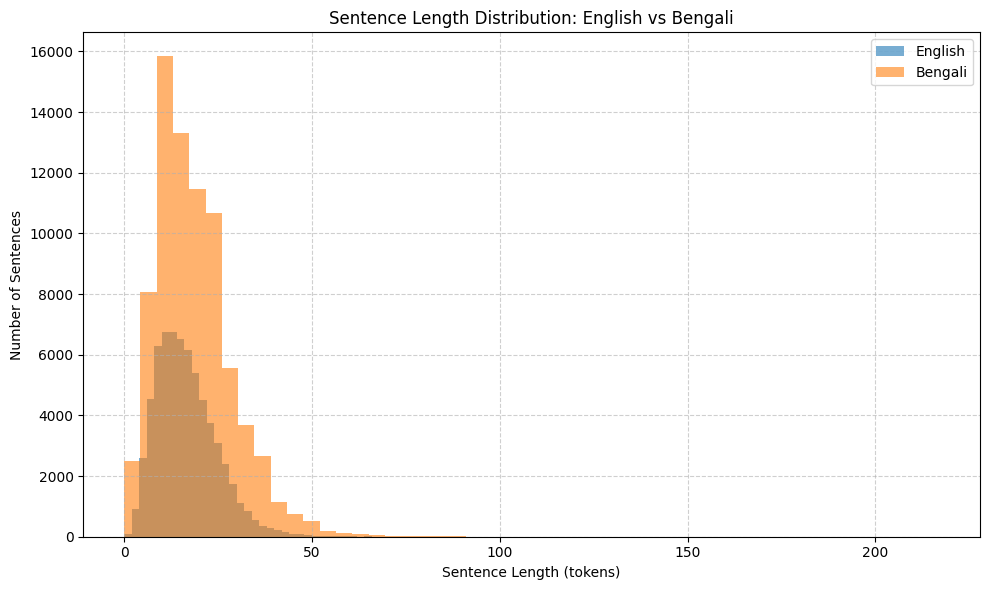

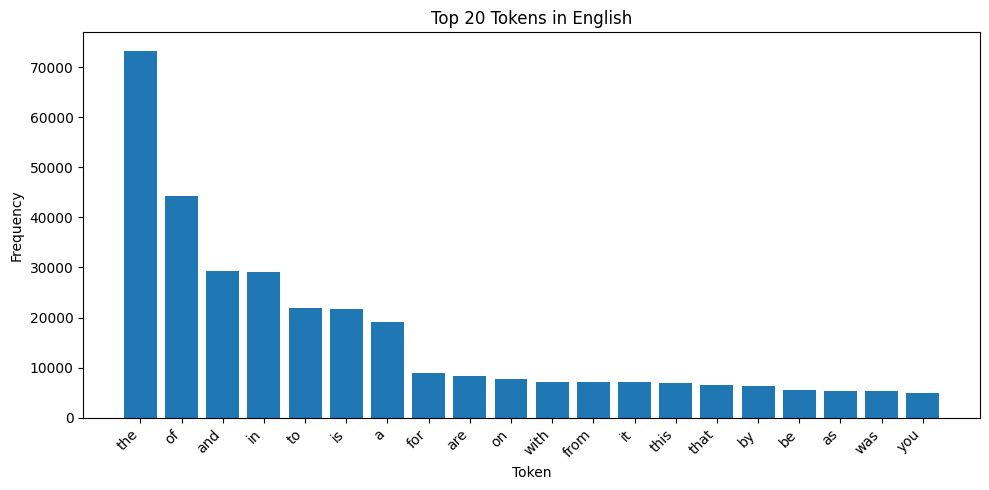


--- Corpus Analysis Complete ---


In [ ]:
print("\n--- Running Corpus Analysis ---")

# Compute statistics for training data
stats_train = compute_corpus_stats(
    en_tokens_train,
    bn_tokens_train,
    src_vocab=en_word2index,
    tgt_vocab=bn_word2index,
    src_lang='English',
    tgt_lang='Bengali'
)

# Plot sentence length distributions
plot_sentence_length_distribution(en_tokens_train, hi_tokens_train, 'English', 'Bengali')

# Plot top tokens
plot_top_tokens(en_tokens_train, 'English', top_n=20)
# plot_top_tokens(hi_tokens_train, 'Hindi', top_n=20)

print("\n--- Corpus Analysis Complete ---")

 Loaded 68849 English-Hindi validation sentence pairs.
ID range: 78683 to 147531

 Sentence Length Summary:
            src_len       tgt_len     len_ratio
count  68849.000000  68849.000000  68849.000000
mean      95.480297     86.954785      0.939361
std       50.159464     46.087722      0.613581
min        1.000000      2.000000      0.044444
25%       59.000000     53.000000      0.807229
50%       89.000000     80.000000      0.914530
75%      124.000000    113.000000      1.033333
max      573.000000    628.000000    139.000000


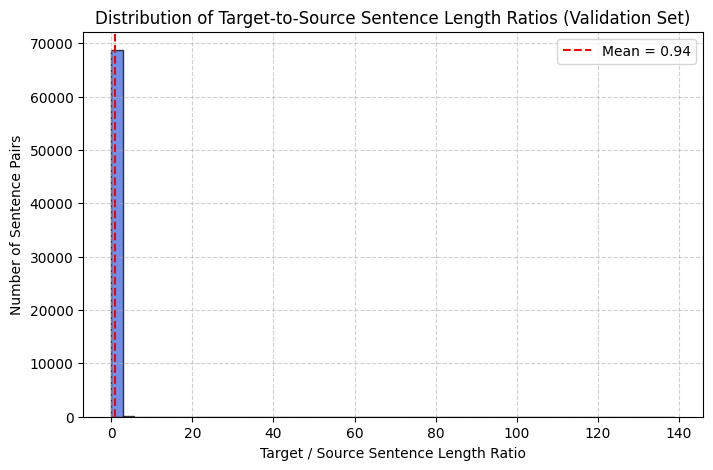


 Found 1135 potential outlier pairs (ratio < 0.5 or > 2.0).
                                               English  \
79                           Nausea starts occurring .   
187  You feel stomach bloated with sort of water al...   
238  In Karnataka , there are the Chamundi Hills fo...   
350  These roots nicely clasp themselves to the adh...   
382              Muscular dystrophyis of three types .   

                                               Bengali  len_ratio  
79                                        ঢেঁকুর ওঠে ৷   0.480000  
187                         পেটে সবসময় জল ভরা মনে হয় ৷   0.448276  
238  রাজস্থানের মাউন্ট আবু এবং সারিস্কা আছে যাদের স...   0.385093  
350       এই গাছে ফুল তার কনীয় তির্যক শাখাগুলিতে ধরে ৷   0.468085  
382  মাসকিউলার ডিস্ট্রাফী এমন একটি রোগ যাতে মাংসপেশ...   2.108108  


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# --- Load the data ---
with open('/kaggle/input/capstone/capstone_data-20251026T154136Z-1-001/capstone_data/train_data1.json', 'r', encoding='utf-8') as f:
    data_json = json.load(f)

# --- Extract English-Hindi validation data ---
# Expected structure:
# {
#   "English-Hindi": {
#       "Validation": {
#           "0": {"source": "This is an example.", "target": "यह एक उदाहरण है।"},
#           "1": {"source": "...", "target": "..."},
#       }
#   }
# }

validation_data = data_json.get("English-Bengali", {}).get("Train", {})

# --- Convert JSON into DataFrame ---
data_pairs = []
for id_key, content in validation_data.items():
    src_text = content.get("source", "").strip()
    tgt_text = content.get("target", "").strip()
    if src_text and tgt_text:  # skip empty entries
        data_pairs.append({
            "ID": int(id_key),
            "English": src_text,
            "Bengali": tgt_text
        })

df = pd.DataFrame(data_pairs)
print(f" Loaded {len(df)} English-Hindi validation sentence pairs.")
print(f"ID range: {df['ID'].min()} to {df['ID'].max()}")

# --- Compute character lengths ---
df["src_len"] = df["English"].apply(len)
df["tgt_len"] = df["Bengali"].apply(len)

# --- Compute ratio (Target / Source) ---
df = df[df["src_len"] > 0]  # avoid division by zero
df["len_ratio"] = df["tgt_len"] / df["src_len"]

# --- Summary statistics ---
print("\n Sentence Length Summary:")
print(df[["src_len", "tgt_len", "len_ratio"]].describe())

# --- Plot histogram of ratios ---
plt.figure(figsize=(8, 5))
plt.hist(df["len_ratio"], bins=50, color='royalblue', alpha=0.75, edgecolor='black')

plt.axvline(df["len_ratio"].mean(), color='red', linestyle='--', label=f"Mean = {df['len_ratio'].mean():.2f}")
plt.xlabel("Target / Source Sentence Length Ratio")
plt.ylabel("Number of Sentence Pairs")
plt.title("Distribution of Target-to-Source Sentence Length Ratios (Validation Set)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Optional: Identify outliers ---
low_thresh, high_thresh = 0.5, 2.0
outliers = df[(df["len_ratio"] < low_thresh) | (df["len_ratio"] > high_thresh)]
print(f"\n Found {len(outliers)} potential outlier pairs (ratio < {low_thresh} or > {high_thresh}).")
print(outliers.head(5)[["English", "Bengali", "len_ratio"]])

In [ ]:
# # ----------------------------------------------------------------------------
# # transformer_dataloaders.py (Updated for BPE Subword Tokenization)
# # ----------------------------------------------------------------------------

# import torch
# from torch.utils.data import DataLoader, TensorDataset
# import numpy as np
# from tqdm import tqdm

# # ----------------------------------------------------------------------------
# # 1. ENCODING & PADDING FUNCTION
# # ----------------------------------------------------------------------------

# def encode_and_pad_sentence(tokens, vocab, max_length, config):
#     """
#     Converts a tokenized (word/subword) sentence into IDs,
#     adds <SOS> and <EOS> tokens, and pads/truncates to max_length.
#     Works for both word-level and subword-level inputs.
#     """
#     sos_idx = vocab.get(config.SOS_TOKEN, config.UNK_IDX)
#     eos_idx = vocab.get(config.EOS_TOKEN, config.UNK_IDX)
#     pad_idx = vocab.get(config.PAD_TOKEN, config.UNK_IDX)
#     unk_idx = vocab.get(config.UNK_TOKEN, config.UNK_IDX)

#     # Start with <SOS>
#     ids = [sos_idx]

#     # Convert each token to its ID (subwords included)
#     for token in tokens:
#         ids.append(vocab.get(token, unk_idx))

#     # End with <EOS>
#     ids.append(eos_idx)

#     # Pad or truncate
#     if len(ids) < max_length:
#         ids += [pad_idx] * (max_length - len(ids))
#     else:
#         ids = ids[:max_length - 1] + [eos_idx]

#     return ids

# # ----------------------------------------------------------------------------
# # 2. TRAIN + VALIDATION DATALOADER CREATION
# # ----------------------------------------------------------------------------

# def create_dataloaders(config,
#                        en_tokens_train, bn_tokens_train,
#                        en_tokens_val, bn_tokens_val,
#                        en_word2index, bn_word2index):
#     """
#     Creates PyTorch DataLoaders for train and validation datasets.
#     Works with both word-level and subword-level tokenized data.
#     """
#     print("\n--- Part 3: Creating DataLoaders ---")

#     # --- Encode & Pad Training Data ---
#     print(f"Encoding {len(en_tokens_train)} training examples...")
#     train_x_encoded = [
#         encode_and_pad_sentence(t, en_word2index, config.SEQ_LENGTH, config)
#         for t in tqdm(en_tokens_train, desc="Source train")
#     ]
#     train_y_encoded = [
#         encode_and_pad_sentence(t, bn_word2index, config.SEQ_LENGTH, config)
#         for t in tqdm(bn_tokens_train, desc="Target train")
#     ]

#     # --- Encode & Pad Validation Data ---
#     print(f"Encoding {len(en_tokens_val)} validation examples...")
#     val_x_encoded = [
#         encode_and_pad_sentence(t, en_word2index, config.SEQ_LENGTH, config)
#         for t in tqdm(en_tokens_val, desc="Source val")
#     ]
#     val_y_encoded = [
#         encode_and_pad_sentence(t, bn_word2index, config.SEQ_LENGTH, config)
#         for t in tqdm(bn_tokens_val, desc="Target val")
#     ]

#     # --- Convert to Tensors ---
#     print("\nConverting encoded sequences to Tensors...")
#     train_x_tensor = torch.tensor(train_x_encoded, dtype=torch.long)
#     train_y_tensor = torch.tensor(train_y_encoded, dtype=torch.long)
#     val_x_tensor = torch.tensor(val_x_encoded, dtype=torch.long)
#     val_y_tensor = torch.tensor(val_y_encoded, dtype=torch.long)

#     # --- Create TensorDatasets ---
#     train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
#     val_dataset = TensorDataset(val_x_tensor, val_y_tensor)

#     # --- Create DataLoaders ---
#     train_dataloader = DataLoader(
#         train_dataset,
#         batch_size=config.BATCH_SIZE,
#         shuffle=True,
#         drop_last=True,
#     )
#     val_dataloader = DataLoader(
#         val_dataset,
#         batch_size=config.BATCH_SIZE,
#         shuffle=False,
#         drop_last=False,
#     )

#     print("\n✅ Train and Validation DataLoaders created.")
#     print(f"Train batches: {len(train_dataloader)} | Val batches: {len(val_dataloader)}")

#     # --- Show an Example ---
#     try:
#         example_src_batch, example_tgt_batch = next(iter(train_dataloader))
#         print("\nExample Batch Shapes:")
#         print(f"SRC: {example_src_batch.shape}, TGT: {example_tgt_batch.shape}")
#         print("\nExample Source IDs:", example_src_batch[0][:20])
#         print("Example Target IDs:", example_tgt_batch[0][:20])
#     except Exception as e:
#         print(f"Could not show dataloader example: {e}")

#     return train_dataloader, val_dataloader

# # ----------------------------------------------------------------------------
# # 3. TEST DATALOADER CREATION
# # ----------------------------------------------------------------------------

# def create_test_dataloader(config, en_tokens_test, test_ids, en_word2index):
#     """
#     Creates the DataLoader for test (submission) data.
#     Only contains source sentences.
#     """
#     print("\n--- Part 3: Creating Test DataLoader ---")
#     print(f"Encoding {len(en_tokens_test)} test examples...")

#     test_x_encoded = [
#         encode_and_pad_sentence(t, en_word2index, config.SEQ_LENGTH, config)
#         for t in tqdm(en_tokens_test, desc="Test source")
#     ]
#     test_x_tensor = torch.tensor(test_x_encoded, dtype=torch.long)
#     test_dataset = TensorDataset(test_x_tensor, torch.arange(len(test_ids)))

#     test_dataloader = DataLoader(
#         test_dataset,
#         batch_size=config.BATCH_SIZE,
#         shuffle=False,
#         drop_last=False,
#     )

#     print(f"✅ Test DataLoader created ({len(test_dataloader)} batches).")
#     return test_dataloader, test_ids


## Data Loaders

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 2. ENCODING & PADDING FUNCTION (From Starter Code)

def encode_and_pad_sentence(tokens, vocab, max_length):
    """
    Takes a list of tokens, converts them to numerical IDs,
    and pads/truncates to a fixed max_length.

    This function correctly adds the <SOS> and <EOS> tokens
    numerically, which fixes the bug we found in Part 2.
    """
    # Get numerical IDs for the special tokens
    sos_idx = vocab.get(config.SOS_TOKEN, config.UNK_IDX)
    eos_idx = vocab.get(config.EOS_TOKEN, config.UNK_IDX)
    pad_idx = vocab.get(config.PAD_TOKEN, config.UNK_IDX)
    unk_idx = vocab.get(config.UNK_IDX, config.UNK_IDX) # Fallback for UNK

    # Start with <SOS> token
    numericalized_tokens = [sos_idx]

    # Add tokens from sentence
    for token in tokens:
        numericalized_tokens.append(vocab.get(token, unk_idx))

    # Add <EOS> token
    numericalized_tokens.append(eos_idx)

    # Pad or truncate
    if len(numericalized_tokens) < max_length:
        # Pad
        num_pads = max_length - len(numericalized_tokens)
        padded_tokens = numericalized_tokens + ([pad_idx] * num_pads)
    else:
        # Truncate (while keeping <EOS> at the end)
        truncated_tokens = numericalized_tokens[:max_length - 1]
        padded_tokens = truncated_tokens + [eos_idx]

    return padded_tokens

def create_dataloaders(config,
                       en_tokens_train, bn_tokens_train,
                       en_tokens_val, bn_tokens_val,
                       en_word2index, bn_word2index):
    """
    Main function to create the training and validation DataLoaders.
    """

    print("\n--- Part 3: Creating DataLoaders ---")

    # --- 1. Encode and Pad Training Data ---
    print(f"Encoding {len(en_tokens_train)} training sentences...")

    train_x_encoded = [
        encode_and_pad_sentence(tokens, en_word2index, config.SEQ_LENGTH)
        for tokens in en_tokens_train
    ]
    train_y_encoded = [
        encode_and_pad_sentence(tokens, bn_word2index, config.SEQ_LENGTH)
        for tokens in bn_tokens_train
    ]

    # --- 2. Encode and Pad Validation Data ---
    print(f"Encoding {len(en_tokens_val)} validation sentences...")
    val_x_encoded = [
        encode_and_pad_sentence(tokens, en_word2index, config.SEQ_LENGTH)
        for tokens in en_tokens_val
    ]
    val_y_encoded = [
        encode_and_pad_sentence(tokens, bn_word2index, config.SEQ_LENGTH)
        for tokens in bn_tokens_val
    ]

    # --- 3. Convert to Tensors (via numpy) ---
    print("Converting to PyTorch Tensors...")
    train_x_tensor = torch.from_numpy(np.array(train_x_encoded)).long()
    train_y_tensor = torch.from_numpy(np.array(train_y_encoded)).long()

    val_x_tensor = torch.from_numpy(np.array(val_x_encoded)).long()
    val_y_tensor = torch.from_numpy(np.array(val_y_encoded)).long()

    # --- 4. Create TensorDatasets ---
    train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
    val_dataset = TensorDataset(val_x_tensor, val_y_tensor)

    # --- 5. Create DataLoaders ---
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

    val_dataloader = DataLoader(
        val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False, # No need to shuffle validation
        drop_last=False
    )

    print("Train and Validation DataLoaders created.")

    # --- 6. Show an example from the dataloader ---
    try:
        example_src_batch, example_tgt_batch = next(iter(train_dataloader))
        print(f"\nExample train batch shape (SRC): {example_src_batch.shape}")
        print(f"Example train batch shape (TGT): {example_tgt_batch.shape}")

        print("\nExample numericalized source sentence (from batch):")
        print(example_src_batch[0])

        print("\nExample numericalized target sentence (from batch):")
        print(example_tgt_batch[0])
    except Exception as e:
        print(f"Could not show dataloader example: {e}")

    return train_dataloader, val_dataloader

def create_test_dataloader(config, en_tokens_test, test_ids, en_word2index):
    """
    Creates the TEST (submission) DataLoader.
    This one only contains the source (x) data.
    """

    print("\n--- Part 3: Creating Test DataLoader ---")

    # --- 1. Encode and Pad Test Data ---
    print(f"Encoding {len(en_tokens_test)} test sentences...")

    test_x_encoded = [
        encode_and_pad_sentence(tokens, en_word2index, config.SEQ_LENGTH)
        for tokens in en_tokens_test
    ]

    # --- 2. Convert to Tensors (via numpy) ---
    test_x_tensor = torch.from_numpy(np.array(test_x_encoded)).long()

    # --- 3. Create TensorDataset ---
    # We use the test_ids as the "y" for now, just to keep them
    # paired with the sentences. This is a common trick.
    # We will ignore them during encoding, but use them for the CSV.
    test_dataset = TensorDataset(test_x_tensor, torch.arange(len(test_ids)))

    # --- 4. Create DataLoader ---
    test_dataloader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False, # Must NOT shuffle test
        drop_last=False
    )

    print("Test (Submission) DataLoader created.")

    return test_dataloader, test_ids # Pass test_ids just in case

In [ ]:
# --- Run Part 3 ---
train_dataloader, val_dataloader = create_dataloaders(
    config,
    en_tokens_train, bn_tokens_train,
    en_tokens_val, bn_tokens_val,
    en_word2index, bn_word2index
)

test_dataloader, _ = create_test_dataloader(
    config, en_tokens_test, test_ids, en_word2index
)


--- Part 3: Creating DataLoaders ---
Encoding 65407 training sentences...
Encoding 3442 validation sentences...
Converting to PyTorch Tensors...
Train and Validation DataLoaders created.

Example train batch shape (SRC): torch.Size([50, 36])
Example train batch shape (TGT): torch.Size([50, 36])

Example numericalized source sentence (from batch):
tensor([   1,  371,  512,    3, 2503,  420,  484,   56,    7,  922,   88,   92,
           2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0])

Example numericalized target sentence (from batch):
tensor([   1,    3, 2781, 2288,   74,  459, 1029,  118, 5266,  462,    2,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0])

--- Part 3: Creating Test DataLoader ---
Encoding 19672 test sentences...
Test (Submission) DataLoader created.


In [ ]:
# print("--- Running Dataloader Creation (Part 3) ---")

# try:
#     # 1. Create Train and Validation DataLoaders
#     train_loader, val_loader = create_dataloaders(
#         config,
#         en_tokens_train, bn_tokens_train,
#         en_tokens_val, bn_tokens_val,
#         en_word2index, bn_word2index
#     )

#     # 2. Create Test DataLoader
#     # We save 'original_test_ids' to map predictions back later
#     test_loader, original_test_ids = create_test_dataloader(
#         config,
#         en_tokens_test,
#         test_ids,  # The list of string IDs from Part 2
#         en_word2index
#     )

#     print("\n--- Dataloader Creation Complete ---")
#     print(f"Train Dataloader: {len(train_loader)} batches of {config.BATCH_SIZE}")
#     print(f"Val Dataloader:   {len(val_loader)} batches of {config.BATCH_SIZE}")
#     print(f"Test Dataloader:  {len(test_loader)} batches of {config.BATCH_SIZE}")
#     print(f"Total original test IDs loaded: {len(original_test_ids)}")

# except NameError as e:
#     print(f"Error: {e}")
#     print("Please make sure the data from Part 2 is loaded and")
#     print("the functions from 'transformer_dataloaders.py' are defined.")
# except Exception as e:
#     print(f"An unexpected error occurred during dataloader creation: {e}")

--- Running Dataloader Creation (Part 3) ---

--- Part 3: Creating DataLoaders ---
Encoding 65407 training examples...


Target train: 100%|██████████| 65407/65407 [00:00<00:00, 100925.85it/s]


Encoding 3442 validation examples...


Target val: 100%|██████████| 3442/3442 [00:00<00:00, 219111.13it/s]



Converting encoded sequences to Tensors...

✅ Train and Validation DataLoaders created.
Train batches: 1308 | Val batches: 69

Example Batch Shapes:
SRC: torch.Size([50, 32]), TGT: torch.Size([50, 32])

Example Source IDs: tensor([    1,     9,  2648,    34,  4346, 10303,  1786,    54,  2520,  6964,
           38,  2553,   100,     9,  1550,  7413,  6191,  2378,  4860,  1186])
Example Target IDs: tensor([    1,  3766,   670, 15418,  6565,  2510,  1701, 10283,  2347,    86,
         9630, 16995,  1856, 16348,  8566,   327,  3669,   221,  3054,   191])

--- Part 3: Creating Test DataLoader ---
Encoding 19672 test examples...


Test source: 100%|██████████| 19672/19672 [00:00<00:00, 256795.99it/s]

✅ Test DataLoader created (394 batches).

--- Dataloader Creation Complete ---
Train Dataloader: 1308 batches of 50
Val Dataloader:   69 batches of 50
Test Dataloader:  394 batches of 50
Total original test IDs loaded: 19672


## Attention

In [ ]:
import torch
import torch.nn as nn
import math

# 2. SCALED DOT-PRODUCT ATTENTION (Function)

def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):
    """
    Implements the core "Scaled Dot-Product Attention"

    Args:
        query (Tensor): Q, shape [batch_size, num_heads, seq_len_q, d_k]
        key (Tensor): K, shape [batch_size, num_heads, seq_len_k, d_k]
        value (Tensor): V, shape [batch_size, num_heads, seq_len_v, d_v]
                       (Note: seq_len_k == seq_len_v)
        mask (Tensor, optional): Mask to apply. Shape [batch_size, 1, 1, seq_len_k]
                                 for padding, or [batch_size, 1, seq_len_q, seq_len_k]
                                 for look-ahead. Defaults to None.
        dropout (nn.Dropout, optional): Dropout layer. Defaults to None.

    Returns:
        Tensor: The context vector (output), shape [batch_size, num_heads, seq_len_q, d_v]
        Tensor: The attention weights, shape [batch_size, num_heads, seq_len_q, seq_len_k]
    """

    # 1. Get embedding dimension (d_k) from the query
    d_k = query.size(-1)

    # 2. Calculate scores: (Q * K^T) / sqrt(d_k)
    # [b, h, q_len, d_k] @ [b, h, d_k, k_len] -> [b, h, q_len, k_len]
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    # 3. Apply mask (if provided)
    # The mask tells us where to put -1e9 (a very small number)
    # This makes the softmax output 0 for those positions.
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # 4. Apply softmax to get attention weights
    # Softmax is applied on the last dimension (k_len)
    attention_weights = torch.softmax(scores, dim=-1)

    # 5. Apply dropout (if provided)
    if dropout is not None:
        attention_weights = dropout(attention_weights)

    # 6. Get context vector: (Attention * V)
    # [b, h, q_len, k_len] @ [b, h, v_len, d_v] -> [b, h, q_len, d_v]
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

# 3. MULTI-HEAD ATTENTION (Module)

class MultiHeadAttention(nn.Module):
    """
    Implements the "Multi-Head Attention" module.

    This module:
    1. Takes query, key, and value.
    2. Projects them using linear layers (W_q, W_k, W_v).
    3. Splits the projections into `num_heads`.
    4. Applies scaled dot-product attention.
    5. Concatenates the heads.
    6. Applies a final linear layer (W_o).
    """
    def __init__(self, d_model, num_heads, dropout_rate):
        """
        Args:
            d_model (int): The embedding dimension (e.g., 512)
            num_heads (int): Number of heads (e.g., 8)
            dropout_rate (float): Dropout probability
        """
        super(MultiHeadAttention, self).__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # Dimension of each head

        # Define the 4 linear layers
        self.W_q = nn.Linear(d_model, d_model) # Query projection
        self.W_k = nn.Linear(d_model, d_model) # Key projection
        self.W_v = nn.Linear(d_model, d_model) # Value projection
        self.W_o = nn.Linear(d_model, d_model) # Output projection

        self.dropout = nn.Dropout(dropout_rate)

    def split_heads(self, x, batch_size):
        """
        Splits the last dimension `d_model` into `num_heads` and `d_k`.

        Args:
            x (Tensor): Input tensor, shape [batch_size, seq_len, d_model]

        Returns:
            Tensor: Reshaped tensor, shape [batch_size, num_heads, seq_len, d_k]
        """
        # Reshape to [batch_size, seq_len, num_heads, d_k]
        x = x.view(batch_size, -1, self.num_heads, self.d_k)

        # Transpose to [batch_size, num_heads, seq_len, d_k]
        return x.transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        """
        Forward pass for Multi-Head Attention.

        Args:
            query (Tensor): Q, shape [batch_size, seq_len_q, d_model]
            key (Tensor): K, shape [batch_size, seq_len_k, d_model]
            value (Tensor): V, shape [batch_size, seq_len_v, d_model]
            mask (Tensor, optional): Mask to apply. Defaults to None.

        Returns:
            Tensor: Output, shape [batch_size, seq_len_q, d_model]
        """
        batch_size = query.size(0)

        # 1. Pass Q, K, V through their linear layers
        # [b, seq_len, d_model] -> [b, seq_len, d_model]
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # 2. Split heads
        # [b, seq_len, d_model] -> [b, num_heads, seq_len, d_k]
        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        # 3. Apply scaled dot-product attention
        # context shape: [b, num_heads, seq_len_q, d_k]
        # attention_weights shape: [b, num_heads, seq_len_q, seq_len_k]
        context, attention_weights = scaled_dot_product_attention(
            Q, K, V, mask, self.dropout
        )

        # 4. Concatenate heads
        # First, transpose context back to [b, seq_len_q, num_heads, d_k]
        context = context.transpose(1, 2).contiguous()

        # Now, reshape to [b, seq_len_q, d_model]
        context = context.view(batch_size, -1, self.d_model)

        # 5. Pass through the final output linear layer
        # [b, seq_len_q, d_model] -> [b, seq_len_q, d_model]
        output = self.W_o(context)

        return output

In [ ]:
import torch
import torch.nn as nn
import math

# 2. POSITION-WISE FEED-FORWARD NETWORK (Module)

class PositionwiseFeedForward(nn.Module):
    """
    Implements the Position-wise Feed-Forward Network (FFN).

    This is a simple two-layer fully-connected network applied to each
    position (token) independently.

    FFN(x) = max(0, x * W_1 + b_1) * W_2 + b_2
    (Which is: Linear -> ReLU -> Dropout -> Linear -> Dropout)
    """
    def __init__(self, d_model, d_ff, dropout_rate):
        """
        Args:
            d_model (int): Input/output dimension (e.g., 512)
            d_ff (int): Inner dimension (e.g., 2048)
            dropout_rate (float): Dropout probability
        """
        super(PositionwiseFeedForward, self).__init__()

        self.linear_1 = nn.Linear(d_model, d_ff)
        self.linear_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        Args:
            x (Tensor): Input tensor, shape [batch_size, seq_len, d_model]

        Returns:
            Tensor: Output tensor, shape [batch_size, seq_len, d_model]
        """
        # [b, seq_len, d_model] -> [b, seq_len, d_ff]
        x = self.relu(self.linear_1(x))

        # Apply dropout
        x = self.dropout(x)

        # [b, seq_len, d_ff] -> [b, seq_len, d_model]
        x = self.linear_2(x)

        return x

# 3. POSITIONAL ENCODING (Module)

class PositionalEncoding(nn.Module):
    """
    Implements the sinusoidal Positional Encoding.

    This module injects information about the relative or absolute position
    of the tokens in the sequence. The positional encodings have the same
    dimension (d_model) as the embeddings, so they can be summed.

    PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """
    def __init__(self, d_model, dropout_rate, max_len=5000):
        """
        Args:
            d_model (int): Embedding dimension (e.g., 512)
            dropout_rate (float): Dropout probability
            max_len (int): Max sequence length to pre-compute.
        """
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout_rate)

        # --- Create the positional encoding matrix ---

        # Shape: [max_len, d_model]
        pe = torch.zeros(max_len, d_model)

        # Position tensor, shape: [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Denominator term in the formulas
        # This creates the 1 / 10000^(2i / d_model) part
        # Shape: [d_model/2]
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * \
                             (-math.log(10000.0) / d_model))

        # Apply sin to even indices (2i)
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cos to odd indices (2i+1)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add a batch dimension so it can be broadcasted
        # Shape: [1, max_len, d_model]
        pe = pe.unsqueeze(0)

        # Register 'pe' as a buffer. This makes it part of the module's
        # state, but not a parameter that requires gradients.
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x (Tensor): Input tensor (the embeddings),
                        shape [batch_size, seq_len, d_model]

        Returns:
            Tensor: Output tensor (embeddings + positional encoding),
                    shape [batch_size, seq_len, d_model]
        """
        # x.size(1) is the sequence length (seq_len)
        # We take the pre-computed 'pe' matrix and slice it up to seq_len.
        # self.pe[:, :x.size(1), :] shape is [1, seq_len, d_model]
        # This is broadcasted with x [b, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :].requires_grad_(False)

        return self.dropout(x)

In [ ]:
import torch
import torch.nn as nn
import math

# # Import our custom modules from previous steps
# try:
#     from transformer_attention import MultiHeadAttention
#     from transformer_building_blocks import PositionwiseFeedForward, PositionalEncoding
# except ImportError:
#     print("ERROR: Ensure transformer_attention.py and transformer_building_blocks.py are in the same directory.")

# 2. ENCODER LAYER (Module)

class EncoderLayer(nn.Module):
    """
    Implements a single Encoder Layer.

    An EncoderLayer has two sub-layers:
    1. Multi-Head Self-Attention
    2. Position-wise Feed-Forward Network

    Each sub-layer is followed by a residual connection (Add) and
    Layer Normalization (Norm).
    """
    def __init__(self, d_model, num_heads, d_ff, dropout_rate):
        """
        Args:
            d_model (int): Embedding dimension (e.g., 512)
            num_heads (int): Number of attention heads (e.g., 8)
            d_ff (int): Inner dimension of FFN (e.g., 2048)
            dropout_rate (float): Dropout probability
        """
        super(EncoderLayer, self).__init__()

        # Sub-layer 1: Multi-Head Self-Attention
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout_rate)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout_rate)

        # Sub-layer 2: Position-wise Feed-Forward
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x, mask):
        """
        Forward pass for the EncoderLayer.

        Args:
            x (Tensor): Input tensor, shape [batch_size, seq_len, d_model]
            mask (Tensor): Source padding mask,
                           shape [batch_size, 1, 1, seq_len]

        Returns:
            Tensor: Output tensor, shape [batch_size, seq_len, d_model]
        """

        # --- Sub-layer 1: Self-Attention ---
        # 1.1. Compute attention
        # Q, K, V are all from the same input 'x'
        attn_output = self.self_attn(query=x, key=x, value=x, mask=mask)

        # 1.2. Add & Norm
        # x = x + self.dropout1(attn_output)
        # x = self.norm1(x)
        x = self.norm1(x + self.dropout1(attn_output)) # Pre-norm vs Post-norm

        # --- Sub-layer 2: Feed-Forward ---
        # 2.1. Compute feed-forward
        ff_output = self.feed_forward(x)

        # 2.2. Add & Norm
        # x = x + self.dropout2(ff_output)
        # x = self.norm2(x)
        x = self.norm2(x + self.dropout2(ff_output))

        return x

# 3. ENCODER (Module)

class Encoder(nn.Module):
    """
    Implements the full Encoder stack.

    It consists of:
    1. Input Embedding layer
    2. Positional Encoding
    3. A stack of N EncoderLayers
    """
    def __init__(self, vocab_size, d_model, num_layers, num_heads,
                 d_ff, dropout_rate, max_seq_len):
        """
        Args:
            vocab_size (int): Size of the source vocabulary
            d_model (int): Embedding dimension
            num_layers (int): Number of EncoderLayers to stack
            num_heads (int): Number of attention heads
            d_ff (int): Inner dimension of FFN
            dropout_rate (float): Dropout probability
            max_seq_len (int): Max sequence length (for PositionalEncoding)
        """
        super(Encoder, self).__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout_rate, max_len=max_seq_len)

        # Create a stack of N identical EncoderLayers
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout_rate)
             for _ in range(num_layers)]
        )

        self.dropout = nn.Dropout(dropout_rate)
        # The original paper uses a final LayerNorm
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask):
        """
        Forward pass for the Encoder.

        Args:
            x (Tensor): Source token indices, shape [batch_size, seq_len]
            mask (Tensor): Source padding mask,
                           shape [batch_size, 1, 1, seq_len]

        Returns:
            Tensor: Output tensor (encoded sequence),
                    shape [batch_size, seq_len, d_model]
        """

        # 1. Get embedding and scale it
        # (Scaling by sqrt(d_model) is done in the paper)
        x = self.embedding(x) * math.sqrt(self.d_model)

        # 2. Add positional encoding
        x = self.pos_encoding(x)

        # 3. Apply dropout
        x = self.dropout(x)

        # 4. Pass through all N layers
        for layer in self.layers:
            x = layer(x, mask)

        # 5. Apply final normalization
        # Note: Some implementations apply norm inside the loop (Pre-LN)
        # We are using Post-LN as in the original paper.
        return self.norm(x)

In [ ]:
import torch
import torch.nn as nn
import math

# # Import our custom modules from previous steps
# try:
#     from transformer_attention import MultiHeadAttention
#     from transformer_building_blocks import PositionwiseFeedForward, PositionalEncoding
# except ImportError:
#     print("ERROR: Ensure transformer_attention.py and transformer_building_blocks.py are in the same directory.")

# 2. DECODER LAYER (Module)

class DecoderLayer(nn.Module):
    """
    Implements a single Decoder Layer.

    A DecoderLayer has three sub-layers:
    1. Masked Multi-Head Self-Attention (attends to the target sequence)
    2. Multi-Head Cross-Attention (attends to the encoder output)
    3. Position-wise Feed-Forward Network

    Each sub-layer is followed by a residual connection (Add) and
    Layer Normalization (Norm).
    """
    def __init__(self, d_model, num_heads, d_ff, dropout_rate):
        """
        Args:
            d_model (int): Embedding dimension (e.g., 512)
            num_heads (int): Number of attention heads (e.g., 8)
            d_ff (int): Inner dimension of FFN (e.g., 2048)
            dropout_rate (float): Dropout probability
        """
        super(DecoderLayer, self).__init__()

        # Sub-layer 1: Masked Multi-Head Self-Attention
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout_rate)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout_rate)

        # Sub-layer 2: Multi-Head Cross-Attention
        # Q is from the decoder, K and V are from the encoder output
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout_rate)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Sub-layer 3: Position-wise Feed-Forward
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout3 = nn.Dropout(dropout_rate)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        """
        Forward pass for the DecoderLayer.

        Args:
            x (Tensor): Input tensor (from previous decoder layer or embedding),
                        shape [batch_size, tgt_seq_len, d_model]
            encoder_output (Tensor): Output from the Encoder,
                                     shape [batch_size, src_seq_len, d_model]
            src_mask (Tensor): Source padding mask (from encoder),
                               shape [batch_size, 1, 1, src_seq_len]
            tgt_mask (Tensor): Target look-ahead + padding mask,
                               shape [batch_size, 1, tgt_seq_len, tgt_seq_len]

        Returns:
            Tensor: Output tensor, shape [batch_size, tgt_seq_len, d_model]
        """

        # --- Sub-layer 1: Masked Self-Attention ---
        # Q, K, V are all from the same input 'x'
        # We use the 'tgt_mask' to prevent attending to future tokens.
        attn_output = self.self_attn(query=x, key=x, value=x, mask=tgt_mask)
        x = self.norm1(x + self.dropout1(attn_output))

        # --- Sub-layer 2: Cross-Attention ---
        # Query is from the decoder (x), Key and Value are from the encoder.
        # We use the 'src_mask' to prevent attending to padding tokens
        # in the encoder's output.
        attn_output = self.cross_attn(query=x,
                                      key=encoder_output,
                                      value=encoder_output,
                                      mask=src_mask)
        x = self.norm2(x + self.dropout2(attn_output))

        # --- Sub-layer 3: Feed-Forward ---
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff_output))

        return x

# 3. DECODER (Module)

class Decoder(nn.Module):
    """
    Implements the full Decoder stack.

    It consists of:
    1. Output Embedding layer
    2. Positional Encoding
    3. A stack of N DecoderLayers
    """
    def __init__(self, vocab_size, d_model, num_layers, num_heads,
                 d_ff, dropout_rate, max_seq_len):
        """
        Args:
            vocab_size (int): Size of the target vocabulary
            d_model (int): Embedding dimension
            num_layers (int): Number of DecoderLayers to stack
            num_heads (int): Number of attention heads
            d_ff (int): Inner dimension of FFN
            dropout_rate (float): Dropout probability
            max_seq_len (int): Max sequence length (for PositionalEncoding)
        """
        super(Decoder, self).__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout_rate, max_len=max_seq_len)

        # Create a stack of N identical DecoderLayers
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, d_ff, dropout_rate)
             for _ in range(num_layers)]
        )

        self.dropout = nn.Dropout(dropout_rate)
        # Final LayerNorm
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        """
        Forward pass for the Decoder.

        Args:
            x (Tensor): Target token indices,
                        shape [batch_size, tgt_seq_len]
            encoder_output (Tensor): Output from the Encoder,
                                     shape [batch_size, src_seq_len, d_model]
            src_mask (Tensor): Source padding mask (from encoder),
                               shape [batch_size, 1, 1, src_seq_len]
            tgt_mask (Tensor): Target look-ahead + padding mask,
                               shape [batch_size, 1, tgt_seq_len, tgt_seq_len]

        Returns:
            Tensor: Output tensor (decoder logits, before final Linear layer),
                    shape [batch_size, tgt_seq_len, d_model]
        """

        # 1. Get embedding and scale it
        x = self.embedding(x) * math.sqrt(self.d_model)

        # 2. Add positional encoding
        x = self.pos_encoding(x)

        # 3. Apply dropout
        x = self.dropout(x)

        # 4. Pass through all N layers
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)

        # 5. Apply final normalization
        return self.norm(x)

In [ ]:
# import torch
# import torch.nn as nn
# import math

# # # Import our custom modules from previous steps
# # try:
# #     from transformer_encoder import Encoder
# #     from transformer_decoder import Decoder
# # except ImportError:
# #     print("ERROR: Ensure transformer_encoder.py and transformer_decoder.py are in the same directory.")

# # ----------------------------------------------------------------------------
# # 2. TRANSFORMER MODEL (Module)
# # ----------------------------------------------------------------------------

# class Transformer(nn.Module):
#     """
#     Implements the full Transformer (Encoder-Decoder) model.

#     It consists of:
#     1. An Encoder
#     2. A Decoder
#     3. A final Linear layer to project decoder output to the target vocab size.
#     """
#     def __init__(self,
#                  config,
#                  vocab_src_size,
#                  vocab_tgt_size,
#                  src_pad_idx,
#                  tgt_pad_idx
#                 ):
#         """
#         Args:
#             config (Config): Our configuration object with all hyperparameters.
#             vocab_src_size (int): Source (English) vocabulary size.
#             vocab_tgt_size (int): Target (Bengali) vocabulary size.
#             src_pad_idx (int): Source padding token ID.
#             tgt_pad_idx (int): Target padding token ID.
#         """
#         super(Transformer, self).__init__()

#         self.config = config
#         self.src_pad_idx = src_pad_idx
#         self.tgt_pad_idx = tgt_pad_idx

#         # 1. Initialize Encoder
#         self.encoder = Encoder(
#             vocab_size=vocab_src_size,
#             d_model=config.D_MODEL,
#             num_layers=config.NUM_ENCODER_LAYERS,
#             num_heads=config.N_HEADS,
#             d_ff=config.D_FF,
#             dropout_rate=config.DROPOUT,
#             max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
#         )

#         # 2. Initialize Decoder
#         self.decoder = Decoder(
#             vocab_size=vocab_tgt_size,
#             d_model=config.D_MODEL,
#             num_layers=config.NUM_DECODER_LAYERS,
#             num_heads=config.N_HEADS,
#             d_ff=config.D_FF,
#             dropout_rate=config.DROPOUT,
#             max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
#         )

#         # 3. Final output Linear layer
#         # This projects the decoder's [b, seq_len, d_model] output
#         # to [b, seq_len, vocab_tgt_size]
#         self.final_linear = nn.Linear(config.D_MODEL, vocab_tgt_size)

#         # Initialize weights
#         self._initialize_weights()

#     def _initialize_weights(self):
#         """
#         Applies Xavier/Glorot uniform initialization to all Linear and
#         Embedding layers. This is a common practice for Transformers.
#         """
#         if hasattr(self, 'final_linear'):
#             for name, p in self.named_parameters():
#                 if p.dim() > 1:
#                     nn.init.xavier_uniform_(p)
#         # Initialize embedding layers specifically
#         if hasattr(self, 'encoder') and hasattr(self.encoder, 'embedding'):
#             nn.init.xavier_uniform_(self.encoder.embedding.weight)
#         if hasattr(self, 'decoder') and hasattr(self.decoder, 'embedding'):
#             nn.init.xavier_uniform_(self.decoder.embedding.weight)

#     def create_src_mask(self, src):
#         """
#         Creates the source padding mask.
#         This mask hides padding tokens in the source sequence.

#         Args:
#             src (Tensor): Source token indices, shape [batch_size, src_seq_len]

#         Returns:
#             Tensor: Source mask, shape [batch_size, 1, 1, src_seq_len]
#         """
#         # src == self.src_pad_idx -> [b, src_seq_len] (True where pad)
#         # src != self.src_pad_idx -> [b, src_seq_len] (True where not pad)
#         # .unsqueeze(1).unsqueeze(2) -> [b, 1, 1, src_seq_len]
#         src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
#         return src_mask

#     def create_tgt_mask(self, tgt):
#         """
#         Creates the target mask (padding + look-ahead).
#         This mask hides padding tokens AND future tokens in the target sequence.

#         Args:
#             tgt (Tensor): Target token indices, shape [batch_size, tgt_seq_len]

#         Returns:
#             Tensor: Target mask, shape [batch_size, 1, tgt_seq_len, tgt_seq_len]
#         """
#         # 1. Target padding mask
#         # Shape: [b, 1, 1, tgt_seq_len]
#         tgt_pad_mask = (tgt != self.tgt_pad_idx).unsqueeze(1).unsqueeze(2)

#         # 2. Target look-ahead mask
#         tgt_seq_len = tgt.shape[1]
#         # torch.ones(size) -> [tgt_seq_len, tgt_seq_len]
#         # torch.triu(...) -> Creates upper triangular matrix
#         # diagonal=1 means it's 0 on the diagonal, 1 above
#         # == 0 -> Flips it. [True, False, False]
#         #               [True, True,  False]
#         #               [True, True,  True]
#         look_ahead_mask = torch.triu(
#             torch.ones((1, 1, tgt_seq_len, tgt_seq_len), device=tgt.device),
#             diagonal=1
#         ) == 0

#         # 3. Combine masks
#         # [b, 1, 1, tgt_seq_len] & [1, 1, tgt_seq_len, tgt_seq_len]
#         # -> [b, 1, tgt_seq_len, tgt_seq_len]
#         tgt_mask = tgt_pad_mask & look_ahead_mask
#         return tgt_mask

#     def forward(self, src, tgt):
#         """
#         Forward pass for the Transformer.

#         Args:
#             src (Tensor): Source token indices,
#                           shape [batch_size, src_seq_len]
#             tgt (Tensor): Target token indices (shifted right),
#                           shape [batch_size, tgt_seq_len]

#         Returns:
#             Tensor: Output logits,
#                     shape [batch_size, tgt_seq_len, vocab_tgt_size]
#         """

#         # 1. Create masks
#         src_mask = self.create_src_mask(src)
#         tgt_mask = self.create_tgt_mask(tgt)

#         # 2. Pass source through Encoder
#         # encoder_output shape: [b, src_seq_len, d_model]
#         encoder_output = self.encoder(src, src_mask)

#         # 3. Pass target and encoder output through Decoder
#         # decoder_output shape: [b, tgt_seq_len, d_model]
#         decoder_output = self.decoder(tgt, encoder_output, src_mask, tgt_mask)

#         # 4. Pass decoder output through final Linear layer
#         # output shape: [b, tgt_seq_len, vocab_tgt_size]
#         output = self.final_linear(decoder_output)

#         return output


## Transformer Model

In [ ]:
import torch
import torch.nn as nn
import math

# Import our custom modules from previous steps
try:
    from transformer_encoder import Encoder
    from transformer_decoder import Decoder
except ImportError:
    print("ERROR: Ensure transformer_encoder.py and transformer_decoder.py are in the same directory.")

# 2. TRANSFORMER MODEL (Module)

class Transformer(nn.Module):
    """
    Implements the full Transformer (Encoder-Decoder) model.

    It consists of:
    1. An Encoder
    2. A Decoder
    3. A final Linear layer (with weights tied to the decoder's embedding)
    """
    def __init__(self,
                 config,
                 vocab_src_size,
                 vocab_tgt_size,
                 src_pad_idx,
                 tgt_pad_idx
                ):
        """
        Args:
            config (Config): Our configuration object with all hyperparameters.
            vocab_src_size (int): Source (English) vocabulary size.
            vocab_tgt_size (int): Target (Bengali) vocabulary size.
            src_pad_idx (int): Source padding token ID.
            tgt_pad_idx (int): Target padding token ID.
        """
        super(Transformer, self).__init__()

        self.config = config
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx

        # 1. Initialize Encoder
        self.encoder = Encoder(
            vocab_size=vocab_src_size,
            d_model=config.D_MODEL,
            num_layers=config.NUM_ENCODER_LAYERS,
            num_heads=config.N_HEADS,
            d_ff=config.D_FF,
            dropout_rate=config.DROPOUT,
            max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
        )

        # 2. Initialize Decoder
        self.decoder = Decoder(
            vocab_size=vocab_tgt_size,
            d_model=config.D_MODEL,
            num_layers=config.NUM_DECODER_LAYERS,
            num_heads=config.N_HEADS,
            d_ff=config.D_FF,
            dropout_rate=config.DROPOUT,
            max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
        )

        # 3. Final output Linear layer
        # This projects the decoder's [b, seq_len, d_model] output
        # to [b, seq_len, vocab_tgt_size]

        # --- CHANGE 1: Set bias=False for weight tying ---
        self.final_linear = nn.Linear(config.D_MODEL, vocab_tgt_size, bias=False)

        # --- CHANGE 2: Implement Weight Tying ---
        # The final layer's weights are shared with the decoder's embedding matrix
        self.final_linear.weight = self.decoder.embedding.weight

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        """
        Applies Xavier/Glorot uniform initialization to all Linear and
        Embedding layers. This is a common practice for Transformers.
        """
        if hasattr(self, 'final_linear'):
            for name, p in self.named_parameters():
                if p.dim() > 1:
                    # Note: This loop will now initialize the shared
                    # final_linear/decoder.embedding weight
                    nn.init.xavier_uniform_(p)

        # Initialize encoder embedding separately
        if hasattr(self, 'encoder') and hasattr(self.encoder, 'embedding'):
            nn.init.xavier_uniform_(self.encoder.embedding.weight)

        # The decoder embedding is already tied to final_linear and initialized
        # in the loop above. But re-running this is also fine.
        if hasattr(self, 'decoder') and hasattr(self.decoder, 'embedding'):
            nn.init.xavier_uniform_(self.decoder.embedding.weight)

    def create_src_mask(self, src):
        """
        Creates the source padding mask.
        This mask hides padding tokens in the source sequence.

        Args:
            src (Tensor): Source token indices, shape [batch_size, src_seq_len]

        Returns:
            Tensor: Source mask, shape [batch_size, 1, 1, src_seq_len]
        """
        # src == self.src_pad_idx -> [b, src_seq_len] (True where pad)
        # src != self.src_pad_idx -> [b, src_seq_len] (True where not pad)
        # .unsqueeze(1).unsqueeze(2) -> [b, 1, 1, src_seq_len]
        src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
        return src_mask

    def create_tgt_mask(self, tgt):
        """
        Creates the target mask (padding + look-ahead).
        This mask hides padding tokens AND future tokens in the target sequence.

        Args:
            tgt (Tensor): Target token indices, shape [batch_size, tgt_seq_len]

        Returns:
            Tensor: Target mask, shape [batch_size, 1, tgt_seq_len, tgt_seq_len]
        """
        # 1. Target padding mask
        # Shape: [b, 1, 1, tgt_seq_len]
        tgt_pad_mask = (tgt != self.tgt_pad_idx).unsqueeze(1).unsqueeze(2)

        # 2. Target look-ahead mask
        tgt_seq_len = tgt.shape[1]
        # torch.ones(size) -> [tgt_seq_len, tgt_seq_len]
        # torch.triu(...) -> Creates upper triangular matrix
        # diagonal=1 means it's 0 on the diagonal, 1 above
        # == 0 -> Flips it. [True, False, False]
        #                      [True, True,  False]
        #                      [True, True,  True]
        look_ahead_mask = torch.triu(
            torch.ones((1, 1, tgt_seq_len, tgt_seq_len), device=tgt.device),
            diagonal=1
        ) == 0

        # 3. Combine masks
        # [b, 1, 1, tgt_seq_len] & [1, 1, tgt_seq_len, tgt_seq_len]
        # -> [b, 1, tgt_seq_len, tgt_seq_len]
        tgt_mask = tgt_pad_mask & look_ahead_mask
        return tgt_mask

    def forward(self, src, tgt):
        """
        Forward pass for the Transformer.

        Args:
            src (Tensor): Source token indices,
                          shape [batch_size, src_seq_len]
            tgt (Tensor): Target token indices (shifted right),
                          shape [batch_size, tgt_seq_len]

        Returns:
            Tensor: Output logits,
                    shape [batch_size, tgt_seq_len, vocab_tgt_size]
        """

        # 1. Create masks
        src_mask = self.create_src_mask(src)
        tgt_mask = self.create_tgt_mask(tgt)

        # 2. Pass source through Encoder
        # encoder_output shape: [b, src_seq_len, d_model]
        encoder_output = self.encoder(src, src_mask)

        # 3. Pass target and encoder output through Decoder
        # decoder_output shape: [b, tgt_seq_len, d_model]
        decoder_output = self.decoder(tgt, encoder_output, src_mask, tgt_mask)

        # 4. Pass decoder output through final Linear layer
        # output shape: [b, tgt_seq_len, vocab_tgt_size]
        output = self.final_linear(decoder_output)

        return output

ERROR: Ensure transformer_encoder.py and transformer_decoder.py are in the same directory.


In [ ]:
# import torch
# import torch.nn as nn
# import math

# # # Import our custom modules from previous steps
# # try:
# #     from transformer_encoder import Encoder
# #     from transformer_decoder import Decoder
# # except ImportError:
# #     print("ERROR: Ensure transformer_encoder.py and transformer_decoder.py are in the same directory.")
# #     # Define dummy classes to avoid crashing
# #     class Encoder(nn.Module):
# #         def __init__(self, **kwargs): super().__init__(); print("Warning: Encoder not loaded")
# #     class Decoder(nn.Module):
# #         def __init__(self, **kwargs): super().__init__(); print("Warning: Decoder not loaded")

# # ----------------------------------------------------------------------------
# # 2. TRANSFORMER MODEL (Module)
# # ----------------------------------------------------------------------------

# class Transformer(nn.Module):
#     """
#     Implements the full Transformer (Encoder-Decoder) model.

#     It consists of:
#     1. An Encoder
#     2. A Decoder
#     3. A final Linear layer to project decoder output to the target vocab size.
#     """

#     # The __init__ signature now accepts 'config' as the first argument,
#     # just as the user originally had it.
#     def __init__(self,
#                  config,
#                  vocab_src_size,
#                  vocab_tgt_size,
#                  src_pad_idx,
#                  tgt_pad_idx
#                 ):
#         """
#         Args:
#             config (Config): Our configuration object with all hyperparameters.
#             vocab_src_size (int): Source (English) vocabulary size.
#             vocab_tgt_size (int): Target (Bengali) vocabulary size.
#             src_pad_idx (int): Source padding token ID.
#             tgt_pad_idx (int): Target padding token ID.
#         """
#         super(Transformer, self).__init__()

#         self.config = config
#         self.src_pad_idx = src_pad_idx
#         self.tgt_pad_idx = tgt_pad_idx

#         # 1. Initialize Encoder
#         # We now read hyperparameters *from* the config object
#         self.encoder = Encoder(
#             vocab_size=vocab_src_size,
#             d_model=config.D_MODEL,
#             num_layers=config.NUM_ENCODER_LAYERS,
#             num_heads=config.N_HEADS,
#             d_ff=config.D_FF,
#             dropout_rate=config.DROPOUT,
#             max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
#         )

#         # 2. Initialize Decoder
#         # We now read hyperparameters *from* the config object
#         self.decoder = Decoder(
#             vocab_size=vocab_tgt_size,
#             d_model=config.D_MODEL,
#             num_layers=config.NUM_DECODER_LAYERS,
#             num_heads=config.N_HEADS,
#             d_ff=config.D_FF,
#             dropout_rate=config.DROPOUT,
#             max_seq_len=config.SEQ_LENGTH + 20 # Add a buffer
#         )

#         # 3. Final output Linear layer
#         # This projects the decoder's [b, seq_len, d_model] output
#         # to [b, seq_len, vocab_tgt_size]
#         self.final_linear = nn.Linear(config.D_MODEL, vocab_tgt_size)

#         # Initialize weights
#         self._initialize_weights()

#     def _initialize_weights(self):
#         """
#         Applies Xavier/Glorot uniform initialization to all Linear and
#         Embedding layers. This is a common practice for Transformers.
#         """
#         if hasattr(self, 'final_linear'):
#             for name, p in self.named_parameters():
#                 if p.dim() > 1:
#                     nn.init.xavier_uniform_(p)
#         # Initialize embedding layers specifically
#         if hasattr(self, 'encoder') and hasattr(self.encoder, 'embedding'):
#             nn.init.xavier_uniform_(self.encoder.embedding.weight)
#         if hasattr(self, 'decoder') and hasattr(self.decoder, 'embedding'):
#             nn.init.xavier_uniform_(self.decoder.embedding.weight)

#     def create_src_mask(self, src):
#         """
#         Creates the source padding mask.
#         This mask hides padding tokens in the source sequence.

#         Args:
#             src (Tensor): Source token indices, shape [batch_size, src_seq_len]

#         Returns:
#             Tensor: Source mask, shape [batch_size, 1, 1, src_seq_len]
#         """
#         # src == self.src_pad_idx -> [b, src_seq_len] (True where pad)
#         # src != self.src_pad_idx -> [b, src_seq_len] (True where not pad)
#         # .unsqueeze(1).unsqueeze(2) -> [b, 1, 1, src_seq_len]
#         src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
#         return src_mask

#     def create_tgt_mask(self, tgt):
#         """
#         Creates the target mask (padding + look-ahead).
#         This mask hides padding tokens AND future tokens in the target sequence.

#         Args:
#             tgt (Tensor): Target token indices, shape [batch_size, tgt_seq_len]

#         Returns:
#             Tensor: Target mask, shape [batch_size, 1, tgt_seq_len, tgt_seq_len]
#         """
#         # 1. Target padding mask
#         # Shape: [b, 1, 1, tgt_seq_len]
#         tgt_pad_mask = (tgt != self.tgt_pad_idx).unsqueeze(1).unsqueeze(2)

#         # 2. Target look-ahead mask
#         tgt_seq_len = tgt.shape[1]
#         # torch.ones(size) -> [tgt_seq_len, tgt_seq_len]
#         # torch.triu(...) -> Creates upper triangular matrix
#         # diagonal=1 means it's 0 on the diagonal, 1 above
#         # == 0 -> Flips it. [True, False, False]
#         #                      [True, True,  False]
#         #                      [True, True,  True]
#         look_ahead_mask = torch.triu(
#             torch.ones((1, 1, tgt_seq_len, tgt_seq_len), device=tgt.device),
#             diagonal=1
#         ) == 0

#         # 3. Combine masks
#         # [b, 1, 1, tgt_seq_len] & [1, 1, tgt_seq_len, tgt_seq_len]
#         # -> [b, 1, tgt_seq_len, tgt_seq_len]
#         tgt_mask = tgt_pad_mask & look_ahead_mask
#         return tgt_mask

#     def forward(self, src, tgt):
#         """
#         Forward pass for the Transformer.

#         Args:
#             src (Tensor): Source token indices,
#                           shape [batch_size, src_seq_len]
#             tgt (Tensor): Target token indices (shifted right),
#                           shape [batch_size, tgt_seq_len]

#         Returns:
#             Tensor: Output logits,
#                     shape [batch_size, tgt_seq_len, vocab_tgt_size]
#         """

#         # 1. Create masks
#         src_mask = self.create_src_mask(src)
#         tgt_mask = self.create_tgt_mask(tgt)

#         # 2. Pass source through Encoder
#         # encoder_output shape: [b, src_seq_len, d_model]
#         encoder_output = self.encoder(src, src_mask)

#         # 3. Pass target and encoder output through Decoder
#         # decoder_output shape: [b, tgt_seq_len, d_model]
#         decoder_output = self.decoder(tgt, encoder_output, src_mask, tgt_mask)

#         # 4. Pass decoder output through final Linear layer
#         # output shape: [b, tgt_seq_len, vocab_tgt_size]
#         output = self.final_linear(decoder_output)

#         return output

## Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import math
from tqdm import tqdm

# # Import our custom modules
# try:
#     from transformer_model import Transformer
# except ImportError:
#     print("ERROR: Ensure transformer_model.py is in the same directory.")

# A simple timer utility
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

# 2. TRAINING FUNCTION (One Epoch)

def train_fn(model, dataloader, optimizer, criterion, config):
    """
    Trains the model for one epoch.
    """
    model.train()  # Set the model to training mode

    epoch_loss = 0.0

    # Use tqdm for a progress bar
    for batch in tqdm(dataloader, desc="Training", leave=False):

        # 1. Get src and tgt batches, move to device
        src = batch[0].to(config.DEVICE) # [b, seq_len]
        tgt = batch[1].to(config.DEVICE) # [b, seq_len]

        # 2. Zero gradients
        optimizer.zero_grad()

        # 3. Create the "shifted" tensors for training
        # This is the "teacher forcing" part.

        # tgt_input: [<sos>, token1, token2, ..., <eos>]
        # We feed the decoder everything *except* the last token
        tgt_input = tgt[:, :-1]

        # tgt_output: [token1, token2, ..., <eos>, <pad>]
        # This is what we expect the model to predict.
        # We expect it to predict everything *except* the first token
        tgt_output = tgt[:, 1:]

        # 4. Forward pass
        # output shape: [b, seq_len-1, vocab_size]
        output = model(src, tgt_input)

        # 5. Calculate loss
        # We need to reshape the output and target for CrossEntropyLoss
        # output: [b * (seq_len-1), vocab_size]
        # target: [b * (seq_len-1)]
        output_flat = output.contiguous().view(-1, output.shape[-1])
        tgt_output_flat = tgt_output.contiguous().view(-1)

        # criterion will automatically ignore PAD_IDX
        loss = criterion(output_flat, tgt_output_flat)

        # 6. Backward pass and optimizer step
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # 7. Accumulate loss
        epoch_loss += loss.item()

    # Return average loss for the epoch
    return epoch_loss / len(dataloader)

# 3. EVALUATION FUNCTION (One Epoch)

def evaluate_fn(model, dataloader, criterion, config):
    """
    Evaluates the model on the validation set.
    """
    model.eval()  # Set the model to evaluation mode

    epoch_loss = 0.0

    with torch.no_grad(): # No gradients needed for evaluation

        for batch in tqdm(dataloader, desc="Evaluating", leave=False):

            # 1. Get src and tgt batches, move to device
            src = batch[0].to(config.DEVICE) # [b, seq_len]
            tgt = batch[1].to(config.DEVICE) # [b, seq_len]

            # 2. Create the "shifted" tensors
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            # 3. Forward pass
            output = model(src, tgt_input)

            # 4. Calculate loss
            output_flat = output.contiguous().view(-1, output.shape[-1])
            tgt_output_flat = tgt_output.contiguous().view(-1)

            loss = criterion(output_flat, tgt_output_flat)

            # 5. Accumulate loss
            epoch_loss += loss.item()

    # Return average loss for the epoch
    return epoch_loss / len(dataloader)

def run_training(config, train_dataloader, val_dataloader):
    """
    The main function to initialize and run the training process.
    """
    print("\n--- Starting Training (Part 9) ---")

    # 1. Initialize the Transformer model
    print("Initializing model...")
    model = Transformer(
        config=config,
        vocab_src_size=config.VOCAB_EN_SIZE,
        vocab_tgt_size=config.VOCAB_BN_SIZE,
        src_pad_idx=config.PAD_IDX,
        tgt_pad_idx=config.PAD_IDX
    )

    if (not config.TRAIN_FROM_SCRATCH and
        config.MODEL_LOAD_PATH and
        os.path.exists(config.MODEL_LOAD_PATH)):

        print(f"--- SKIPPING TRAINING ---")
        print(f"Loading existing model from: {config.MODEL_LOAD_PATH}")

        # Load the saved weights from the LOAD path
        # We load onto CPU first to avoid GPU memory issues
        model.load_state_dict(
            torch.load(config.MODEL_LOAD_PATH, map_location=torch.device('cpu'))
        )

        # Now, handle multi-GPU wrapping *after* loading
        if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
            print(f"--- Wrapping loaded model for {torch.cuda.device_count()} GPUs ---")
            model = nn.DataParallel(model)

        # Move the fully loaded model to the correct device
        model = model.to(config.DEVICE)

        print("--- Model loaded successfully ---")

        # Return the loaded model
        # The inference function will handle .module if it's wrapped
        return model

    print("--- Started Training from Scratch---")
    # 2. *** MULTI-GPU LOGIC ***
    # Check our toggle AND if multiple GPUs are *actually* available
    if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
        print(f"--- Using {torch.cuda.device_count()} GPUs via nn.DataParallel ---")
        # This wraps the model to automatically split batches
        model = nn.DataParallel(model)
    else:
        print(f"--- Using a single device: {config.DEVICE} ---")

    # 3. Move the model to the device(s)
    model = model.to(config.DEVICE)

    # 4. Initialize Optimizer
    # Adam is standard for Transformers
    print(f"Initializing Adam optimizer with LR: {config.LEARNING_RATE}")
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

    # sub2-week4
    # optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-5)

    # 5. Initialize Loss Function (Criterion)
    # We ignore our padding token index when calculating loss
    print(f"Initializing CrossEntropyLoss, ignoring index: {config.PAD_IDX}")
    criterion = nn.CrossEntropyLoss(ignore_index=config.PAD_IDX)

    # sub2- week4
    # criterion = nn.CrossEntropyLoss(ignore_index=config.PAD_IDX, label_smoothing=0.1)

    # --- Training Loop ---
    best_valid_loss = float('inf')

    print(f"\n--- Starting training for {config.NUM_EPOCHS} epochs ---")

    for epoch in range(config.NUM_EPOCHS):

        start_time = time.time()

        # Run one epoch of training
        train_loss = train_fn(model, train_dataloader, optimizer, criterion, config)

        # Run one epoch of evaluation
        valid_loss = evaluate_fn(model, val_dataloader, criterion, config)

        end_time = time.time()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        # Check if this is the best model so far
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss

            # Save the model
            # If using DataParallel, we save the 'module' attribute
            if isinstance(model, nn.DataParallel):
                torch.save(model.module.state_dict(), config.MODEL_SAVE_PATH)
            else:
                torch.save(model.state_dict(), config.MODEL_SAVE_PATH)

            save_status = " (Best model saved)"
        else:
            save_status = ""

        # Print epoch results
        print(f"\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
        print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}")
        print(f"\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f} {save_status}")

    print("\n--- Training Finished ---")
    print(f"Best validation loss: {best_valid_loss:.3f}")
    print(f"Model saved to: {config.MODEL_SAVE_PATH}")

    # Return the trained model (or its .module if DataParallel)
    if isinstance(model, nn.DataParallel):
        return model.module
    else:
        return model

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import time
# import math
# import os  # <-- ADDED THIS IMPORT
# from tqdm import tqdm

# # # Import our custom modules
# # try:
# #     from transformer_model import Transformer
# # except ImportError:
# #     print("ERROR: Ensure transformer_model.py is in the same directory.")
# #     # Define dummy class for standalone execution
# #     class Transformer(nn.Module): pass

# # A simple timer utility
# def epoch_time(start_time, end_time):
#     elapsed_time = end_time - start_time
#     elapsed_mins = int(elapsed_time / 60)
#     elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
#     return elapsed_mins, elapsed_secs

# # ----------------------------------------------------------------------------
# # 2. TRAINING FUNCTION (One Epoch)
# # ----------------------------------------------------------------------------

# def train_fn(model, dataloader, optimizer, criterion, config):
#     """
#     Trains the model for one epoch.
#     """
#     model.train()  # Set the model to training mode

#     epoch_loss = 0.0

#     # Use tqdm for a progress bar
#     for batch in tqdm(dataloader, desc="Training", leave=False):

#         # 1. Get src and tgt batches, move to device
#         src = batch[0].to(config.DEVICE) # [b, seq_len]
#         tgt = batch[1].to(config.DEVICE) # [b, seq_len]

#         # 2. Zero gradients
#         optimizer.zero_grad()

#         # 3. Create the "shifted" tensors for training
#         # This is the "teacher forcing" part.

#         # tgt_input: [<sos>, token1, token2, ..., <eos>]
#         # We feed the decoder everything *except* the last token
#         tgt_input = tgt[:, :-1]

#         # tgt_output: [token1, token2, ..., <eos>, <pad>]
#         # This is what we expect the model to predict.
#         # We expect it to predict everything *except* the first token
#         tgt_output = tgt[:, 1:]

#         # 4. Forward pass
#         # output shape: [b, seq_len-1, vocab_size]
#         output = model(src, tgt_input)

#         # 5. Calculate loss
#         # We need to reshape the output and target for CrossEntropyLoss
#         # output: [b * (seq_len-1), vocab_size]
#         # target: [b * (seq_len-1)]
#         output_flat = output.contiguous().view(-1, output.shape[-1])
#         tgt_output_flat = tgt_output.contiguous().view(-1)

#         # criterion will automatically ignore PAD_IDX
#         loss = criterion(output_flat, tgt_output_flat)

#         # 6. Backward pass and optimizer step
#         loss.backward()

#         # Clip gradients to prevent exploding gradients
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         optimizer.step()

#         # 7. Accumulate loss
#         epoch_loss += loss.item()

#     # Return average loss for the epoch
#     return epoch_loss / len(dataloader)

# # ----------------------------------------------------------------------------
# # 3. EVALUATION FUNCTION (One Epoch)
# # ----------------------------------------------------------------------------

# def evaluate_fn(model, dataloader, criterion, config):
#     """
#     Evaluates the model on the validation set.
#     """
#     model.eval()  # Set the model to evaluation mode

#     epoch_loss = 0.0

#     with torch.no_grad(): # No gradients needed for evaluation

#         for batch in tqdm(dataloader, desc="Evaluating", leave=False):

#             # 1. Get src and tgt batches, move to device
#             src = batch[0].to(config.DEVICE) # [b, seq_len]
#             tgt = batch[1].to(config.DEVICE) # [b, seq_len]

#             # 2. Create the "shifted" tensors
#             tgt_input = tgt[:, :-1]
#             tgt_output = tgt[:, 1:]

#             # 3. Forward pass
#             output = model(src, tgt_input)

#             # 4. Calculate loss
#             output_flat = output.contiguous().view(-1, output.shape[-1])
#             tgt_output_flat = tgt_output.contiguous().view(-1)

#             loss = criterion(output_flat, tgt_output_flat)

#             # 5. Accumulate loss
#             epoch_loss += loss.item()

#     # Return average loss for the epoch
#     return epoch_loss / len(dataloader)

# # ----------------------------------------------------------------------------
# # 4. MAIN TRAINING RUNNER
# # ----------------------------------------------------------------------------

# def run_training(config, train_dataloader, val_dataloader):
#     """
#     The main function to initialize and run the training process.
#     """
#     print(f"\n--- Starting Training (Part 5) ---")

#     # 1. Initialize the Transformer model
#     print("Initializing model...")
#     model = Transformer(
#         config=config,
#         vocab_src_size=config.VOCAB_EN_SIZE,
#         vocab_tgt_size=config.VOCAB_BN_SIZE,
#         src_pad_idx=config.PAD_IDX,
#         tgt_pad_idx=config.PAD_IDX
#     )

#     if (not config.TRAIN_FROM_SCRATCH and
#         config.MODEL_LOAD_PATH and
#         os.path.exists(config.MODEL_LOAD_PATH)):

#         print(f"--- SKIPPING TRAINING ---")
#         print(f"Loading existing model from: {config.MODEL_LOAD_PATH}")

#         # Load the saved weights from the LOAD path
#         # We load onto CPU first to avoid GPU memory issues
#         model.load_state_dict(
#             torch.load(config.MODEL_LOAD_PATH, map_location=torch.device('cpu'))
#         )

#         # Now, handle multi-GPU wrapping *after* loading
#         if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
#             print(f"--- Wrapping loaded model for {torch.cuda.device_count()} GPUs ---")
#             model = nn.DataParallel(model)

#         # Move the fully loaded model to the correct device
#         model = model.to(config.DEVICE)

#         print("--- Model loaded successfully ---")

#         # Return the loaded model
#         # The inference function will handle .module if it's wrapped
#         return model

#     print("--- Started Training from Scratch---")
#     # 2. *** MULTI-GPU LOGIC ***
#     # Check our toggle AND if multiple GPUs are *actually* available
#     if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
#         print(f"--- Using {torch.cuda.device_count()} GPUs via nn.DataParallel ---")
#         # This wraps the model to automatically split batches
#         model = nn.DataParallel(model)
#     else:
#         print(f"--- Using a single device: {config.DEVICE} ---")

#     # 3. Move the model to the device(s)
#     model = model.to(config.DEVICE)

#     # 4. Initialize Optimizer
#     # Adam is standard for Transformers
#     print(f"Initializing Adam optimizer with LR: {config.LEARNING_RATE}")
#     optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)


#     #######
#     # sub2-week4
#     #######
#     # optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-5)


#     # 5. Initialize Loss Function (Criterion)
#     # We ignore our padding token index when calculating loss
#     print(f"Initializing CrossEntropyLoss, ignoring index: {config.PAD_IDX}")
#     criterion = nn.CrossEntropyLoss(ignore_index=config.PAD_IDX)

#     ##########
#     # sub2- week4
#     #########
#     # criterion = nn.CrossEntropyLoss(ignore_index=config.PAD_IDX, label_smoothing=0.1)

#     # --- Training Loop ---
#     best_valid_loss = float('inf')

#     print(f"\n--- Starting training for {config.NUM_EPOCHS} epochs ---")

#     for epoch in range(config.NUM_EPOCHS):

#         start_time = time.time()

#         # Run one epoch of training
#         train_loss = train_fn(model, train_dataloader, optimizer, criterion, config)

#         # Run one epoch of evaluation
#         valid_loss = evaluate_fn(model, val_dataloader, criterion, config)

#         end_time = time.time()

#         epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#         # Check if this is the best model so far
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss

#             # Save the model
#             # If using DataParallel, we save the 'module' attribute
#             if isinstance(model, nn.DataParallel):
#                 torch.save(model.module.state_dict(), config.MODEL_SAVE_PATH)
#             else:
#                 torch.save(model.state_dict(), config.MODEL_SAVE_PATH)

#             save_status = " (Best model saved)"
#         else:
#             save_status = ""

#         # Print epoch results
#         print(f"\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
#         print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}")
#         print(f"\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f} {save_status}")

#     print("\n--- Training Finished ---")
#     print(f"Best validation loss: {best_valid_loss:.3f}")
#     print(f"Model saved to: {config.MODEL_SAVE_PATH}")

#     # Return the trained model (or its .module if DataParallel)
#     if isinstance(model, nn.DataParallel):
#         return model.module
#     else:
#         return model

In [ ]:
# import torch
# import torch.nn as nn
# import math

# # ----------------------------------------------------------------------------
# # 1. IMPORTS - Assume all previous parts are defined
# # ----------------------------------------------------------------------------
# # try:
#     # From Part 1 (Config)
#     # config = Config() # Assuming 'config' is already defined

#     # From Part 2 (Data)
#     # en_word2index, bn_word2index, ...

#     # From Part 3 (Dataloaders)
#     # train_loader, val_loader, ...

#     # From this step (Training)
# #     from transformer_training import run_training
# # except ImportError as e:
# #     print(f"Error importing modules: {e}")
# #     print("Please ensure all previous scripts (config, pipeline, dataloaders)")
# #     print("and 'transformer_training.py' are in the same directory.")
# # except NameError as e:
# #     print(f"Error: {e}")
# #     print("Please ensure you have run the Config, Part 2 (Pipeline), and Part 3 (Dataloaders) cells first.")

# # ----------------------------------------------------------------------------
# # 2. EXECUTION
# # ----------------------------------------------------------------------------

# def run_training_pipeline(num_epochs=15):
#     """
#     Updates the config with dynamic values and runs the training.

#     Args:
#         num_epochs (int): The number of epochs to train for.
#     """

#     try:
#         # --- A. Update Config with Dynamic Values ---
#         # The training script relies on the config object for vocab sizes
#         # and padding index, which we only know after running the pipeline.
#         print("--- Updating config with dynamic values ---")

#         config.DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#         # Set the number of epochs for this run
#         config.NUM_EPOCHS = num_epochs

#         config.VOCAB_EN_SIZE = len(en_word2index)
#         config.VOCAB_BN_SIZE = len(bn_word2index)

#         # Add ALL special token IDs to the config object so
#         # the inference scripts can access them.
#         config.PAD_IDX = en_word2index[config.PAD_TOKEN]
#         config.SOS_IDX = en_word2index[config.SOS_TOKEN]
#         config.EOS_IDX = en_word2index[config.EOS_TOKEN]
#         config.UNK_IDX = en_word2index[config.UNK_TOKEN]

#         print(f"Device set to: {config.DEVICE}")
#         print(f"Epochs set to: {config.NUM_EPOCHS}")
#         print(f"English Vocab Size: {config.VOCAB_EN_SIZE}")
#         print(f"Bengali Vocab Size: {config.VOCAB_BN_SIZE}")
#         print(f"Padding ID: {config.PAD_IDX}")
#         print(f"SOS ID: {config.SOS_IDX}")
#         print(f"EOS ID: {config.EOS_IDX}")

#         # --- B. Run Training ---
#         # This will either train from scratch or load the model,
#         # based on the settings in 'config'
#         trained_model = run_training(config, train_loader, val_loader)

#         print("\n--- Training Pipeline Complete ---")
#         if trained_model:
#             print("A trained (or loaded) model is now available in the 'trained_model' variable.")

#         # Return the model for the next step (inference)
#         return trained_model

#     except NameError as e:
#         print(f"\n--- ERROR: Missing variable ---")
#         print(f"Details: {e}")
#         print("Please ensure you have run the Config, Part 2 (Pipeline), and Part 3 (Dataloaders) cells first.")
#     except Exception as e:
#         print(f"\n--- An unexpected error occurred during training ---")
#         print(f"Details: {e}")
#         return None

# # --- Run the training pipeline ---
# # trained_model = run_training_pipeline(num_epochs=15) # Example call
# print("To run training, call run_training_pipeline(num_epochs=..._in_a_new_cell)")
# print("The 'trained_model' variable will hold the final model.")

To run training, call run_training_pipeline(num_epochs=..._in_a_new_cell)
The 'trained_model' variable will hold the final model.


In [ ]:
# try:
#     # Set NUM_EPOCHS for this run
#     # 15 is a good number, 1 is for a quick test
#     epochs_to_run = 20

#     print(f"--- Starting training for {epochs_to_run} epoch(s) ---")

#     trained_model = run_training_pipeline(
#         num_epochs=epochs_to_run
#     )

#     print("\n--- Training script complete ---")
#     if trained_model:
#         print(f"Model type: {type(trained_model)}")
#     else:
#         print("Model training failed or was skipped.")

# except NameError as e:
#     print(f"\n--- ERROR: Missing function ---")
#     print(f"Details: {e}")
#     print("Please ensure you have run all previous Part scripts first.")
# except Exception as e:
#     print(f"An unexpected error occurred: {e}")

--- Starting training for 20 epoch(s) ---
--- Updating config with dynamic values ---
Device set to: cuda
Epochs set to: 20
English Vocab Size: 20096
Bengali Vocab Size: 20894
Padding ID: 0
SOS ID: 1
EOS ID: 2

--- Starting Training (Part 5) ---
Initializing model...
--- Started Training from Scratch---
--- Using a single device: cuda ---
Initializing Adam optimizer with LR: 0.0001
Initializing CrossEntropyLoss, ignoring index: 0

--- Starting training for 20 epochs ---



Epoch: 01 | Time: 1m 32s
	Train Loss: 7.435 | Train PPL: 1693.501
	 Val. Loss: 6.857 |  Val. PPL: 950.175  (Best model saved)



Epoch: 02 | Time: 1m 32s
	Train Loss: 6.564 | Train PPL: 709.017
	 Val. Loss: 6.254 |  Val. PPL: 520.215  (Best model saved)



Epoch: 03 | Time: 1m 32s
	Train Loss: 6.017 | Train PPL: 410.400
	 Val. Loss: 5.845 |  Val. PPL: 345.455  (Best model saved)



Epoch: 04 | Time: 1m 32s
	Train Loss: 5.577 | Train PPL: 264.182
	 Val. Loss: 5.544 |  Val. PPL: 255.716  (Best model saved)


...


Epoch: 16 | Time: 1m 32s
	Train Loss: 2.493 | Train PPL:  12.096
	 Val. Loss: 4.646 |  Val. PPL: 104.182 



Epoch: 17 | Time: 1m 32s
	Train Loss: 2.328 | Train PPL:  10.262
	 Val. Loss: 4.675 |  Val. PPL: 107.206 



Epoch: 18 | Time: 1m 32s
	Train Loss: 2.174 | Train PPL:   8.793
	 Val. Loss: 4.720 |  Val. PPL: 112.206 



Epoch: 19 | Time: 1m 32s
	Train Loss: 2.026 | Train PPL:   7.586
	 Val. Loss: 4.767 |  Val. PPL: 117.602 



Epoch: 20 | Time: 1m 32s
	Train Loss: 1.889 | Train PPL:   6.614
	 Val. Loss: 4.830 |  Val. PPL: 125.244 

--- Training Finished ---
Best validation loss: 4.575
Model saved to: /kaggle/working/transformer_bpe_bn.pth

--- Training Pipeline Complete ---
A trained (or loaded) model is now available in the 'trained_model' variable.

--- Training script complete ---
Model type: <class '__main__.Transformer'>


In [ ]:
# --- Run Part 9 ---
# This will start the full training process
# To test quickly, you can set config.NUM_EPOCHS = 1 in your setup file

# Set NUM_EPOCHS in the config object for this run
config.NUM_EPOCHS = 15 # Or 1 for a quick test

trained_model = run_training(
    config,
    train_dataloader,
    val_dataloader
)

print("\n--- Training script complete ---")
print(f"Model type: {type(trained_model)}")


--- Starting Training (Part 9) ---
Initializing model...
--- Using 2 GPUs via nn.DataParallel ---
Initializing Adam optimizer with LR: 0.0001
Initializing CrossEntropyLoss, ignoring index: 0

--- Starting training for 15 epochs ---



Epoch: 01 | Time: 3m 49s
	Train Loss: 7.081 | Train PPL: 1189.157
	 Val. Loss: 6.526 |  Val. PPL: 682.760  (Best model saved)



Epoch: 02 | Time: 3m 50s
	Train Loss: 6.182 | Train PPL: 483.964
	 Val. Loss: 5.984 |  Val. PPL: 396.945  (Best model saved)



Epoch: 03 | Time: 3m 50s
	Train Loss: 5.601 | Train PPL: 270.710
	 Val. Loss: 5.552 |  Val. PPL: 257.692  (Best model saved)



Epoch: 04 | Time: 3m 50s
	Train Loss: 5.105 | Train PPL: 164.792
	 Val. Loss: 5.248 |  Val. PPL: 190.138  (Best model saved)


...


Epoch: 11 | Time: 3m 50s
	Train Loss: 2.755 | Train PPL:  15.720
	 Val. Loss: 4.541 |  Val. PPL:  93.791 



Epoch: 12 | Time: 3m 50s
	Train Loss: 2.516 | Train PPL:  12.380
	 Val. Loss: 4.554 |  Val. PPL:  94.964 



Epoch: 13 | Time: 3m 50s
	Train Loss: 2.297 | Train PPL:   9.948
	 Val. Loss: 4.601 |  Val. PPL:  99.549 



Epoch: 14 | Time: 3m 50s
	Train Loss: 2.096 | Train PPL:   8.133
	 Val. Loss: 4.675 |  Val. PPL: 107.206 



Epoch: 15 | Time: 3m 50s
	Train Loss: 1.910 | Train PPL:   6.751
	 Val. Loss: 4.732 |  Val. PPL: 113.480 

--- Training Finished ---
Best validation loss: 4.516
Model saved to: transformer_model_bn.pth

--- Training script complete ---
Model type: <class '__main__.Transformer'>


In [ ]:
# --- Run Part 9 ---
# This will start the full training process
# To test quickly, you can set config.NUM_EPOCHS = 1 in your setup file

# Set NUM_EPOCHS in the config object for this run
config.NUM_EPOCHS = 20 # Or 1 for a quick test

trained_model = run_training(
    config,
    train_dataloader,
    val_dataloader
)

print("\n--- Training script complete ---")
print(f"Model type: {type(trained_model)}")


--- Starting Training (Part 9) ---
Initializing model...
--- Started Training from Scratch---
--- Using 2 GPUs via nn.DataParallel ---
Initializing Adam optimizer with LR: 0.0001
Initializing CrossEntropyLoss, ignoring index: 0

--- Starting training for 20 epochs ---



Epoch: 01 | Time: 3m 19s
	Train Loss: 7.130 | Train PPL: 1249.259
	 Val. Loss: 6.606 |  Val. PPL: 739.319  (Best model saved)



Epoch: 02 | Time: 3m 19s
	Train Loss: 6.254 | Train PPL: 520.300
	 Val. Loss: 6.021 |  Val. PPL: 411.911  (Best model saved)



Epoch: 03 | Time: 3m 18s
	Train Loss: 5.681 | Train PPL: 293.315
	 Val. Loss: 5.578 |  Val. PPL: 264.604  (Best model saved)



Epoch: 04 | Time: 3m 19s
	Train Loss: 5.209 | Train PPL: 183.000
	 Val. Loss: 5.260 |  Val. PPL: 192.405  (Best model saved)


...


Epoch: 16 | Time: 3m 20s
	Train Loss: 2.143 | Train PPL:   8.525
	 Val. Loss: 4.277 |  Val. PPL:  72.002 



Epoch: 17 | Time: 3m 21s
	Train Loss: 2.001 | Train PPL:   7.398
	 Val. Loss: 4.315 |  Val. PPL:  74.808 



Epoch: 18 | Time: 3m 19s
	Train Loss: 1.871 | Train PPL:   6.494
	 Val. Loss: 4.352 |  Val. PPL:  77.632 



Epoch: 19 | Time: 3m 19s
	Train Loss: 1.751 | Train PPL:   5.759
	 Val. Loss: 4.399 |  Val. PPL:  81.368 



Epoch: 20 | Time: 3m 19s
	Train Loss: 1.639 | Train PPL:   5.150
	 Val. Loss: 4.464 |  Val. PPL:  86.844 

--- Training Finished ---
Best validation loss: 4.215
Model saved to: transformer_model_bn.pth

--- Training script complete ---
Model type: <class '__main__.Transformer'>


In [ ]:
print(f"Loading model from: {config.MODEL_SAVE_PATH}")

# 1. Initialize a new model instance with the same architecture
model = Transformer(
    config=config,
    vocab_src_size=config.VOCAB_EN_SIZE,
    vocab_tgt_size=config.VOCAB_BN_SIZE,
    src_pad_idx=config.PAD_IDX,
    tgt_pad_idx=config.PAD_IDX
)

# 2. Load the saved weights (state_dict)
#    We use map_location in case you're loading onto a different device
try:
    model.load_state_dict(
        torch.load(config.MODEL_SAVE_PATH, map_location=config.DEVICE)
    )
except Exception as e:
    print(f"Error loading model: {e}")
    print("This can happen if the model was saved with DataParallel.")
    print("Attempting to load by creating a new DataParallel wrapper...")

    # --- Fallback for DataParallel ---
    # If the model was saved as a DataParallel, its keys have a 'module.' prefix
    # We must wrap the new model in DataParallel *before* loading
    try:
        model = nn.DataParallel(model) # Wrap it
        model.load_state_dict(
            torch.load(config.MODEL_SAVE_PATH, map_location=config.DEVICE)
        )
    except Exception as e2:
        print(f"Fallback loading failed: {e2}")
        print("Please check your model save/load logic.")

# 3. Move model to the correct device
model = model.to(config.DEVICE)

# 4. Set model to evaluation mode (very important!)
model.eval()

print("--- Model reloaded and ready for inference ---")

Loading model from: transformer_model_bn.pth
--- Model reloaded and ready for inference ---


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
from tqdm import tqdm
import time

def translate_example(
    model,
    sentence,
    config_obj,
    en_word2index,
    bn_index2word
):
    """
    Translates a single raw English sentence string.
    This is for testing individual examples.
    """
    print(f"Source: {sentence}")

    # 1. Process and tokenize the sentence
    tokens = preprocess_sentence(sentence, 'en')

    # 2. Numericalize and pad
    # We re-use the encode_and_pad_sentence function from Part 3

    src_tensor = encode_and_pad_sentence(
        tokens,
        en_word2index,
        config_obj.SEQ_LENGTH
    )

    # 3. Convert to tensor and add batch dimension
    src_tensor = torch.tensor(src_tensor, dtype=torch.long).unsqueeze(0)
    src_tensor = src_tensor.to(config_obj.DEVICE)

    # 4. Set model to evaluation mode
    model.eval()

    # Get the underlying model, whether wrapped by DataParallel or not
    real_model = model.module if isinstance(model, nn.DataParallel) else model

    with torch.no_grad():
        # 5. Create the source mask
        src_mask = real_model.create_src_mask(src_tensor)

        # 6. Run the encoder (once)
        encoder_output = real_model.encoder(src_tensor, src_mask)

        # 7. Start the decoder with <sos>
        tgt_tokens = [config_obj.SOS_IDX]

        # 8. Greedy decoding loop
        for i in range(config_obj.SEQ_LENGTH):
            # Create tensor from current target tokens
            tgt_tensor = torch.tensor(
                tgt_tokens, dtype=torch.long
            ).unsqueeze(0).to(config_obj.DEVICE)

            # Create the target mask
            tgt_mask = real_model.create_tgt_mask(tgt_tensor)

            # Run the decoder
            output = real_model.decoder(
                tgt_tensor, encoder_output, src_mask, tgt_mask
            )

            # Get the logits for the *last* token
            logits = real_model.final_linear(output[:, -1, :])

            # Find the best prediction
            pred_token = logits.argmax(dim=-1).item()

            # Append it to our list
            tgt_tokens.append(pred_token)

            # Stop if we hit <eos>
            if pred_token == config_obj.EOS_IDX:
                break

    # 9. Convert numerical IDs back to words
    translation = [
        bn_index2word.get(idx, config_obj.UNK_TOKEN) for idx in tgt_tokens
    ]

    # Clean up special tokens
    translation = [
        t for t in translation
        if t not in [config_obj.SOS_TOKEN, config_obj.EOS_TOKEN]
    ]

    print(f"Translation: {' '.join(translation)}\n")

if trained_model:
    print("\n--- Testing Inference on Example Sentences ---")

    # The model will still translate them to Bengali.
    example_1 = "Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded ."
    example_2 = "On one side is the Spiti valley and to the other are numerous C. B. (Chandra-Bhaga ) range peaks."
    example_3 = "what is today's exact date"

    translate_example(
        trained_model, example_1, config, en_word2index, bn_index2word
    )
    translate_example(
        trained_model, example_2, config, en_word2index, bn_index2word
    )
    translate_example(
        trained_model, example_3, config, en_word2index, bn_index2word
    )


--- Testing Inference on Example Sentences ---
Source: Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded .
Translation: প্রত্যন্ত অঞ্চলে খাদ্য পার্ক শহর থেকে শুরু করে নেওয়া উচিত যাতে গ্রামীণ জনসংখ্যা তাদের থেকে উপকৃত হয় না এবং শহরের সাথে বেশি আসে না ৷

Source: On one side is the Spiti valley and to the other are numerous C. B. (Chandra-Bhaga ) range peaks.
Translation: এক দিকে স্পীতী ঘাটি আর অন্যটি হল ছয় মিটার পর্বত শৃঙ্গ ׀

Source: what is today's exact date
Translation: আজকের সঠিক তারিখ কি



In [ ]:
def run_inference(
    config_obj,
    dataloader,
    test_ids,
    en_word2index,
    bn_index2word,
    model=None
):
    """
    Runs inference on the entire test set and saves the `answer.csv`.
    """
    print("\n--- Starting Inference (Part 10) ---")

    # 1. Load the trained model if not provided
    if model is None:
        print(f"Loading model from: {config_obj.MODEL_SAVE_PATH}")
        # Initialize a new model instance
        model = Transformer(
            config=config_obj,
            vocab_src_size=config_obj.VOCAB_EN_SIZE,
            vocab_tgt_size=config_obj.VOCAB_BN_SIZE,
            src_pad_idx=config_obj.PAD_IDX,
            tgt_pad_idx=config_obj.PAD_IDX
        )

        # --- Handle Multi-GPU vs Single-GPU loading ---
        if config_obj.USE_MULTI_GPU and torch.cuda.device_count() > 1:
            # If we trained on multi-GPU, we must wrap it first
            model = nn.DataParallel(model)

        model = model.to(config_obj.DEVICE)

        try:
            model.load_state_dict(torch.load(config_obj.MODEL_SAVE_PATH))
            print("Model weights loaded successfully.")
        except FileNotFoundError:
            print("ERROR: No trained model file found. Cannot run inference.")
            return
        except Exception as e:
            print(f"Error loading model weights: {e}")
            print("This can happen if the model was saved with DataParallel")
            print("and you are loading without it (or vice-versa).")
            # Try loading by unwrapping
            try:
                print("Attempting to load by unwrapping .module ...")
                model.module.load_state_dict(torch.load(config_obj.MODEL_SAVE_PATH))
                print("Model weights loaded successfully (unwrapped).")
            except Exception as e2:
                print(f"Unwrap failed: {e2}. Aborting.")
                return

    # 2. Set model to evaluation mode
    model.eval()

    all_translations = []

    print("Translating test batches...")
    start_time = time.time()

    for batch in tqdm(dataloader, desc="Inference"):
        # The dataloader gives a list, get the first (and only) item
        src_batch = batch[0].to(config_obj.DEVICE)

        batch_size = src_batch.size(0)

        # Get the underlying model, whether wrapped by DataParallel or not
        real_model = model.module if isinstance(model, nn.DataParallel) else model

        with torch.no_grad():
            # 1. Create source mask
            src_mask = real_model.create_src_mask(src_batch)

            # 2. Run encoder (once per batch)
            encoder_output = real_model.encoder(src_batch, src_mask)

            # 3. Start decoder inputs with <sos> for all items in batch
            # Shape: [batch_size, 1]
            tgt_tensor = torch.full(
                (batch_size, 1),
                config_obj.SOS_IDX,
                dtype=torch.long,
                device=config_obj.DEVICE
            )

            # 4. Greedy decoding loop (for the whole batch)
            for i in range(config_obj.SEQ_LENGTH):
                # Create the target mask for the *current* sequence length
                tgt_mask = real_model.create_tgt_mask(tgt_tensor)

                # Run the decoder
                output = real_model.decoder(
                    tgt_tensor, encoder_output, src_mask, tgt_mask
                )

                # Get the logits for the *last* token
                logits = real_model.final_linear(output[:, -1, :])

                # Find the best prediction for each item in the batch
                # Shape: [batch_size]
                pred_token = logits.argmax(dim=-1)

                # Append the new predictions to the target tensor
                # Shape becomes: [batch_size, 2], then [batch_size, 3], etc.
                tgt_tensor = torch.cat(
                    [tgt_tensor, pred_token.unsqueeze(1)], dim=1
                )

                # TODO: We can add an optimization here to stop decoding
                # for sentences that have all hit <eos>.
                # For now, we decode to max_length for simplicity.

        # 5. Convert batch of tensors back to lists of words
        for i in range(batch_size):
            tokens = tgt_tensor[i].cpu().numpy()
            translation = [
                bn_index2word.get(idx, config_obj.UNK_TOKEN) for idx in tokens
            ]

            # Clean up special tokens
            cleaned_translation = []
            for t in translation:
                if t == config_obj.EOS_TOKEN:
                    break # Stop at the first <eos>
                if t != config_obj.SOS_TOKEN:
                    cleaned_translation.append(t)

            all_translations.append(" ".join(cleaned_translation))

    end_time = time.time()
    print(f"Inference complete in {end_time - start_time:.2f} seconds.")

    # 6. Create and save the submission DataFrame
    if len(test_ids) != len(all_translations):
        print(f"ERROR: Mismatch in lengths. Expected {len(test_ids)} but got {len(all_translations)}")
    else:
        df_submission = pd.DataFrame({
            "ID": test_ids,
            "Translation": all_translations
        })

        # Save in the format from your starter code
        df_submission.to_csv('answersB.csv', index=False)

        print("\n--- Submission File Created ---")
        print(df_submission.head())
        print("\nSuccessfully created 'answersB.csv'.")

In [ ]:
    # --- Run Full Inference for Submission ---
    run_inference(
        config,
        test_dataloader,
        test_ids, # Use the original list from the pipeline
        en_word2index,
        bn_index2word,
        trained_model
    )


--- Starting Inference (Part 10) ---
Translating test batches...


Inference: 100%|██████████| 394/394 [03:00<00:00,  2.19it/s]

Inference complete in 180.16 seconds.

--- Submission File Created ---
       ID                                        Translation
0  177039                                       বর্তমান ঘটনা
1  177040  ঈশ্বর ঈশ্বর তাঁর <unk> সঙ্গে সন্তুষ্ট হন কিন্ত...
2  177041  বুকে ব্যাথা হওয়ার পরে ছাতি বা ভারী হয়ে যাওয়ার ...
3  177042  যেহেতু সে <unk> করে তখন শিশু যেন কাঁদতে থাকে ত...
4  177043        <unk> <unk> বেশ কয়েকটি মাত্রায় চিনি আছে ׀

Successfully created 'answersB.csv'.


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
from tqdm import tqdm
import time
import os

# # Import helper functions from previous files
# try:
#     # Import the BPE tokenizer functions, not 'preprocess_sentence'
#     from bpe_tokenizer_lib import load_json, get_bpe_tokenizer_fast
# except ImportError:
#     print("Error: 'bpe_tokenizer_lib.py' not found. This file is required.")
#     # Define dummy functions to avoid crashing
#     def load_json(path): return None
#     def get_bpe_tokenizer_fast(merges): return lambda s: s.split()

# try:
#     # From Part 3 (Dataloaders)
#     from transformer_dataloaders import encode_and_pad_sentence
# except ImportError:
#     print("Error: 'transformer_dataloaders.py' not found. This file is required.")
#     # This function is critical and has no simple placeholder
#     def encode_and_pad_sentence(tokens, vocab, max_length, config):
#         raise NotImplementedError

# # Import the model architecture
# try:
#     from transformer_model import Transformer
# except ImportError:
#     print("Error: 'transformer_model.py' not found. This file is required.")
#     class Transformer(nn.Module):
#         def __init__(self, *args, **kwargs):
#             super(Transformer, self).__init__()
#             raise NotImplementedError("Model definition not found.")

# 1. HELPER FUNCTION FOR EXAMPLE SENTENCES (Corrected)
def translate_example(
    model,
    sentence,
    config_obj,
    en_word2index,
    bn_index2word
):
    """
    Translates a single raw English sentence string.
    This is for testing individual examples.
    """
    print(f"Source: {sentence}")

    # We must load the BPE merges and create the encoder
    # to process the raw sentence string.

    # 1. Load the BPE merges
    # We assume the path is in the config, set in Part 1
    try:
        # We need the English merges
        en_merges = load_json(config_obj.EN_MERGES_PATH)
        if en_merges is None:
            print(f"Error: Could not load merges from {config_obj.EN_MERGES_PATH}")
            return
    except AttributeError:
         print("Error: 'config_obj' is missing 'EN_MERGES_PATH'.")
         print("Please ensure config is set up correctly in Part 1.")
         return
    except Exception as e:
        print(f"Error loading merges: {e}")
        return

    # 2. Create the BPE encoder function
    bpe_encoder_en = get_bpe_tokenizer_fast(en_merges)

    # 3. Process and tokenize the sentence into subwords
    tokens = bpe_encoder_en(sentence)

    # 4. Numericalize and pad the subword tokens
    # We re-use the encode_and_pad_sentence function from Part 3
    src_tensor = encode_and_pad_sentence(
        tokens,
        en_word2index,
        config_obj.SEQ_LENGTH,
        config_obj
    )

    # 5. Convert to tensor and add batch dimension
    src_tensor = torch.tensor(src_tensor, dtype=torch.long).unsqueeze(0)
    src_tensor = src_tensor.to(config_obj.DEVICE)

    # 6. Set model to evaluation mode
    model.eval()

    # Get the underlying model, whether wrapped by DataParallel or not
    real_model = model.module if isinstance(model, nn.DataParallel) else model

    with torch.no_grad():
        # 7. Create the source mask
        src_mask = real_model.create_src_mask(src_tensor)

        # 8. Run the encoder (once)
        encoder_output = real_model.encoder(src_tensor, src_mask)

        # 9. Start the decoder with <sos>
        # We get SOS_IDX from the config (set in Part 5)
        tgt_tokens = [config_obj.SOS_IDX]

        # 10. Greedy decoding loop
        for i in range(config_obj.SEQ_LENGTH):
            # Create tensor from current target tokens
            tgt_tensor = torch.tensor(
                tgt_tokens, dtype=torch.long
            ).unsqueeze(0).to(config_obj.DEVICE)

            # Create the target mask
            tgt_mask = real_model.create_tgt_mask(tgt_tensor)

            # Run the decoder
            output = real_model.decoder(
                tgt_tensor, encoder_output, src_mask, tgt_mask
            )

            # Get the logits for the *last* token
            logits = real_model.final_linear(output[:, -1, :])

            # Find the best prediction
            pred_token = logits.argmax(dim=-1).item()

            # Append it to our list
            tgt_tokens.append(pred_token)

            # Stop if we hit <eos> (from config)
            if pred_token == config_obj.EOS_IDX:
                break

    # 11. Convert numerical IDs back to words
    translation = [
        bn_index2word.get(idx, config_obj.UNK_TOKEN) for idx in tgt_tokens
    ]

    # Clean up special tokens
    translation = [
        t for t in translation
        if t not in [config_obj.SOS_TOKEN, config_obj.EOS_TOKEN]
    ]

    print(f"Translation: {' '.join(translation)}\n")

def run_inference(
    config_obj,
    dataloader,
    test_ids,
    bn_word2index, # Pass this in for special tokens
    bn_index2word,
    model=None
):
    """
    Runs inference on the entire test set and saves the `answer.csv`.
    (This function was already correct as it uses the pre-tokenized dataloader)
    """
    print("\n--- Starting Inference (Part 6) ---")

    # 1. Load the trained model if not provided
    if model is None:
        print(f"Loading model from: {config_obj.MODEL_SAVE_PATH}")
        # Initialize a new model instance
        model = Transformer(
            config=config_obj,
            vocab_src_size=config_obj.VOCAB_EN_SIZE,
            vocab_tgt_size=config_obj.VOCAB_BN_SIZE,
            src_pad_idx=config_obj.PAD_IDX,
            tgt_pad_idx=config_obj.PAD_IDX
        )

        # --- Handle Multi-GPU vs Single-GPU loading ---
        if config_obj.USE_MULTI_GPU and torch.cuda.device_count() > 1:
            # If we trained on multi-GPU, we must wrap it first
            model = nn.DataParallel(model)

        model = model.to(config_obj.DEVICE)

        try:
            model.load_state_dict(torch.load(config_obj.MODEL_SAVE_PATH))
            print("Model weights loaded successfully.")
        except FileNotFoundError:
            print("ERROR: No trained model file found. Cannot run inference.")
            return
        except Exception as e:
            print(f"Error loading model weights: {e}")
            print("This can happen if the model was saved with DataParallel")
            print("and you are loading without it (or vice-versa).")
            # Try loading by unwrapping
            try:
                print("Attempting to load by unwrapping .module ...")
                model.module.load_state_dict(torch.load(config_obj.MODEL_SAVE_PATH))
                print("Model weights loaded successfully (unwrapped).")
            except Exception as e2:
                print(f"Unwrap failed: {e2}. Aborting.")
                return

    # 2. Set model to evaluation mode
    model.eval()

    all_translations = []

    # Get special token IDs from the config
    SOS_IDX = config_obj.SOS_IDX
    EOS_IDX = config_obj.EOS_IDX
    UNK_TOKEN = config_obj.UNK_TOKEN
    SOS_TOKEN = config_obj.SOS_TOKEN
    EOS_TOKEN = config_obj.EOS_TOKEN

    print("Translating test batches...")
    start_time = time.time()

    for batch in tqdm(dataloader, desc="Inference"):
        # The dataloader gives (src_batch, original_index_batch)
        src_batch = batch[0].to(config_obj.DEVICE)

        batch_size = src_batch.size(0)

        # Get the underlying model, whether wrapped by DataParallel or not
        real_model = model.module if isinstance(model, nn.DataParallel) else model

        with torch.no_grad():
            # 1. Create source mask
            src_mask = real_model.create_src_mask(src_batch)

            # 2. Run encoder (once per batch)
            encoder_output = real_model.encoder(src_batch, src_mask)

            # 3. Start decoder inputs with <sos> for all items in batch
            # Shape: [batch_size, 1]
            tgt_tensor = torch.full(
                (batch_size, 1),
                SOS_IDX,
                dtype=torch.long,
                device=config_obj.DEVICE
            )

            # 4. Greedy decoding loop (for the whole batch)
            for i in range(config_obj.SEQ_LENGTH):
                # Create the target mask for the *current* sequence length
                tgt_mask = real_model.create_tgt_mask(tgt_tensor)

                # Run the decoder
                output = real_model.decoder(
                    tgt_tensor, encoder_output, src_mask, tgt_mask
                )

                # Get the logits for the *last* token
                logits = real_model.final_linear(output[:, -1, :])

                # Find the best prediction for each item in the batch
                # Shape: [batch_size]
                pred_token = logits.argmax(dim=-1)

                # Append the new predictions to the target tensor
                # Shape becomes: [batch_size, 2], then [batch_size, 3], etc.
                tgt_tensor = torch.cat(
                    [tgt_tensor, pred_token.unsqueeze(1)], dim=1
                )

                # TODO: We can add an optimization here to stop decoding
                # for sentences that have all hit <eos>.
                # For now, we decode to max_length for simplicity.

        # 5. Convert batch of tensors back to lists of words
        for i in range(batch_size):
            tokens = tgt_tensor[i].cpu().numpy()
            translation = [
                bn_index2word.get(idx, UNK_TOKEN) for idx in tokens
            ]

            # Clean up special tokens
            cleaned_translation = []
            for t in translation:
                if t == EOS_TOKEN:
                    break # Stop at the first <eos>
                if t != SOS_TOKEN:
                    cleaned_translation.append(t)

            all_translations.append(" ".join(cleaned_translation))

    end_time = time.time()
    print(f"Inference complete in {end_time - start_time:.2f} seconds.")

    # 6. Create and save the submission DataFrame
    if len(test_ids) != len(all_translations):
        print(f"ERROR: Mismatch in lengths. Expected {len(test_ids)} but got {len(all_translations)}")
    else:
        df_submission = pd.DataFrame({
            "ID": test_ids,
            "Translation": all_translations
        })

        # Save in the format from your starter code
        df_submission.to_csv('answersB.csv', index=False)

        print("\n--- Submission File Created ---")
        print(df_submission.head())
        print("\nSuccessfully created 'answersB.csv'.")

In [ ]:
import torch
import torch.nn as nn
import math

# 1. IMPORTS - Assume all previous parts are defined
# try:
    # From Part 1 (Config)
    # config = Config() # Assuming 'config' is already defined

    # From Part 2 (Data)
    # en_word2index, bn_word2index, original_test_ids ...

    # From Part 3 (Dataloaders)
    # test_loader, ...

    # From Part 5 (Training)
    # trained_model (This is the output from the previous step)

    # From this step (Inference)
#     from transformer_inference import run_inference, translate_example
# except ImportError as e:
#     print(f"Error importing modules: {e}")
#     print("Please ensure all previous scripts (config, pipeline, dataloaders, etc.)")
#     print("and 'transformer_inference.py' are in the same directory.")
# except NameError as e:
#     print(f"Error: {e}")
#     print("Please ensure you have run the Config, Part 2, Part 3, and Part 5 cells first.")

def run_inference_pipeline():
    """
    Runs the example translations and the full test set inference.
    """

    try:

        # The user provided the correct path to the English BPE merges.
        # We will set this in the config object so translate_example can find it.
        if not hasattr(config, 'EN_MERGES_PATH'):
            correct_en_merges_path = "/kaggle/working/bpe_en_model.bpe_model.json"
            print(f"Warning: 'EN_MERGES_PATH' not found in config. Setting to: {correct_en_merges_path}")
            config.EN_MERGES_PATH = correct_en_merges_path

        # Check if a trained model exists from the previous step
        if 'trained_model' not in locals() and 'trained_model' not in globals():
            print("--- 'trained_model' not found. ---")
            print("Loading model from config.MODEL_SAVE_PATH for inference.")
            model_to_use = None # run_inference will load it
        else:
            print("--- Using 'trained_model' from the previous step. ---")
            model_to_use = trained_model

        if model_to_use is not None:
            print("\n--- Testing Inference on Example Sentences ---")

            example_1 = "Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded ."
            example_2 = "On one side is the Spiti valley and to the other are numerous C. B. (Chandra-Bhaga ) range peaks."
            example_3 = "what is today's exact date"

            translate_example(
                model_to_use, example_1, config, en_word2index, bn_index2word
            )
            translate_example(
                model_to_use, example_2, config, en_word2index, bn_index2word
            )
            translate_example(
                model_to_use, example_3, config, en_word2index, bn_index2word
            )
        else:
            print("\n--- Skipping example sentences (model not loaded yet) ---")

        run_inference(
            config_obj=config,
            dataloader=test_loader,
            test_ids=original_test_ids, # Use the original list from the pipeline
            bn_word2index=bn_word2index,
            bn_index2word=bn_index2word,
            model=model_to_use
        )

        print("\n--- Inference Pipeline Complete ---")

    except NameError as e:
        print(f"\n--- ERROR: Missing variable ---")
        print(f"Details: {e}")
        print("Please ensure you have run all previous Part scripts first (Config, 2, 3, 5).")
    except Exception as e:
        print(f"\n--- An unexpected error occurred during inference ---")
        print(f"Details: {e}")

# --- Run the inference pipeline ---
# run_inference_pipeline()
print("To run inference, call run_inference_pipeline() in a new cell.")

To run inference, call run_inference_pipeline() in a new cell.


In [ ]:
run_inference_pipeline()

--- Using 'trained_model' from the previous step. ---

--- Testing Inference on Example Sentences ---
Source: Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded .

--- An unexpected error occurred during inference ---
Details: 


In [ ]:
# -*- coding: utf-8 -*-
"""
Test script for IndicNLP Transliteration
Tests both ItransTransliterator and LatinToIndicAcronymTransliterator
"""

import os
import sys

# Setup IndicNLP resources path
os.environ['INDIC_RESOURCES_PATH'] = './indic_nlp_resources'

print("=" * 80)
print("TESTING INDICNLP TRANSLITERATION")
print("=" * 80)

# Test 1: Import libraries
print("\n1. Testing imports...")
try:
    from indicnlp.transliterate.unicode_transliterate import ItransTransliterator
    from indicnlp.transliterate.acronym_transliterator import LatinToIndicAcronymTransliterator
    print("✅ Successfully imported ItransTransliterator")
    print("✅ Successfully imported LatinToIndicAcronymTransliterator")
except Exception as e:
    print(f"❌ Import failed: {e}")
    print("Make sure indicnlp library is installed: pip install indic-nlp-library")
    sys.exit(1)

# Test 2: Initialize transliteration (if needed)
print("\n2. Initializing transliteration module...")
try:
    from indicnlp.transliterate import unicode_transliterate
    unicode_transliterate.init()
    print("✅ Initialization successful")
except Exception as e:
    print(f"⚠️  Initialization warning: {e}")
    print("Continuing anyway...")

# Test 3: Test ItransTransliterator - English to Hindi
print("\n" + "=" * 80)
print("3. Testing ItransTransliterator: English → Hindi")
print("=" * 80)

test_words_hindi = [
    "namaste",      # Common greeting
    "delhi",        # City name
    "modi",         # Person name
    "bharat",       # Country name
    "kumar",        # Common name
    "sharma",       # Surname
    "mumbai",       # City
    "rajesh",       # Name
    "krishna",      # Name
    "ganesh"        # Name
]

print(f"\n{'English Input':<20} → {'Hindi Output':<30}")
print("-" * 60)

hindi_results = []
for word in test_words_hindi:
    try:
        hindi = ItransTransliterator.from_itrans(word, 'hi')
        print(f"{word:<20} → {hindi:<30} ✅")
        hindi_results.append((word, hindi, True))
    except Exception as e:
        print(f"{word:<20} → ERROR: {e} ❌")
        hindi_results.append((word, None, False))

# Test 4: Test ItransTransliterator - English to Bengali
print("\n" + "=" * 80)
print("4. Testing ItransTransliterator: English → Bengali")
print("=" * 80)

test_words_bengali = [
    "kolkata",      # City
    "bengal",       # Region
    "tagore",       # Famous person
    "durga",        # Name
    "das",          # Surname
    "roy"           # Surname
]

print(f"\n{'English Input':<20} → {'Bengali Output':<30}")
print("-" * 60)

bengali_results = []
for word in test_words_bengali:
    try:
        bengali = ItransTransliterator.from_itrans(word, 'bn')
        print(f"{word:<20} → {bengali:<30} ✅")
        bengali_results.append((word, bengali, True))
    except Exception as e:
        print(f"{word:<20} → ERROR: {e} ❌")
        bengali_results.append((word, None, False))

# Test 5: Test Acronym Transliterator - Hindi
print("\n" + "=" * 80)
print("5. Testing LatinToIndicAcronymTransliterator: Acronyms → Hindi")
print("=" * 80)

test_acronyms = [
    "IIT",          # Institute
    "USA",          # Country
    "FBI",          # Organization
    "NASA",         # Organization
    "MIT",          # Institute
    "CEO"           # Title
]

print(f"\n{'Acronym Input':<20} → {'Hindi Output':<30}")
print("-" * 60)

acronym_results = []
for acronym in test_acronyms:
    try:
        hindi_acronym = LatinToIndicAcronymTransliterator.transliterate(acronym, 'hi')
        print(f"{acronym:<20} → {hindi_acronym:<30} ✅")
        acronym_results.append((acronym, hindi_acronym, True))
    except Exception as e:
        print(f"{acronym:<20} → ERROR: {e} ❌")
        acronym_results.append((acronym, None, False))

# Test 6: Summary Report
print("\n" + "=" * 80)
print("6. SUMMARY REPORT")
print("=" * 80)

hindi_success = sum(1 for _, _, success in hindi_results if success)
bengali_success = sum(1 for _, _, success in bengali_results if success)
acronym_success = sum(1 for _, _, success in acronym_results if success)

print(f"\nItransTransliterator (Hindi):    {hindi_success}/{len(test_words_hindi)} successful")
print(f"ItransTransliterator (Bengali):  {bengali_success}/{len(test_words_bengali)} successful")
print(f"AcronymTransliterator (Hindi):   {acronym_success}/{len(test_acronyms)} successful")

total_tests = len(test_words_hindi) + len(test_words_bengali) + len(test_acronyms)
total_success = hindi_success + bengali_success + acronym_success

print(f"\n{'='*80}")
if total_success == total_tests:
    print("🎉 ALL TESTS PASSED! ItransTransliterator is working correctly.")
    print("You can use it for your <unk> token replacement strategy.")
elif total_success > 0:
    print(f"⚠️  PARTIAL SUCCESS: {total_success}/{total_tests} tests passed")
    print("Some transliterations work. Check errors above.")
else:
    print("❌ ALL TESTS FAILED. IndicNLP may not be properly configured.")
    print("Please check:")
    print("  1. indic-nlp-library is installed")
    print("  2. INDIC_RESOURCES_PATH is set correctly")
    print("  3. indic_nlp_resources directory exists")

print("=" * 80)

# Test 7: Example use case for <unk> replacement
print("\n" + "=" * 80)
print("7. EXAMPLE: <unk> Token Replacement Function")
print("=" * 80)

def replace_unk_with_transliteration(english_word):
    """
    Example function to replace <unk> tokens
    """
    # Check if acronym (all uppercase)
    if english_word.isupper() and len(english_word) <= 6:
        try:
            return LatinToIndicAcronymTransliterator.transliterate(english_word, 'hi')
        except:
            pass

    # Try phonetic transliteration
    try:
        return ItransTransliterator.from_itrans(english_word.lower(), 'hi')
    except:
        # Fallback: return original
        return english_word

# Test the function
print("\nTesting <unk> replacement function:")
test_unk_words = ["Delhi", "IIT", "smartphone", "Modi", "cricket"]

for word in test_unk_words:
    result = replace_unk_with_transliteration(word)
    print(f"  {word:<15} → {result}")

print("\n✅ Testing complete!")

TESTING INDICNLP TRANSLITERATION

1. Testing imports...
✅ Successfully imported ItransTransliterator
✅ Successfully imported LatinToIndicAcronymTransliterator

2. Initializing transliteration module...
✅ Initialization successful

3. Testing ItransTransliterator: English → Hindi

English Input        → Hindi Output                  
------------------------------------------------------------
namaste              → नमस्ते                         ✅
delhi                → देल्हि                         ✅
modi                 → मोदि                           ✅
bharat               → भरत्                           ✅
kumar                → कुमर्                          ✅
sharma               → शर्म                           ✅
mumbai               → मुम्बै                         ✅
rajesh               → रजेश्                          ✅
krishna              → क्रिश्न                        ✅
ganesh               → गनेश्                          ✅

4. Testing ItransTransliterator: English → 

## Merge Predictions & Build Submission

In [ ]:
df1 = pd.read_csv("/kaggle/working/answersB.csv") # Bengali
df2= pd.read_csv("/kaggle/working/answersH.csv")  # Hindi

In [ ]:
df3 = pd.concat([df1, df2]) #Concat

In [ ]:
df3

,ID,Translation
0,177039,বর্তমান ইভেন্টগুলি
1,177040,ঈশ্বর ঈশ্বর ছিলেন তাঁর <unk> সাথে কিন্তু বলে ত...
2,177041,ছাতির সাথে সাথে বুক হওয়া বা ভারী হলে পান করলে ...
3,177042,যেহেতু তাকে <unk> উপর জোর দেন যে শিশুটি যখন তা...
4,177043,অস্ট্রেলিয়ার <unk> উল্লেখযোগ্য পরিমাণ ।
...,...,...
23080,563219,एक ईमेल भेजकर पूछें और उन्हें पूछना कि क्या वह...
23081,563220,बोस की पहल पर उड़ीसा में उड़ीसा में यूनिवर्सिटी ...
23082,563221,प्रारंभिक खुलने के बाद एल को एक डिग्री पर बंद ...
23083,563222,दोनों हाथों को बाहर निकालने के बाद पैरों को दब...


In [ ]:
df3.to_csv('answersBH.csv', index = False)

In [ ]:
filtered_data = pd.read_csv("/kaggle/working/answersBH.csv")

In [ ]:
answer = "/kaggle/working/answer.csv"
with open(answer, "w") as f:
  f.writelines("ID\tTranslation\n")
  for i in range(filtered_data.shape[0]):
    f.writelines(f'{filtered_data["ID"][i]}\t"{filtered_data["Translation"][i]}"\n')

In [ ]:
import zipfile

with zipfile.ZipFile('submission.zip', 'w') as zipf:
    zipf.write('answer.csv')